# imports

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pywaffle import Waffle

## pull data

In [2]:
path = r'C:\Users\Magsihim_AI\Desktop\Project_Statbotics\data\datasets\full_table.csv'

df = pd.read_csv(path)

C:\Users\Magsihim_AI\AppData\Local\Temp\ipykernel_8984\3087551011.py:3: DtypeWarning: Columns (25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,52,53,54,55,56,57,58,59,60,61,62,63,66,74,75,76,77,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,111,112,113,114,115,116,117,118,119,120,121,122,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,163,164,165,166,167,168,169,170,171,172,173,174,177,185,186,187,188,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,222,223,224,225,226,227,228,229,230,231,232,233,237,238) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)


In [3]:
df

,actual_time,comp_level,event_key,key,match_number,post_result_time,predicted_time,set_number,time,videos,...,red_teleopReef_topRow_nodeH,red_teleopReef_topRow_nodeI,red_teleopReef_topRow_nodeJ,red_teleopReef_topRow_nodeK,red_teleopReef_topRow_nodeL,red_teleopReef_trough,red_totalPoints,red_wallAlgaeCount,blue_alliance,red_alliance
0,1.742056e+09,f,2025alhu,2025alhu_f1m1,1,1.742056e+09,1.742056e+09,1,1.742056e+09,"[{'key': 'NSWVoO4ZDEs', 'type': 'youtube'}]",...,True,True,False,False,True,0.0,124.0,0.0,NaN,NaN
1,1.742058e+09,f,2025alhu,2025alhu_f1m2,2,1.742058e+09,1.742058e+09,1,1.742057e+09,"[{'key': '1FpcfKgS3kw', 'type': 'youtube'}]",...,True,True,True,True,False,0.0,144.0,0.0,NaN,NaN
2,1.741960e+09,qm,2025alhu,2025alhu_qm1,1,1.741960e+09,1.741960e+09,1,1.741960e+09,"[{'key': 'mAbsfvQlhaw', 'type': 'youtube'}]",...,False,False,False,False,False,5.0,129.0,2.0,NaN,NaN
3,1.741965e+09,qm,2025alhu,2025alhu_qm10,10,1.741965e+09,1.741965e+09,1,1.741965e+09,"[{'key': 'xrkAU-qZY-E', 'type': 'youtube'}]",...,True,True,True,True,True,1.0,118.0,0.0,NaN,NaN
4,1.741965e+09,qm,2025alhu,2025alhu_qm11,11,1.741965e+09,1.741965e+09,1,1.741965e+09,"[{'key': 'ae-lJ4geVPg', 'type': 'youtube'}]",...,False,False,True,True,True,1.0,67.0,1.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20024,1.752379e+09,sf,2025xxmel,2025xxmel_sf5m1,1,1.752379e+09,1.752379e+09,5,1.752378e+09,[],...,False,False,True,True,True,11.0,91.0,0.0,NaN,NaN
20025,1.752379e+09,sf,2025xxmel,2025xxmel_sf6m1,1,1.752379e+09,1.752379e+09,6,1.752379e+09,[],...,False,False,False,False,False,5.0,26.0,0.0,NaN,NaN
20026,1.752380e+09,sf,2025xxmel,2025xxmel_sf7m1,1,1.752380e+09,1.752380e+09,7,1.752380e+09,[],...,True,True,True,True,True,0.0,149.0,0.0,NaN,NaN
20027,1.752380e+09,sf,2025xxmel,2025xxmel_sf8m1,1,1.752380e+09,1.752380e+09,8,1.752381e+09,[],...,True,True,True,True,True,4.0,98.0,0.0,NaN,NaN


# Heplers

In [4]:
def num_plot(col):
    fig, ax = plt.subplots(1, 2, figsize=(16, 7))
    sns.histplot(df[col], ax=ax[0]); sns.boxplot(x=df[col], ax=ax[1])
    plt.suptitle(col, fontsize = 25); plt.show()

In [5]:
def cat_plot(col):
    v = df[col].value_counts()
    v_sq = (v / v.sum() * 100).round().astype(int) 
    
    v_sq.iloc[0] += 100 - v_sq.sum()

    fig = plt.figure(FigureClass=Waffle, rows=10, figsize=(12, 5),
                     plots={122: {'values': v_sq.to_dict(), 'legend': {'loc': 'upper left', 'bbox_to_anchor': (1, 1)}}})
    
    ax = fig.add_subplot(121); sns.barplot(x=v.index, y=v.values, ax=ax); ax.bar_label(ax.containers[0])
    plt.suptitle(col); plt.tight_layout(); plt.show()

# Fixes

## winning

In [6]:
df['winning_alliance'].unique()

array(['blue', 'red', nan], dtype=object)

In [7]:
df.loc[~df['winning_alliance'].isin(['red', 'blue']), 'winning_alliance'] = 'tie'

# Research

## stats

In [8]:
df.describe()

,actual_time,match_number,post_result_time,predicted_time,set_number,time,blue_score,red_score,blue_adjustPoints,blue_algaePoints,...,red_techFoulCount,red_teleopCoralCount,red_teleopCoralPoints,red_teleopPoints,red_teleopReef_tba_botRowCount,red_teleopReef_tba_midRowCount,red_teleopReef_tba_topRowCount,red_teleopReef_trough,red_totalPoints,red_wallAlgaeCount
count,1.942100e+04,20029.000000,1.939700e+04,1.953800e+04,20029.000000,2.001700e+04,20029.000000,20029.000000,19508.000000,19971.000000,...,19971.000000,19971.000000,19971.000000,19971.000000,19971.000000,19971.000000,19971.00000,19971.000000,19971.000000,19971.000000
mean,1.743352e+09,31.297119,1.743342e+09,1.743385e+09,1.911428,1.743625e+09,105.406560,108.925508,-0.022811,14.033849,...,0.447549,15.614791,57.978268,84.010115,2.794402,4.414201,7.22758,2.359872,109.138601,0.999549
std,3.084371e+06,26.184058,3.070159e+06,3.125141e+06,2.635757,3.499558e+06,52.092752,54.469970,1.593208,14.836126,...,1.117974,9.586038,31.400904,43.298666,3.180261,3.915032,4.19143,3.065947,54.277985,1.622868
min,1.739629e+09,1.000000,1.739629e+09,1.739630e+09,1.000000,1.739627e+09,-1.000000,-1.000000,-135.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
25%,1.741762e+09,6.000000,1.741708e+09,1.741817e+09,1.000000,1.741962e+09,67.000000,68.000000,0.000000,0.000000,...,0.000000,9.000000,35.000000,52.000000,0.000000,0.000000,4.00000,0.000000,69.000000,0.000000
50%,1.742668e+09,28.000000,1.742668e+09,1.742669e+09,1.000000,1.742672e+09,99.000000,102.000000,0.000000,12.000000,...,0.000000,14.000000,57.000000,79.000000,2.000000,4.000000,8.00000,1.000000,102.000000,0.000000
75%,1.743783e+09,51.000000,1.743783e+09,1.743785e+09,1.000000,1.743794e+09,136.000000,142.000000,0.000000,24.000000,...,1.000000,21.000000,80.000000,111.000000,5.000000,7.000000,11.00000,4.000000,142.000000,2.000000
max,1.759091e+09,127.000000,1.759090e+09,1.759091e+09,29.000000,1.759099e+09,325.000000,374.000000,12.000000,104.000000,...,49.000000,63.000000,156.000000,250.000000,12.000000,12.000000,12.00000,27.000000,374.000000,13.000000


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20029 entries, 0 to 20028
Columns: 239 entries, actual_time to red_alliance
dtypes: float64(54), int64(4), object(181)
memory usage: 36.5+ MB


## categorial plots

### General

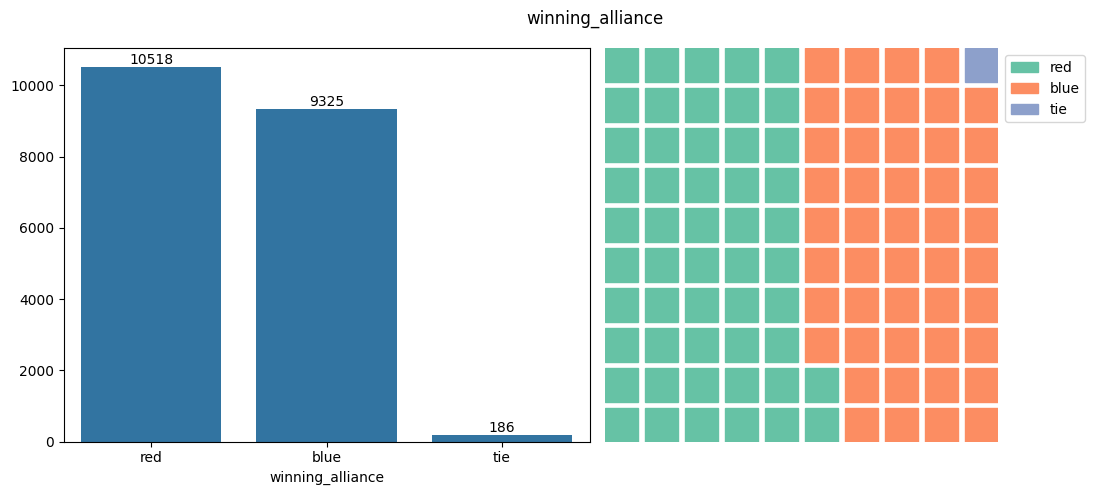

In [10]:
cat_plot("winning_alliance")

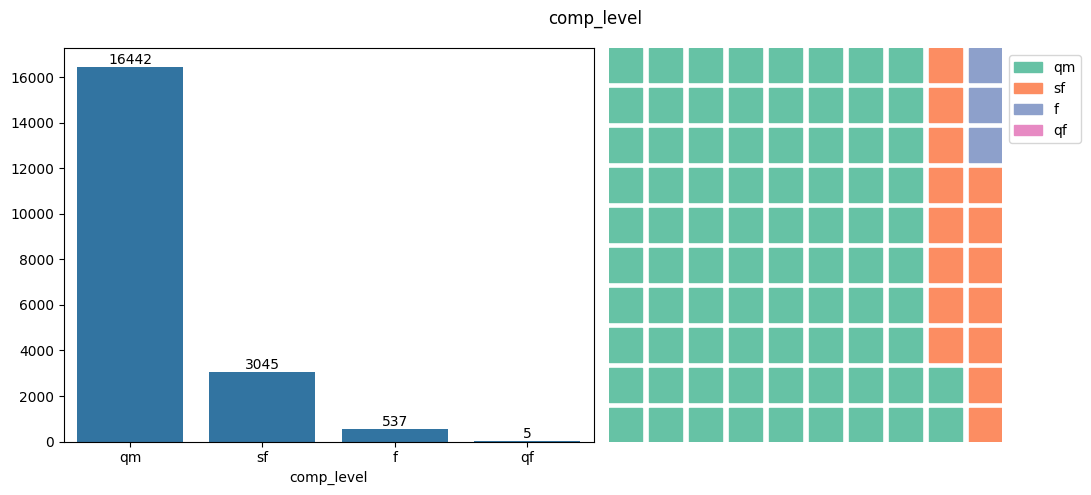

In [11]:
cat_plot("comp_level")

### Auto

#### line

##### red line

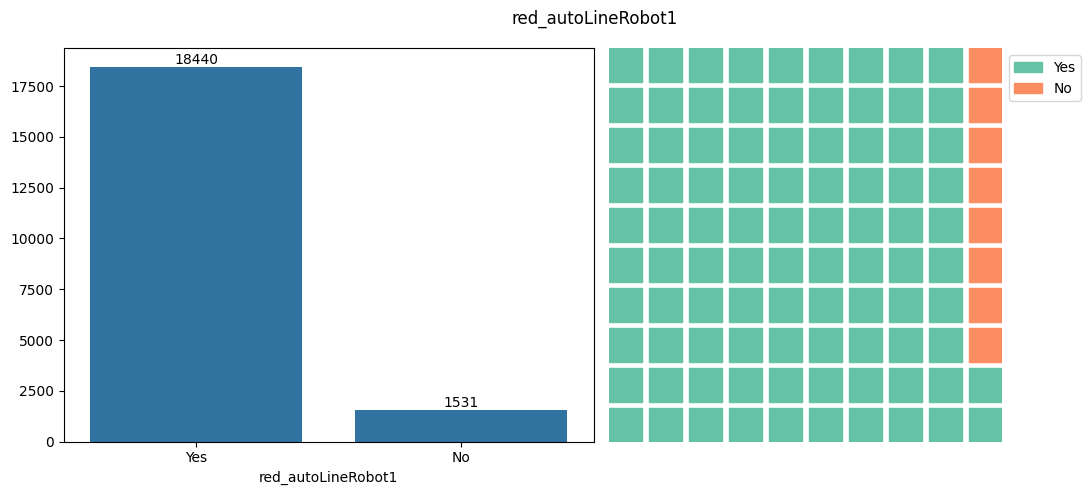

In [12]:
cat_plot("red_autoLineRobot1")

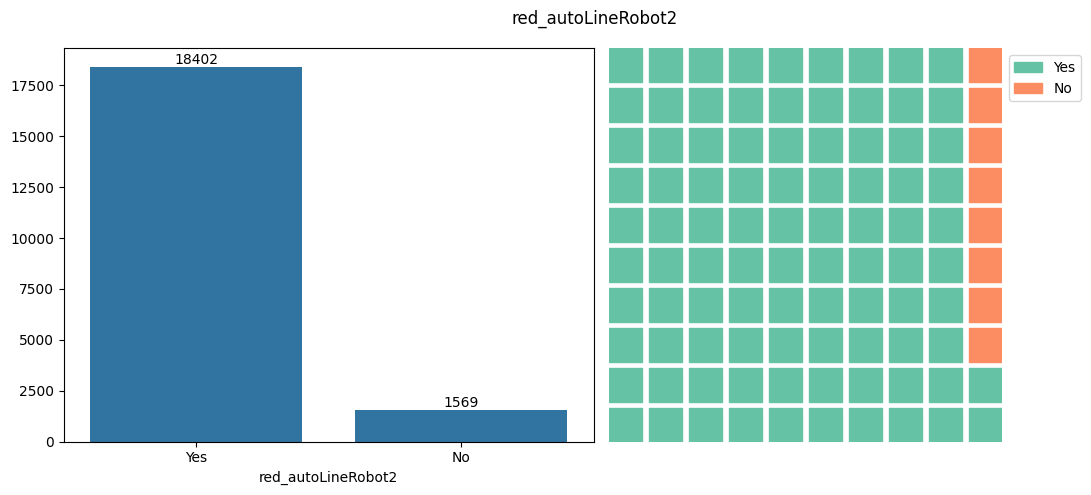

In [13]:
cat_plot("red_autoLineRobot2")

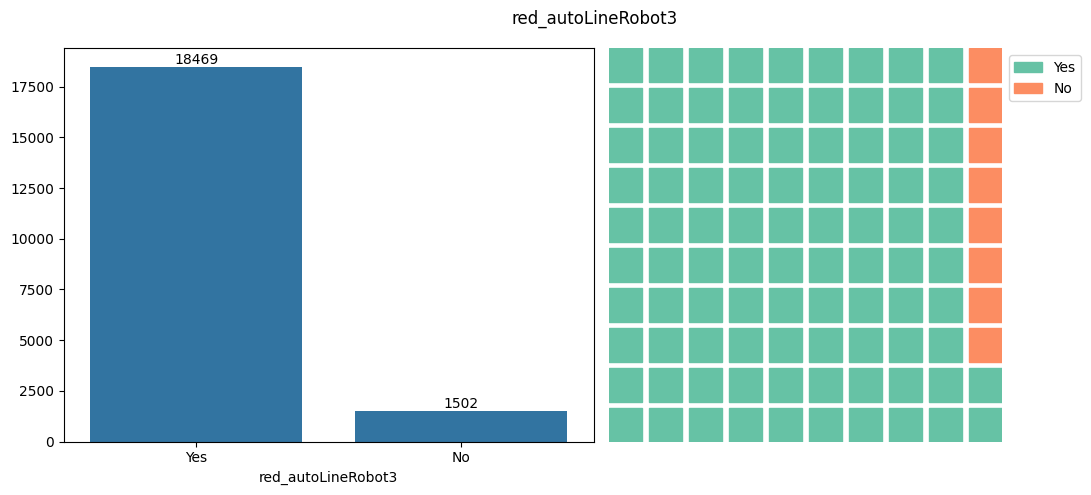

In [14]:
cat_plot("red_autoLineRobot3")

##### blue line

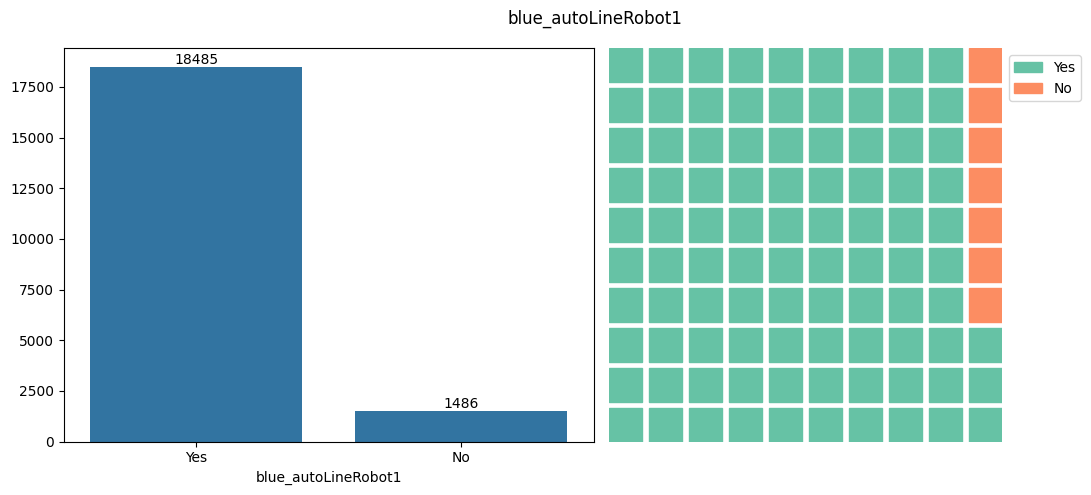

In [15]:
cat_plot("blue_autoLineRobot1")


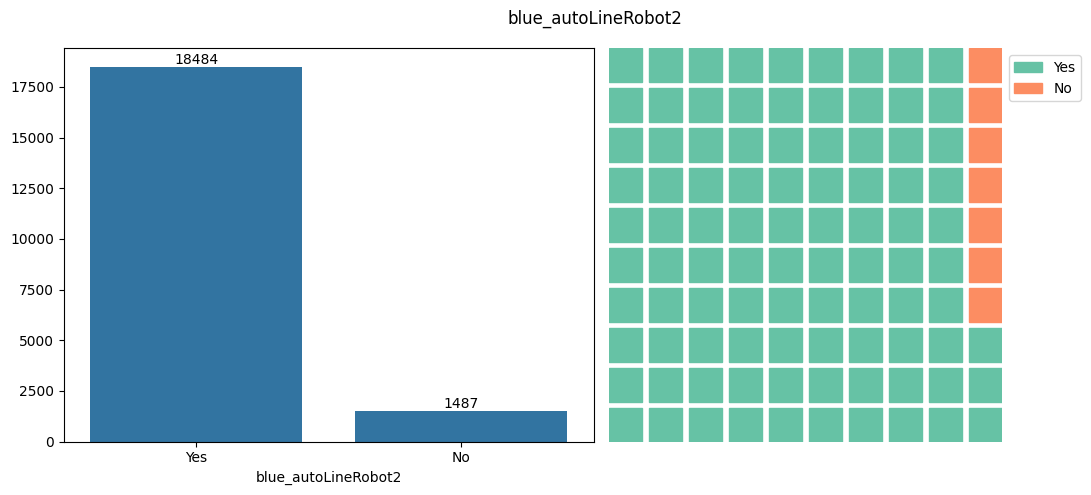

In [16]:
cat_plot("blue_autoLineRobot2")

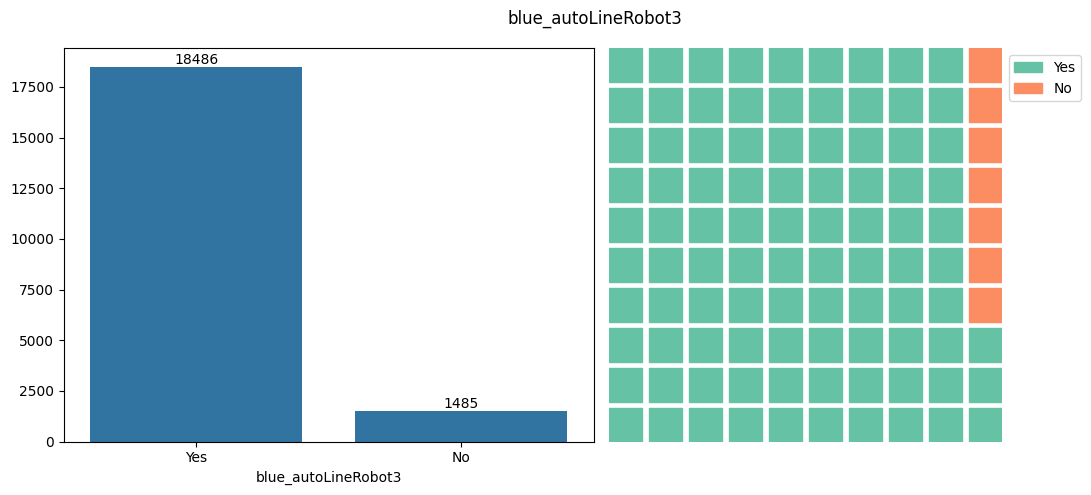

In [17]:
cat_plot("blue_autoLineRobot3")

#### red reef

##### bottom

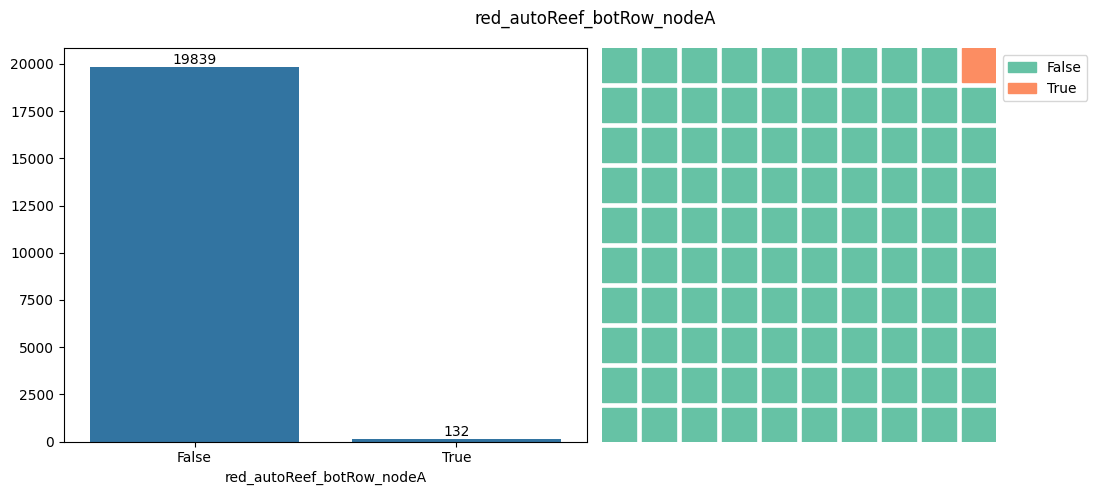

In [18]:
cat_plot("red_autoReef_botRow_nodeA")

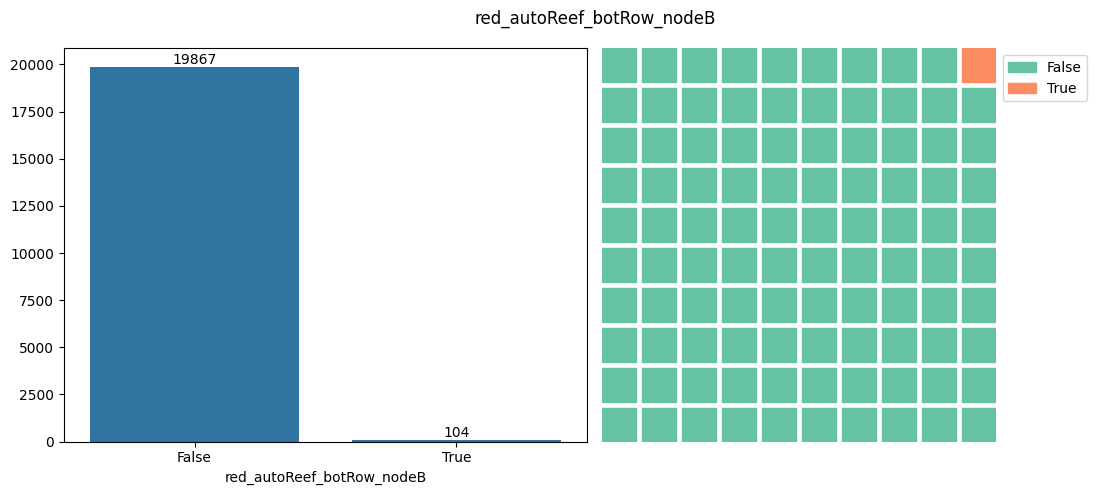

In [19]:
cat_plot("red_autoReef_botRow_nodeB")

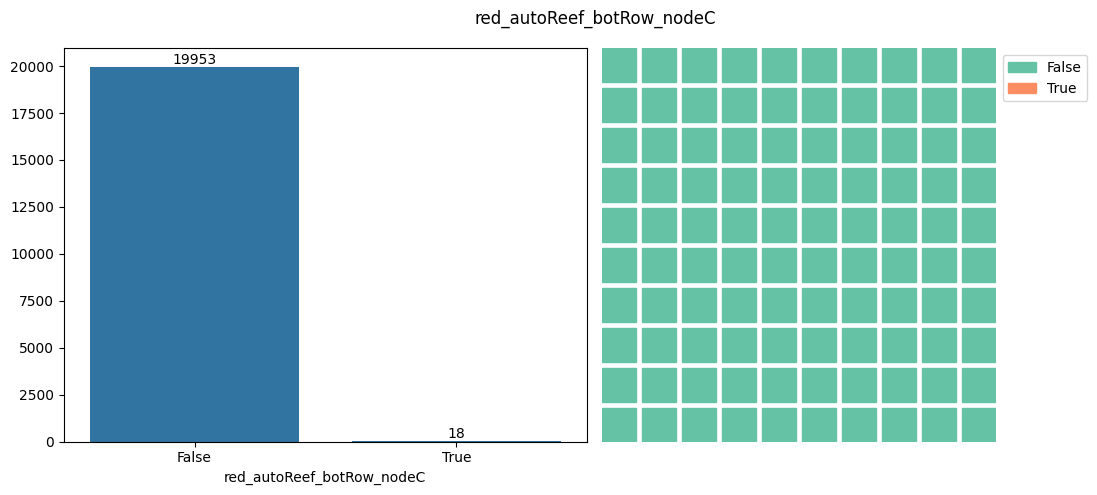

In [20]:
cat_plot("red_autoReef_botRow_nodeC")

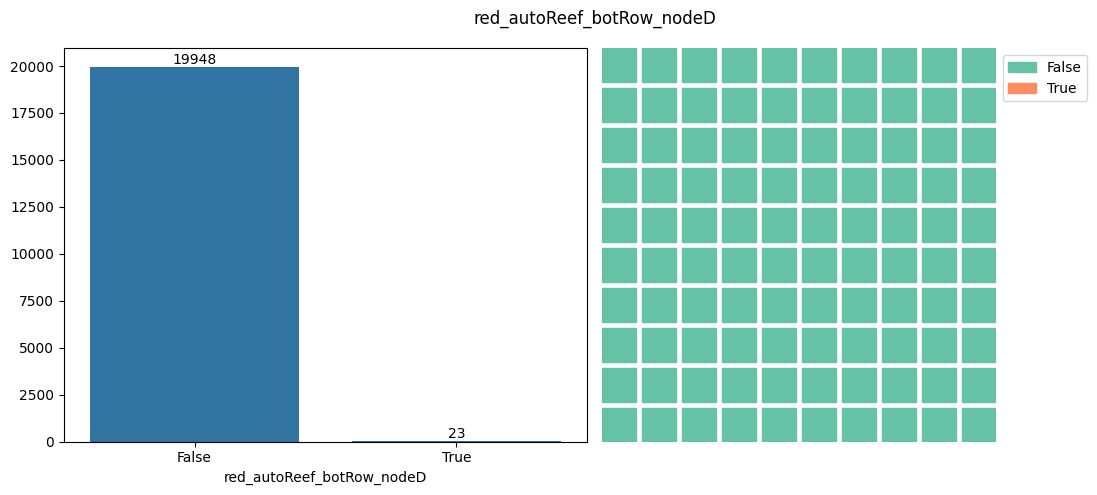

In [21]:
cat_plot("red_autoReef_botRow_nodeD")

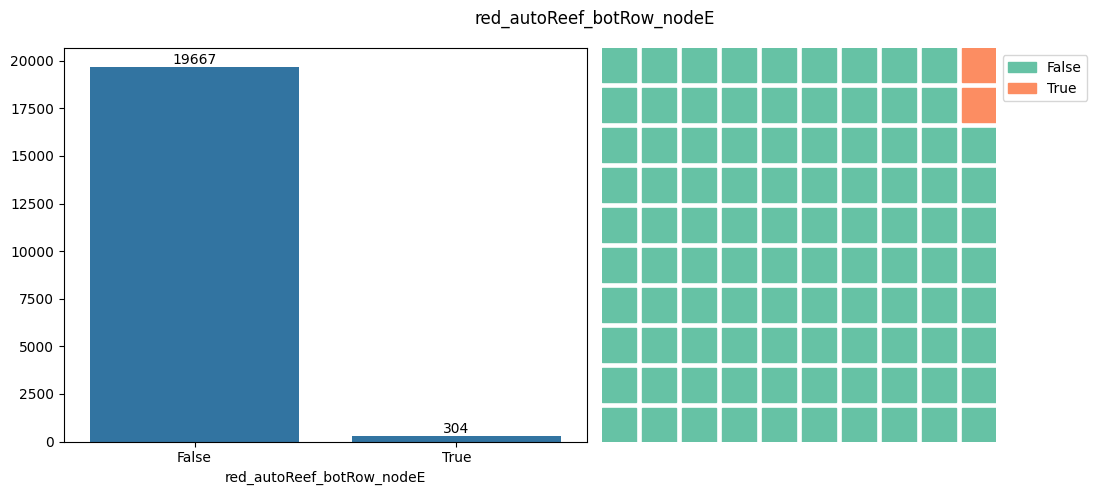

In [22]:
cat_plot("red_autoReef_botRow_nodeE")

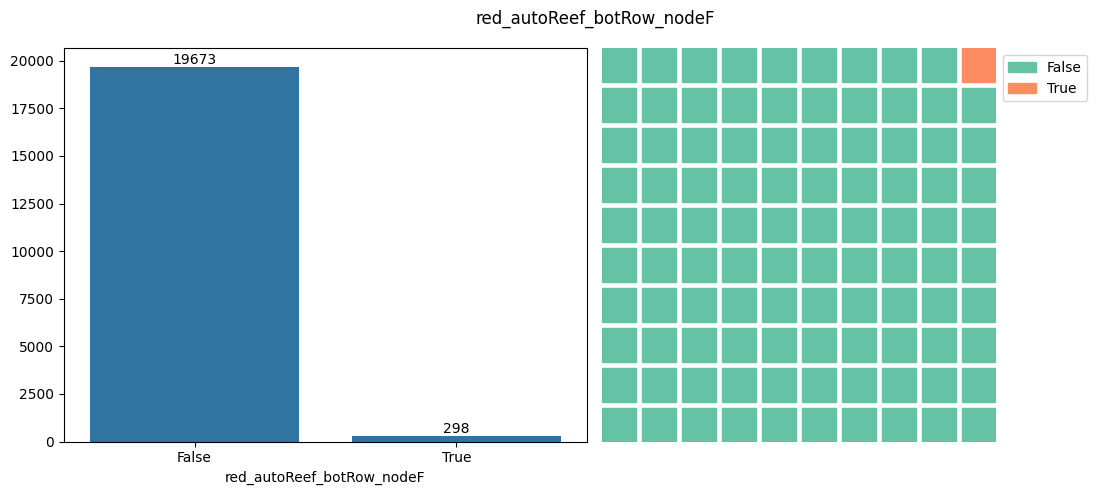

In [23]:
cat_plot("red_autoReef_botRow_nodeF")

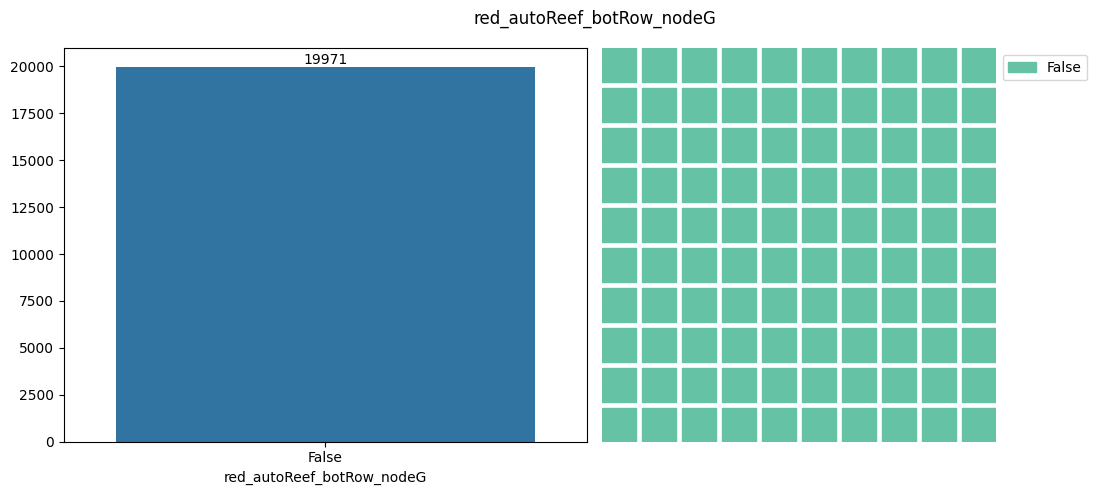

In [24]:
cat_plot("red_autoReef_botRow_nodeG")

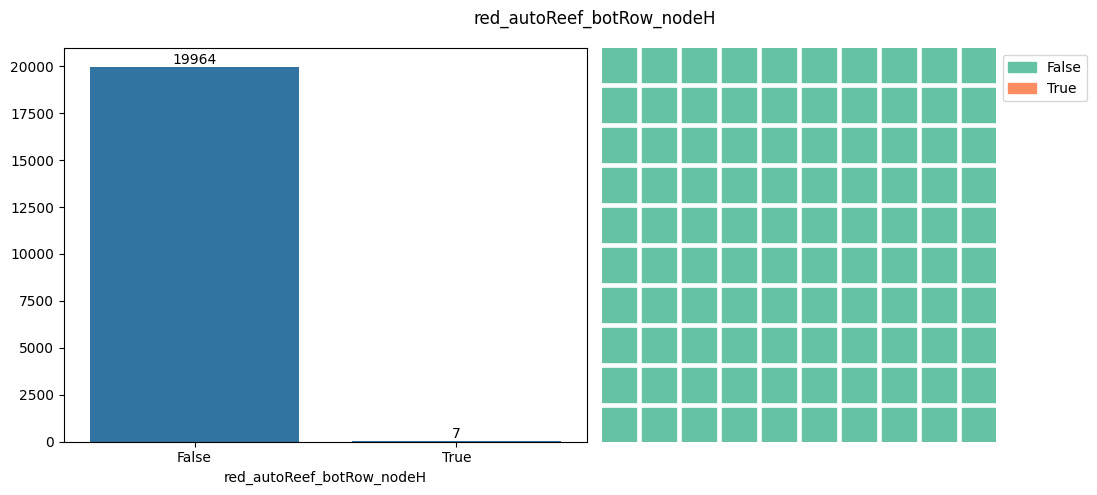

In [25]:
cat_plot("red_autoReef_botRow_nodeH")

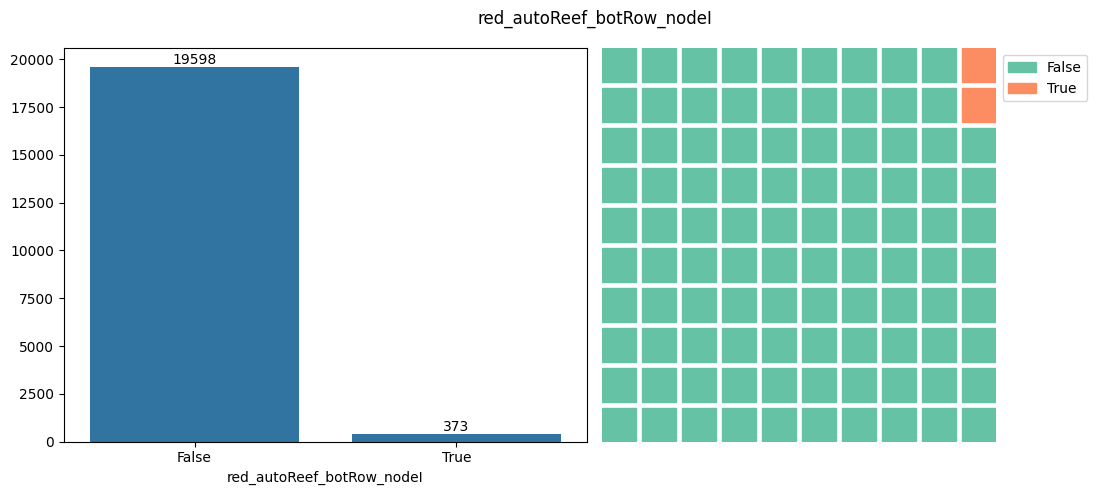

In [26]:
cat_plot("red_autoReef_botRow_nodeI")

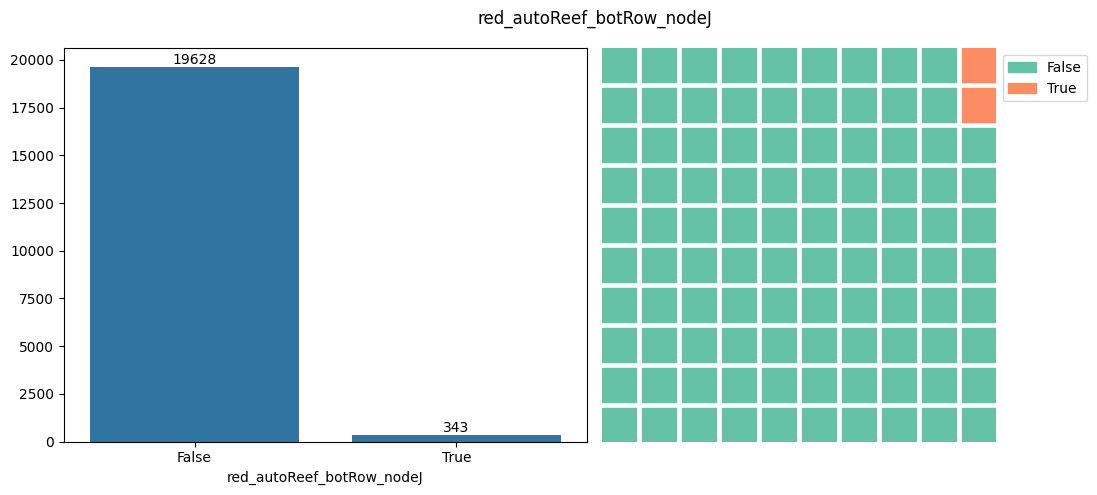

In [27]:
cat_plot("red_autoReef_botRow_nodeJ")

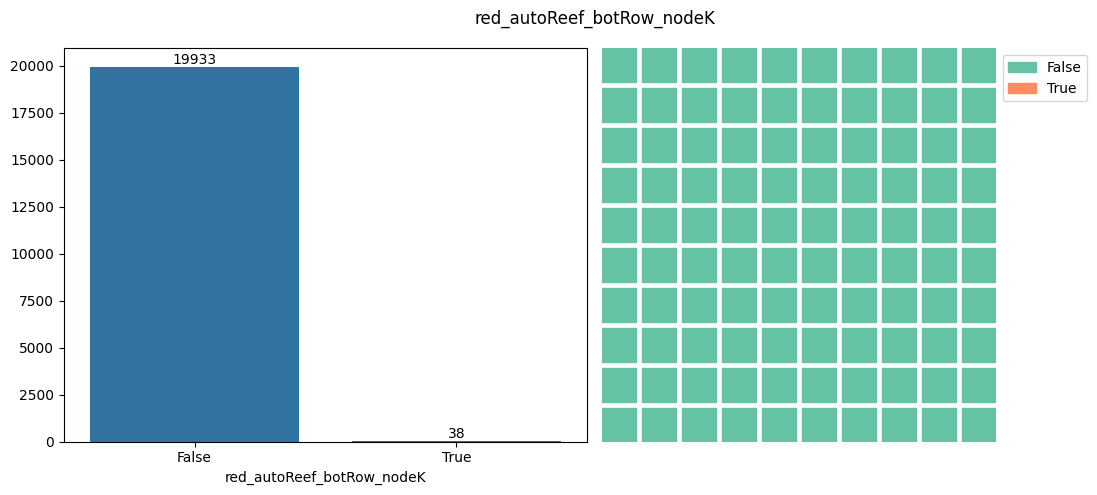

In [28]:
cat_plot("red_autoReef_botRow_nodeK")

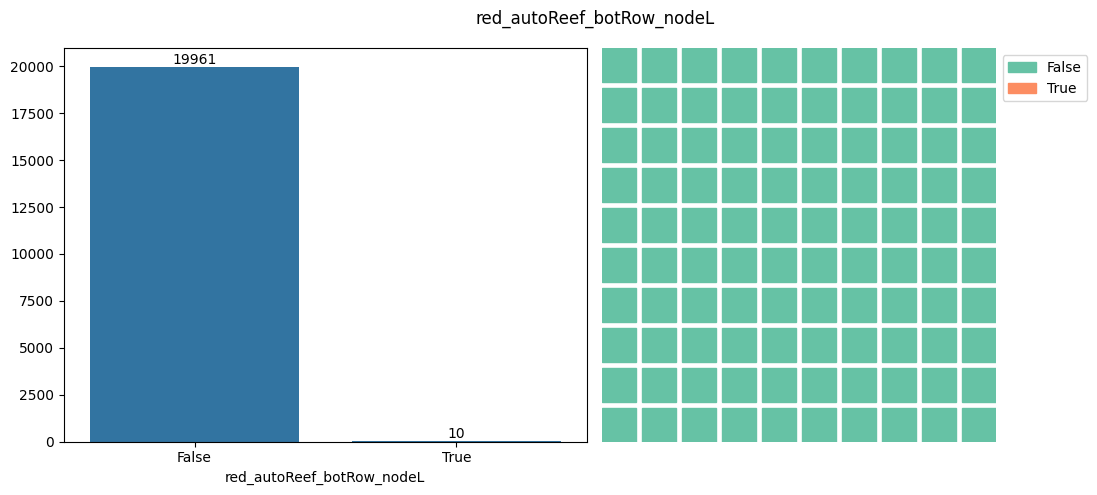

In [29]:
cat_plot("red_autoReef_botRow_nodeL")

##### middle

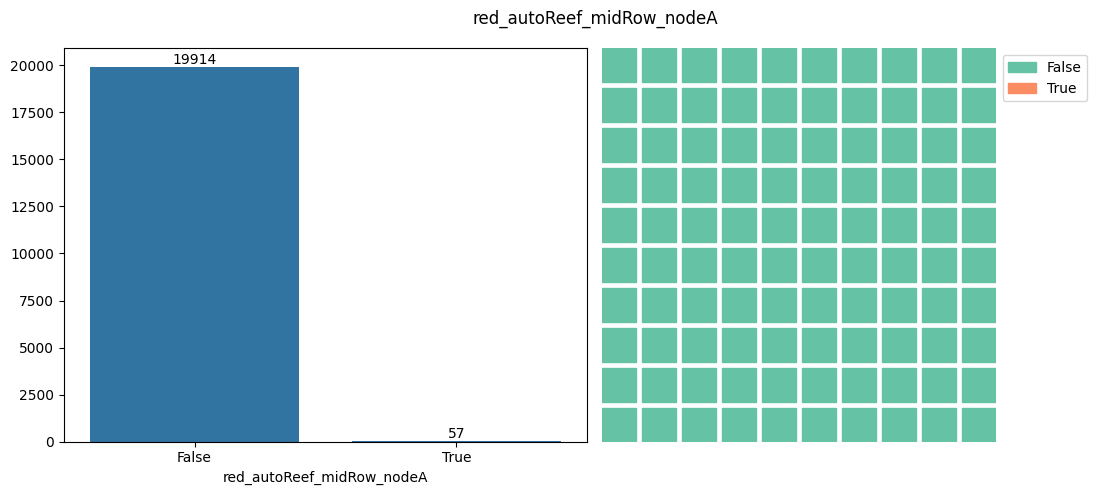

In [30]:
cat_plot("red_autoReef_midRow_nodeA")

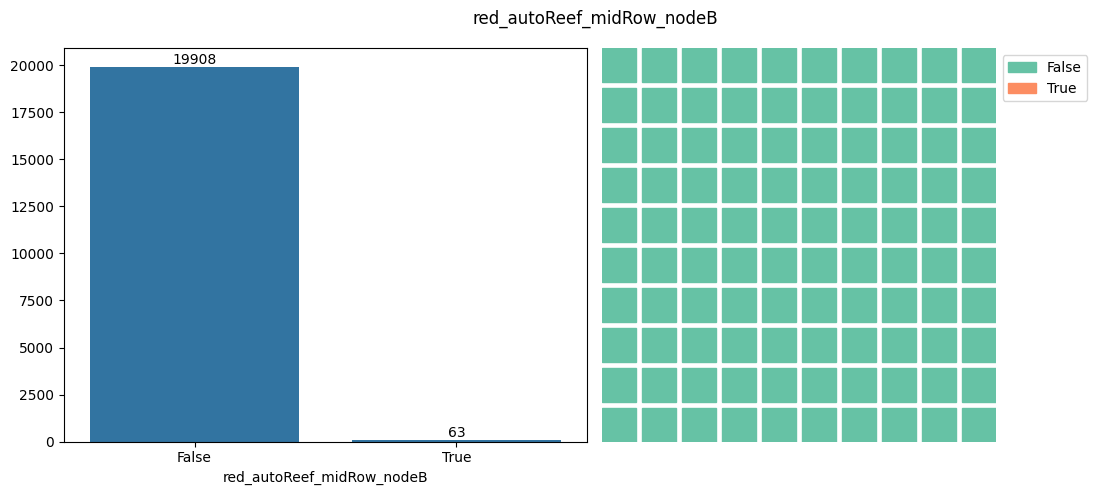

In [31]:
cat_plot("red_autoReef_midRow_nodeB")

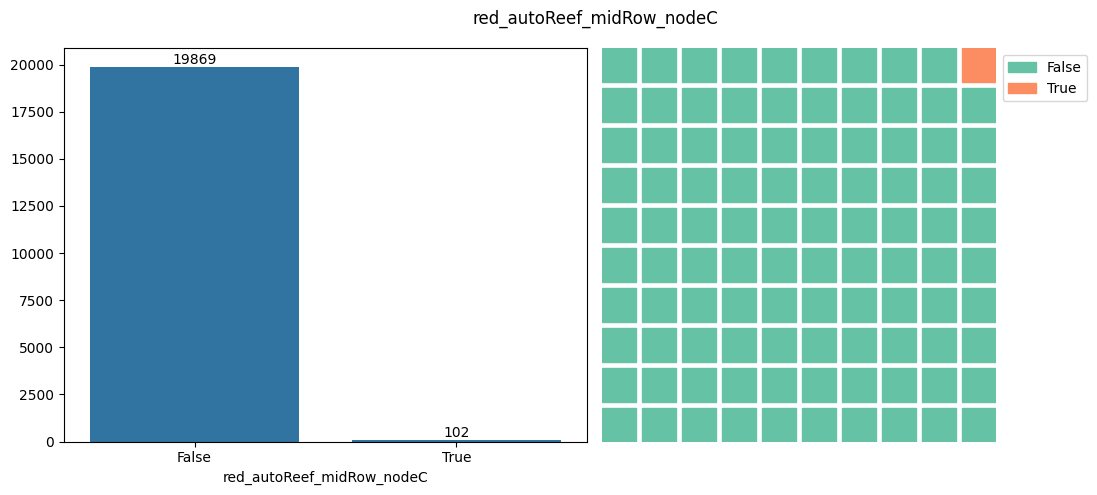

In [32]:
cat_plot("red_autoReef_midRow_nodeC")

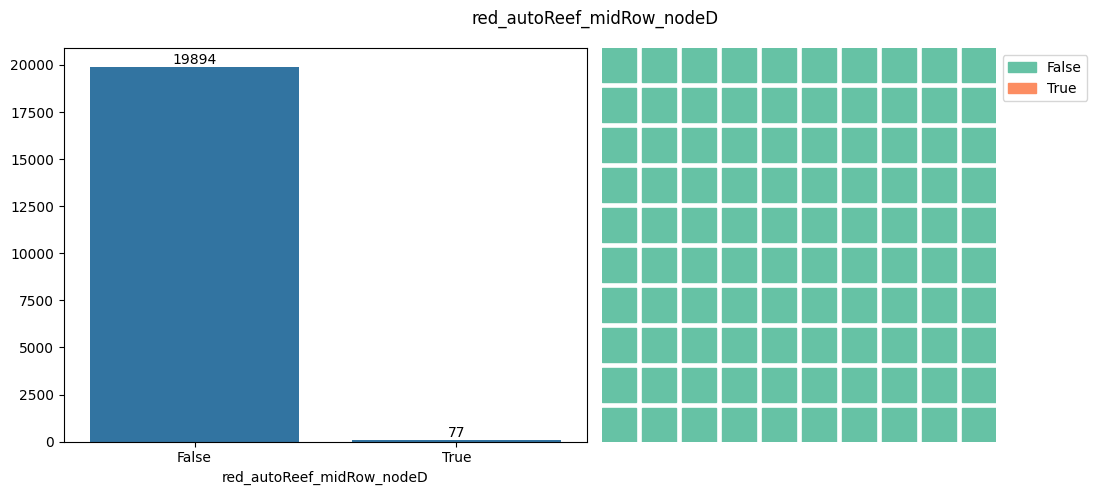

In [33]:
cat_plot("red_autoReef_midRow_nodeD")

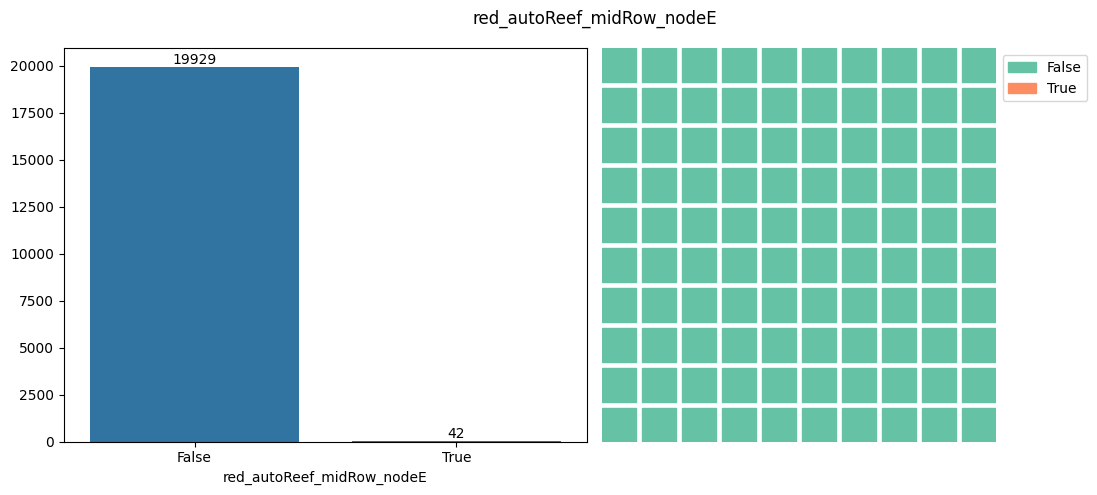

In [34]:
cat_plot("red_autoReef_midRow_nodeE")

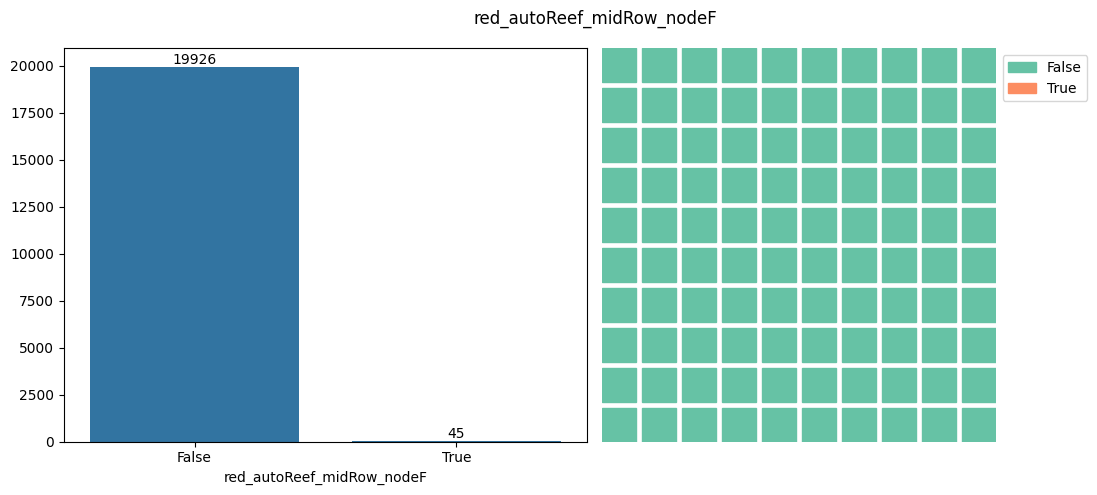

In [35]:
cat_plot("red_autoReef_midRow_nodeF")

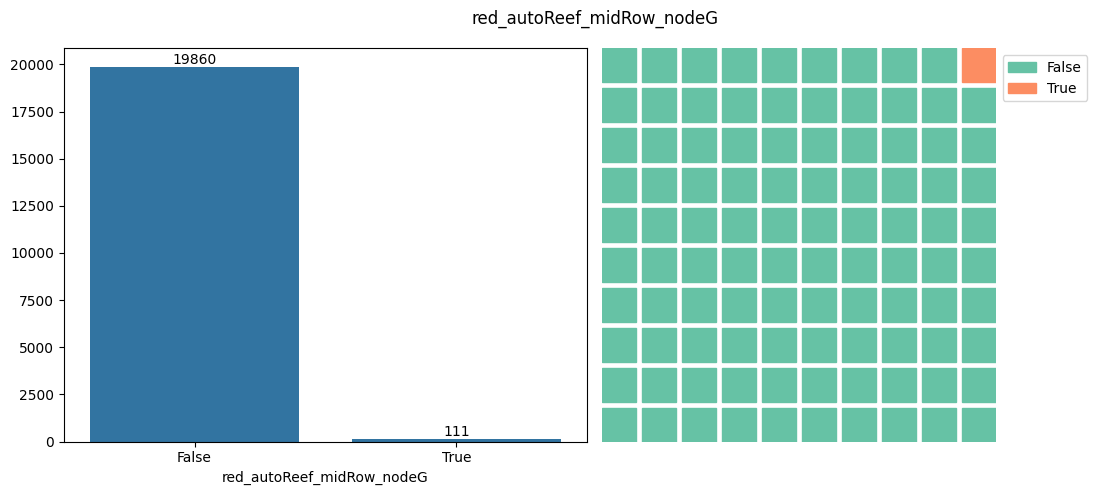

In [36]:
cat_plot("red_autoReef_midRow_nodeG")

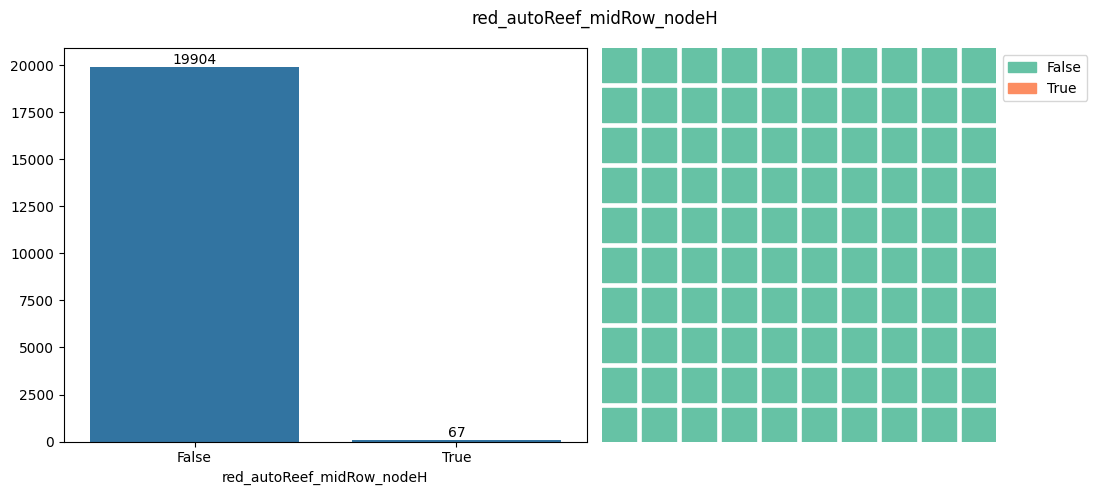

In [37]:
cat_plot("red_autoReef_midRow_nodeH")

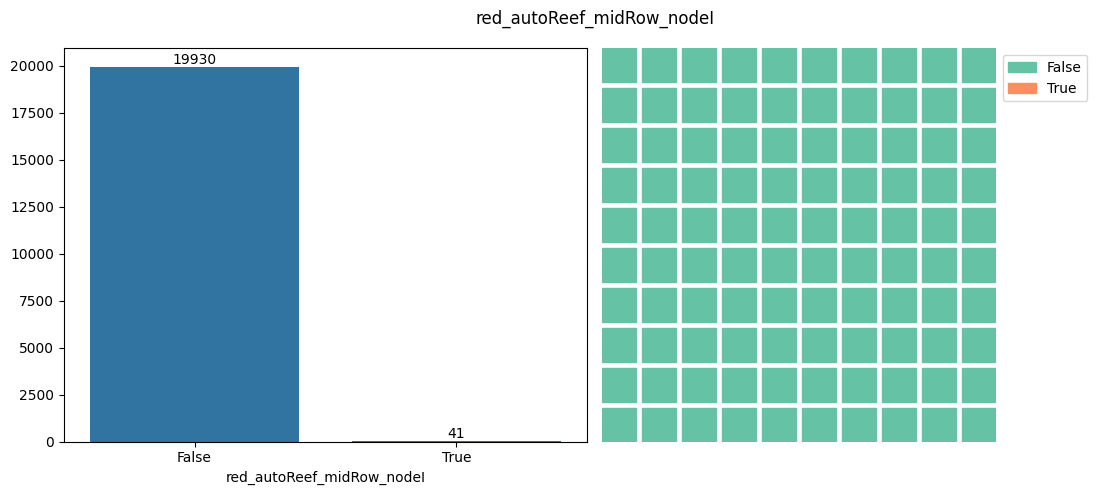

In [38]:
cat_plot("red_autoReef_midRow_nodeI")

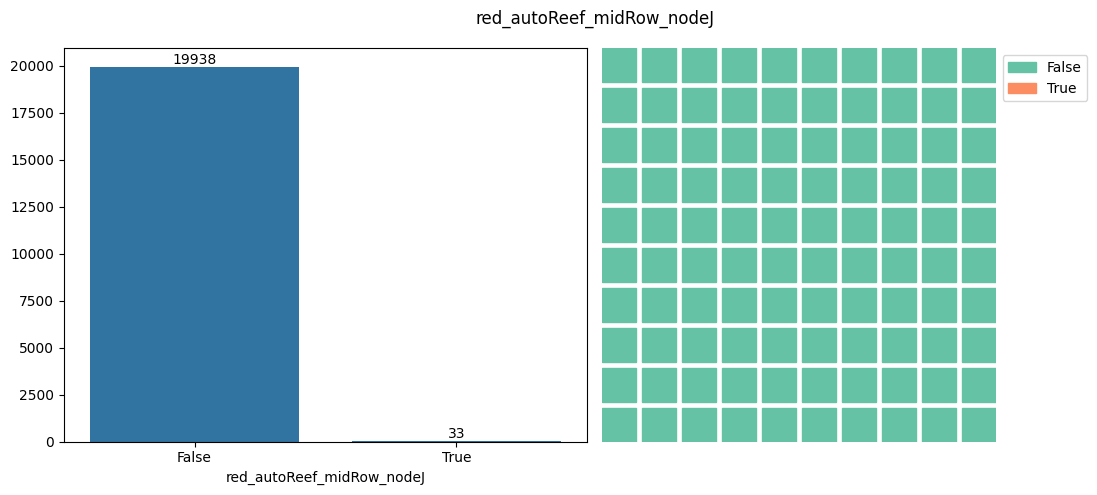

In [39]:
cat_plot("red_autoReef_midRow_nodeJ")

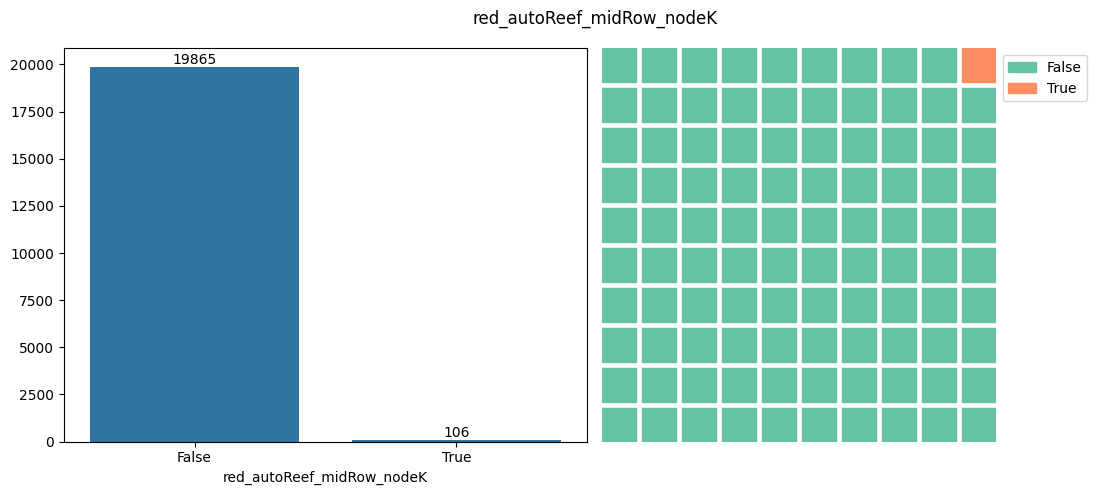

In [40]:
cat_plot("red_autoReef_midRow_nodeK")

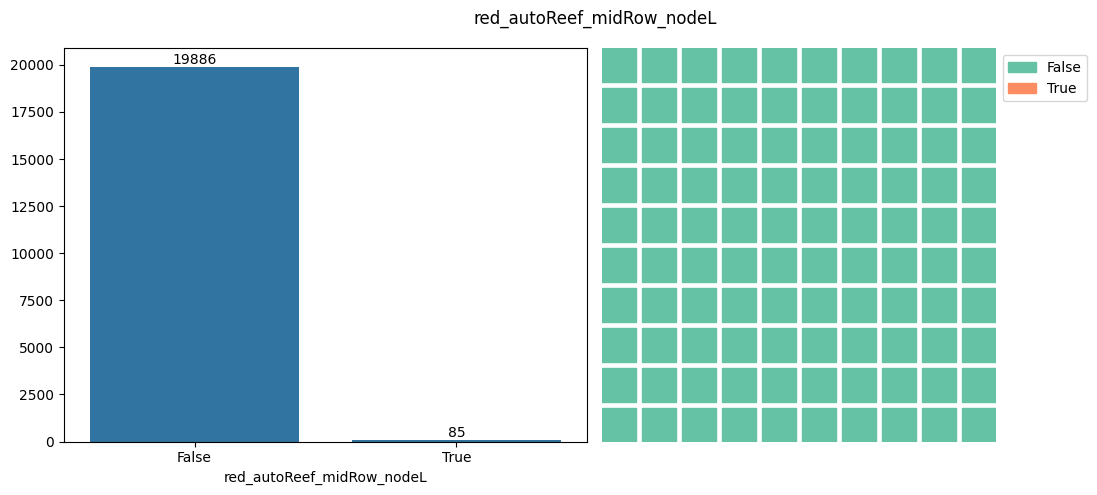

In [41]:
cat_plot("red_autoReef_midRow_nodeL")

##### top

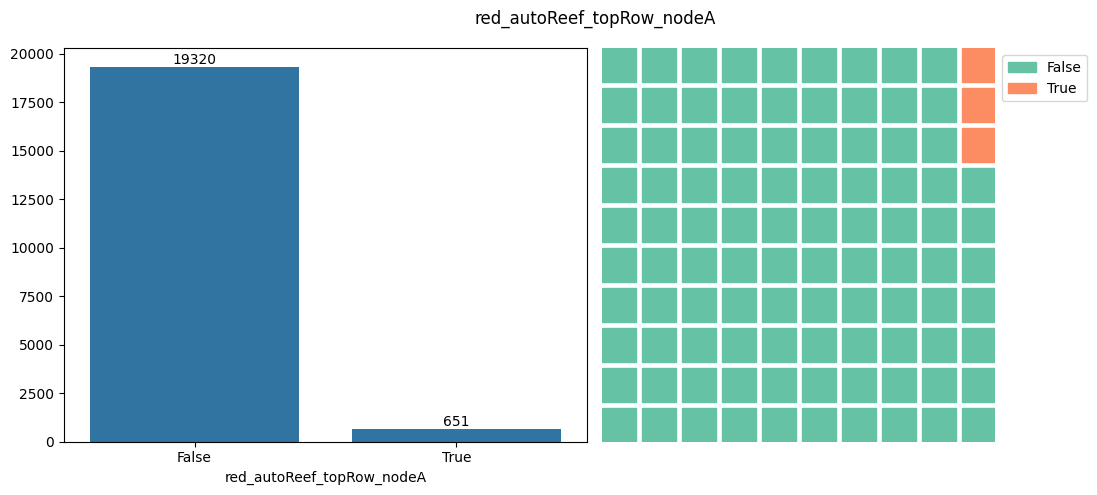

In [42]:
cat_plot("red_autoReef_topRow_nodeA")

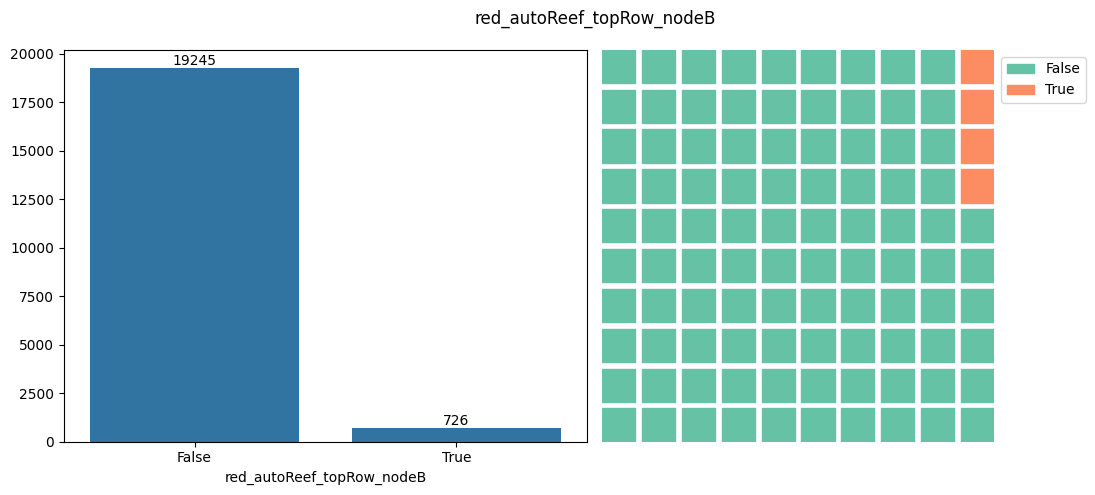

In [43]:
cat_plot("red_autoReef_topRow_nodeB")

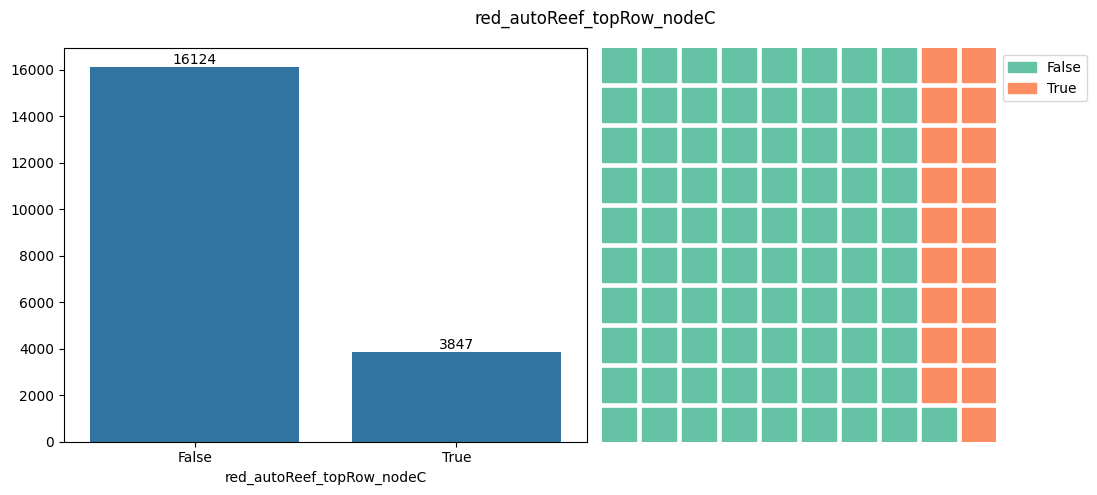

In [44]:
cat_plot("red_autoReef_topRow_nodeC")

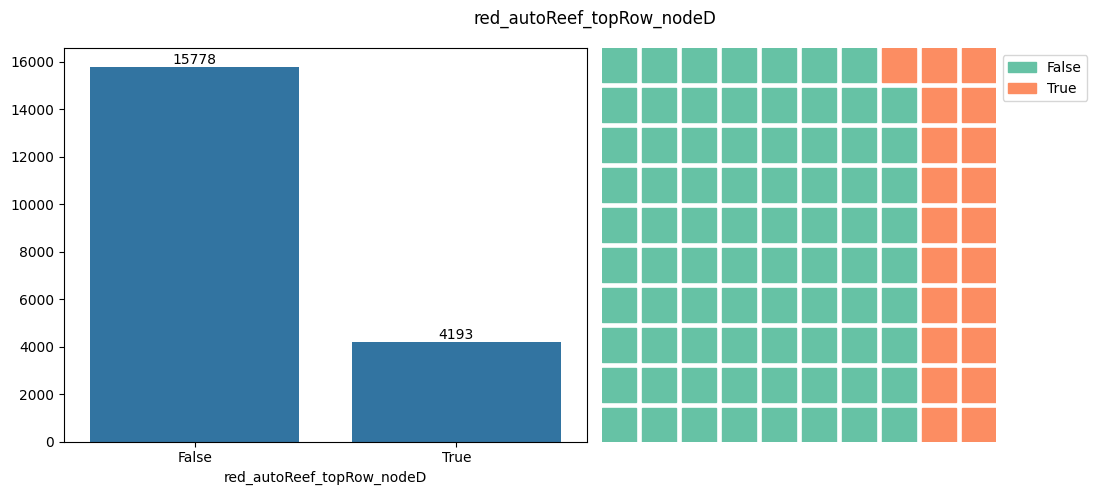

In [45]:
cat_plot("red_autoReef_topRow_nodeD")

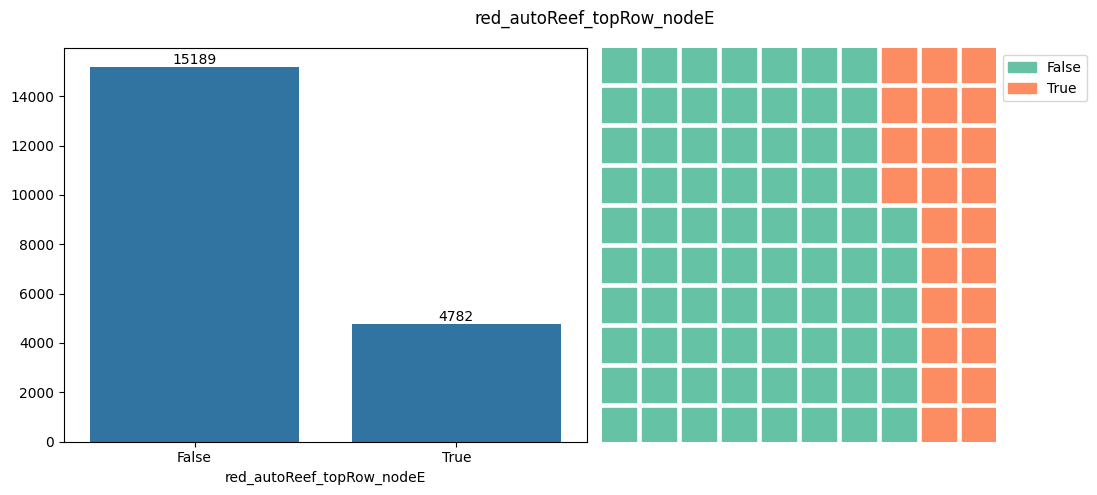

In [46]:
cat_plot("red_autoReef_topRow_nodeE")

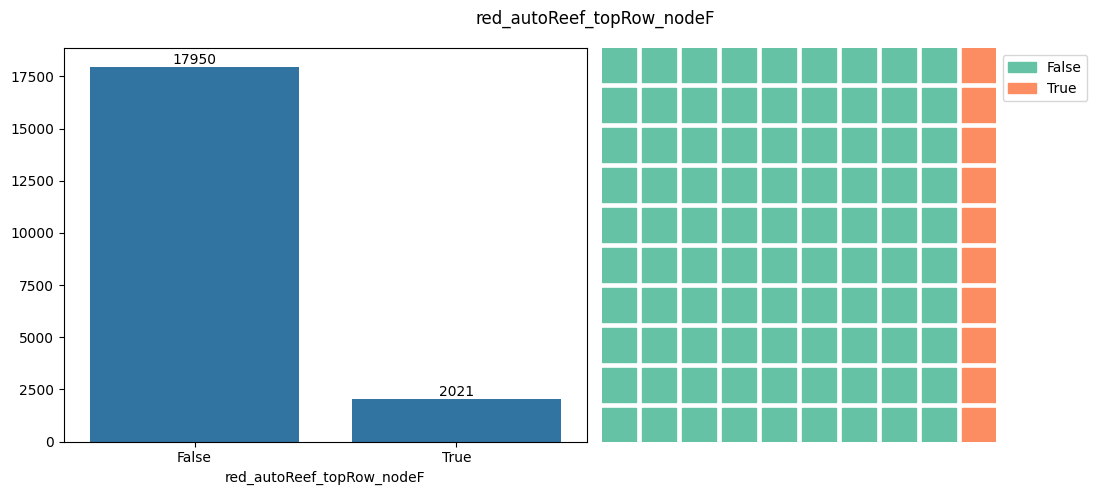

In [47]:
cat_plot("red_autoReef_topRow_nodeF")

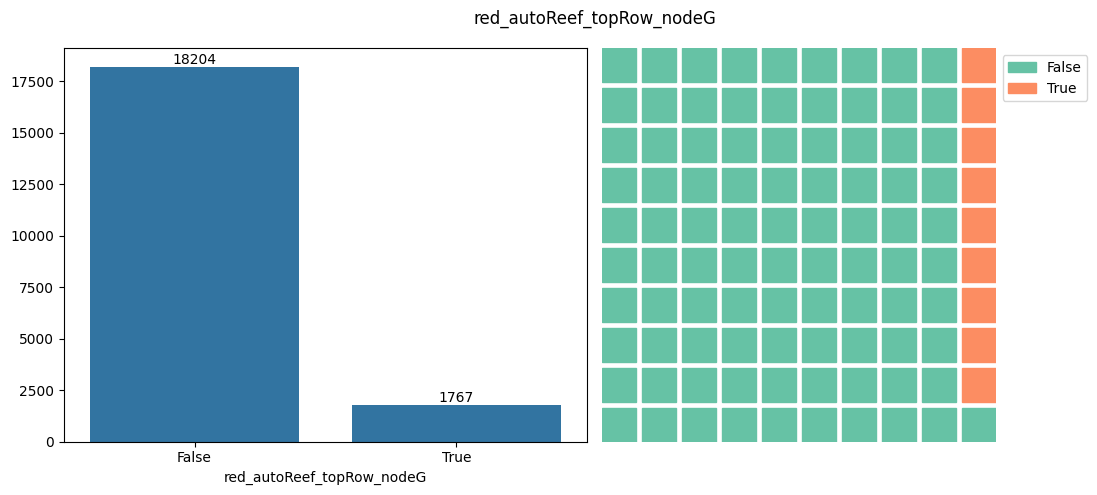

In [48]:
cat_plot("red_autoReef_topRow_nodeG")

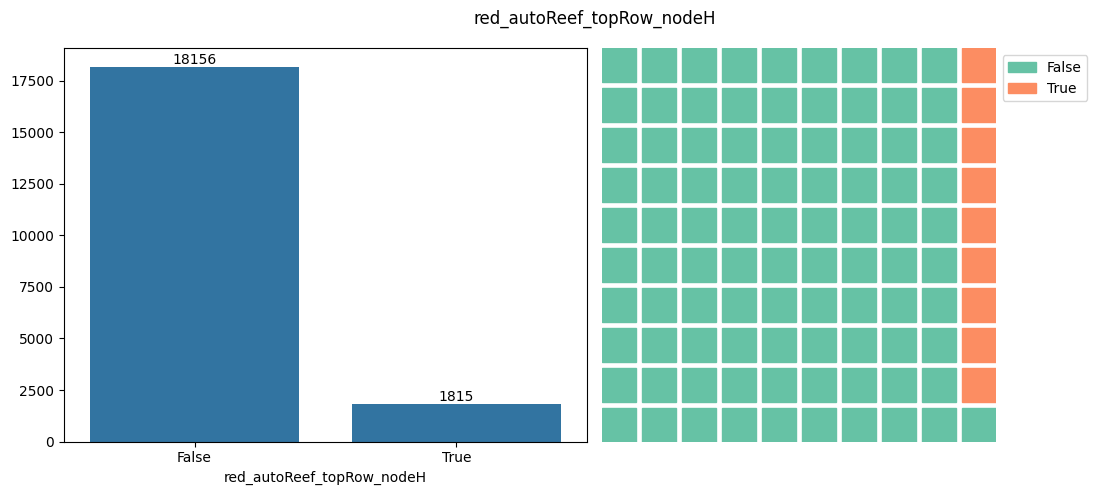

In [49]:
cat_plot("red_autoReef_topRow_nodeH")

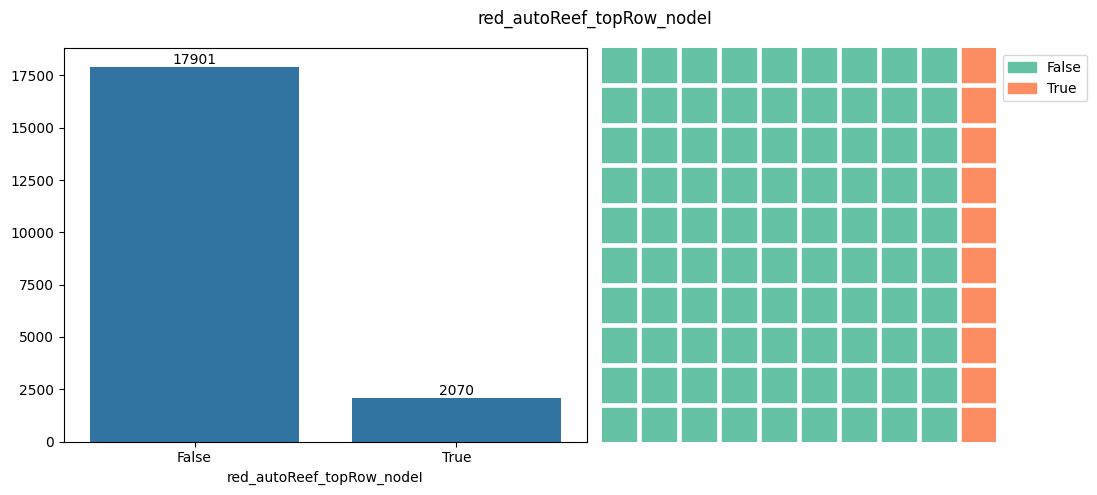

In [50]:
cat_plot("red_autoReef_topRow_nodeI")

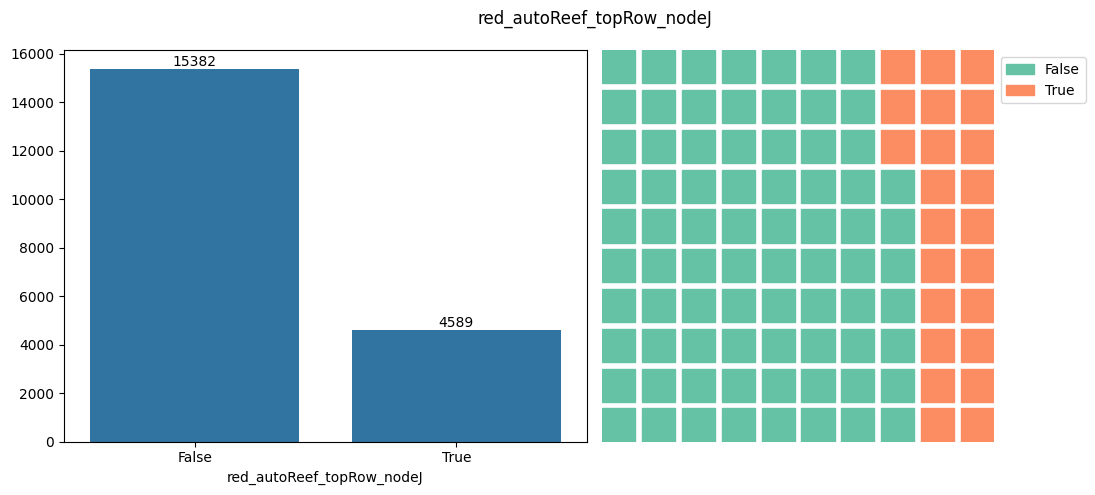

In [51]:
cat_plot("red_autoReef_topRow_nodeJ")

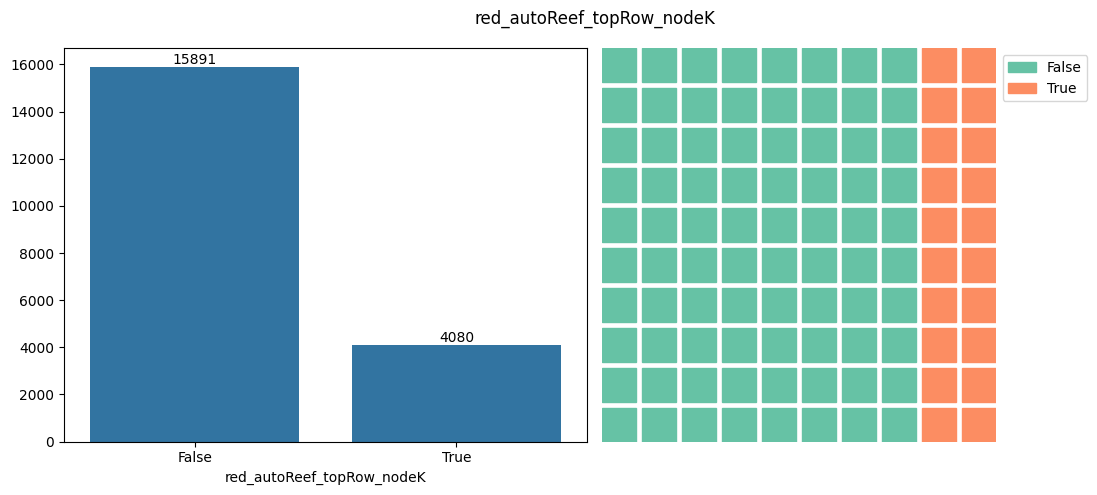

In [52]:
cat_plot("red_autoReef_topRow_nodeK")

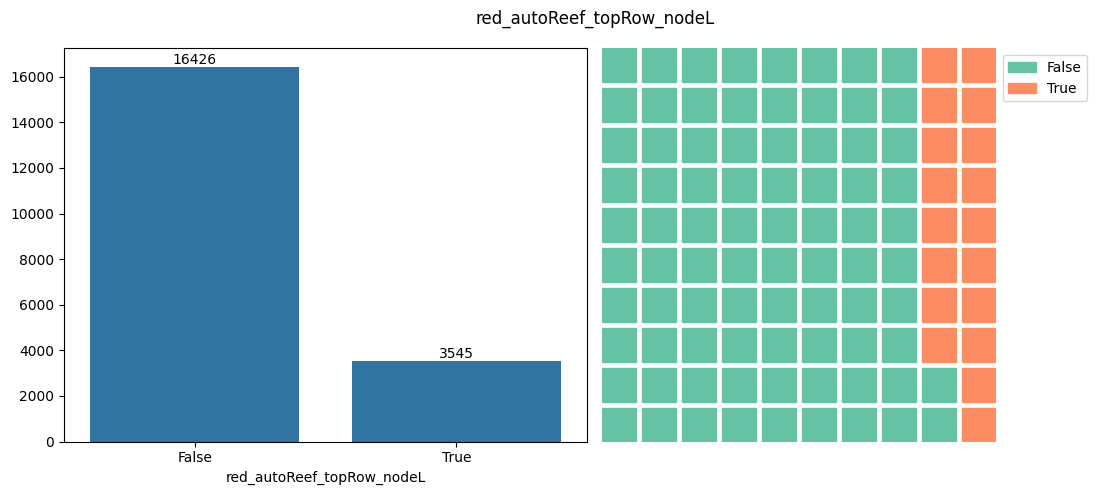

In [53]:
cat_plot("red_autoReef_topRow_nodeL")

#### blue reef

##### bottom

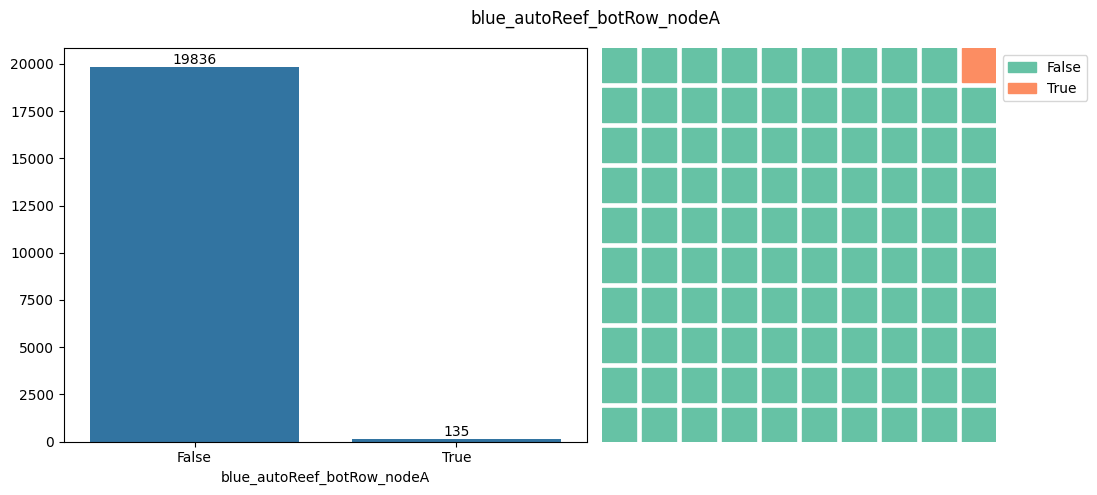

In [54]:
cat_plot("blue_autoReef_botRow_nodeA")

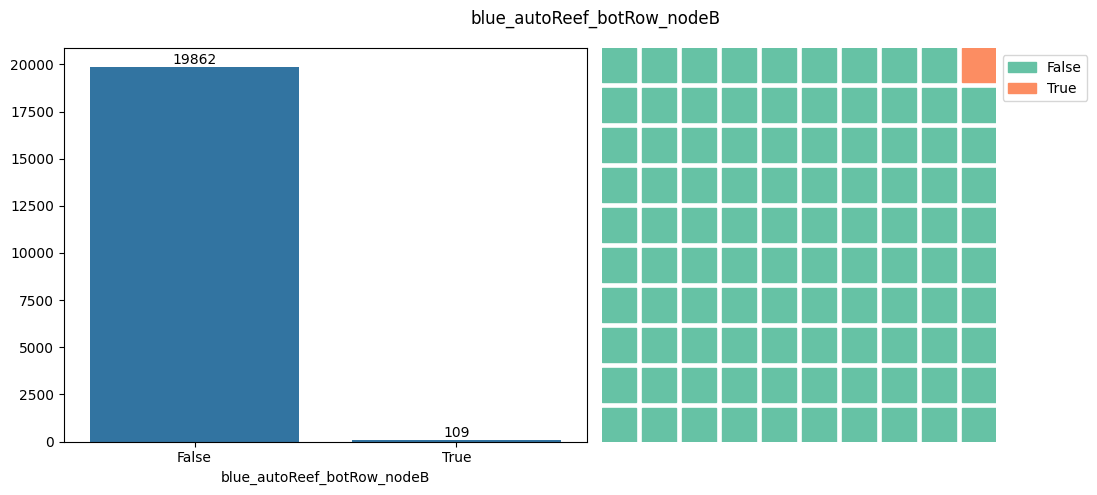

In [55]:
cat_plot("blue_autoReef_botRow_nodeB")

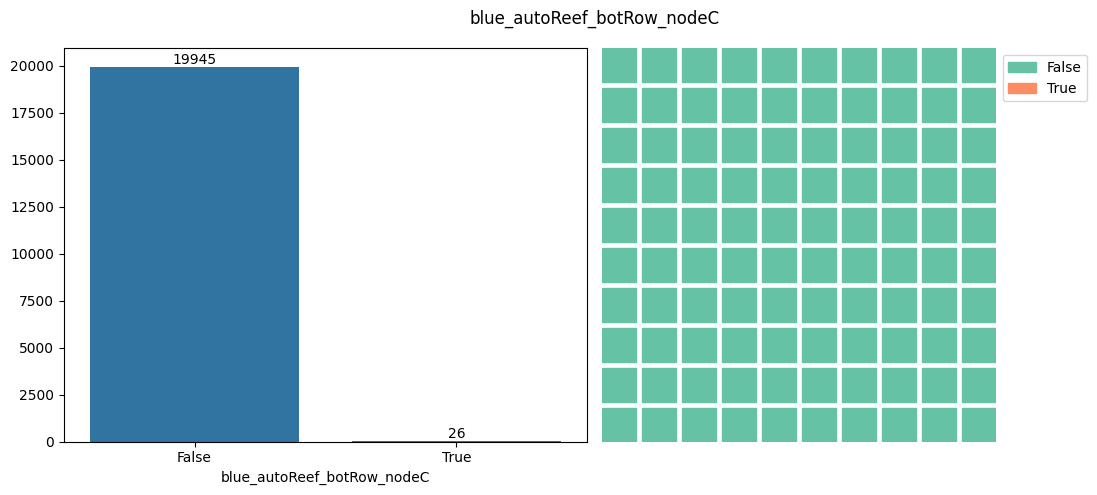

In [56]:
cat_plot("blue_autoReef_botRow_nodeC")

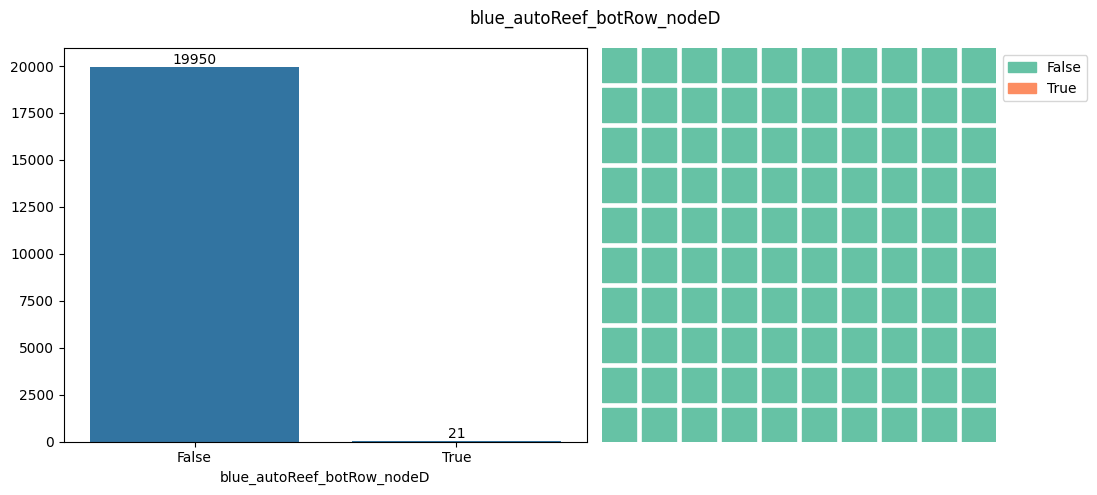

In [57]:
cat_plot("blue_autoReef_botRow_nodeD")

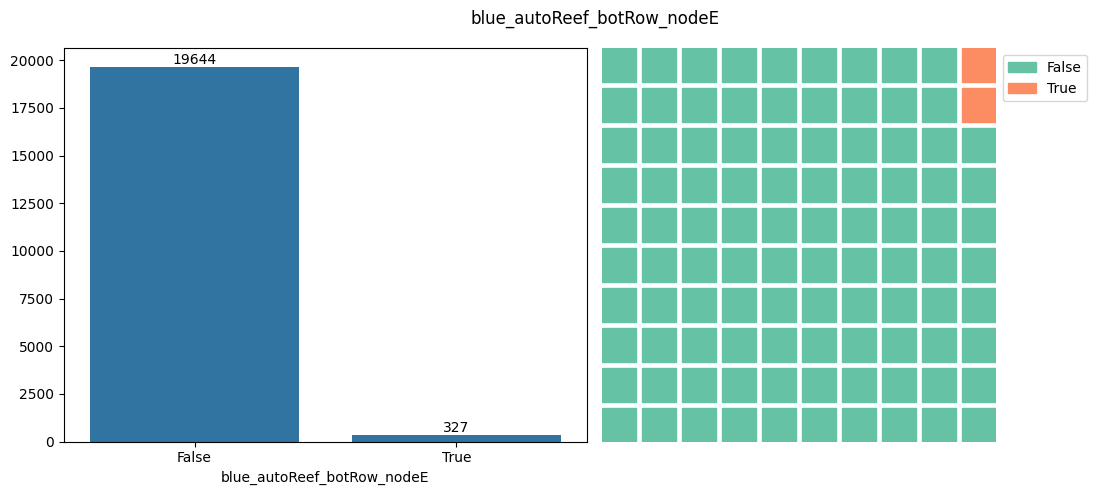

In [58]:
cat_plot("blue_autoReef_botRow_nodeE")

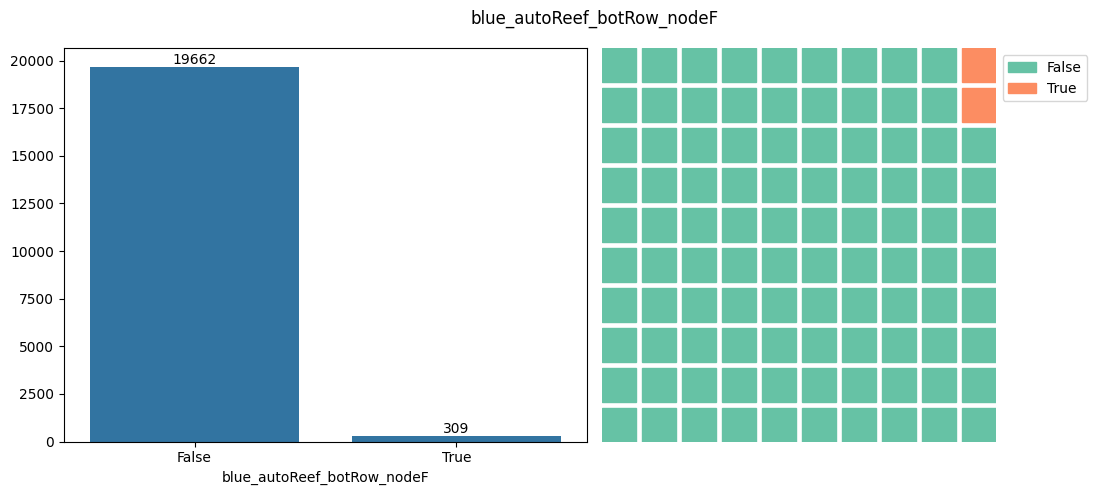

In [59]:
cat_plot("blue_autoReef_botRow_nodeF")

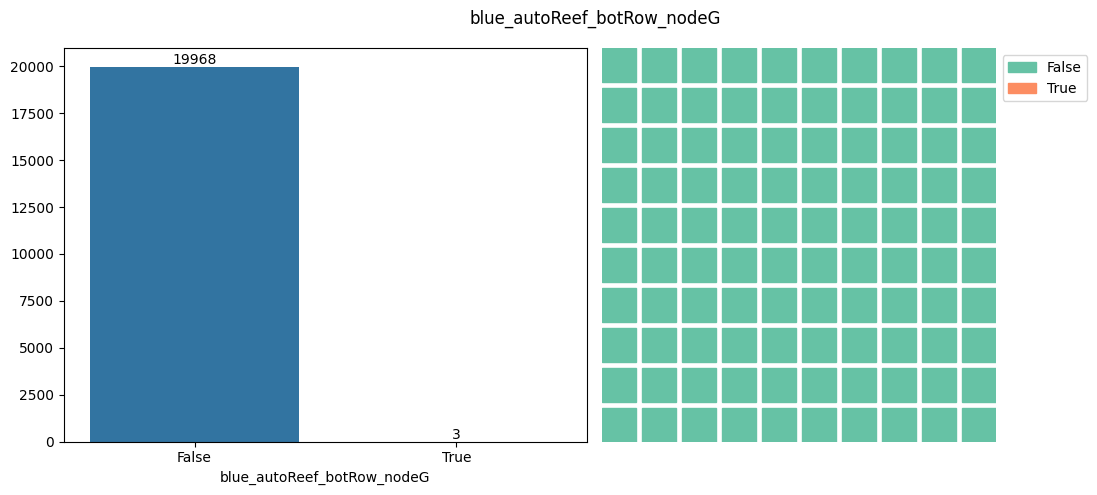

In [60]:
cat_plot("blue_autoReef_botRow_nodeG")

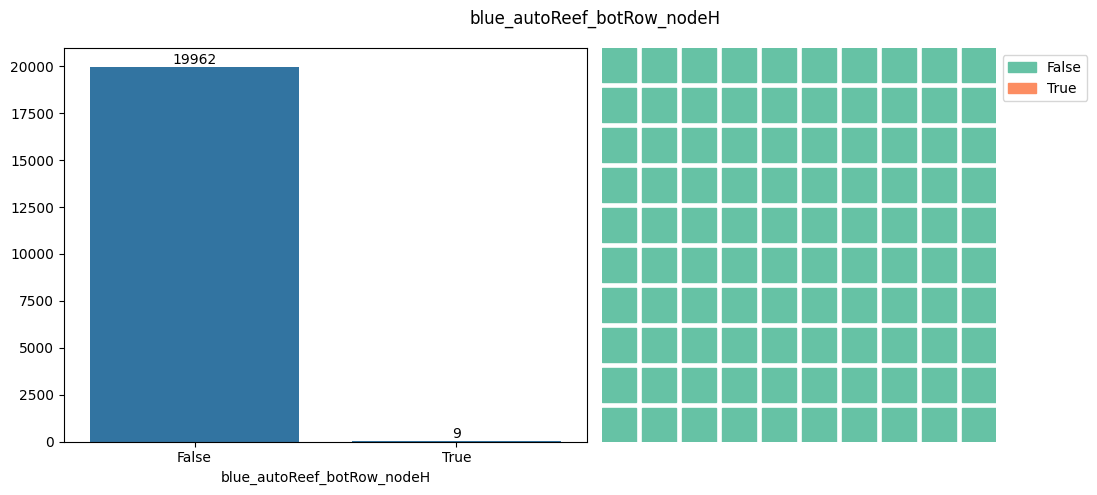

In [61]:
cat_plot("blue_autoReef_botRow_nodeH")

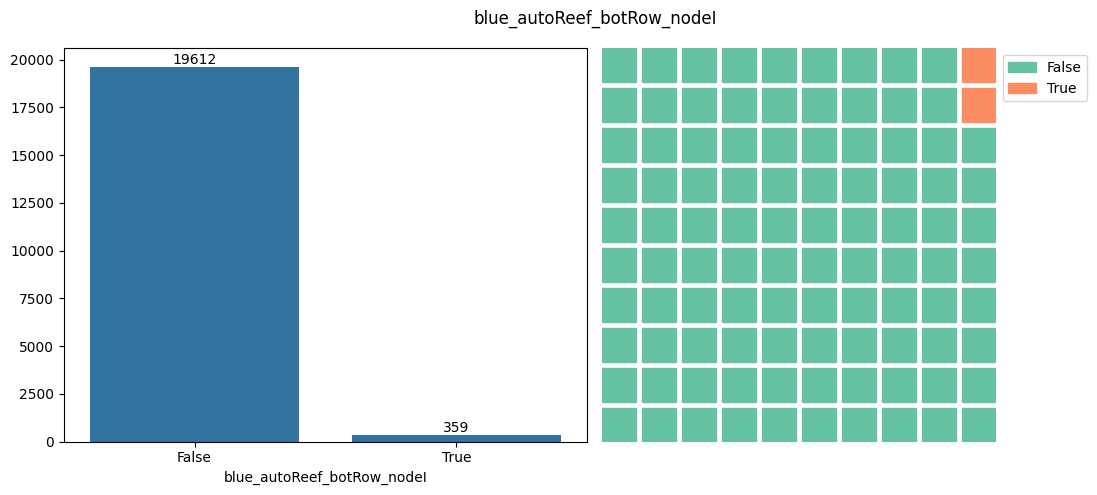

In [62]:
cat_plot("blue_autoReef_botRow_nodeI")

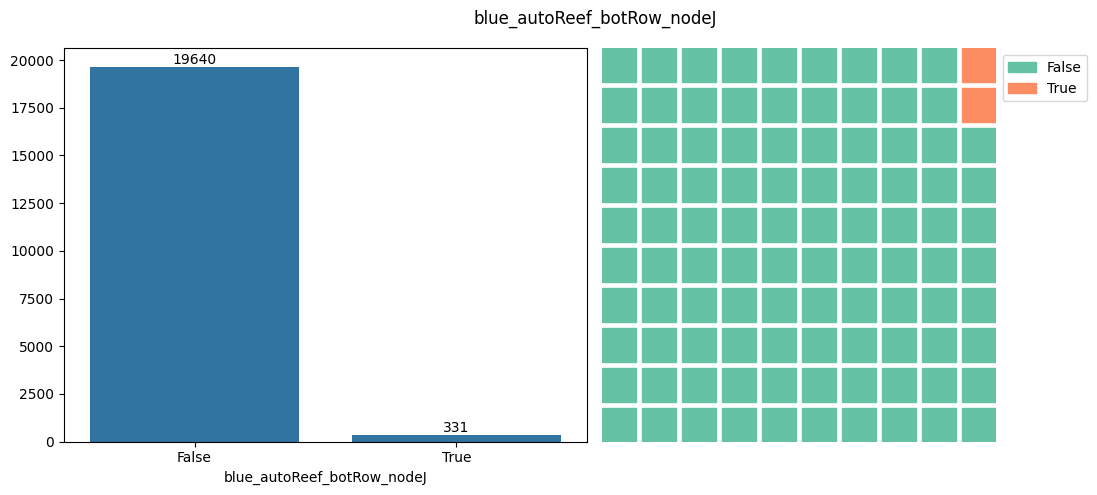

In [63]:
cat_plot("blue_autoReef_botRow_nodeJ")

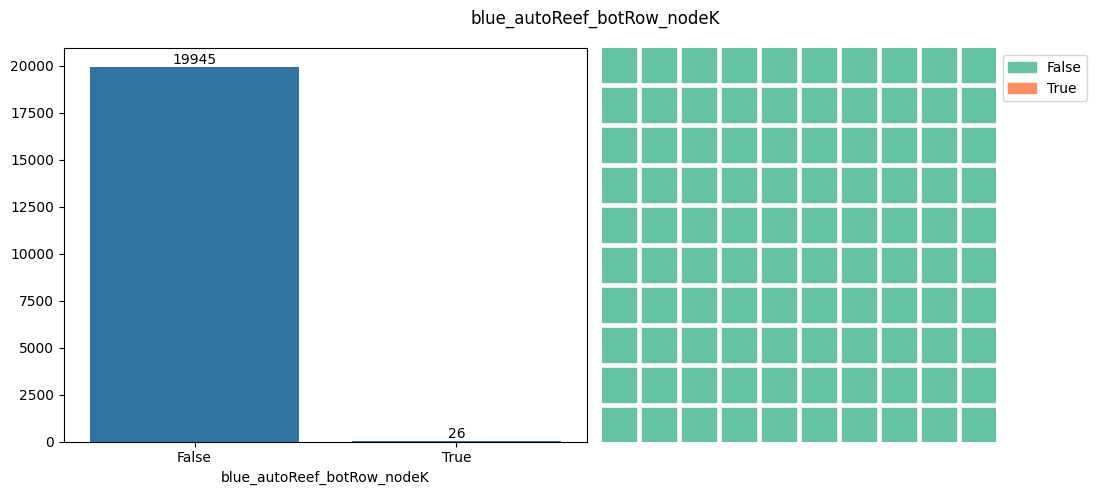

In [64]:
cat_plot("blue_autoReef_botRow_nodeK")

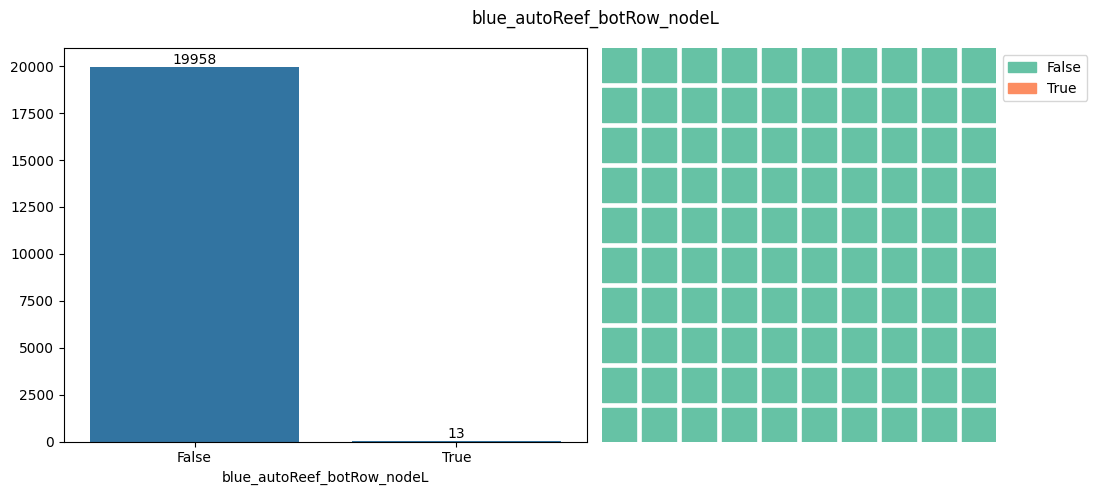

In [65]:
cat_plot("blue_autoReef_botRow_nodeL")

##### middle

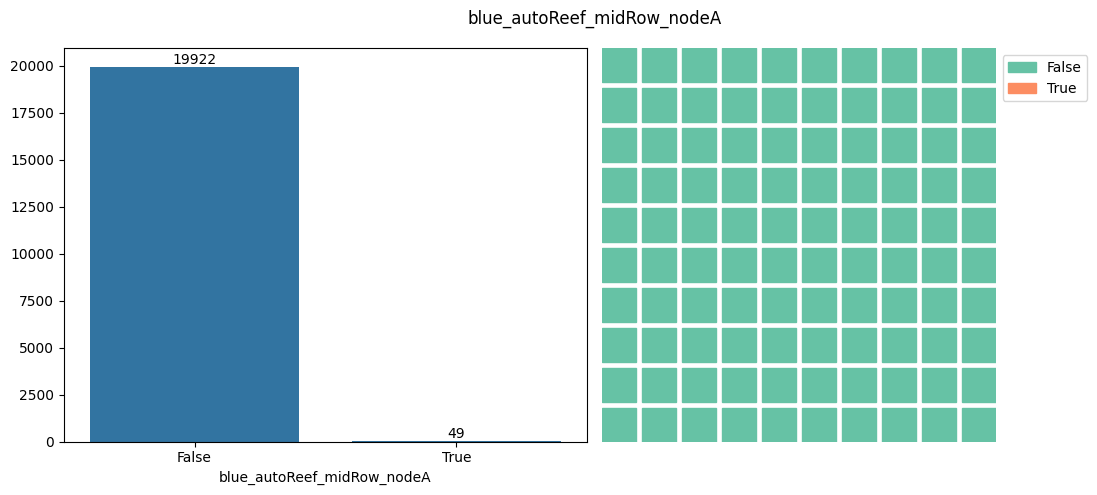

In [66]:
cat_plot("blue_autoReef_midRow_nodeA")

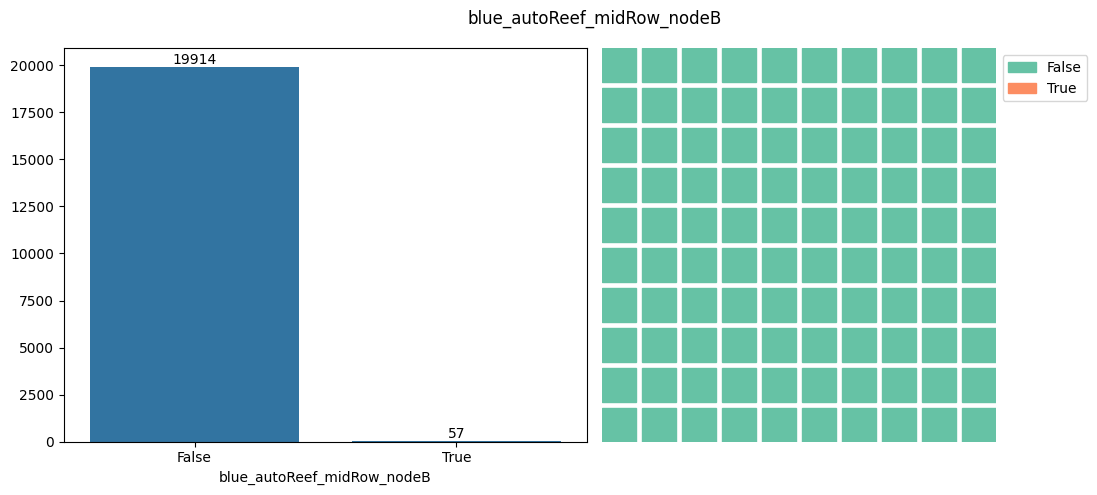

In [67]:
cat_plot("blue_autoReef_midRow_nodeB")

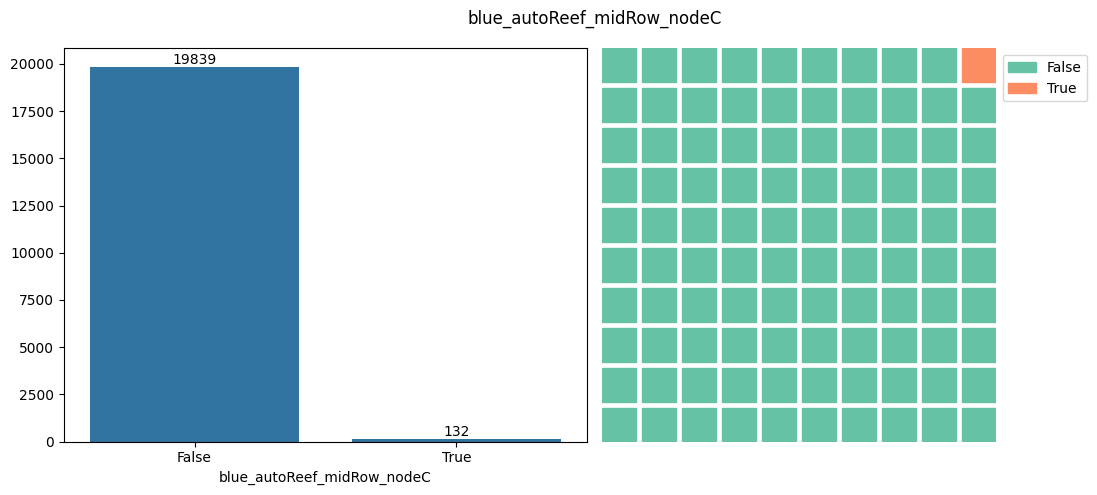

In [68]:
cat_plot("blue_autoReef_midRow_nodeC")

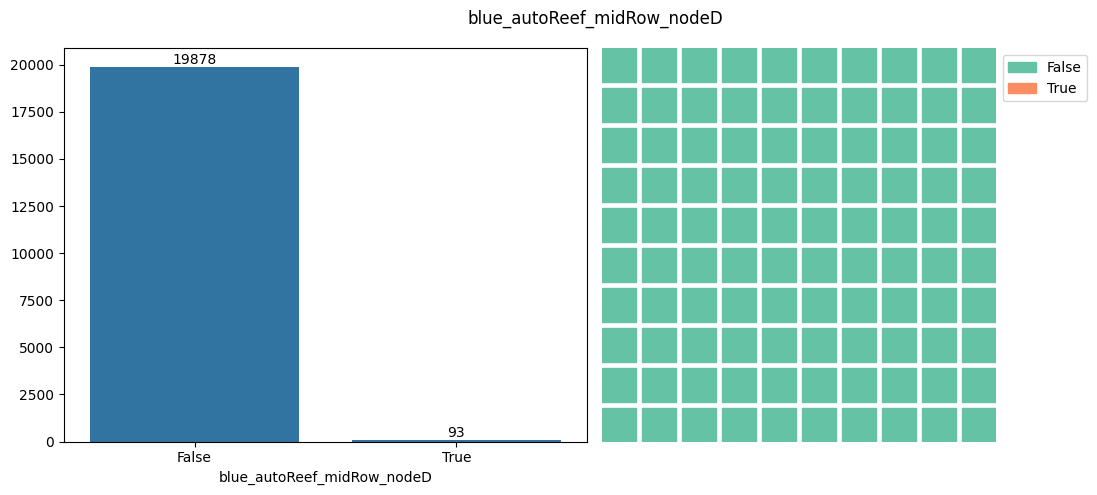

In [69]:
cat_plot("blue_autoReef_midRow_nodeD")

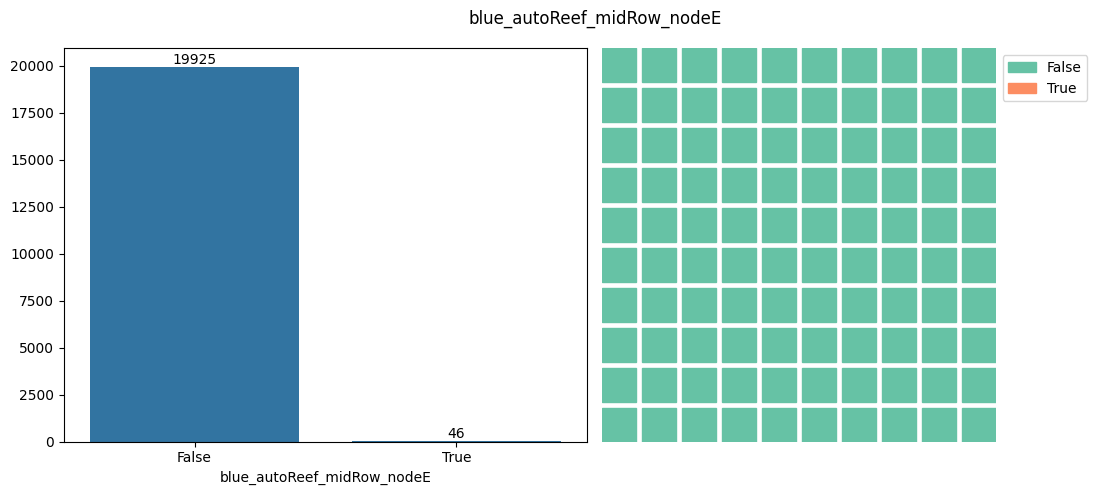

In [70]:
cat_plot("blue_autoReef_midRow_nodeE")

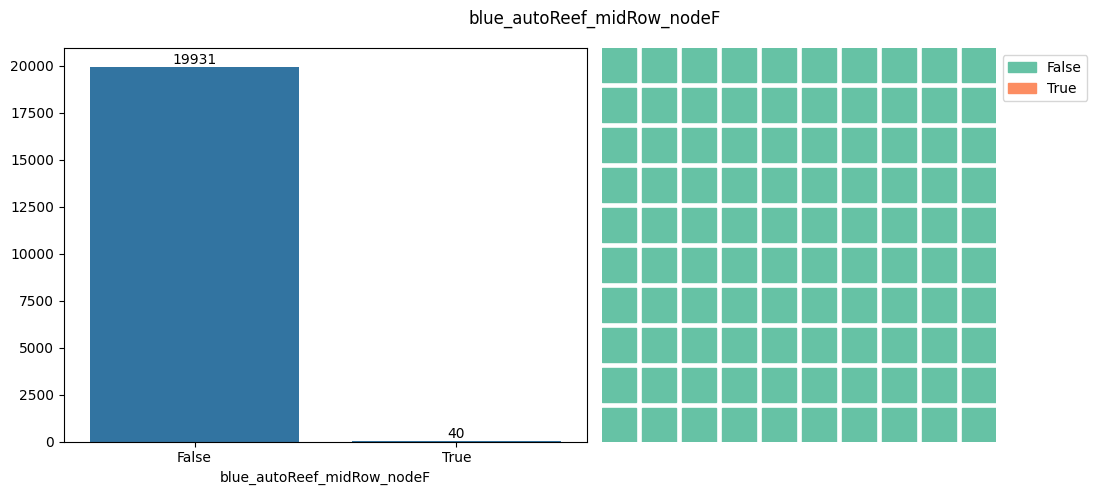

In [71]:
cat_plot("blue_autoReef_midRow_nodeF")

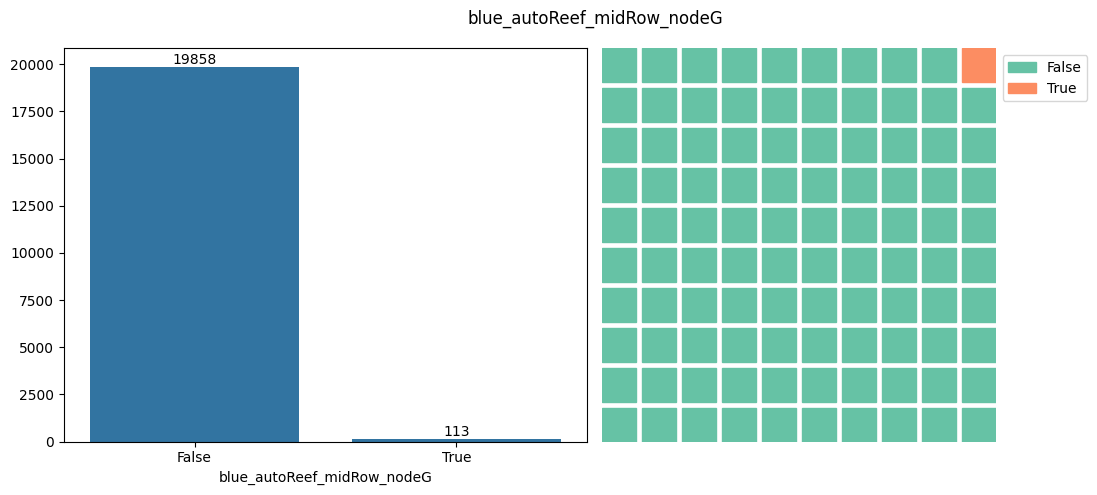

In [72]:
cat_plot("blue_autoReef_midRow_nodeG")

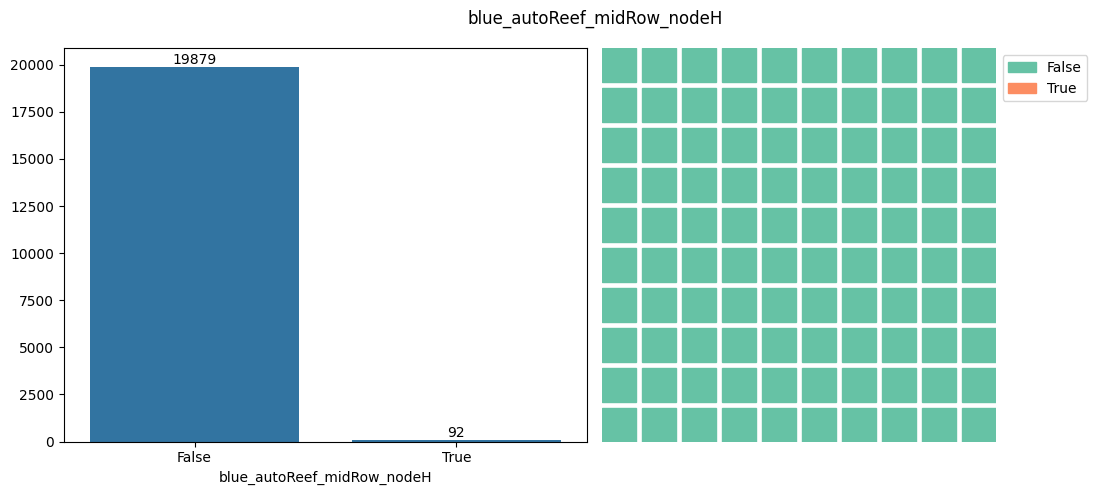

In [73]:
cat_plot("blue_autoReef_midRow_nodeH")

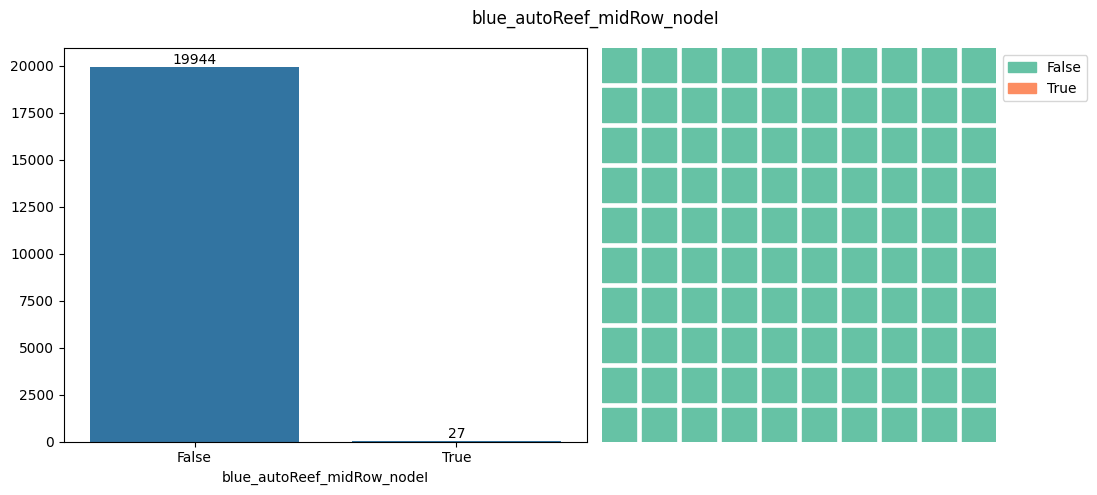

In [74]:
cat_plot("blue_autoReef_midRow_nodeI")

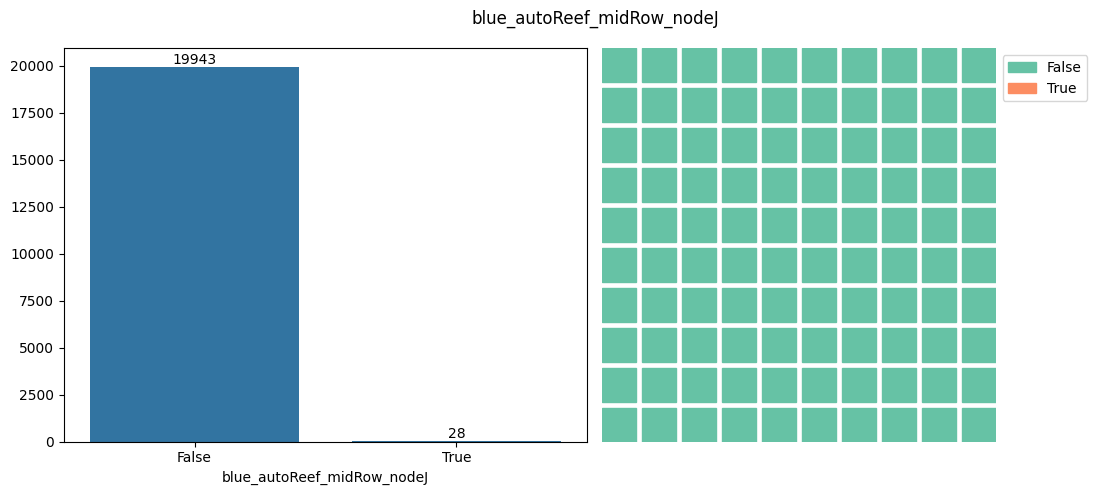

In [75]:
cat_plot("blue_autoReef_midRow_nodeJ")

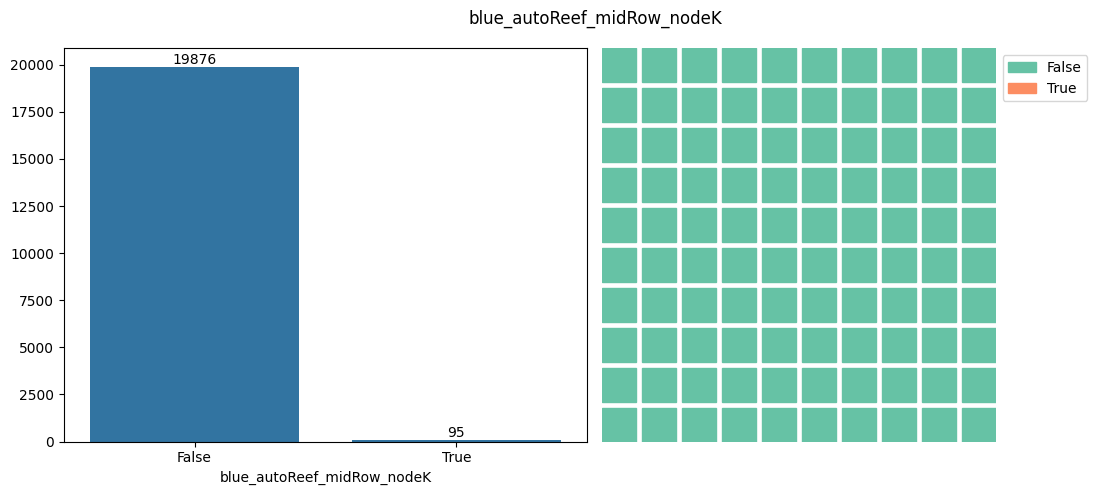

In [76]:
cat_plot("blue_autoReef_midRow_nodeK")

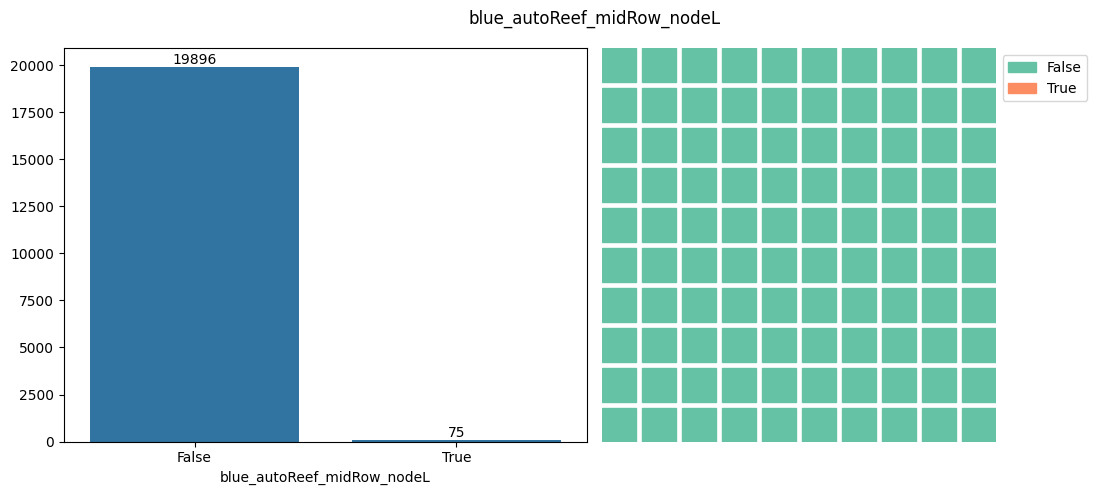

In [77]:
cat_plot("blue_autoReef_midRow_nodeL")

##### top

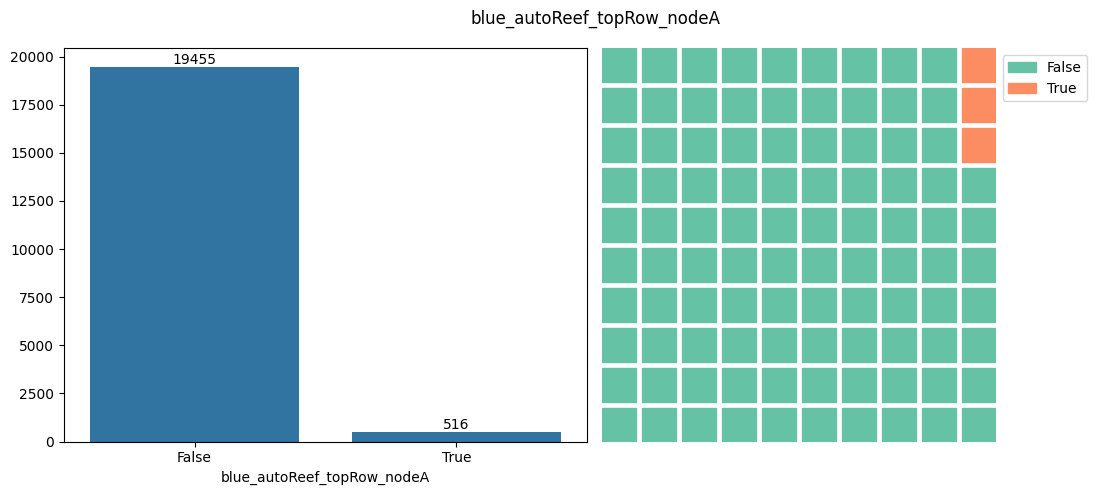

In [78]:
cat_plot("blue_autoReef_topRow_nodeA")

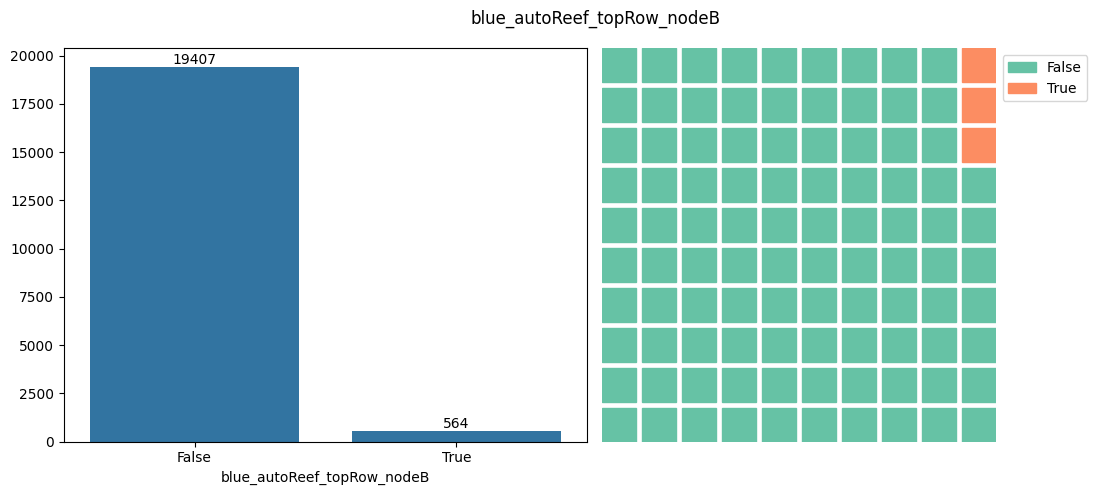

In [79]:
cat_plot("blue_autoReef_topRow_nodeB")

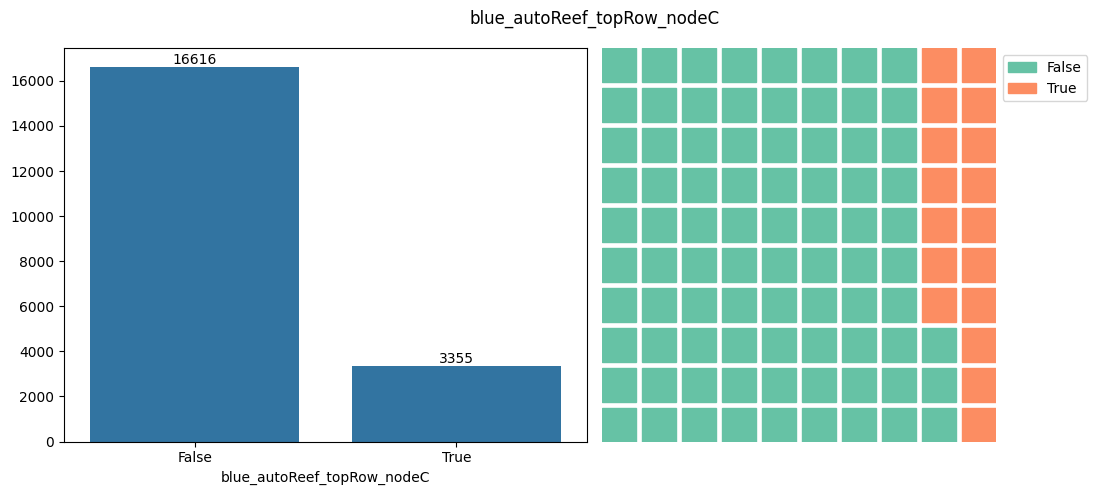

In [80]:
cat_plot("blue_autoReef_topRow_nodeC")

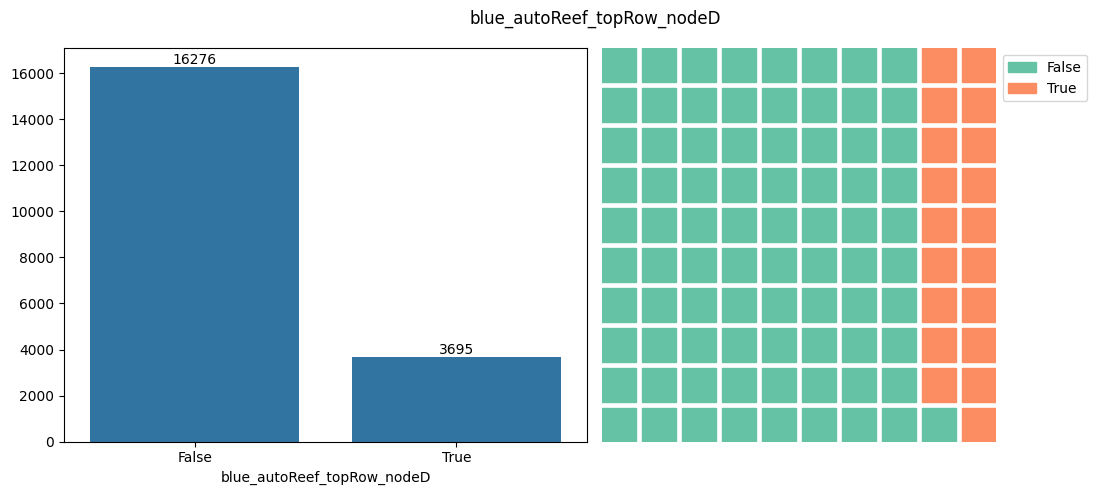

In [81]:
cat_plot("blue_autoReef_topRow_nodeD")

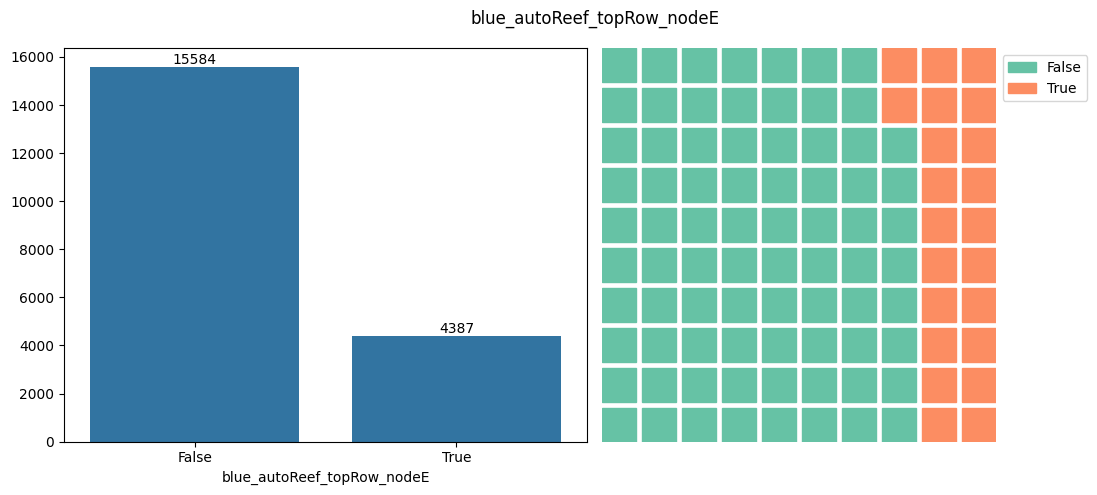

In [82]:
cat_plot("blue_autoReef_topRow_nodeE")

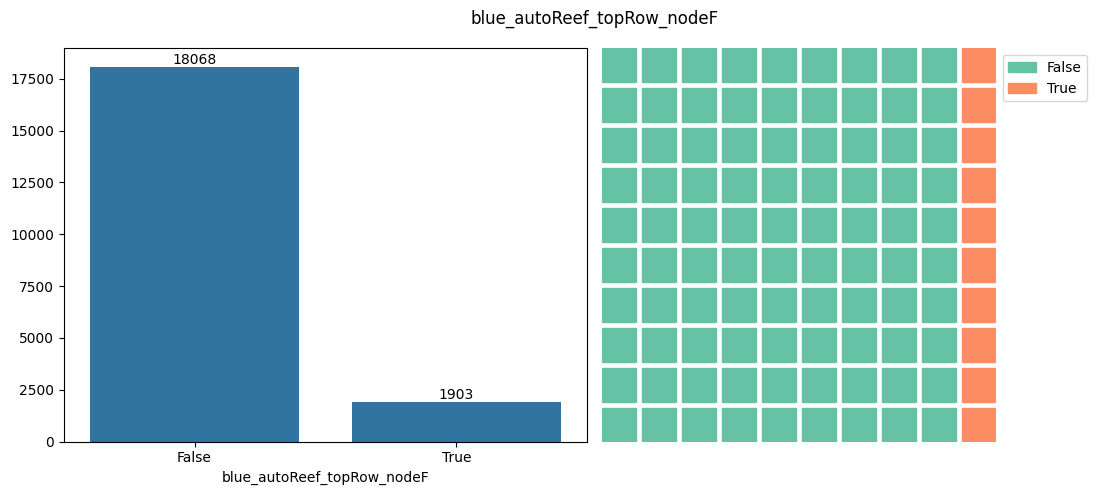

In [83]:
cat_plot("blue_autoReef_topRow_nodeF")

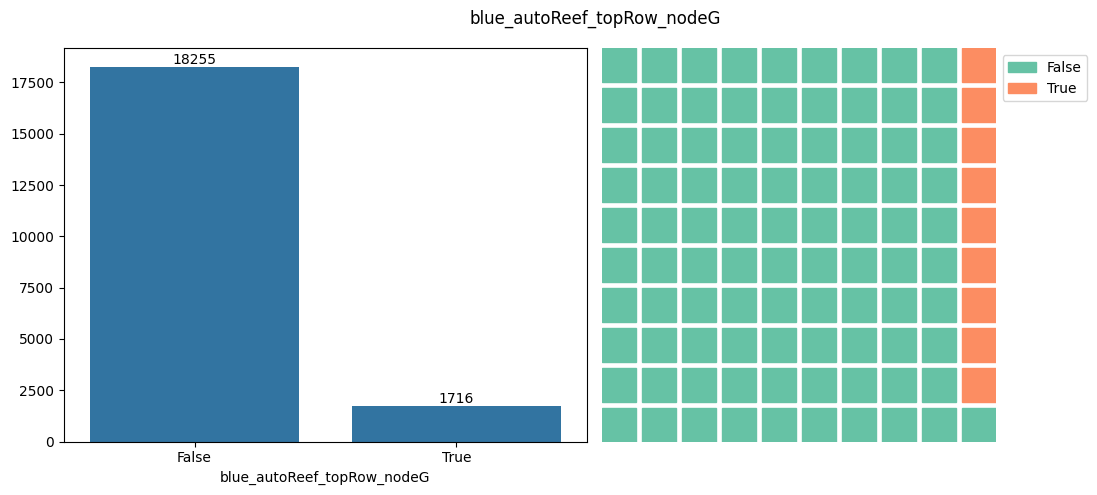

In [84]:
cat_plot("blue_autoReef_topRow_nodeG")

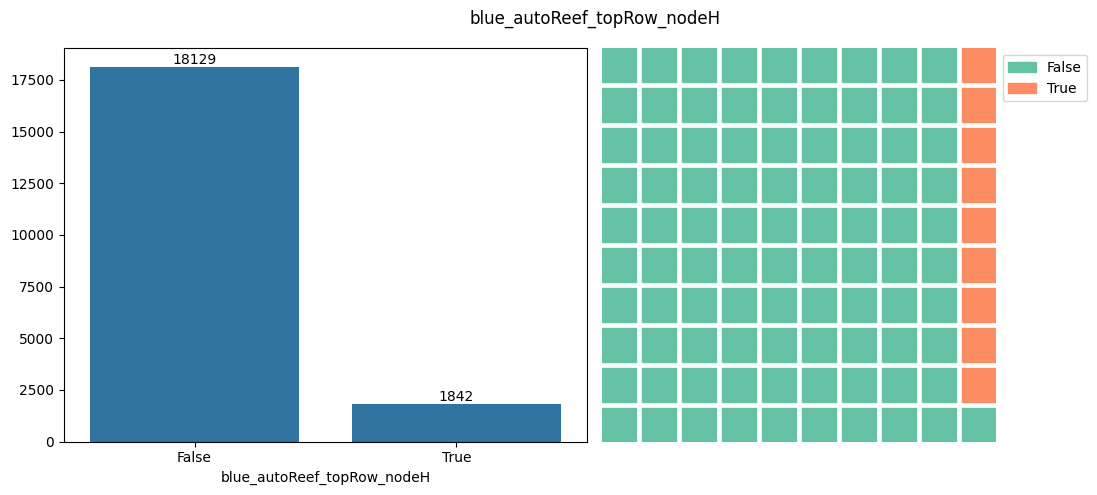

In [85]:
cat_plot("blue_autoReef_topRow_nodeH")

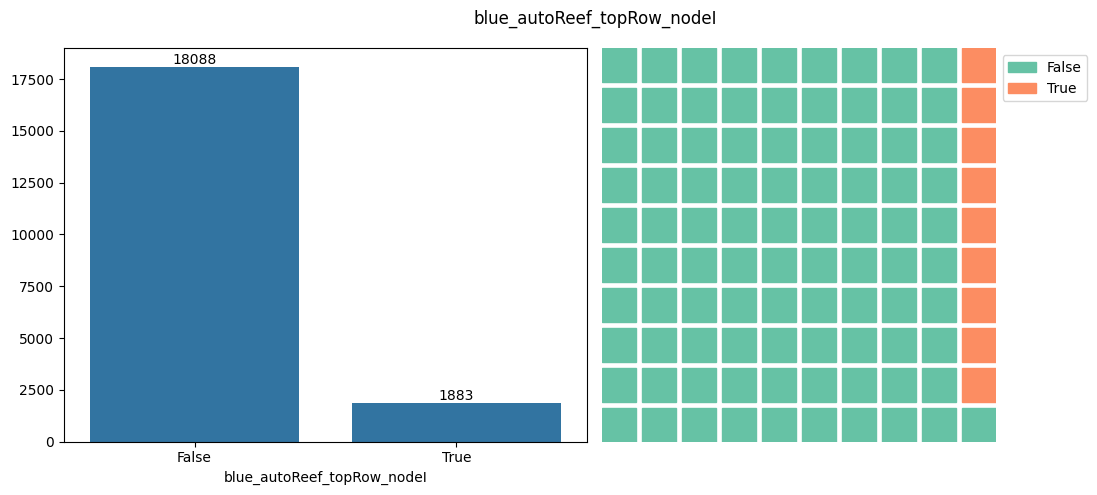

In [86]:
cat_plot("blue_autoReef_topRow_nodeI")

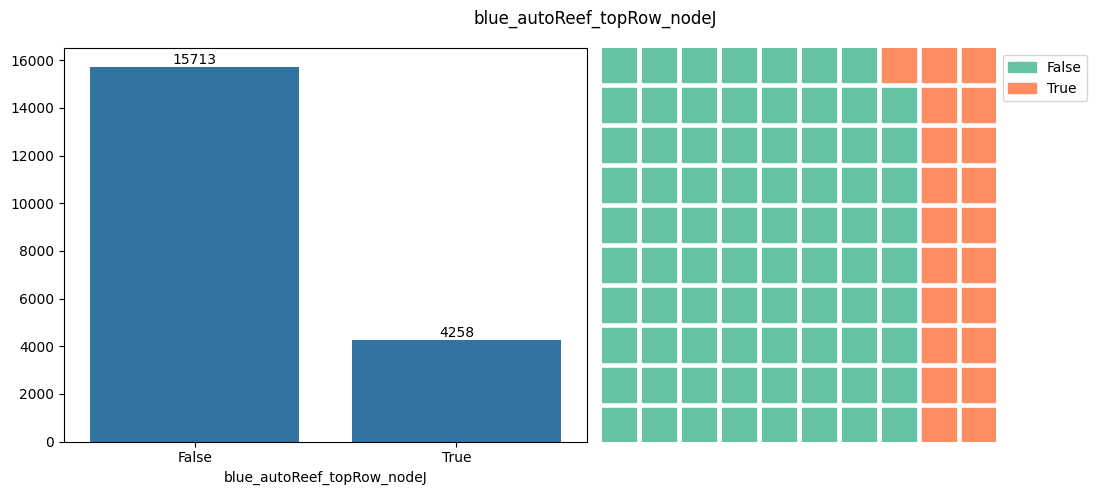

In [87]:
cat_plot("blue_autoReef_topRow_nodeJ")

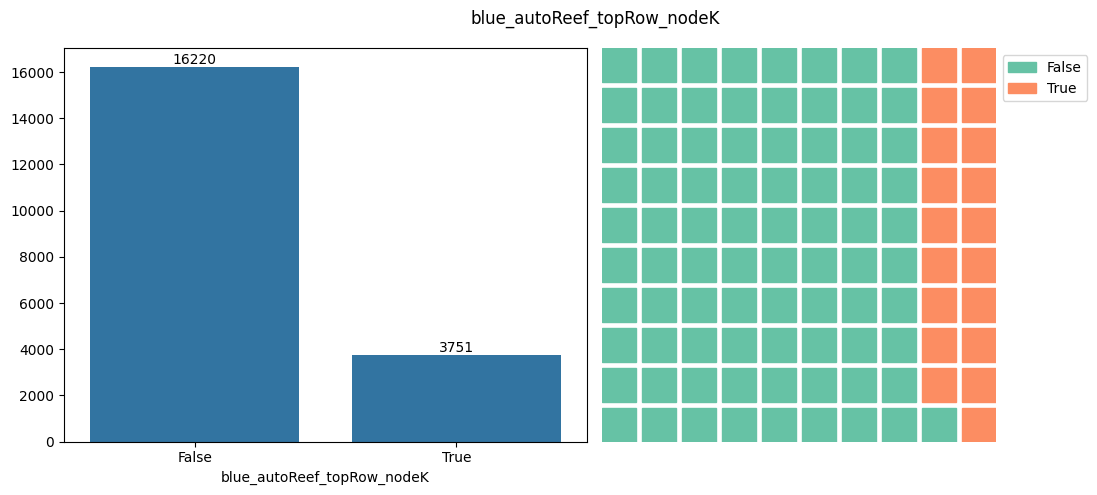

In [88]:
cat_plot("blue_autoReef_topRow_nodeK")

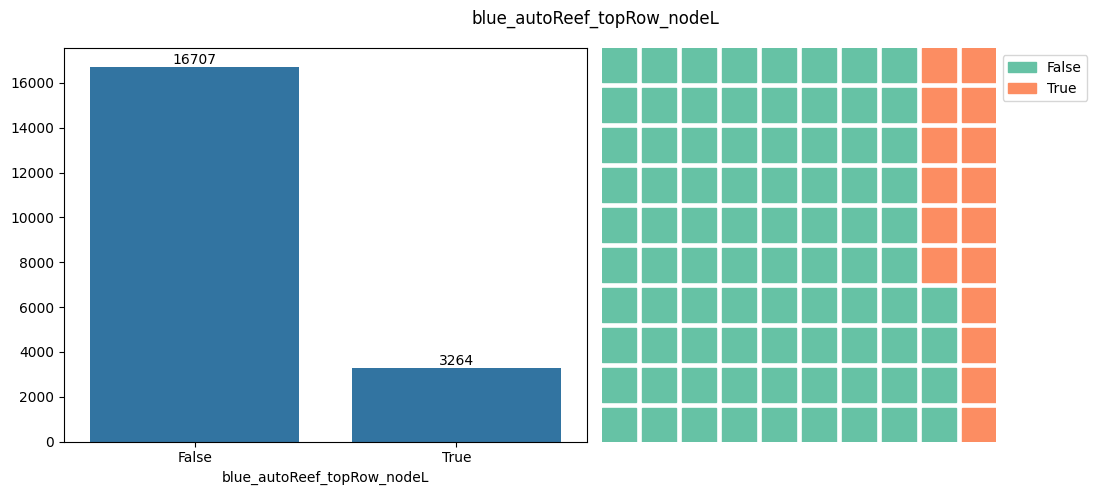

In [89]:
cat_plot("blue_autoReef_topRow_nodeL")

### Teleop

#### blue reef

##### bottom

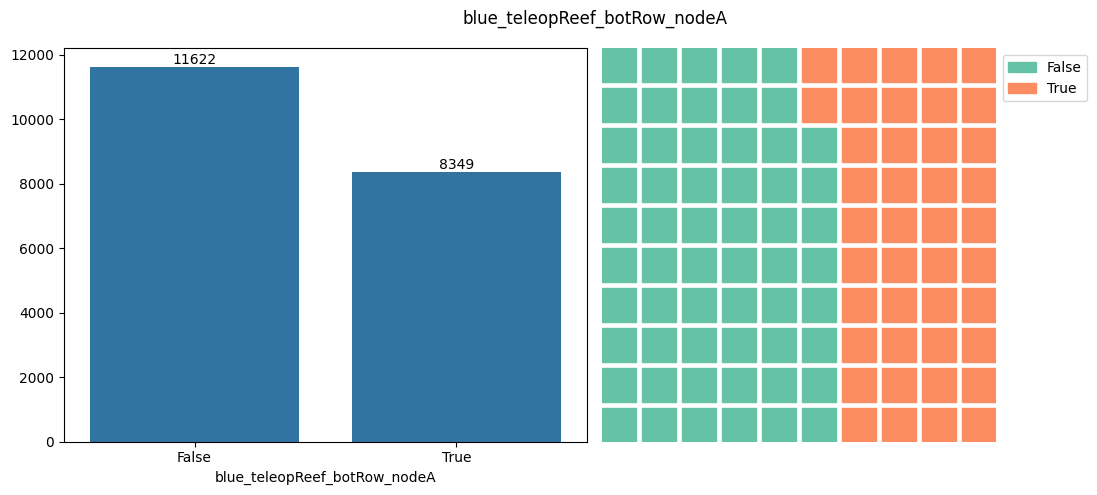

In [90]:
cat_plot("blue_teleopReef_botRow_nodeA")

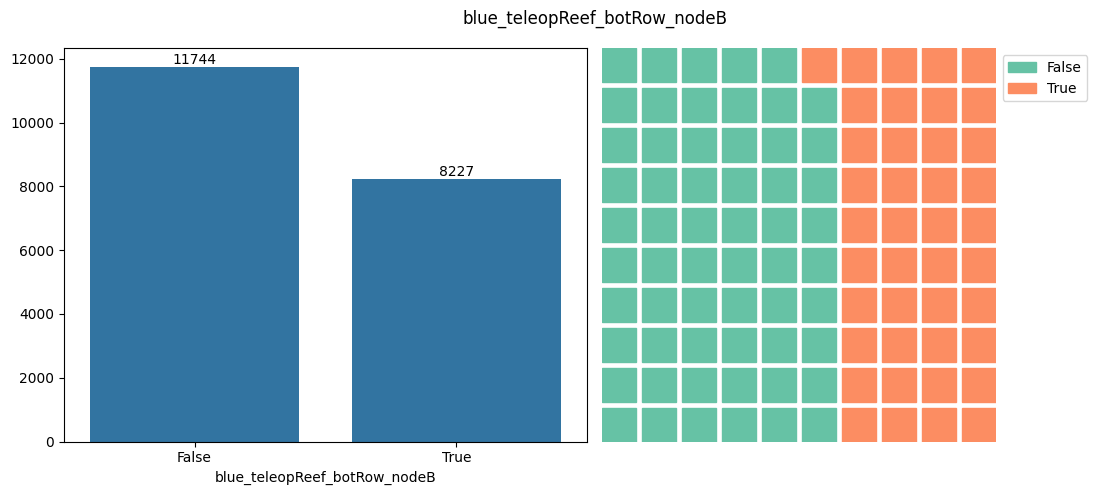

In [91]:
cat_plot("blue_teleopReef_botRow_nodeB")

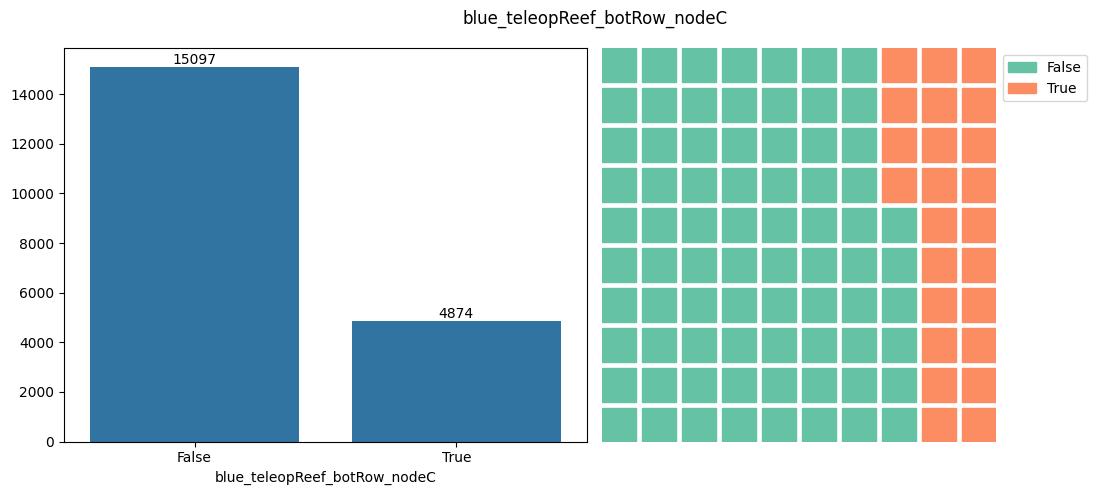

In [92]:
cat_plot("blue_teleopReef_botRow_nodeC")

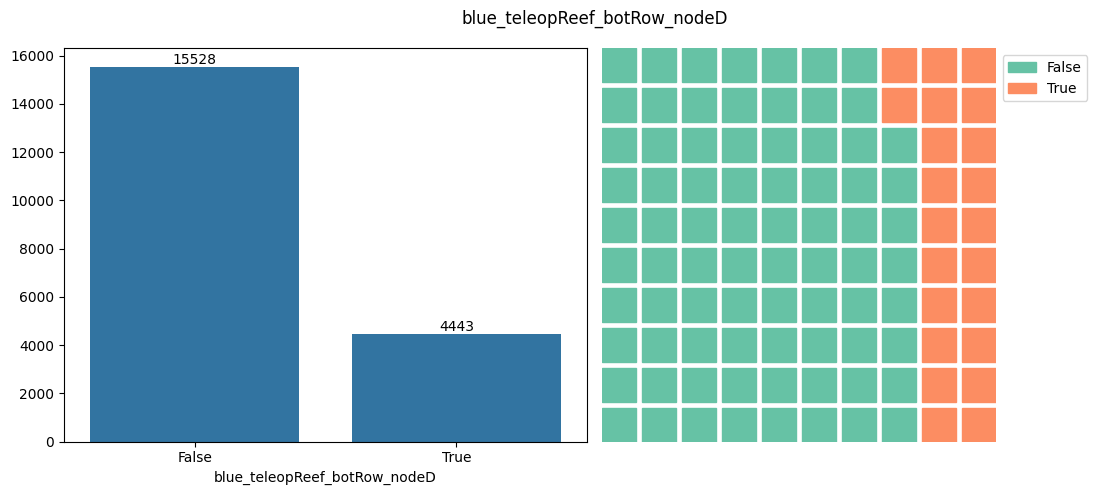

In [93]:
cat_plot("blue_teleopReef_botRow_nodeD")

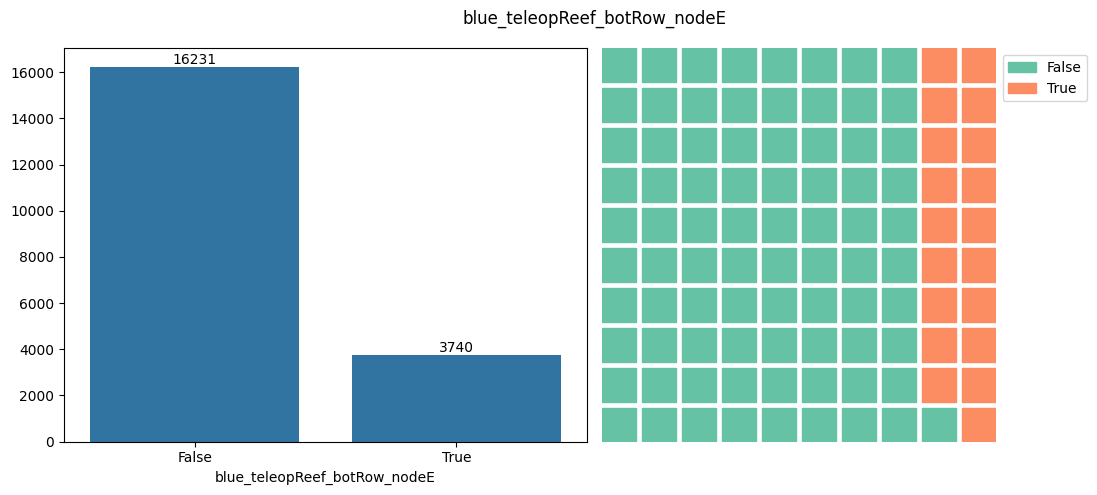

In [94]:
cat_plot("blue_teleopReef_botRow_nodeE")

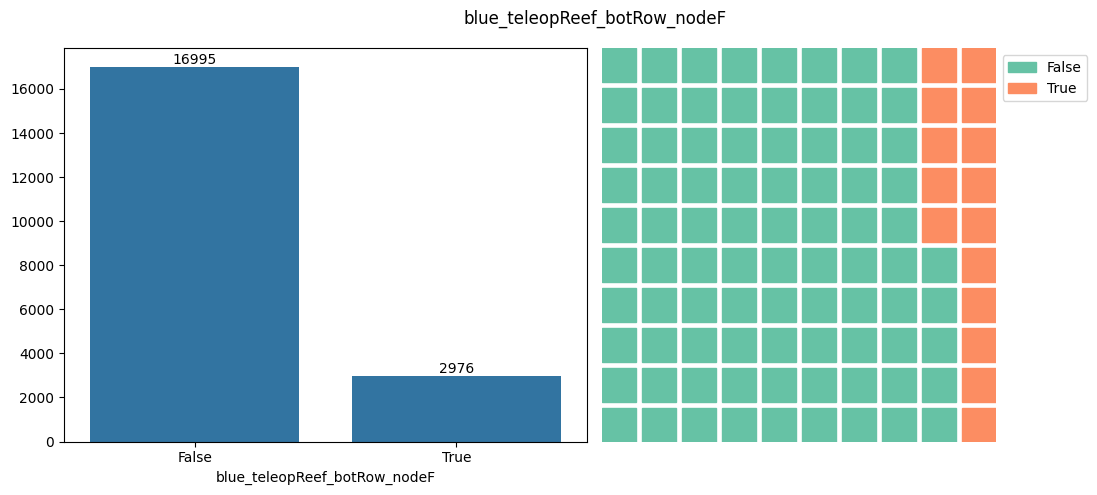

In [95]:
cat_plot("blue_teleopReef_botRow_nodeF")

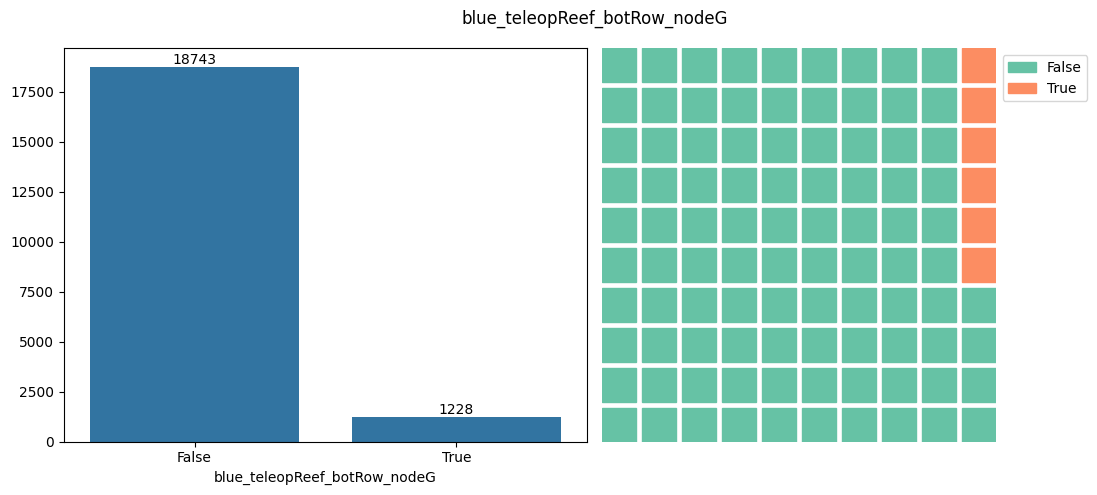

In [96]:
cat_plot("blue_teleopReef_botRow_nodeG")

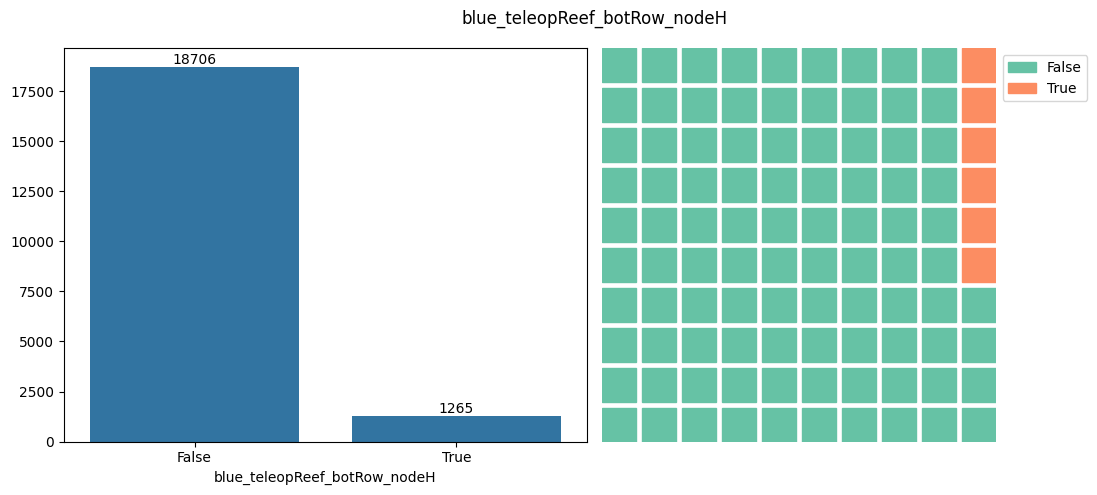

In [97]:
cat_plot("blue_teleopReef_botRow_nodeH")

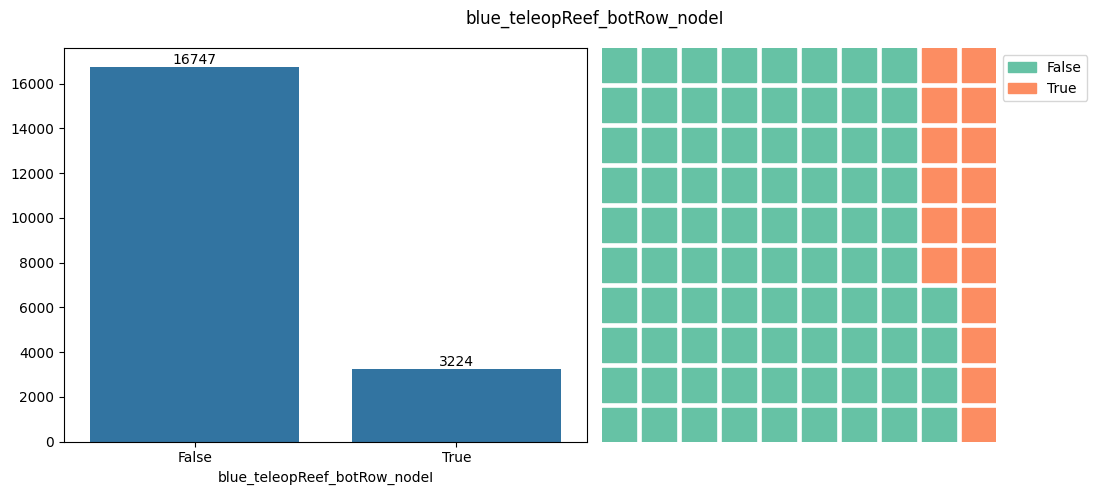

In [98]:
cat_plot("blue_teleopReef_botRow_nodeI")

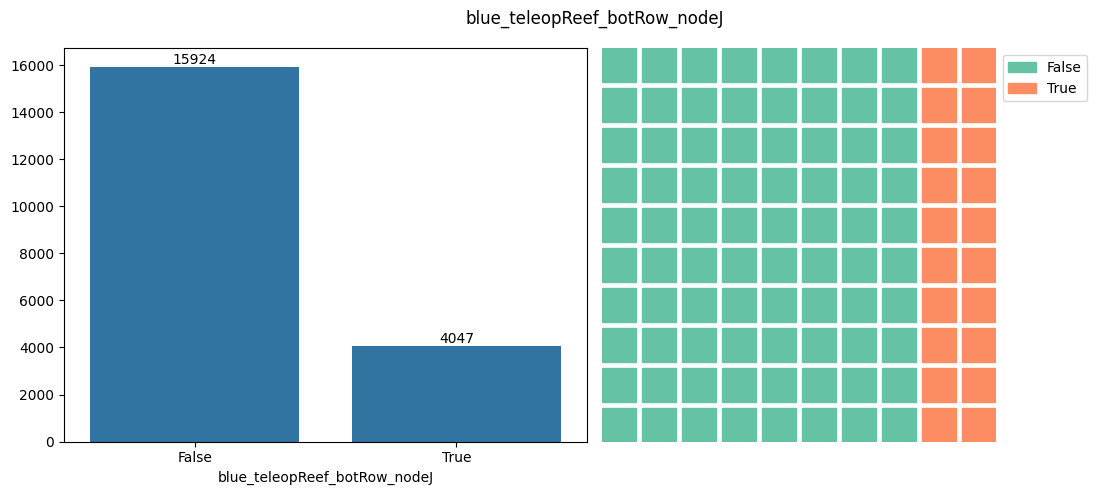

In [99]:
cat_plot("blue_teleopReef_botRow_nodeJ")

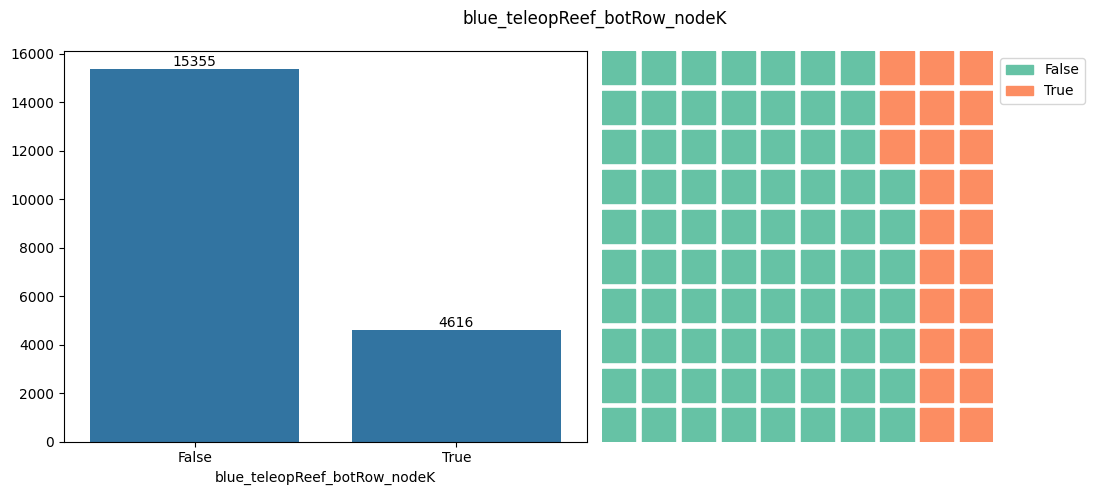

In [100]:
cat_plot("blue_teleopReef_botRow_nodeK")

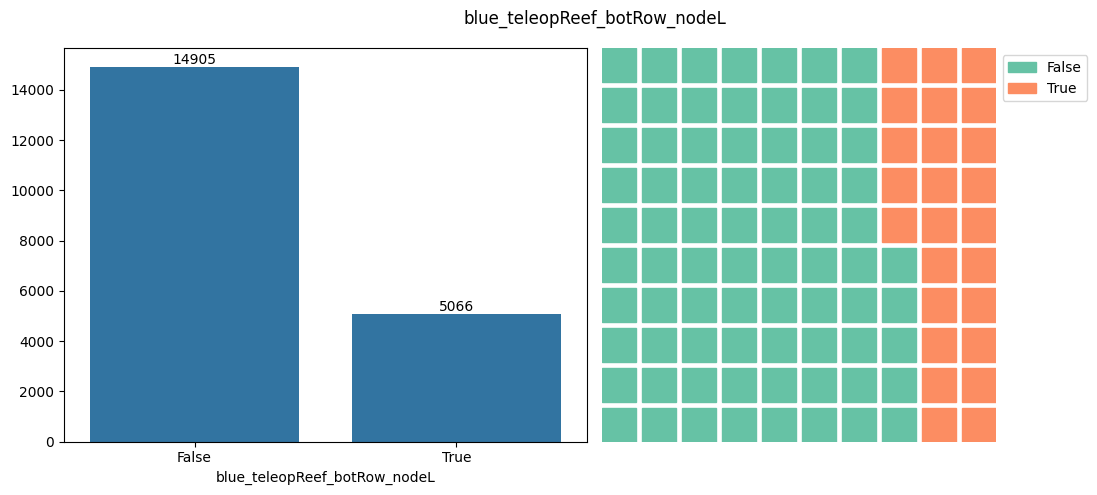

In [101]:
cat_plot("blue_teleopReef_botRow_nodeL")

##### middle

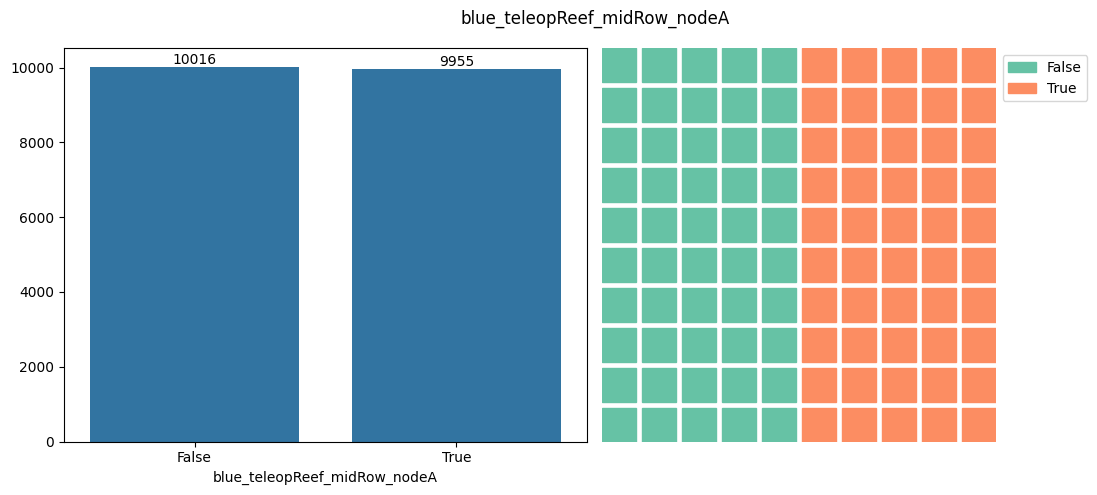

In [102]:
cat_plot("blue_teleopReef_midRow_nodeA")

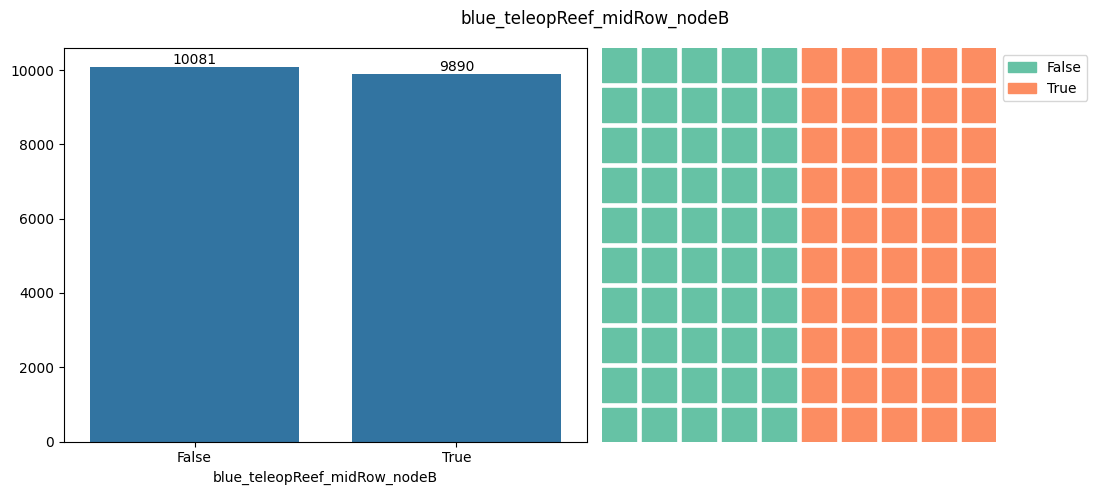

In [103]:
cat_plot("blue_teleopReef_midRow_nodeB")

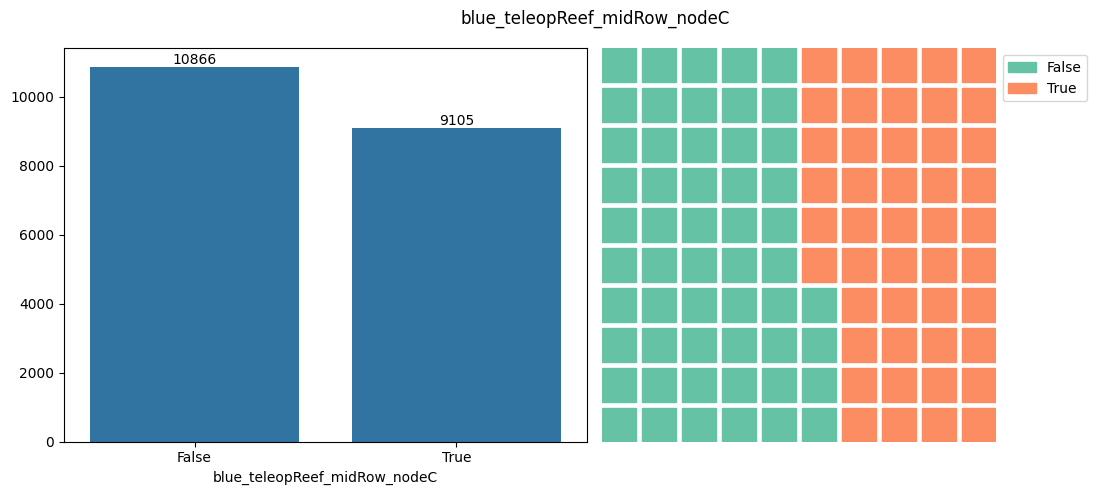

In [104]:
cat_plot("blue_teleopReef_midRow_nodeC")

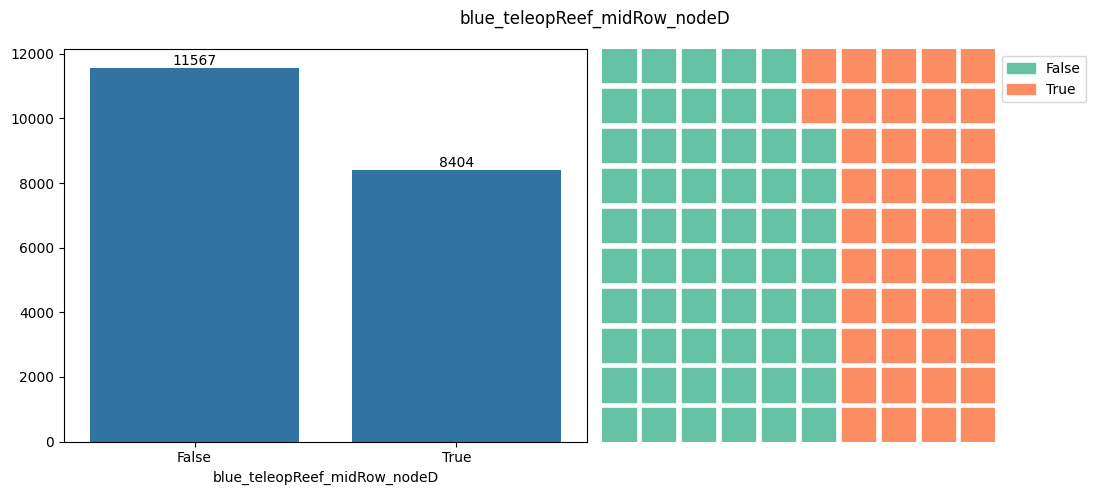

In [105]:
cat_plot("blue_teleopReef_midRow_nodeD")

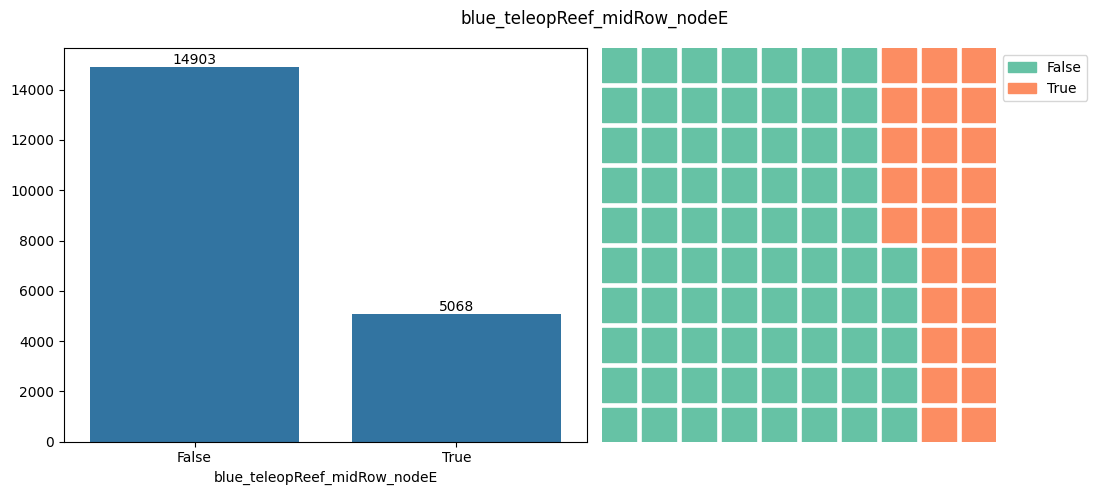

In [106]:
cat_plot("blue_teleopReef_midRow_nodeE")

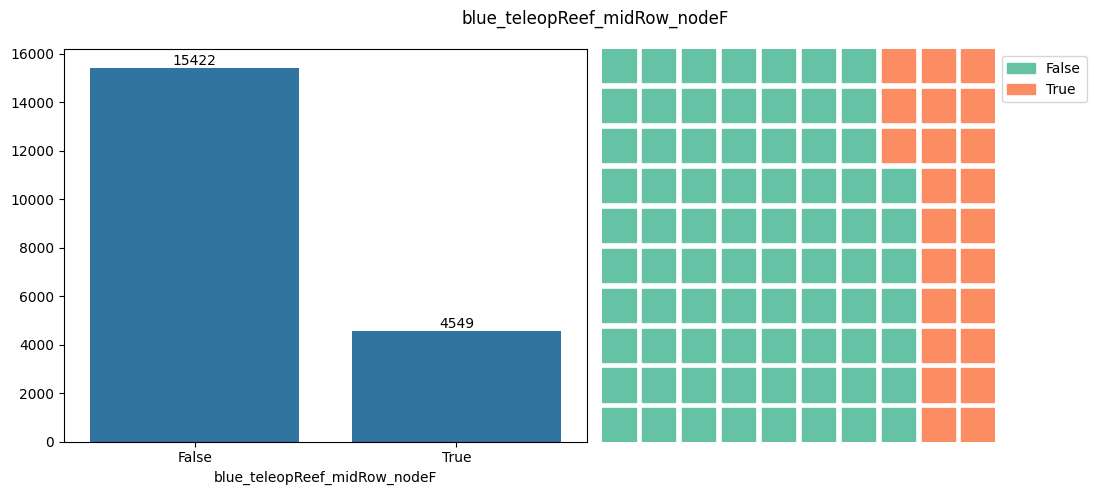

In [107]:
cat_plot("blue_teleopReef_midRow_nodeF")

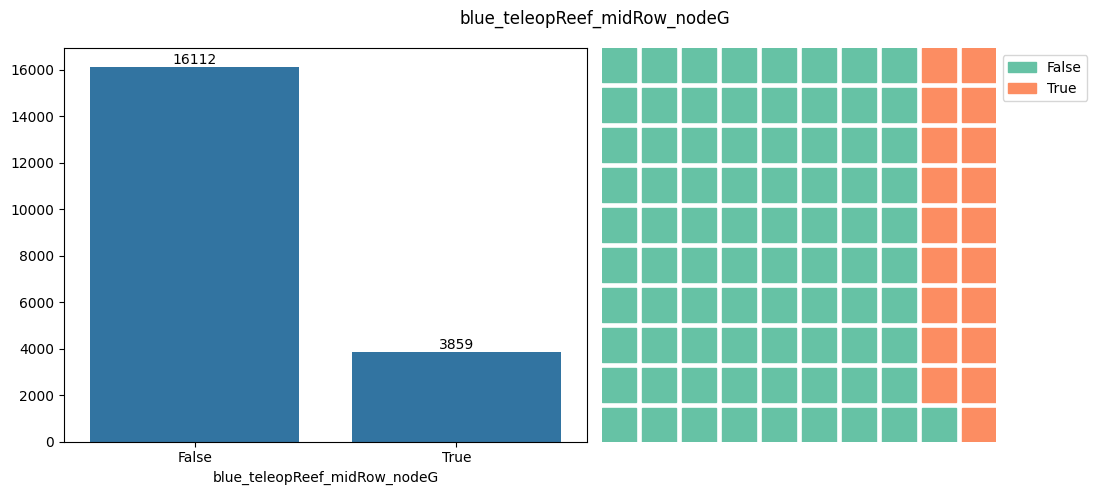

In [108]:
cat_plot("blue_teleopReef_midRow_nodeG")

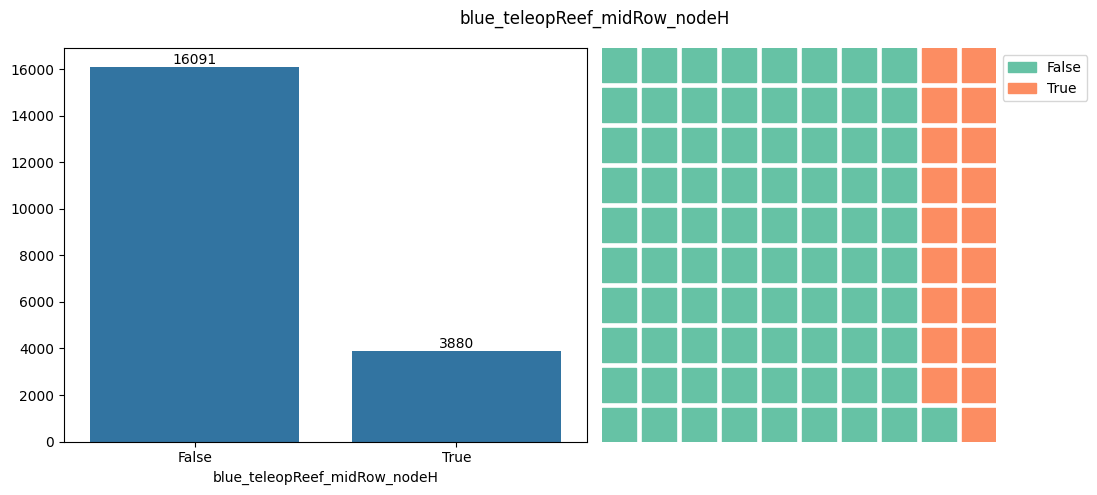

In [109]:
cat_plot("blue_teleopReef_midRow_nodeH")

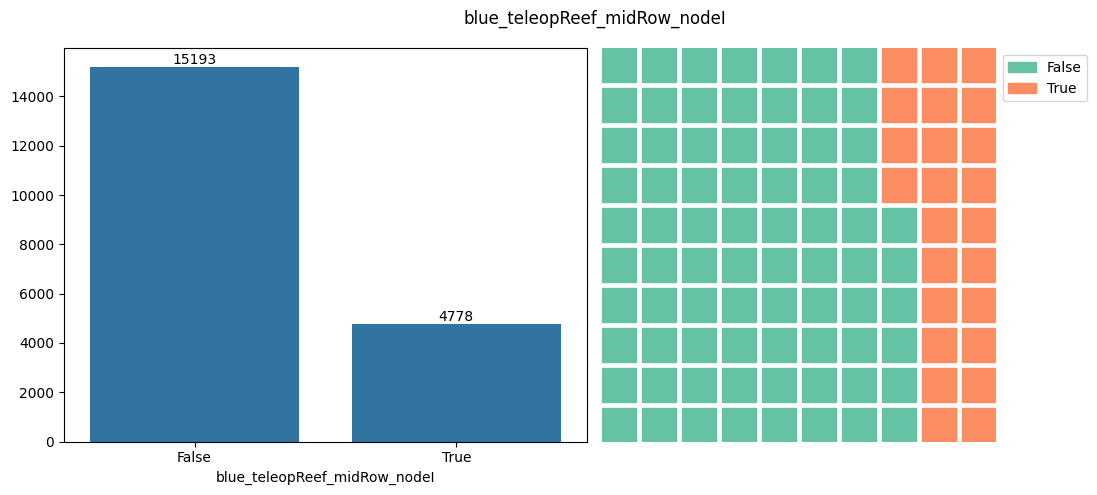

In [110]:
cat_plot("blue_teleopReef_midRow_nodeI")

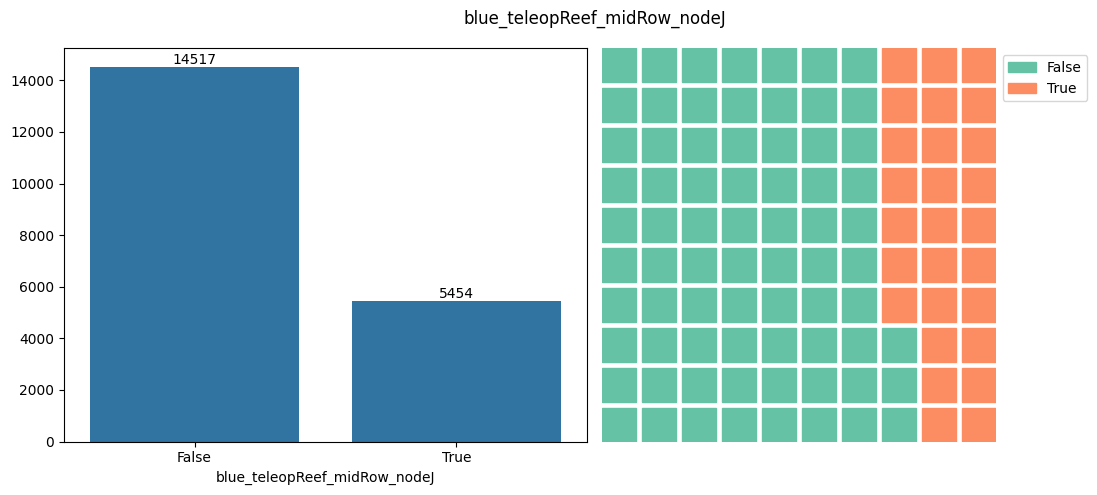

In [111]:
cat_plot("blue_teleopReef_midRow_nodeJ")

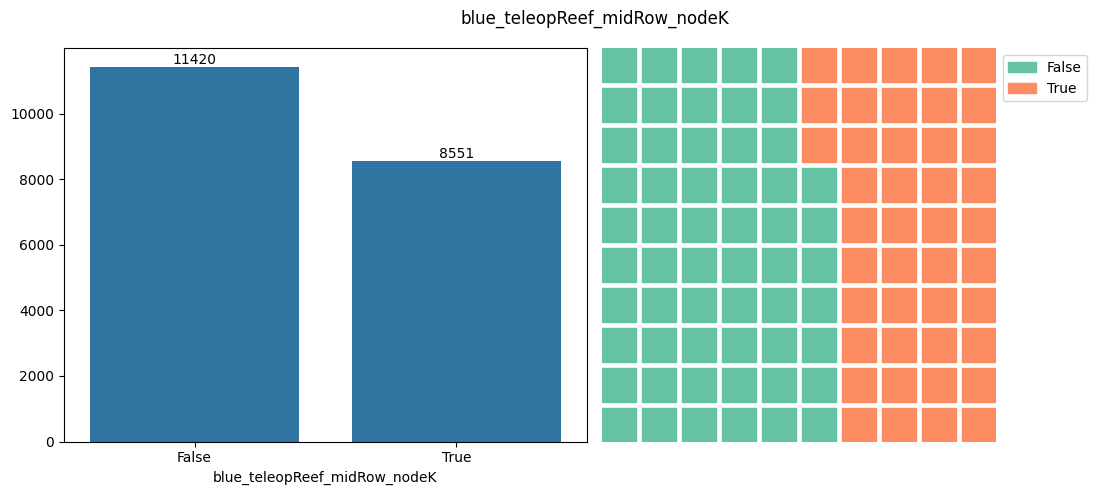

In [112]:
cat_plot("blue_teleopReef_midRow_nodeK")

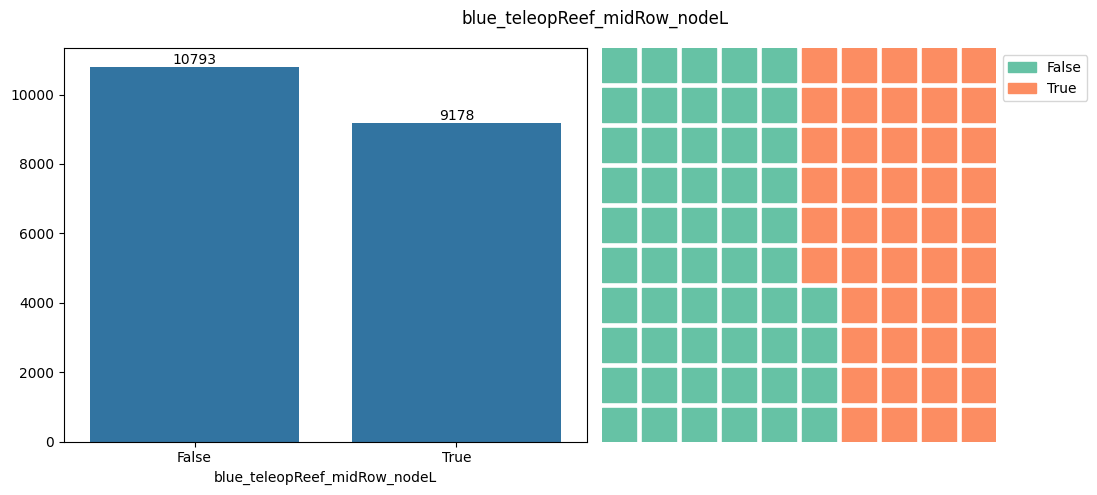

In [113]:
cat_plot("blue_teleopReef_midRow_nodeL")

##### top

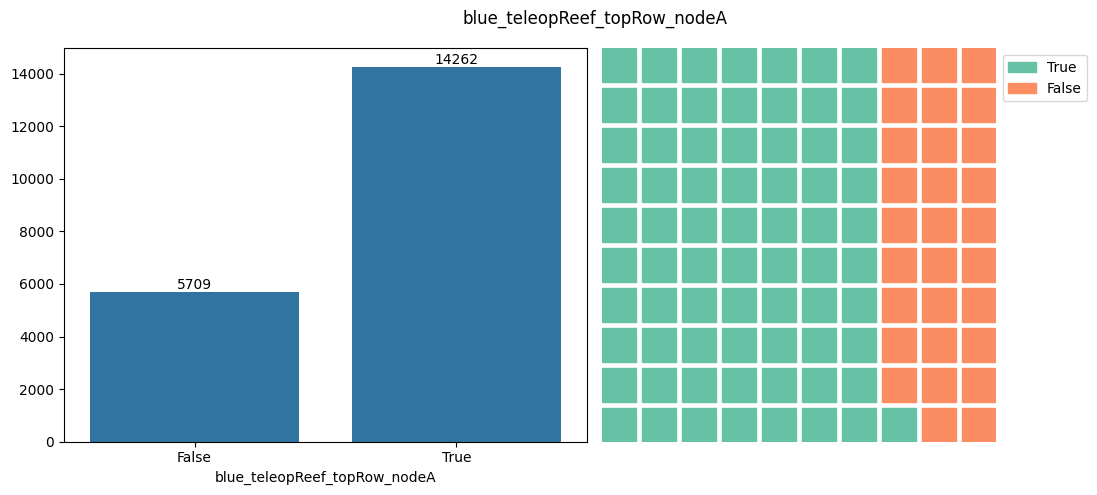

In [114]:
cat_plot("blue_teleopReef_topRow_nodeA")

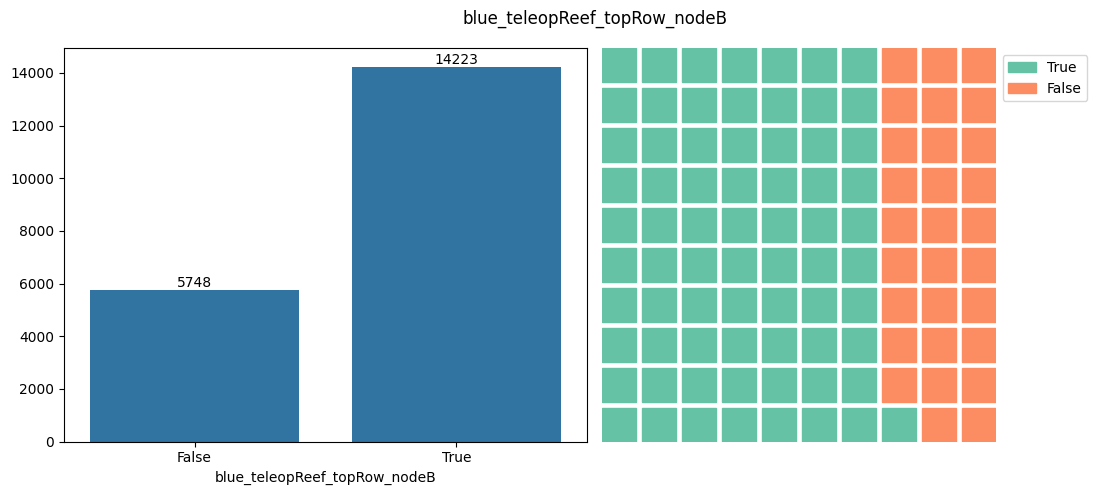

In [115]:
cat_plot("blue_teleopReef_topRow_nodeB")

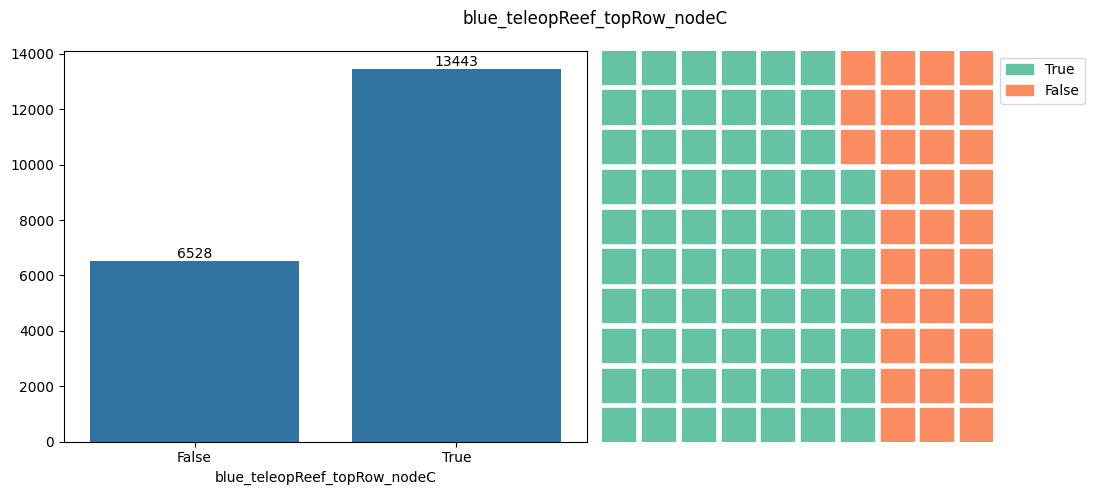

In [116]:
cat_plot("blue_teleopReef_topRow_nodeC")

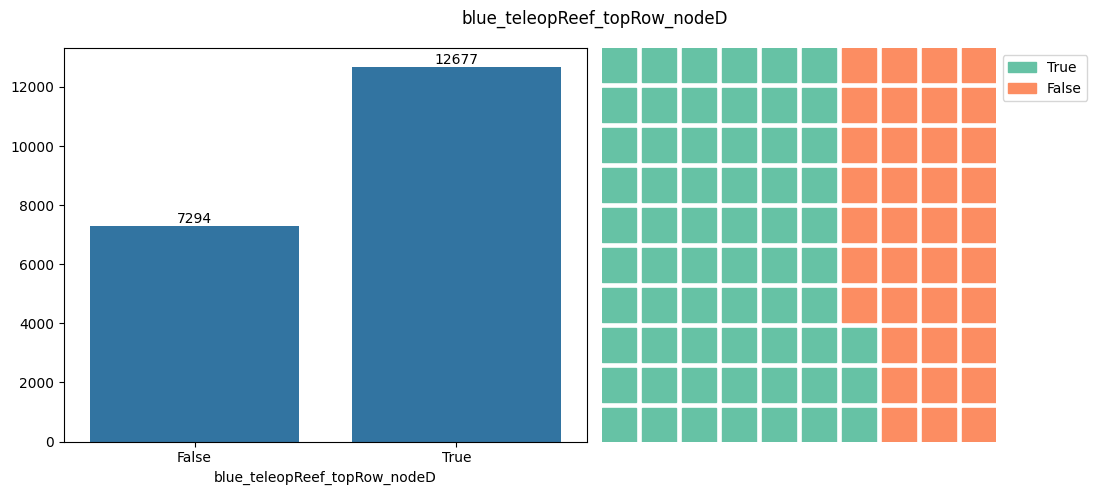

In [117]:
cat_plot("blue_teleopReef_topRow_nodeD")

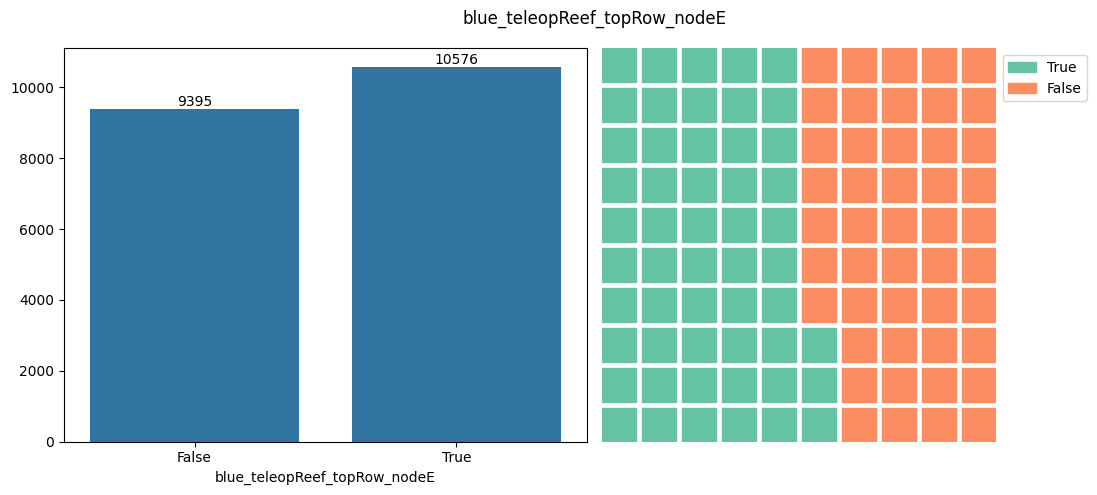

In [118]:
cat_plot("blue_teleopReef_topRow_nodeE")

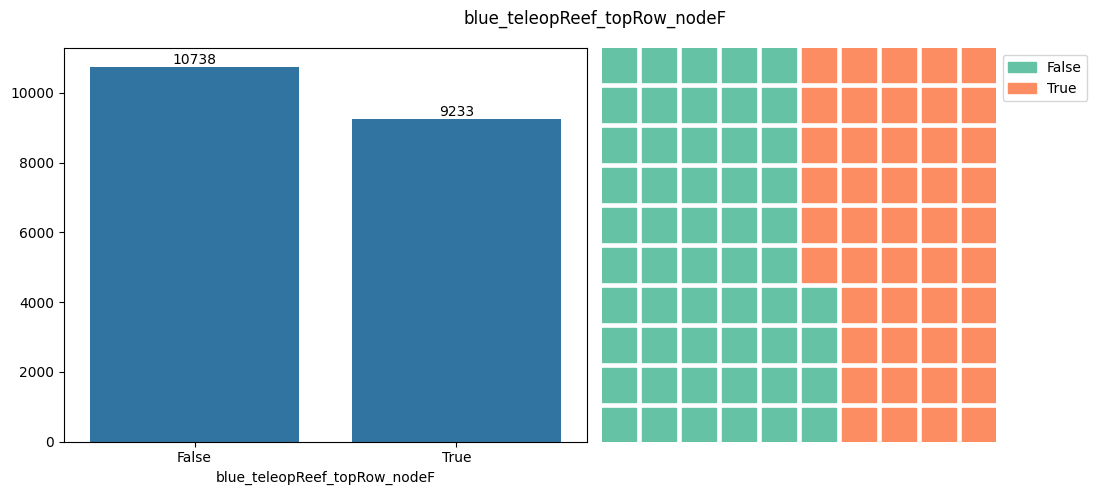

In [119]:
cat_plot("blue_teleopReef_topRow_nodeF")

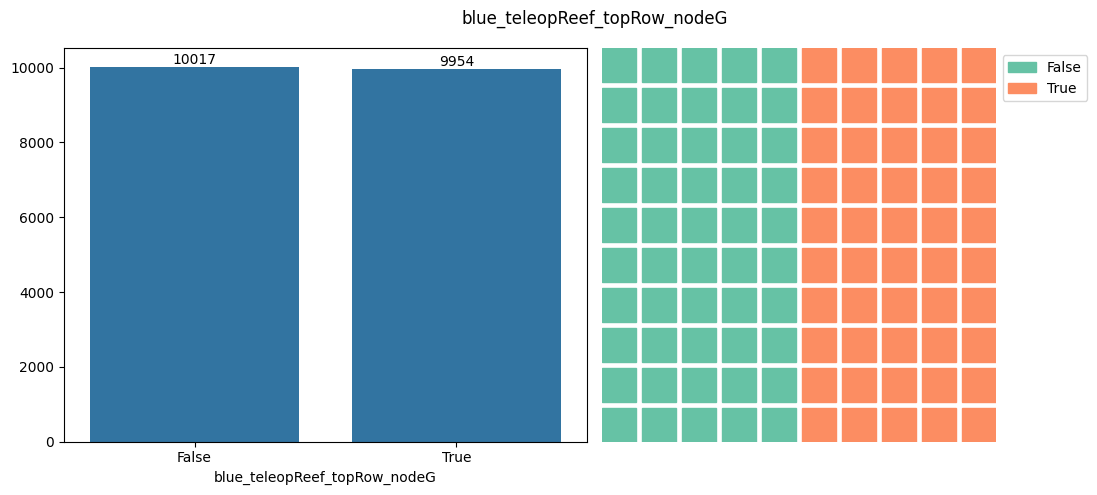

In [120]:
cat_plot("blue_teleopReef_topRow_nodeG")

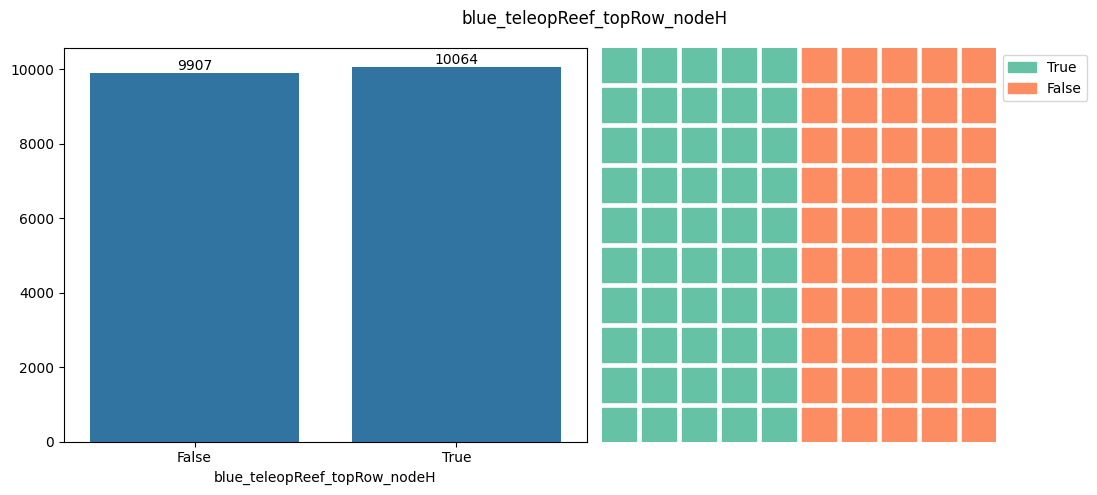

In [121]:
cat_plot("blue_teleopReef_topRow_nodeH")

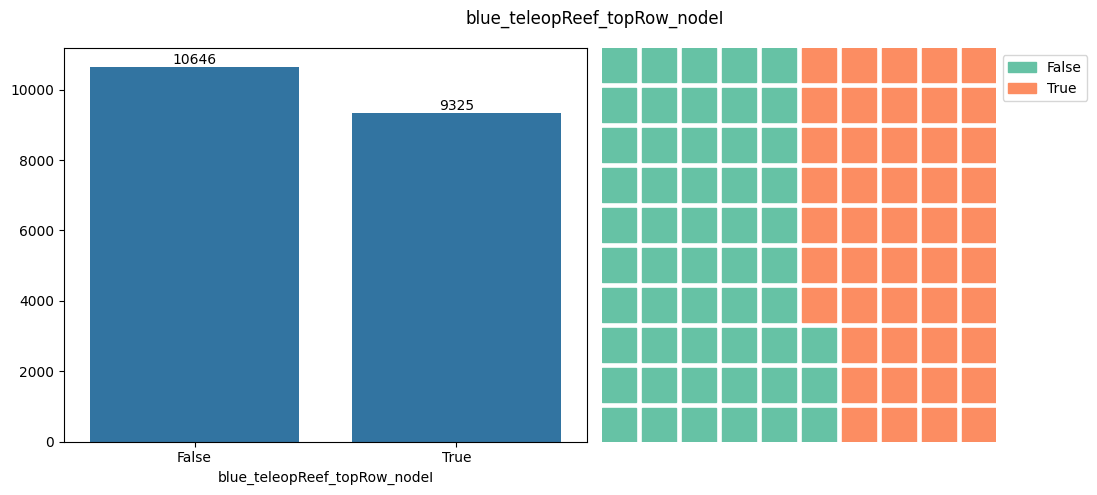

In [122]:
cat_plot("blue_teleopReef_topRow_nodeI")

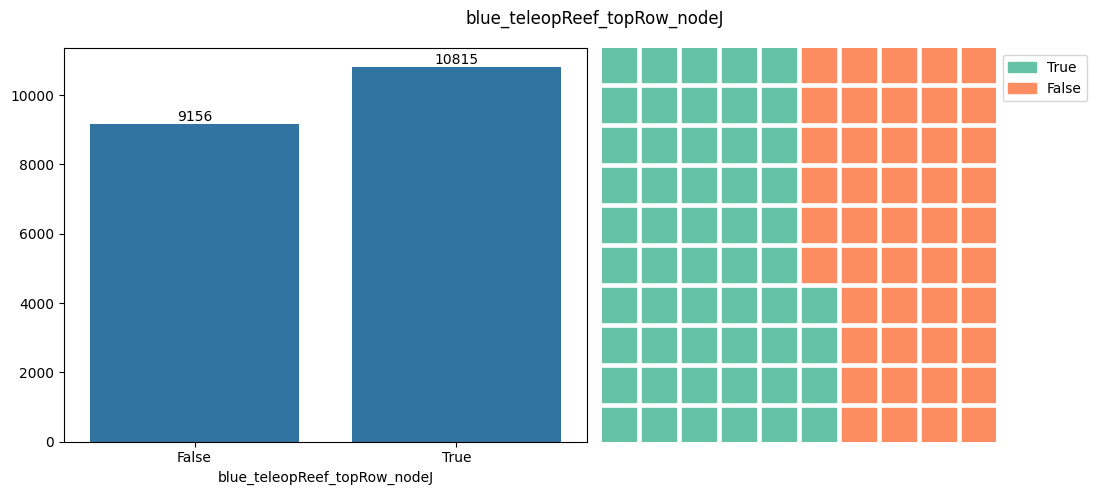

In [123]:
cat_plot("blue_teleopReef_topRow_nodeJ")

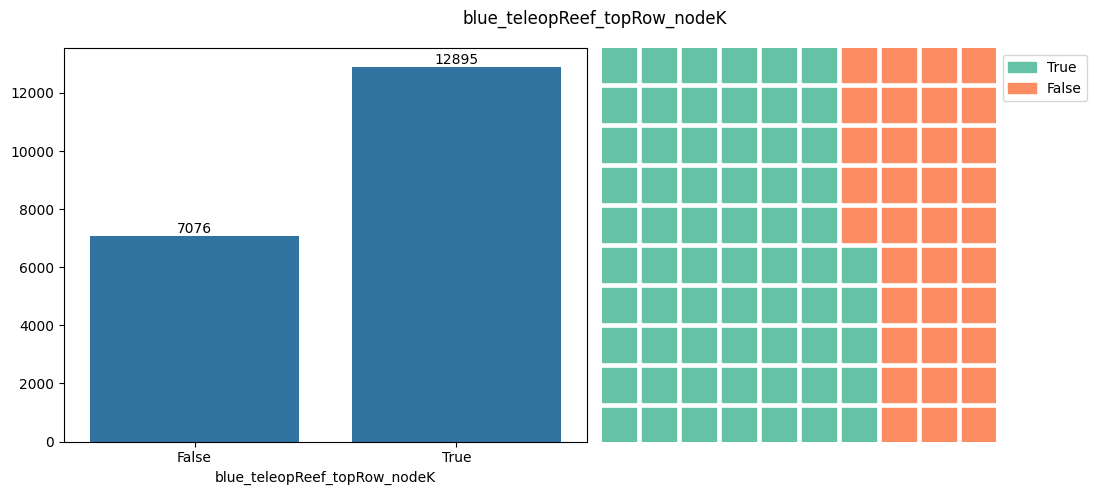

In [124]:
cat_plot("blue_teleopReef_topRow_nodeK")

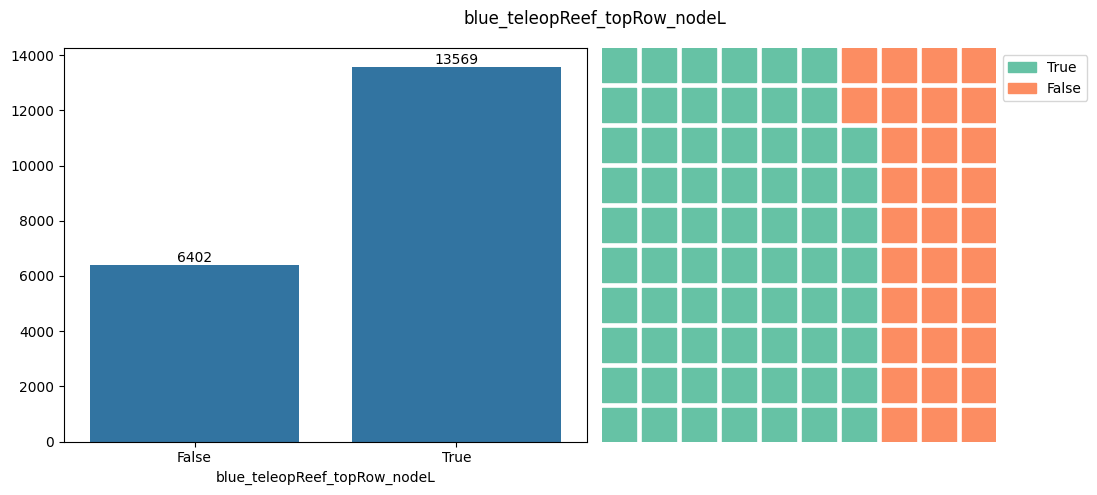

In [125]:
cat_plot("blue_teleopReef_topRow_nodeL")

#### red reef

##### bottom

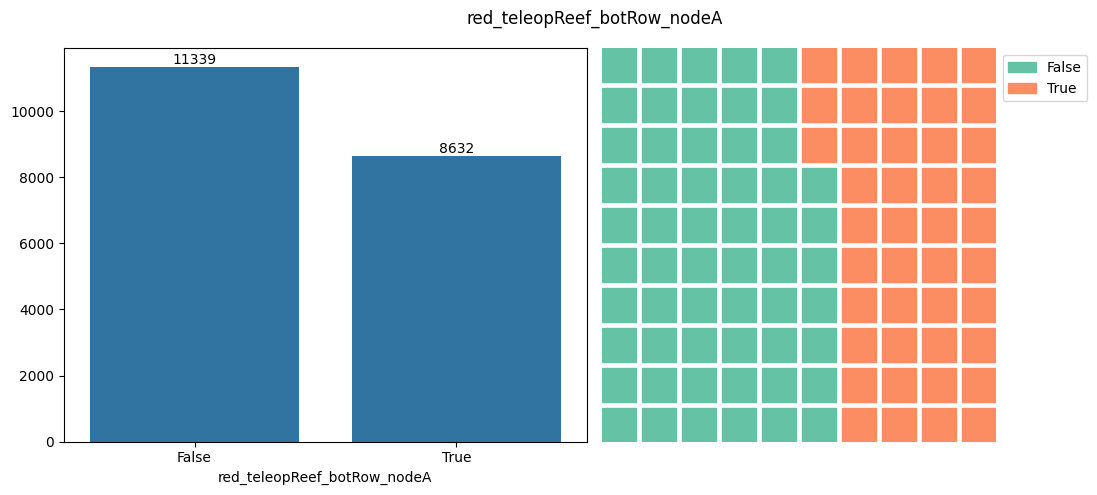

In [126]:
cat_plot("red_teleopReef_botRow_nodeA")

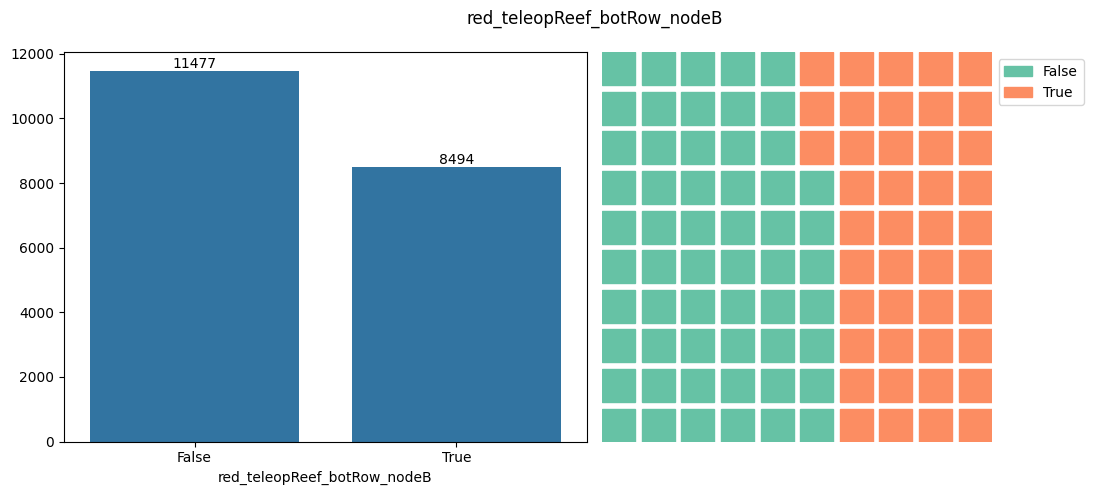

In [127]:
cat_plot("red_teleopReef_botRow_nodeB")

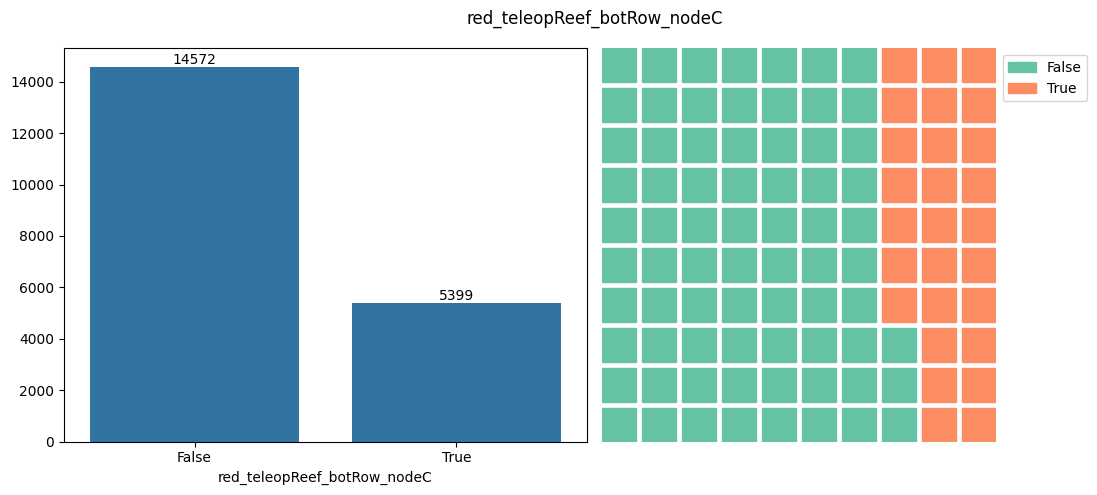

In [128]:
cat_plot("red_teleopReef_botRow_nodeC")

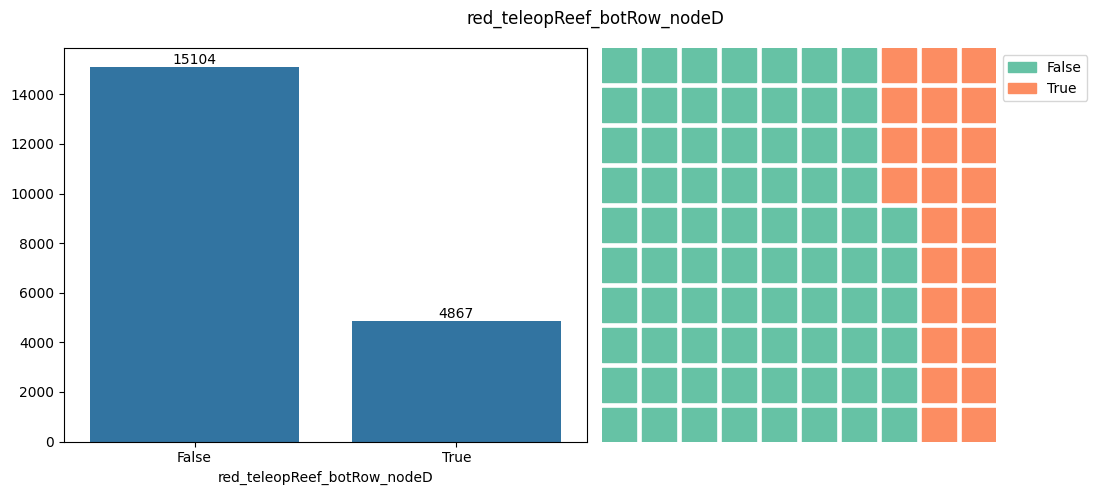

In [129]:
cat_plot("red_teleopReef_botRow_nodeD")

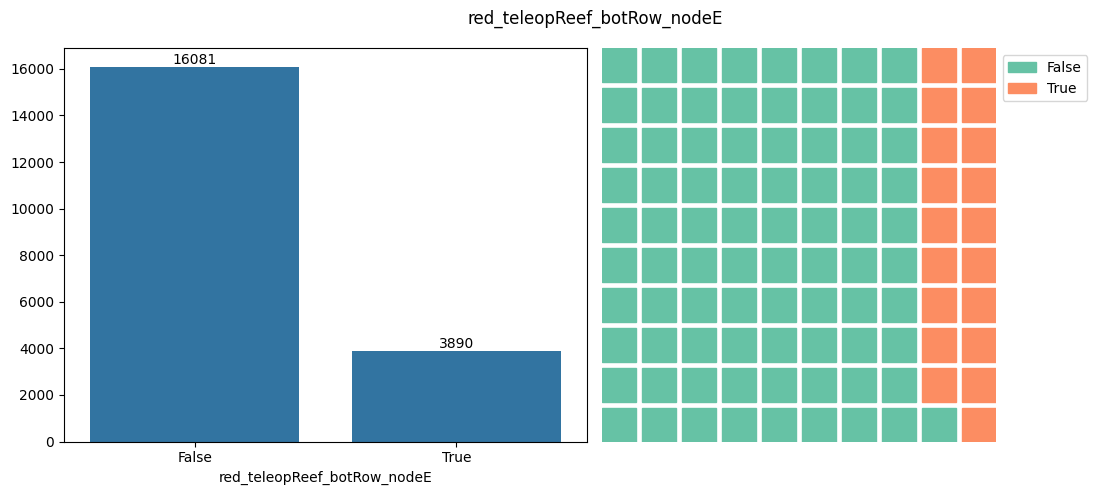

In [130]:
cat_plot("red_teleopReef_botRow_nodeE")

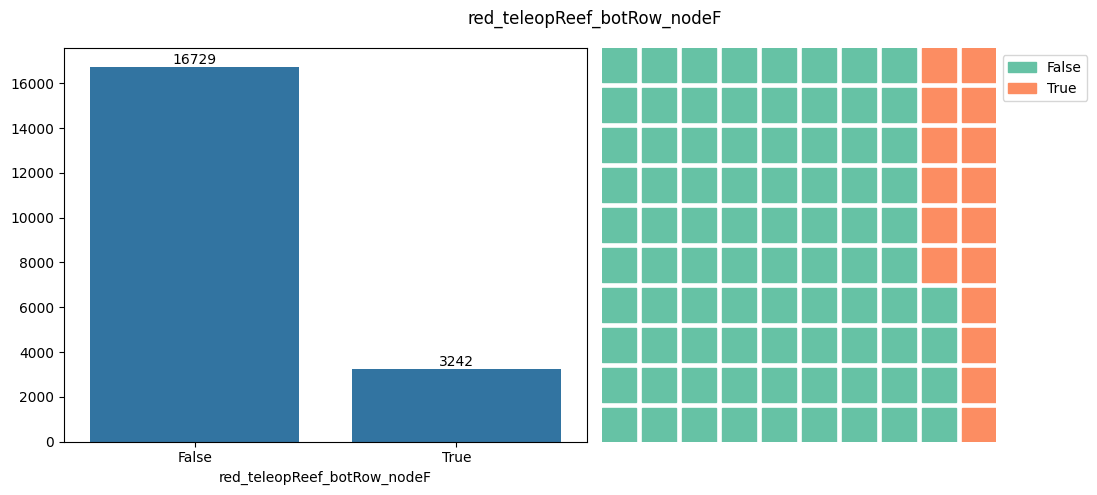

In [131]:
cat_plot("red_teleopReef_botRow_nodeF")

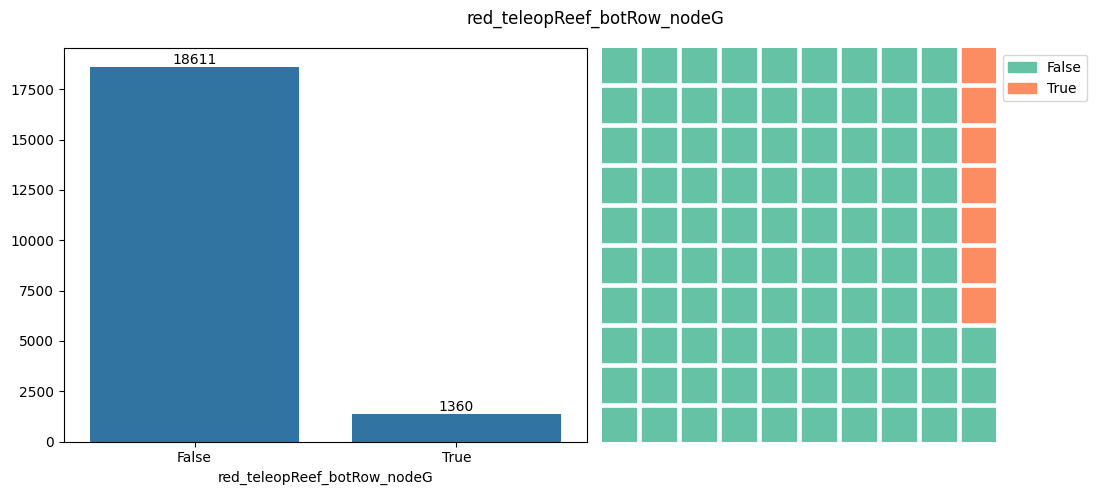

In [132]:
cat_plot("red_teleopReef_botRow_nodeG")

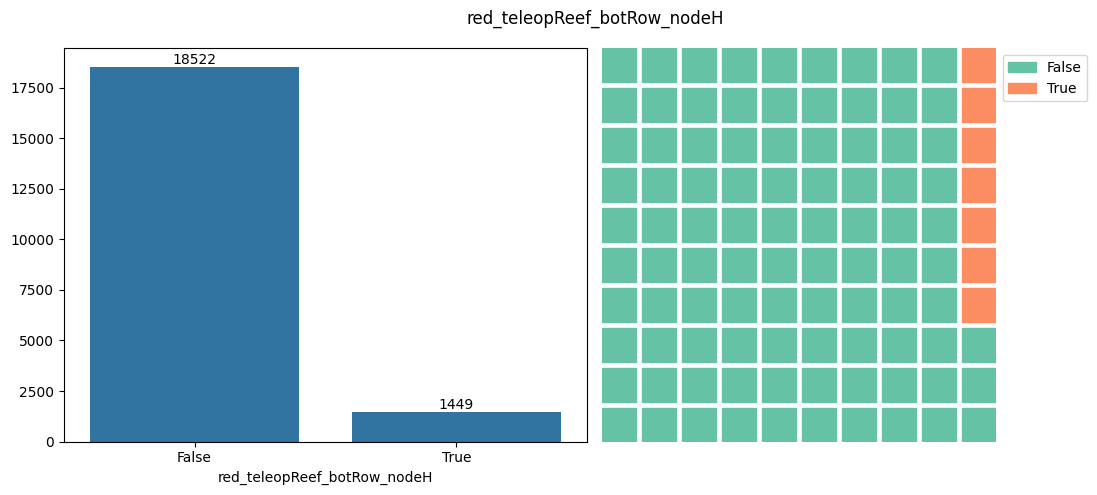

In [133]:
cat_plot("red_teleopReef_botRow_nodeH")

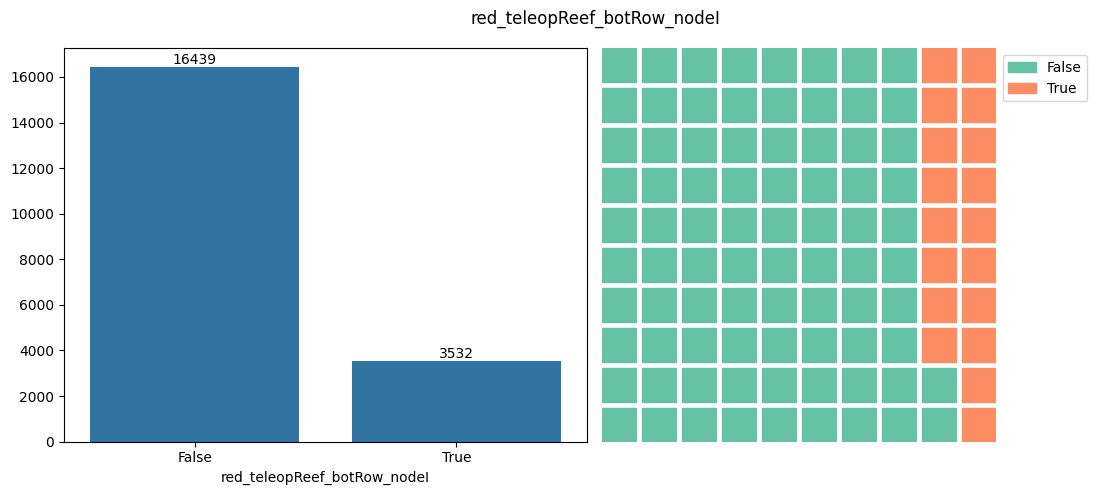

In [134]:
cat_plot("red_teleopReef_botRow_nodeI")

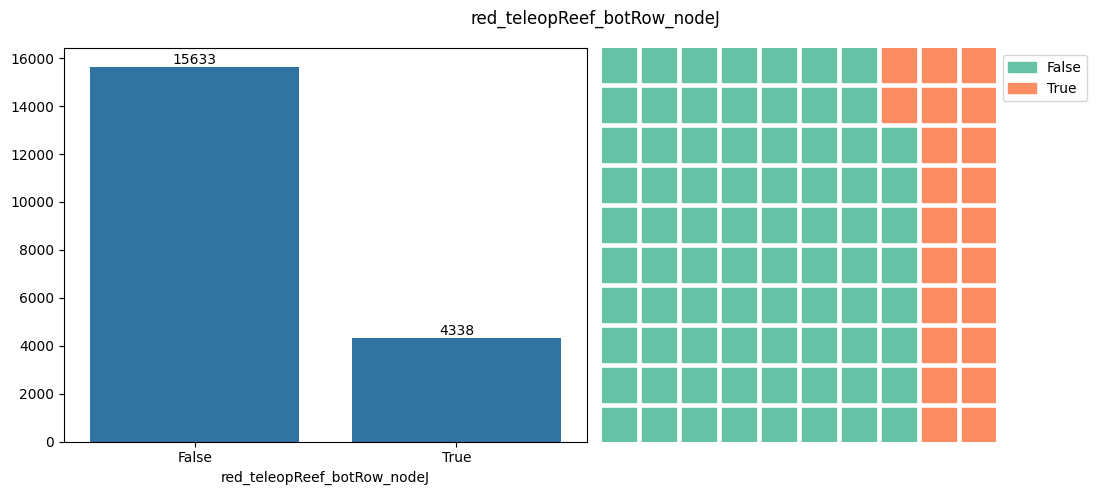

In [135]:
cat_plot("red_teleopReef_botRow_nodeJ")

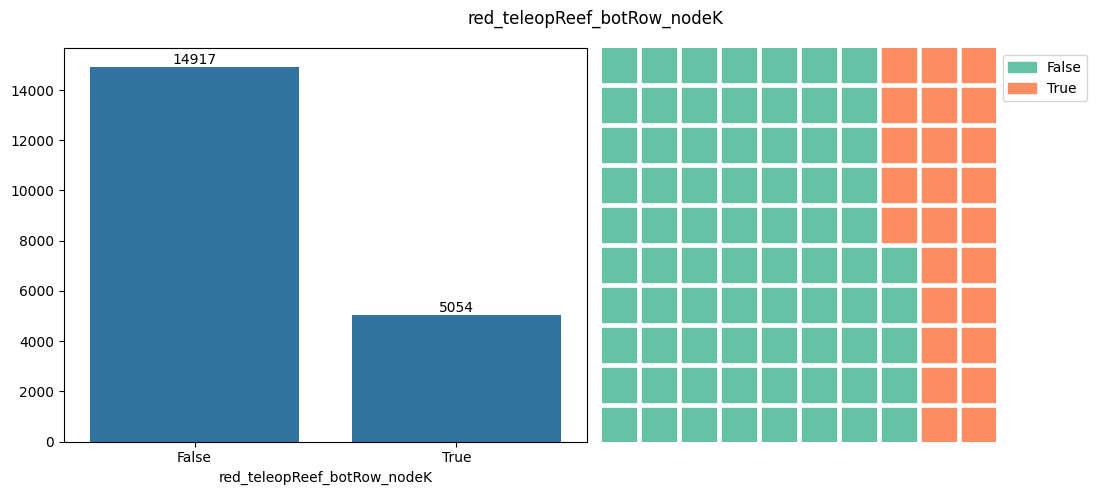

In [136]:
cat_plot("red_teleopReef_botRow_nodeK")

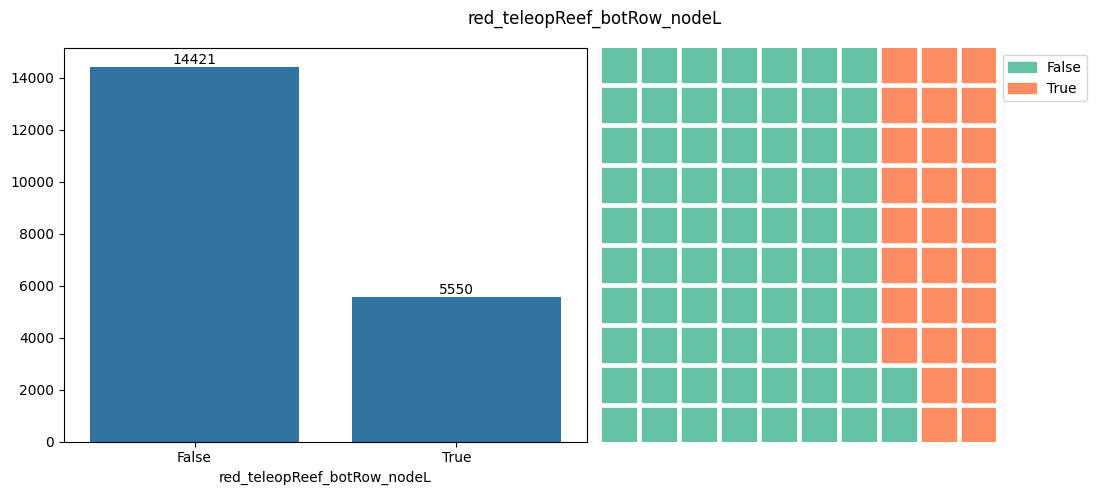

In [137]:
cat_plot("red_teleopReef_botRow_nodeL")

##### middle

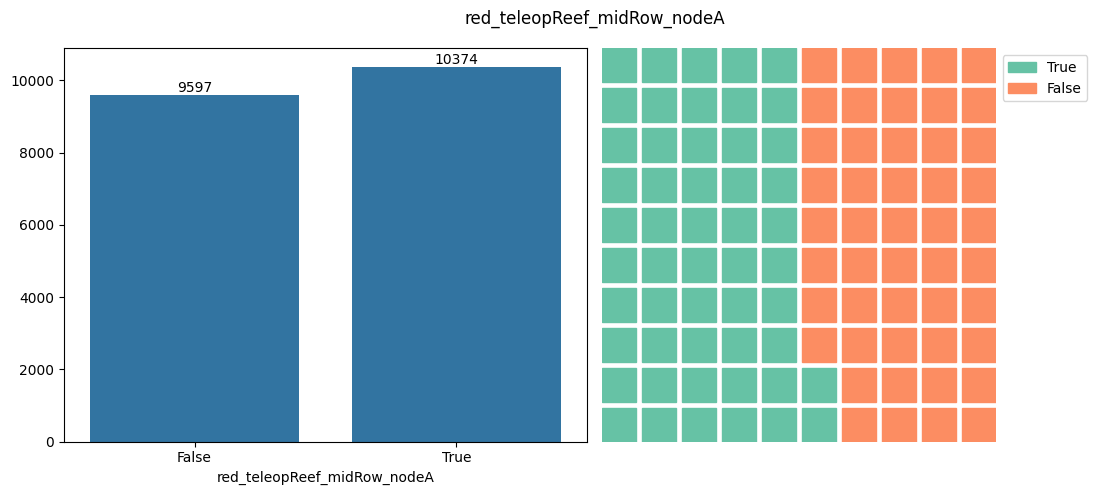

In [138]:
cat_plot("red_teleopReef_midRow_nodeA")

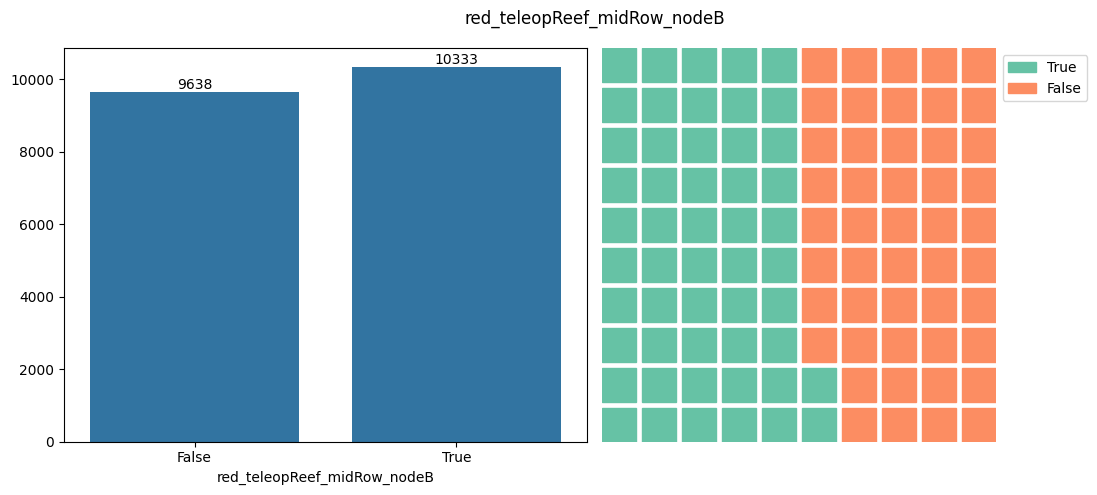

In [139]:
cat_plot("red_teleopReef_midRow_nodeB")

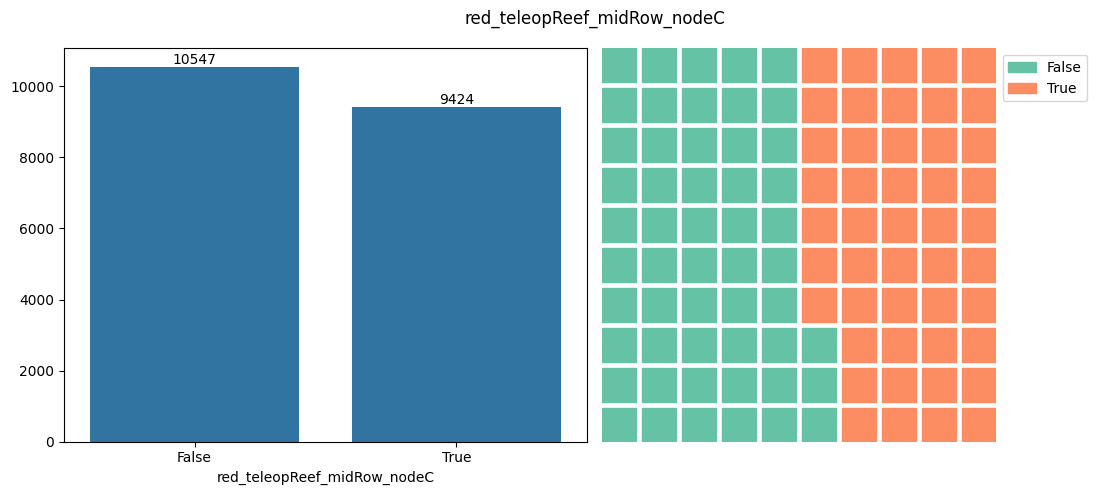

In [140]:
cat_plot("red_teleopReef_midRow_nodeC")

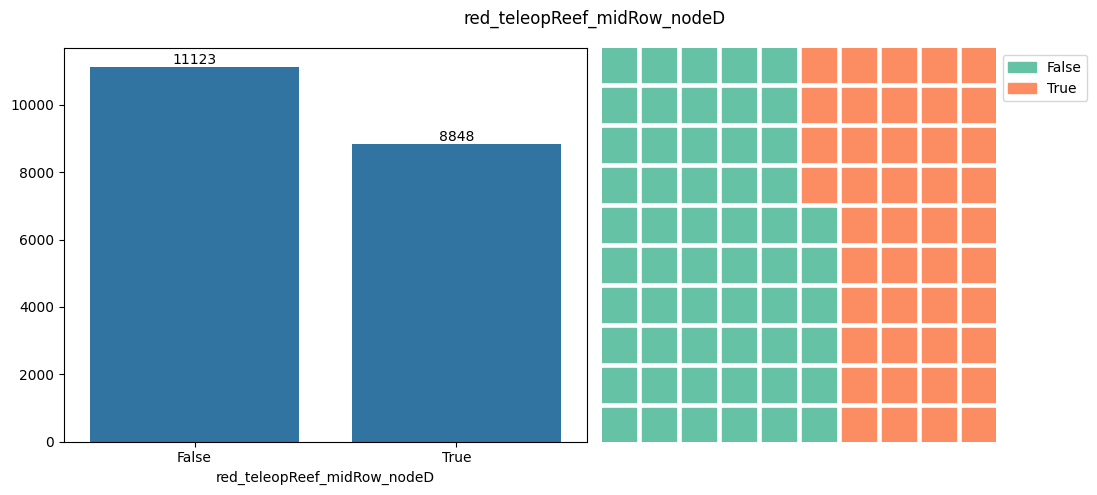

In [141]:
cat_plot("red_teleopReef_midRow_nodeD")

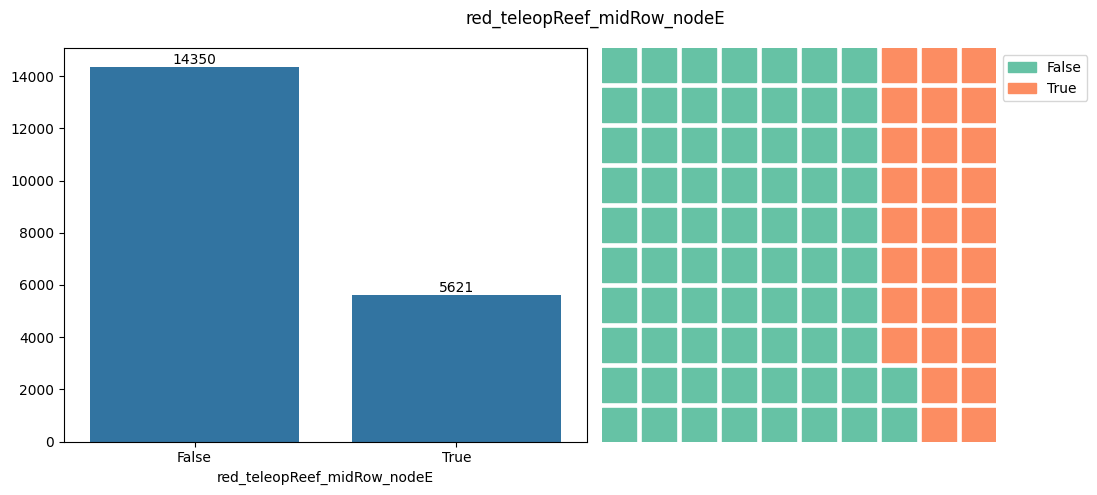

In [142]:
cat_plot("red_teleopReef_midRow_nodeE")

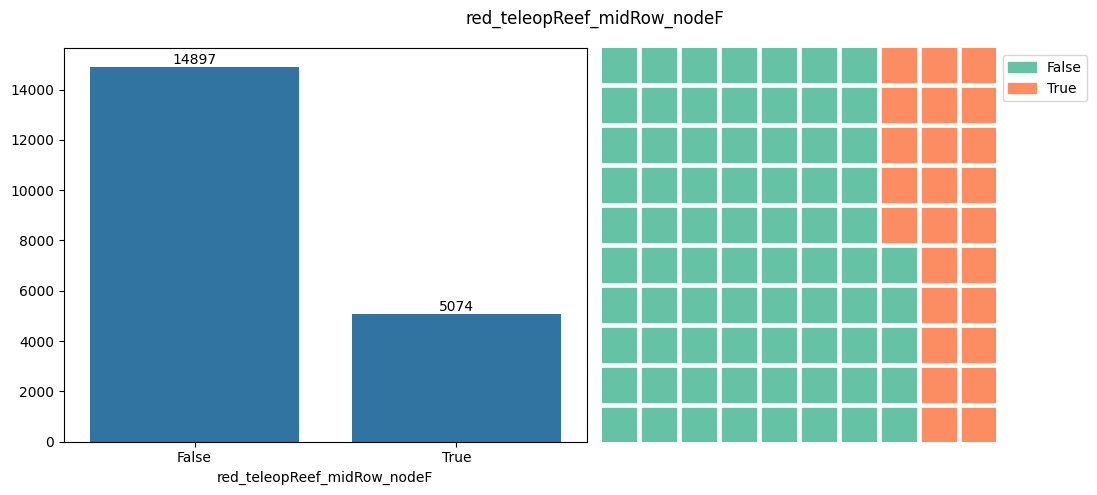

In [143]:
cat_plot("red_teleopReef_midRow_nodeF")

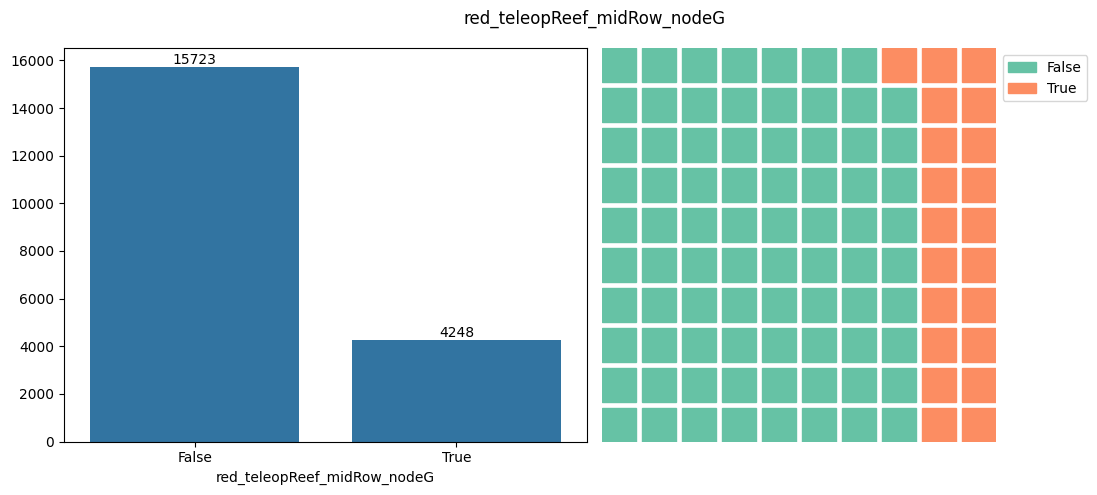

In [144]:
cat_plot("red_teleopReef_midRow_nodeG")

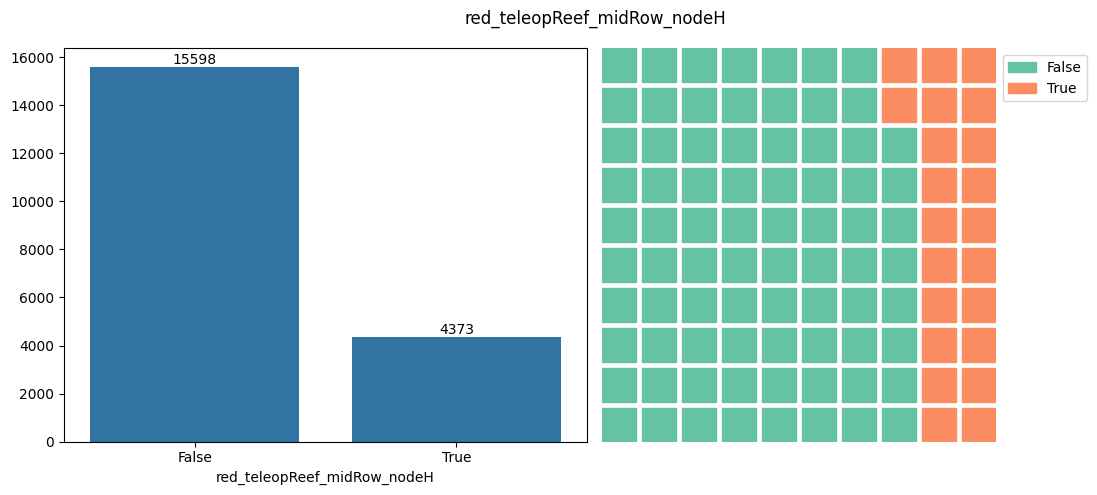

In [145]:
cat_plot("red_teleopReef_midRow_nodeH")

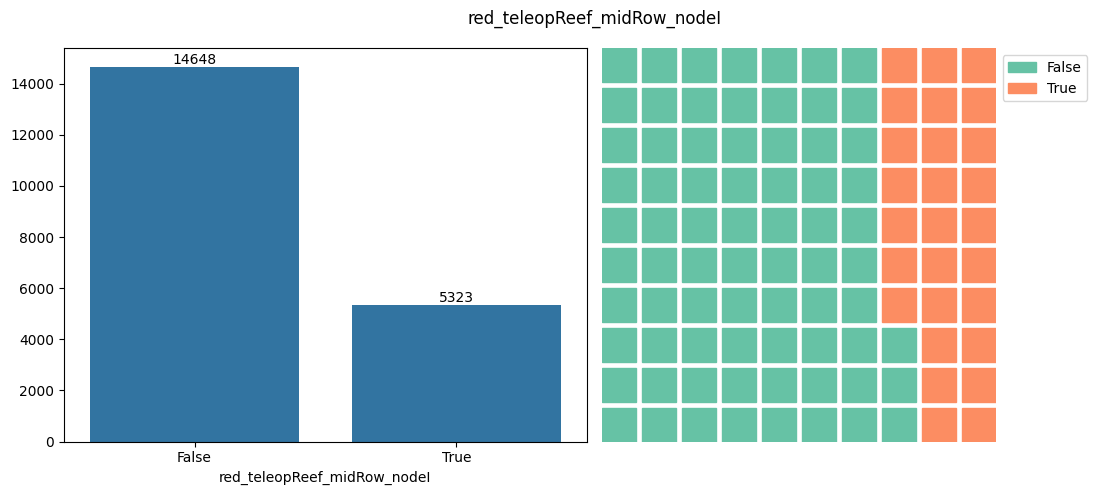

In [146]:
cat_plot("red_teleopReef_midRow_nodeI")

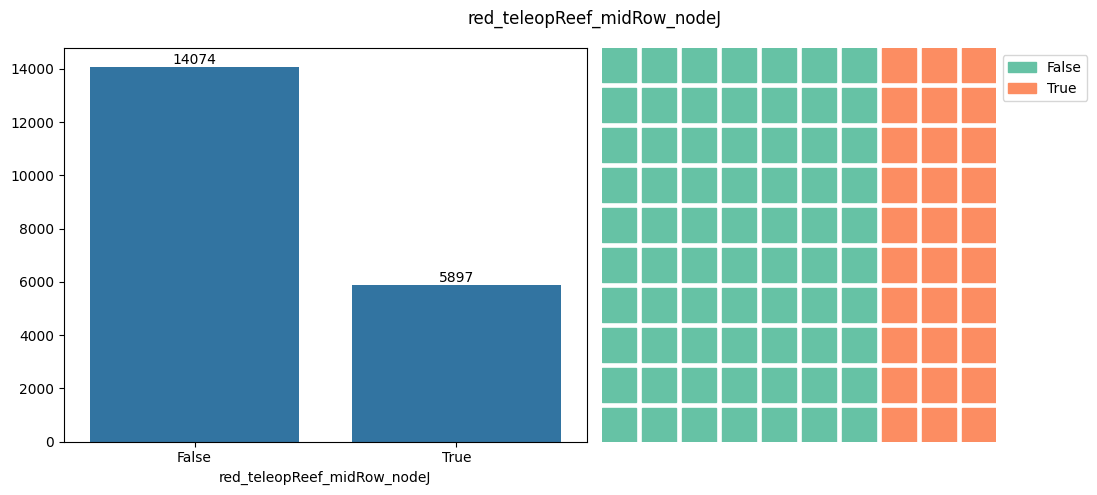

In [147]:
cat_plot("red_teleopReef_midRow_nodeJ")

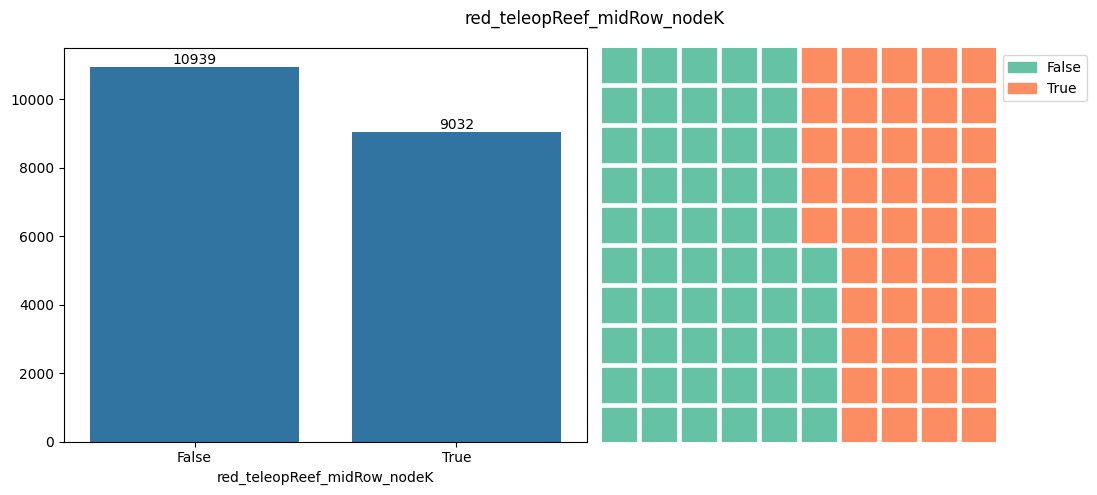

In [148]:
cat_plot("red_teleopReef_midRow_nodeK")

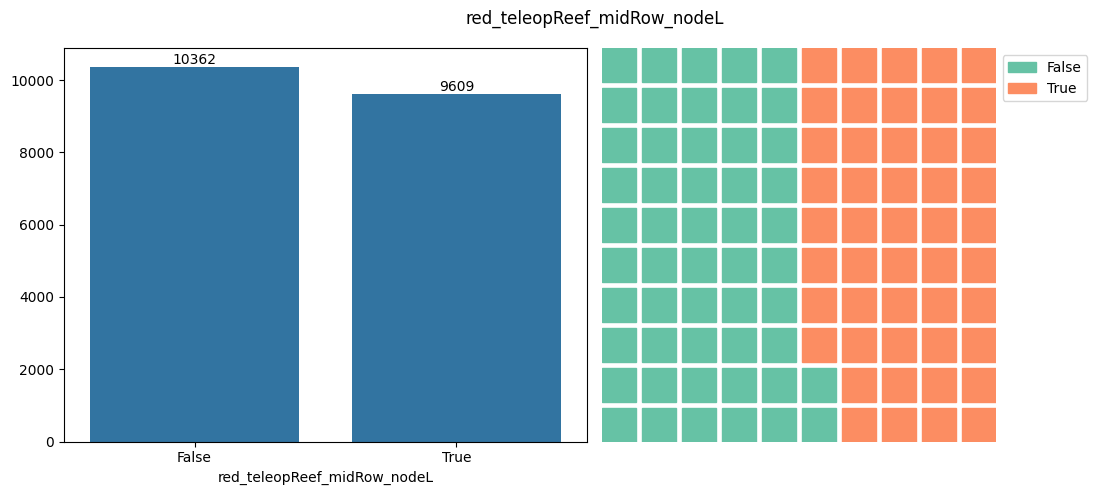

In [149]:
cat_plot("red_teleopReef_midRow_nodeL")

##### top

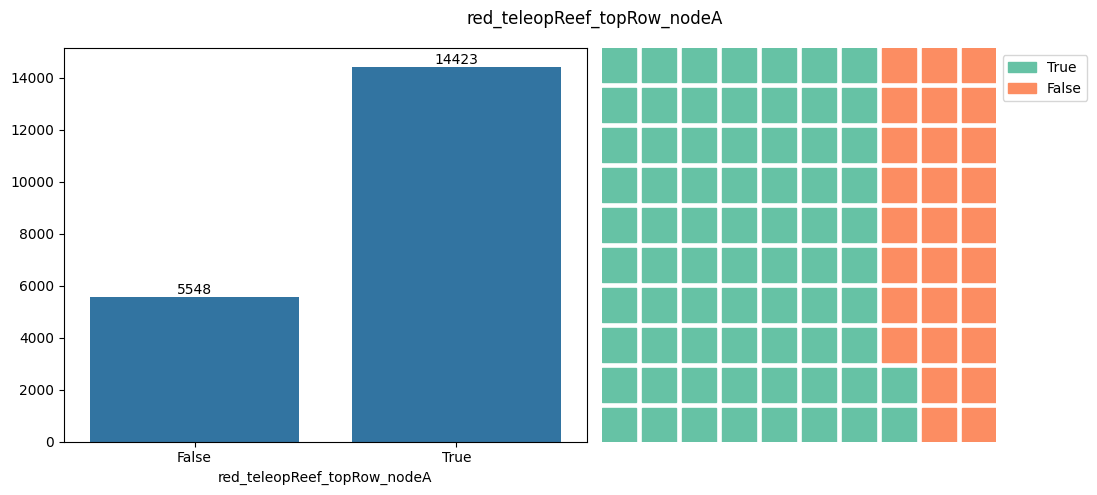

In [150]:
cat_plot("red_teleopReef_topRow_nodeA")

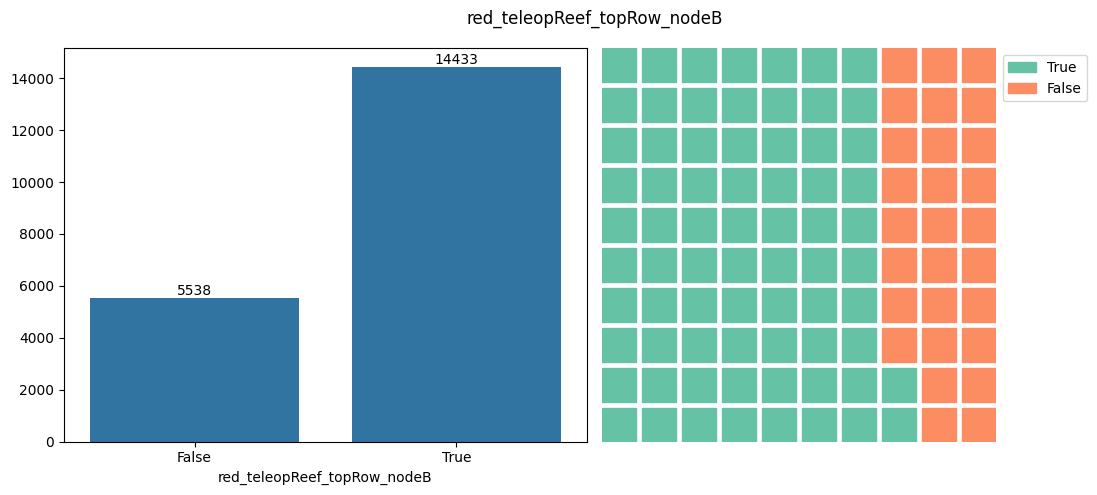

In [151]:
cat_plot("red_teleopReef_topRow_nodeB")

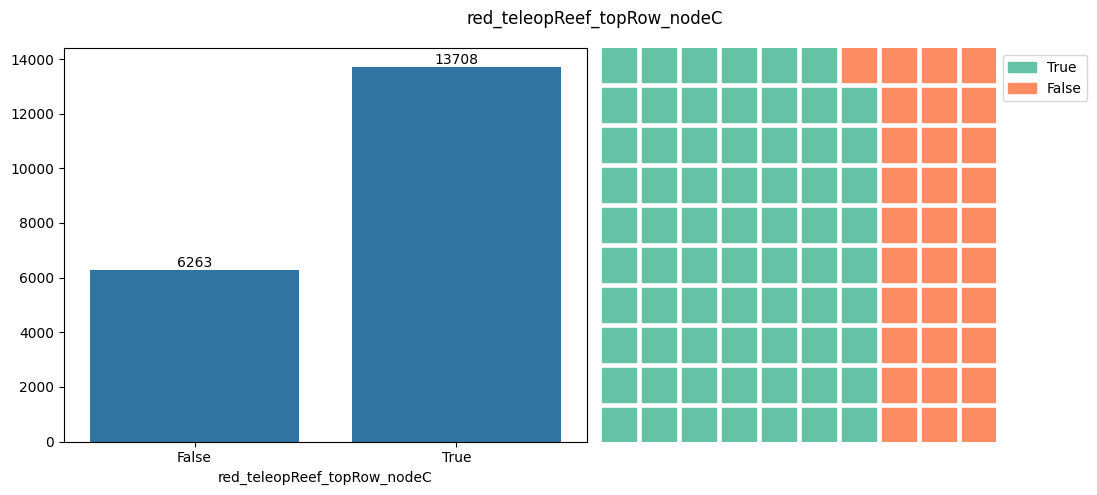

In [152]:
cat_plot("red_teleopReef_topRow_nodeC")

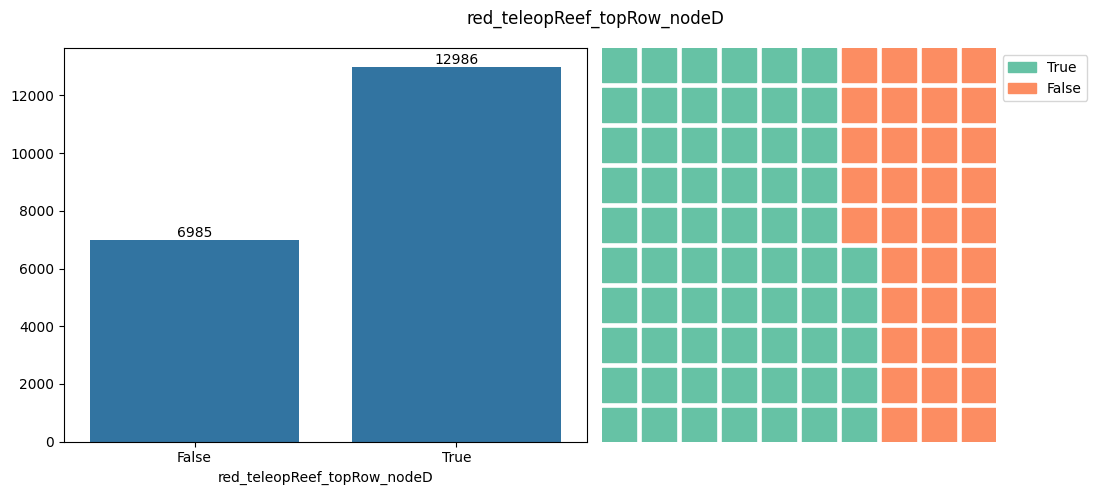

In [153]:
cat_plot("red_teleopReef_topRow_nodeD")

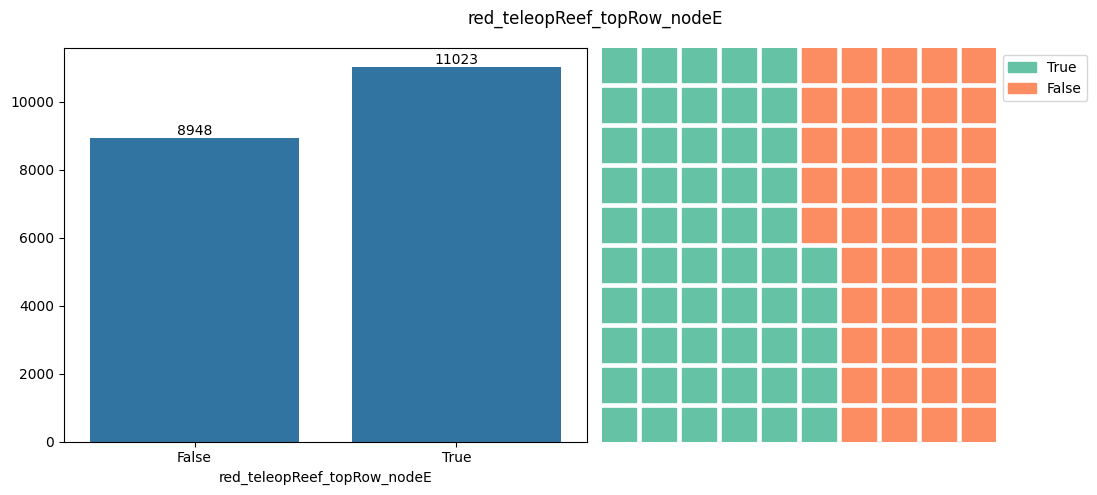

In [154]:
cat_plot("red_teleopReef_topRow_nodeE")

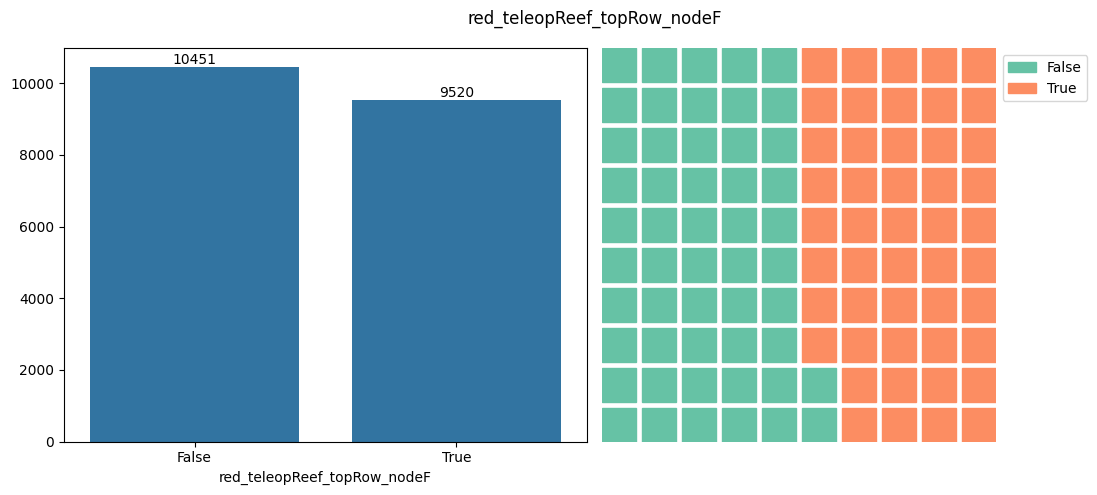

In [155]:
cat_plot("red_teleopReef_topRow_nodeF")

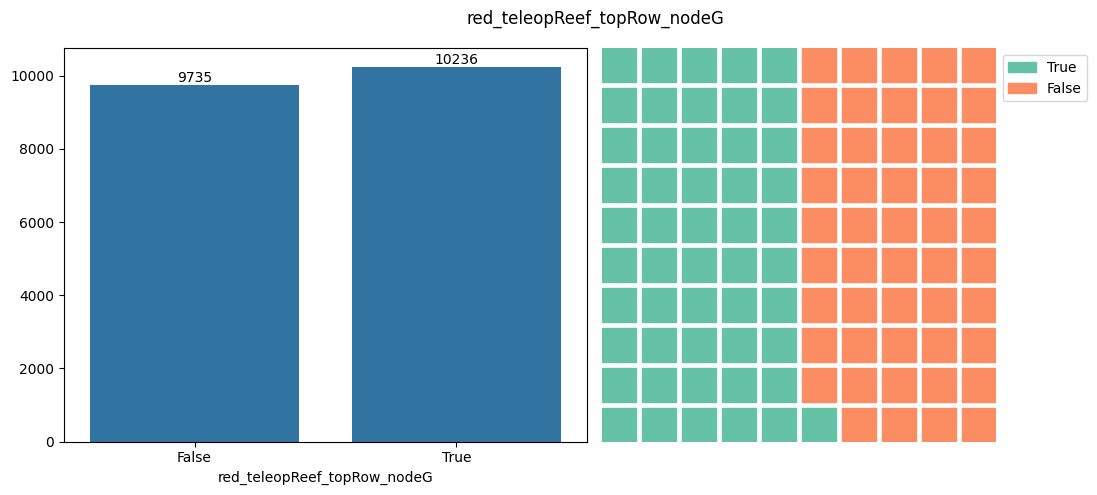

In [156]:
cat_plot("red_teleopReef_topRow_nodeG")

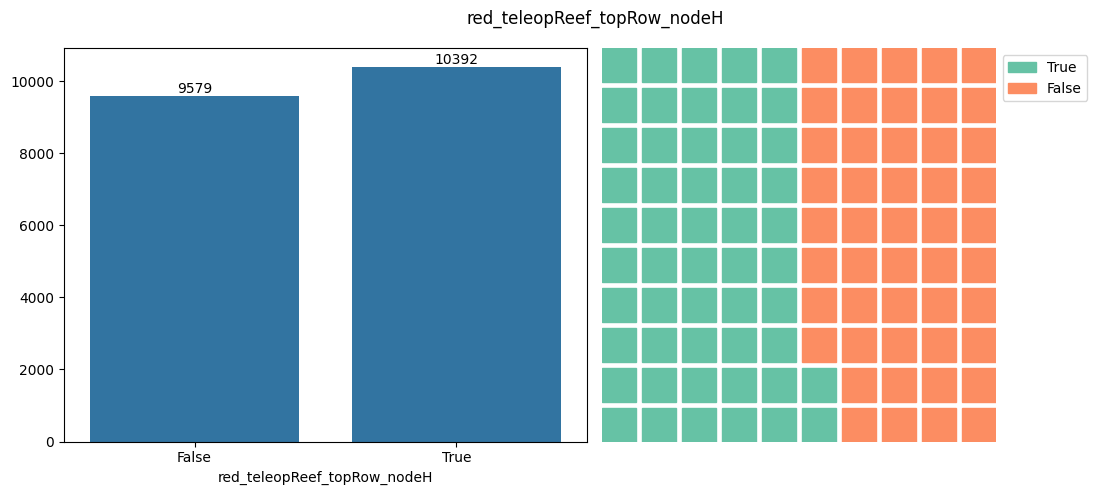

In [157]:
cat_plot("red_teleopReef_topRow_nodeH")

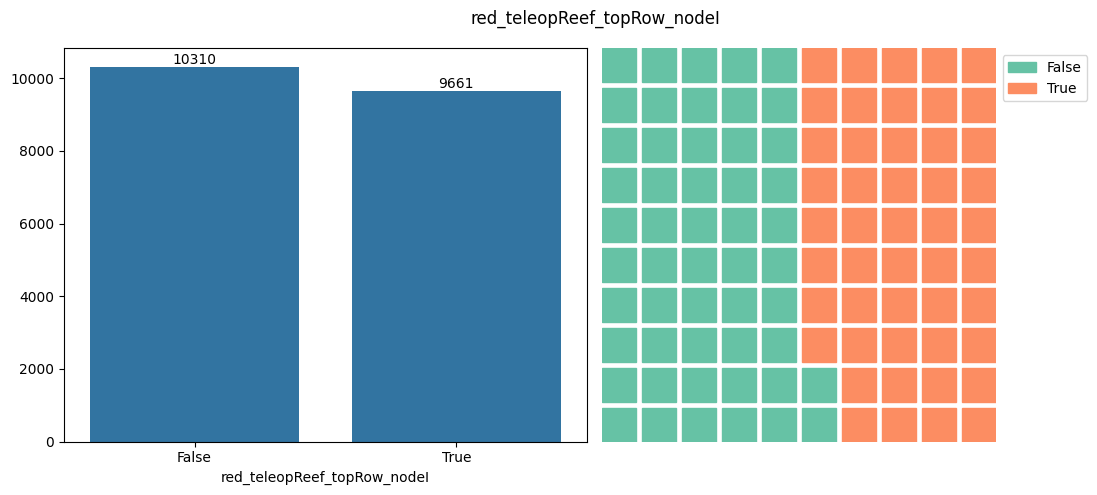

In [158]:
cat_plot("red_teleopReef_topRow_nodeI")

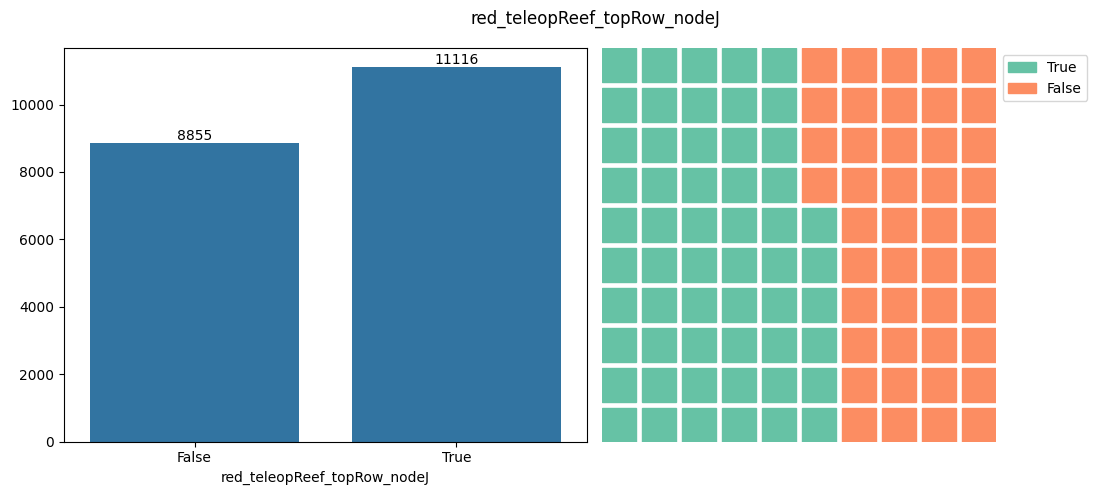

In [159]:
cat_plot("red_teleopReef_topRow_nodeJ")

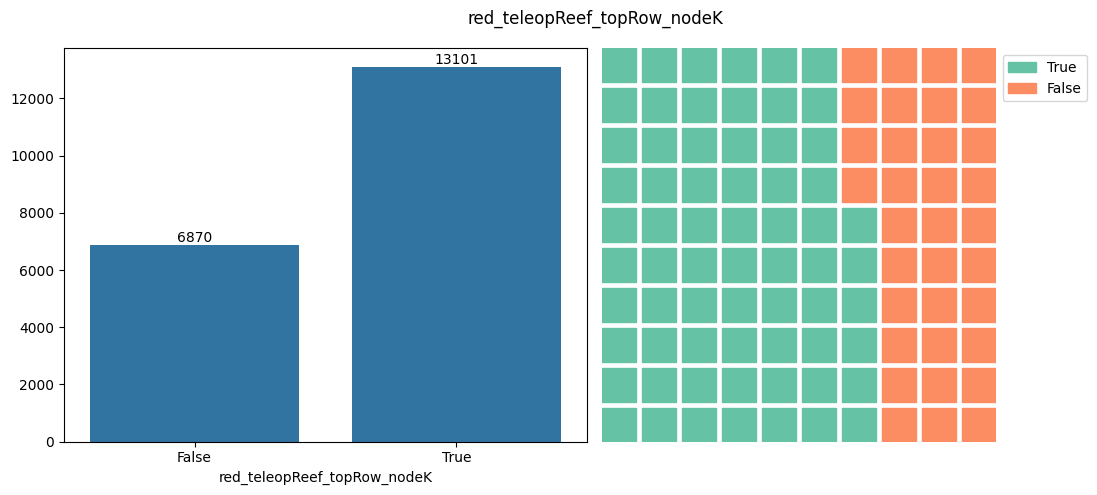

In [160]:
cat_plot("red_teleopReef_topRow_nodeK")

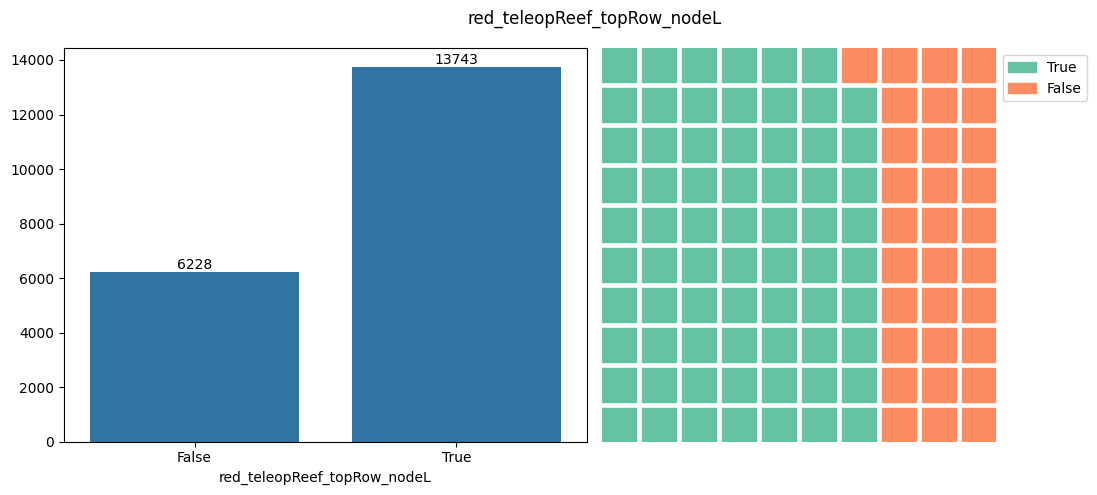

In [161]:
cat_plot("red_teleopReef_topRow_nodeL")

#### endgame

##### red endgame

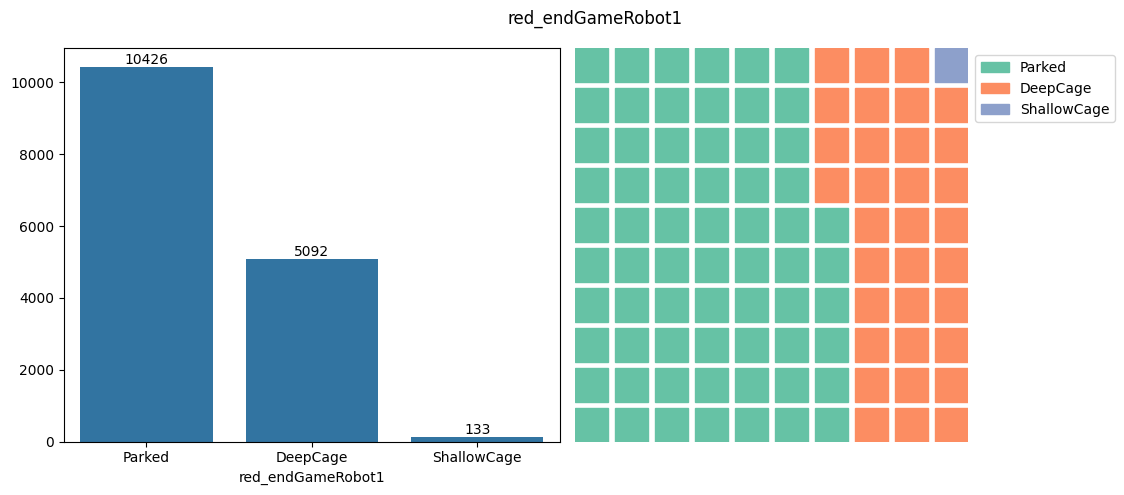

In [162]:
cat_plot("red_endGameRobot1")

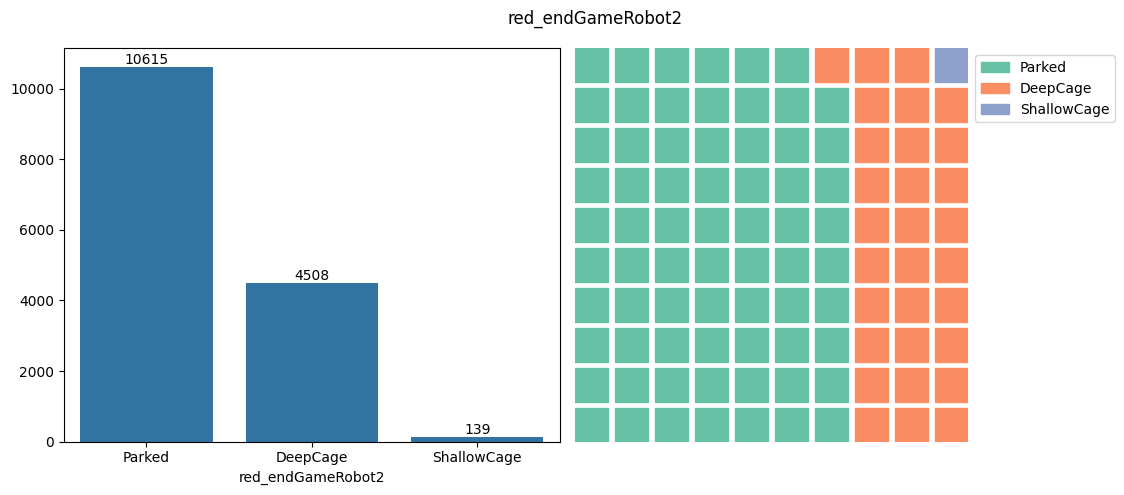

In [163]:
cat_plot("red_endGameRobot2")

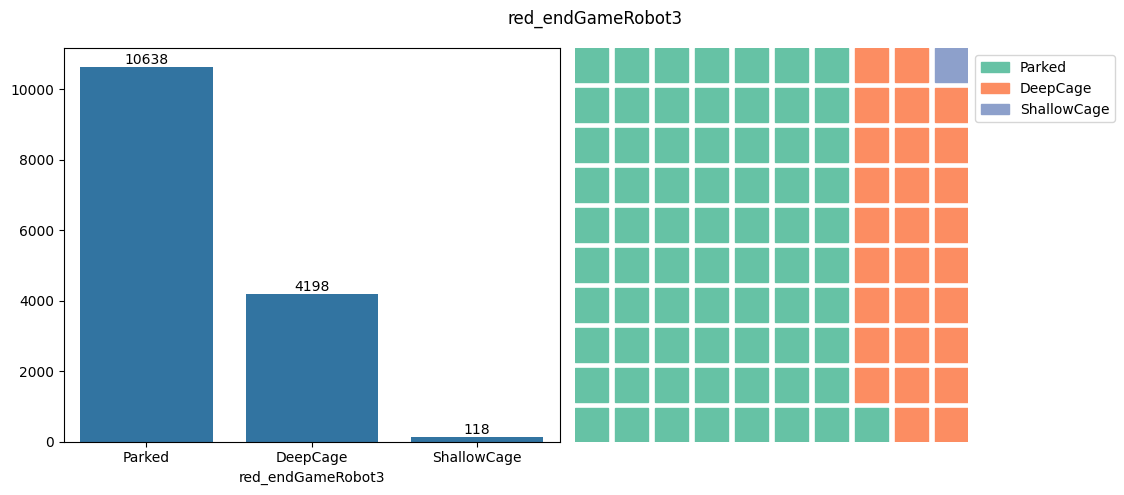

In [164]:
cat_plot("red_endGameRobot3")

##### blue endgame

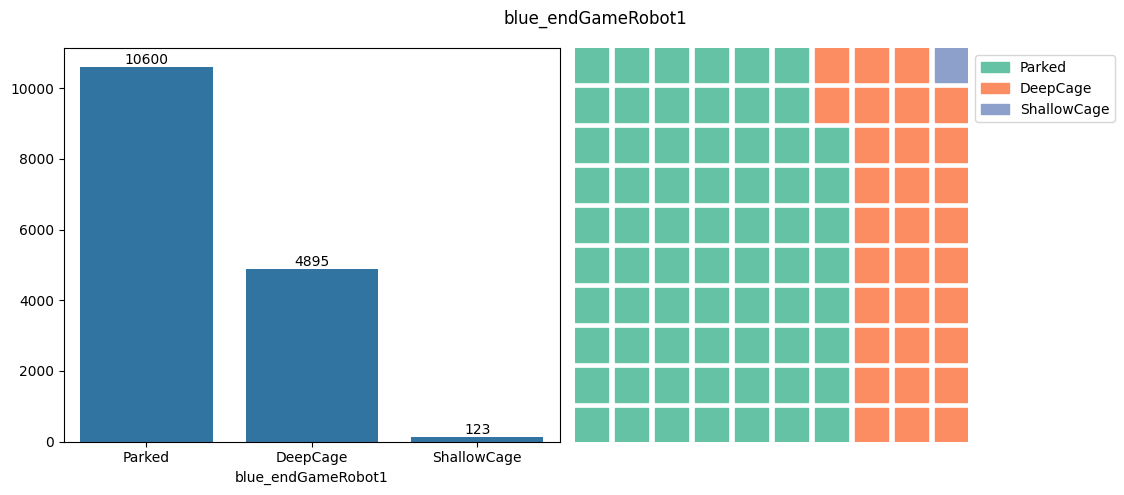

In [165]:
cat_plot("blue_endGameRobot1")

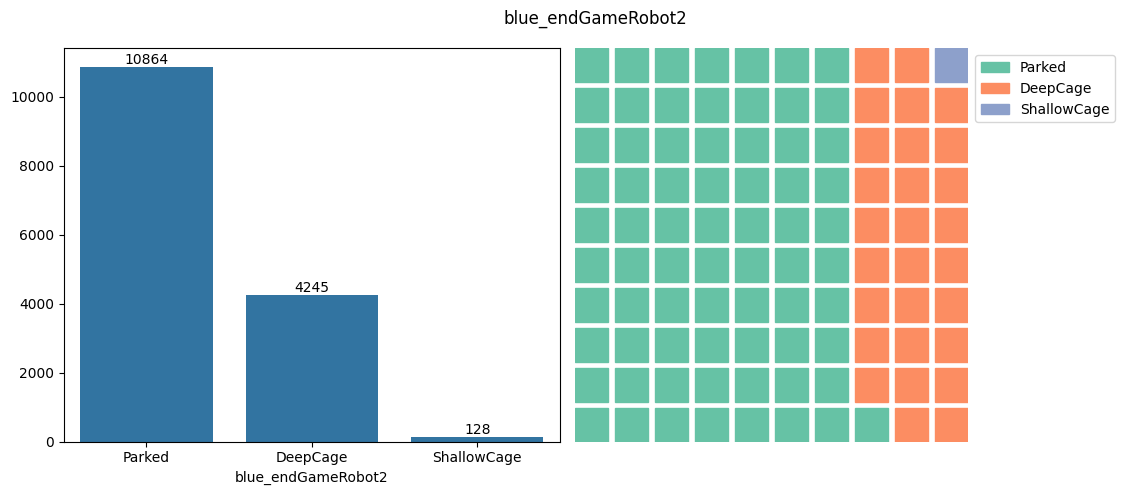

In [166]:
cat_plot("blue_endGameRobot2")

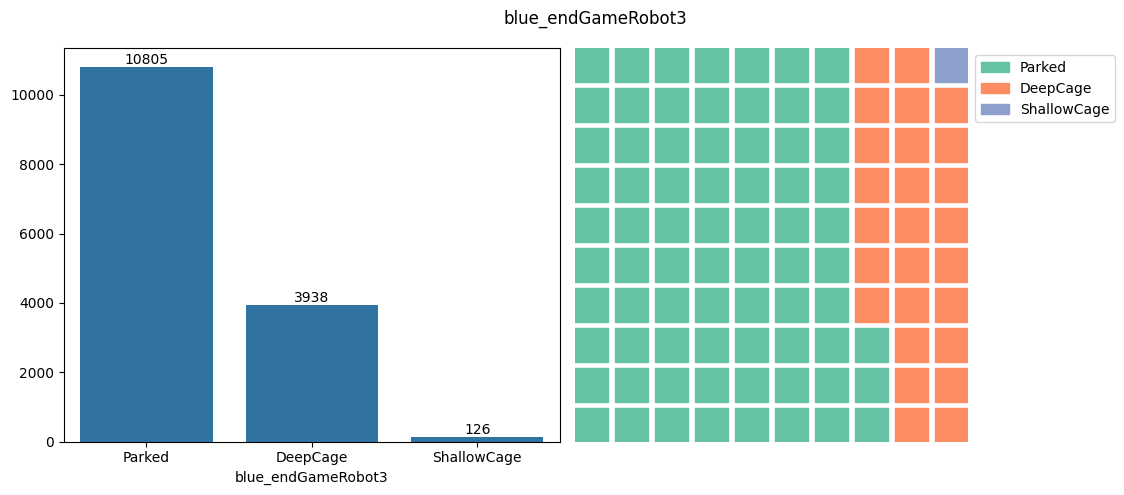

In [167]:
cat_plot("blue_endGameRobot3")

### RP and Bonuses

#### blue RP...

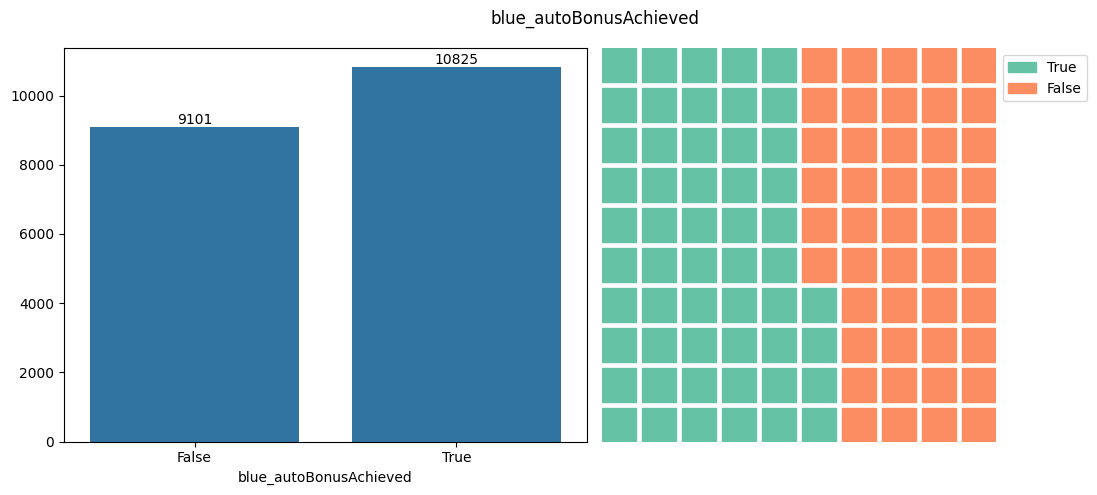

In [168]:
cat_plot("blue_autoBonusAchieved")

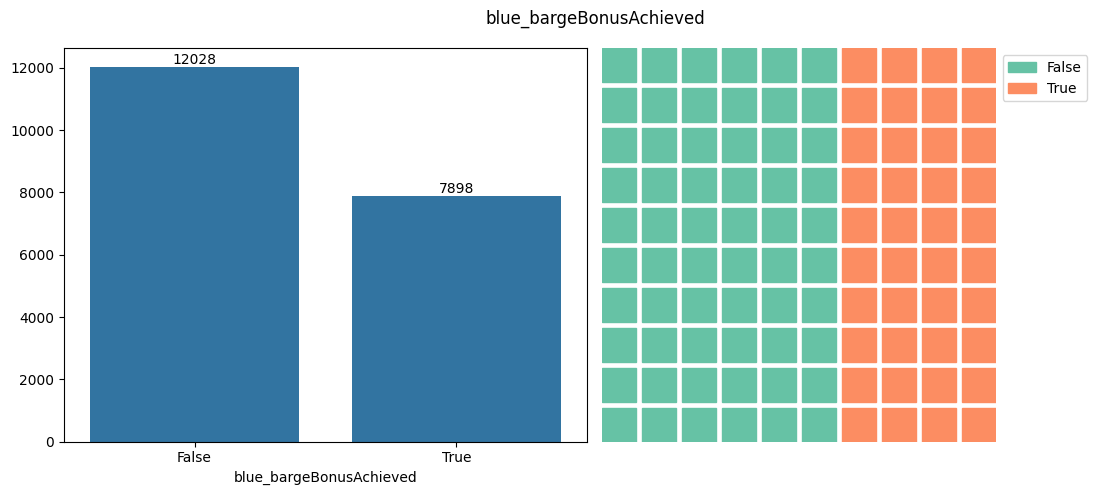

In [169]:
cat_plot("blue_bargeBonusAchieved")

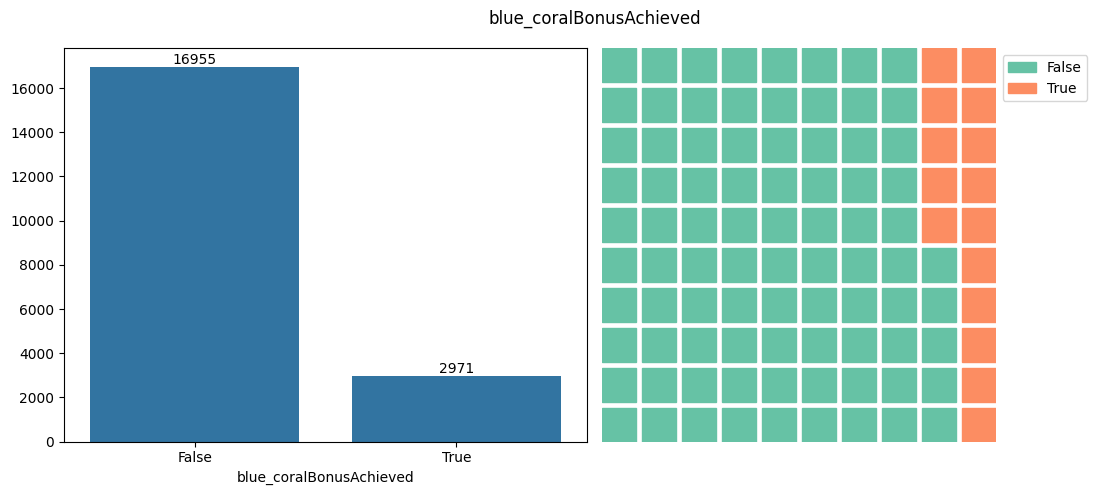

In [170]:
cat_plot("blue_coralBonusAchieved")

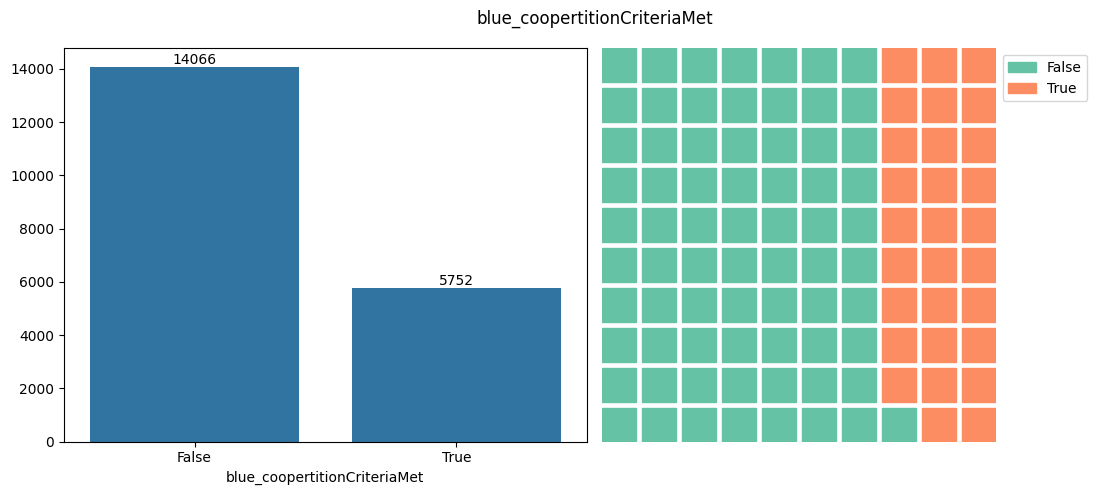

In [171]:
cat_plot("blue_coopertitionCriteriaMet")

#### red RP...

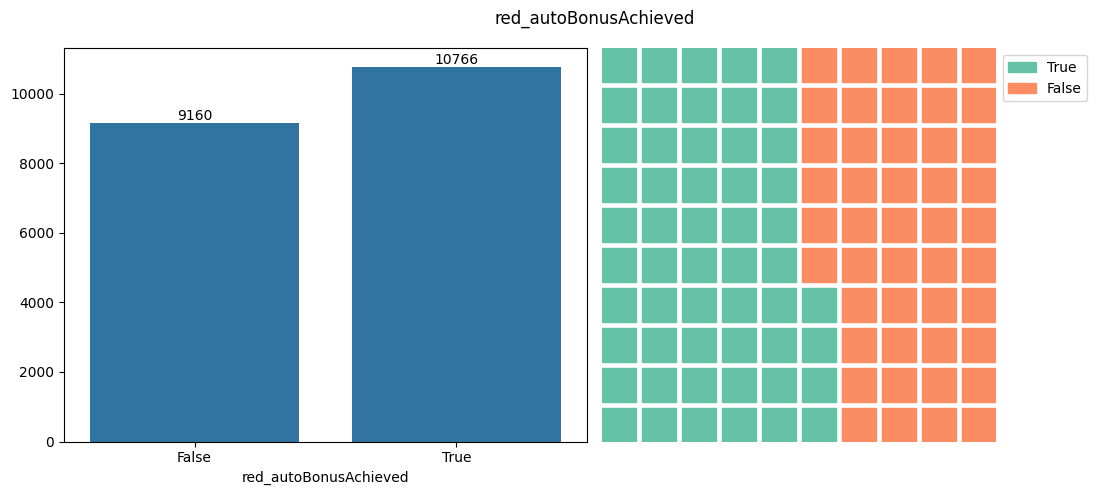

In [172]:
cat_plot("red_autoBonusAchieved")

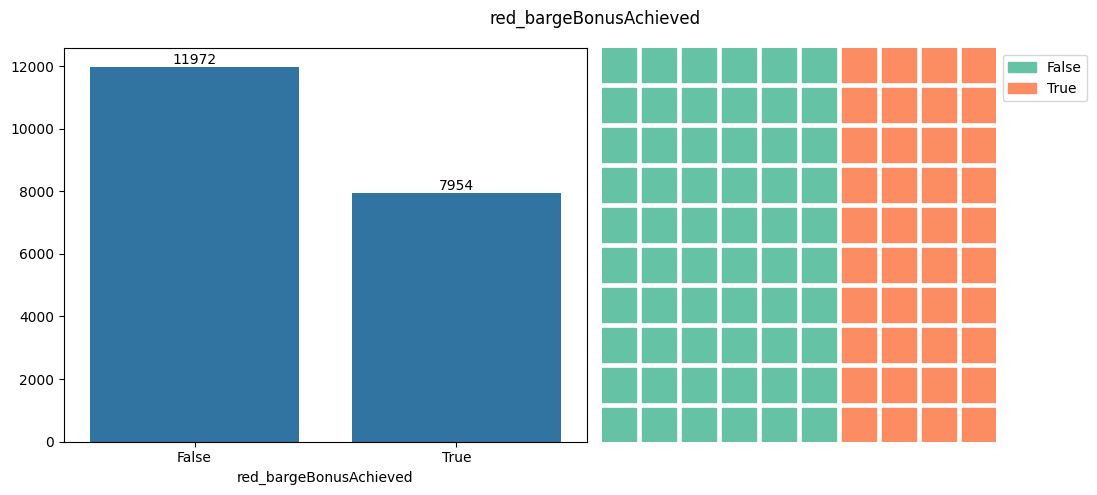

In [173]:
cat_plot("red_bargeBonusAchieved")

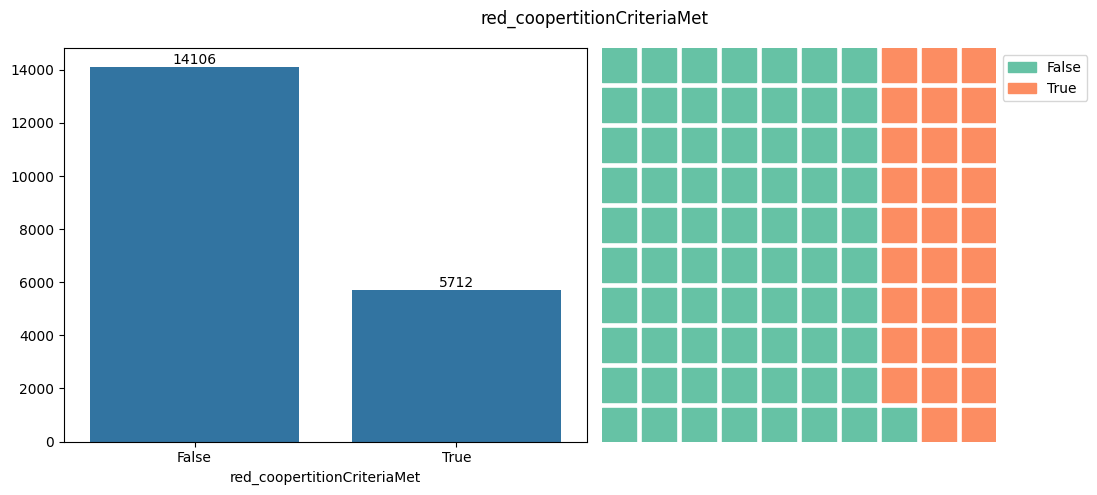

In [174]:
cat_plot("red_coopertitionCriteriaMet")

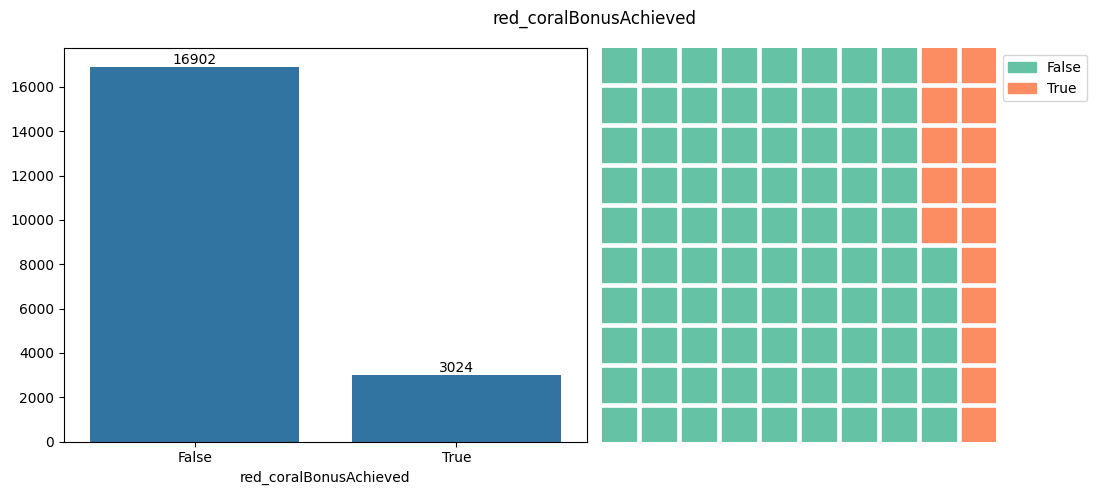

In [175]:
cat_plot("red_coralBonusAchieved")

### Penalties

#### blue penalties

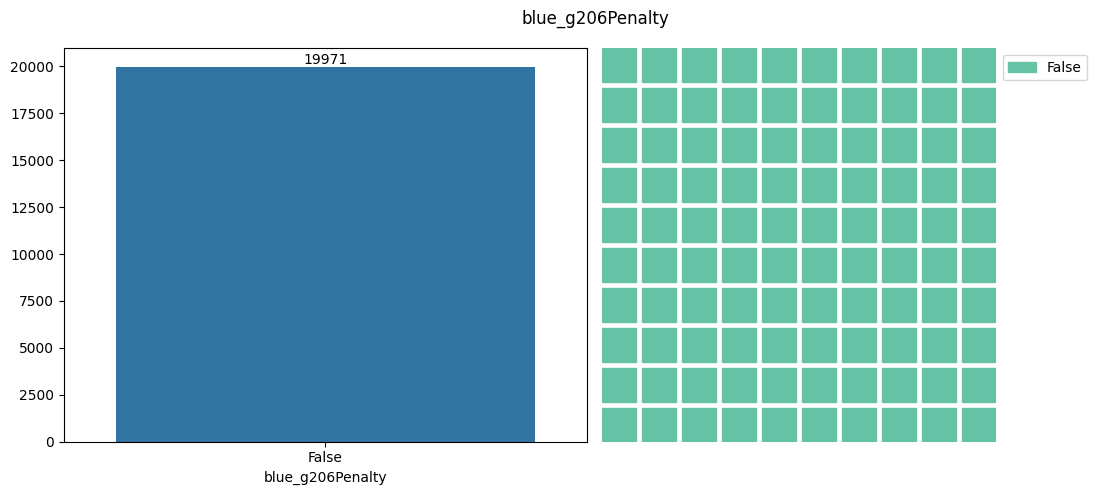

In [176]:
cat_plot("blue_g206Penalty")

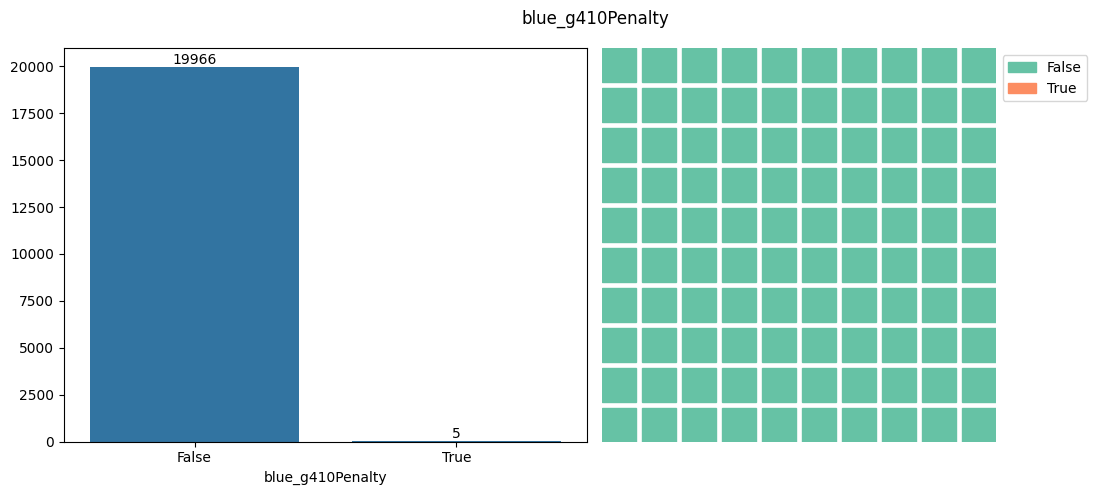

In [177]:
cat_plot("blue_g410Penalty")

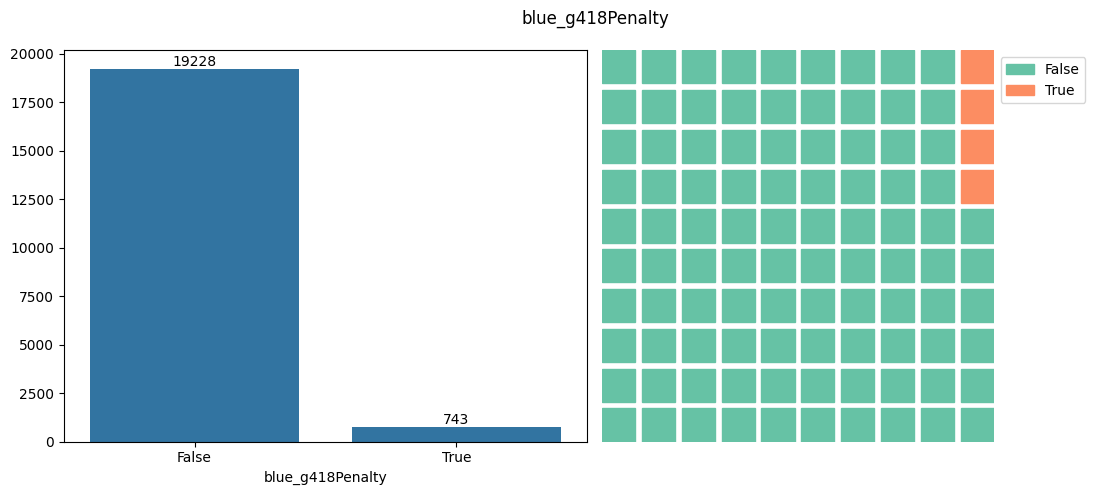

In [178]:
cat_plot("blue_g418Penalty")

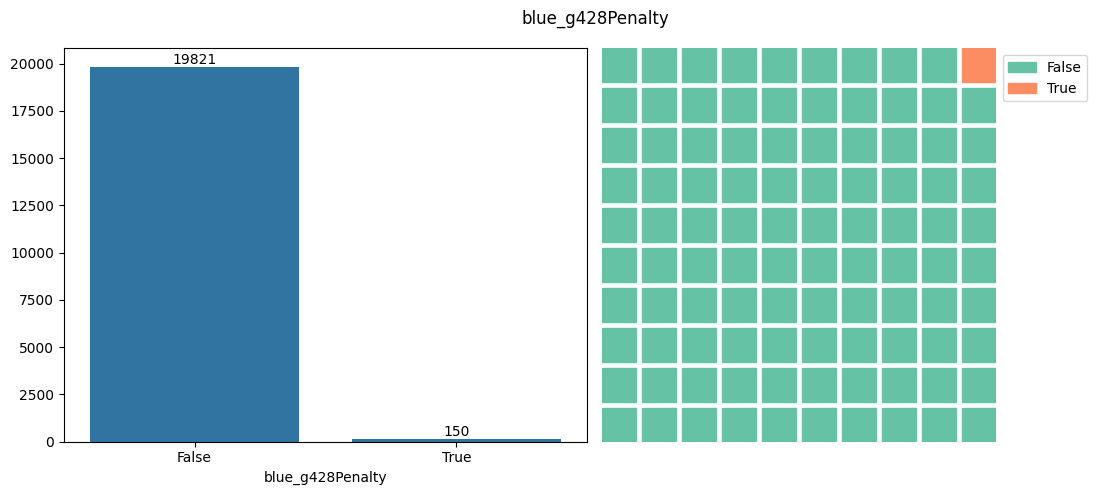

In [179]:
cat_plot("blue_g428Penalty")

#### red penalties

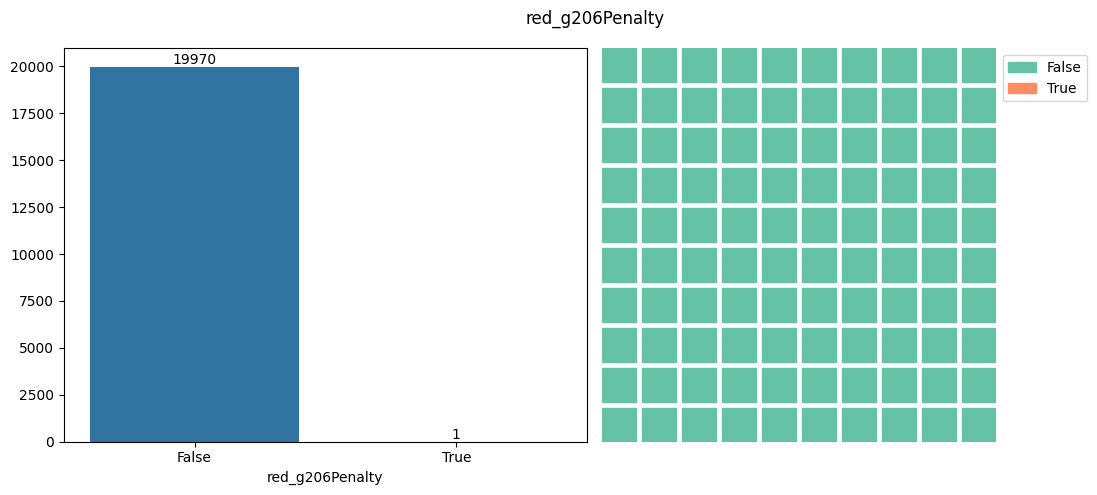

In [180]:
cat_plot("red_g206Penalty")

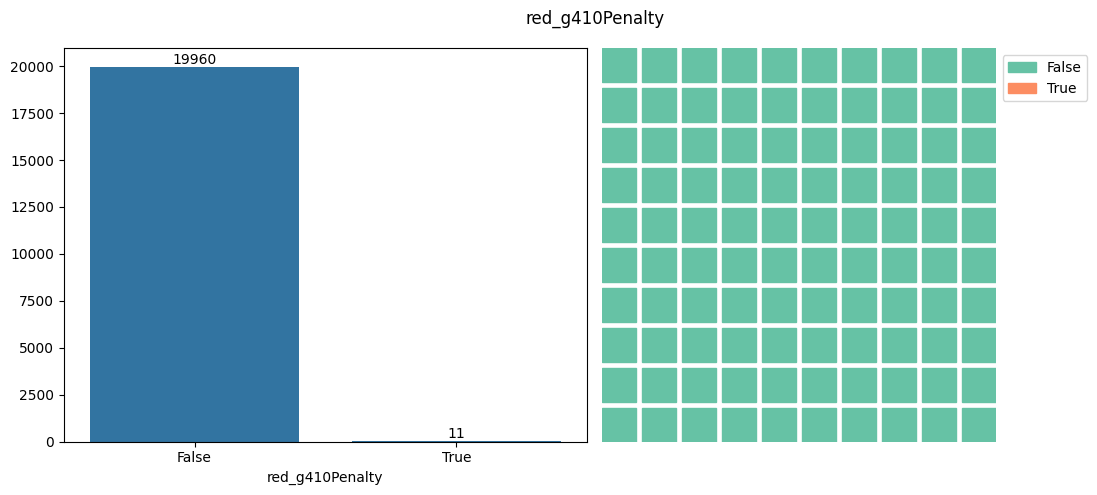

In [181]:
cat_plot("red_g410Penalty")

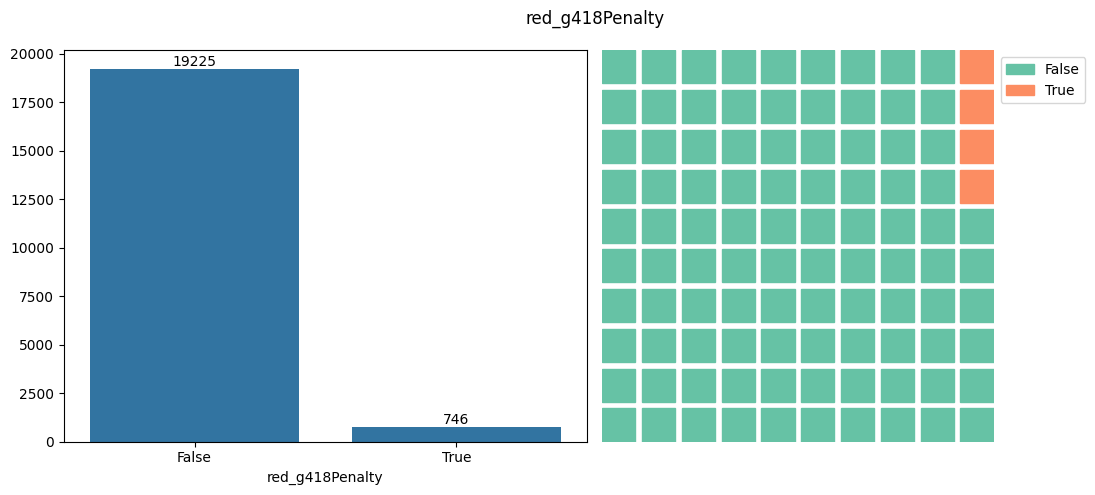

In [182]:
cat_plot("red_g418Penalty")

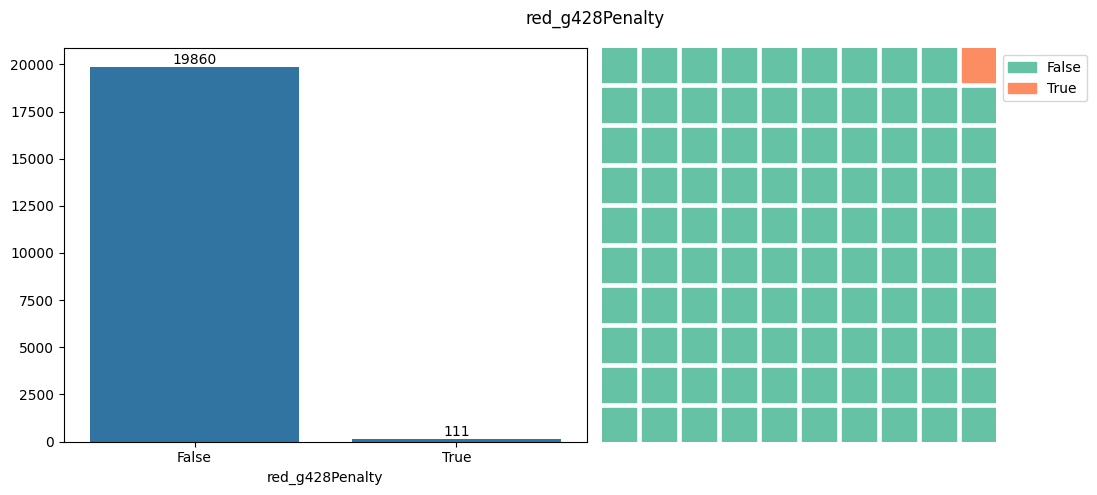

In [183]:
cat_plot("red_g428Penalty")

## numenoric plots

### General

#### times

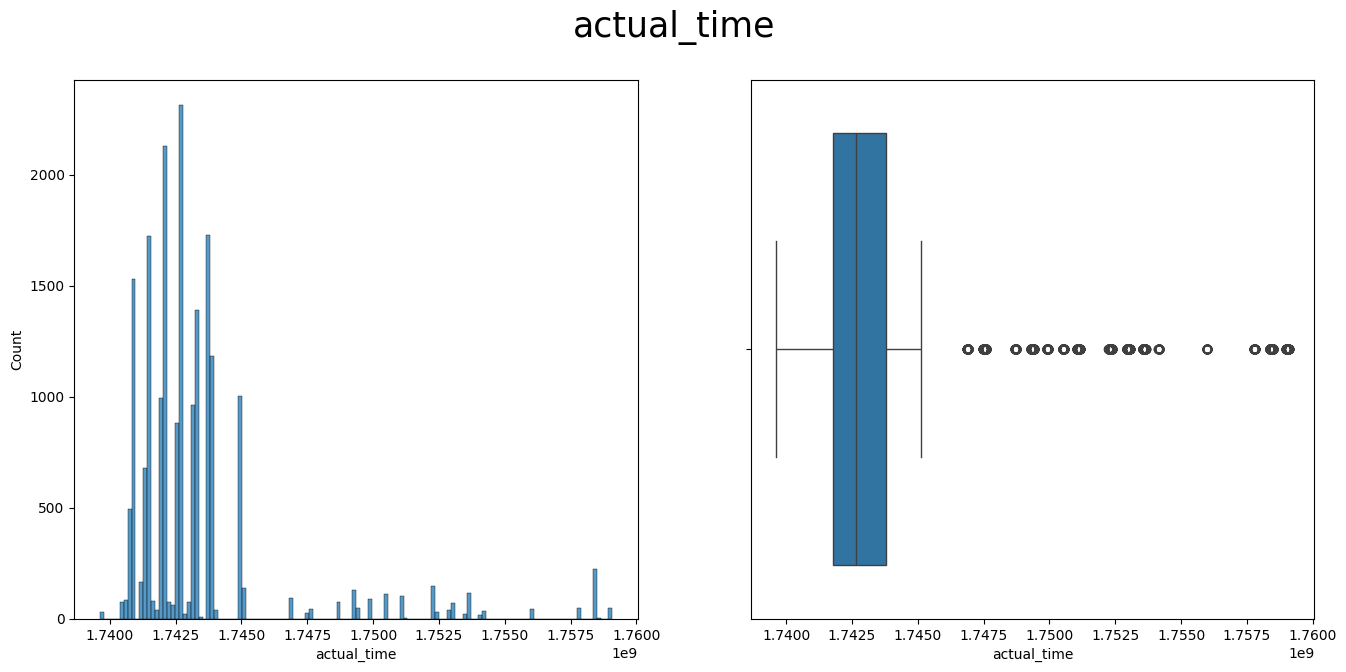

In [184]:
num_plot("actual_time")

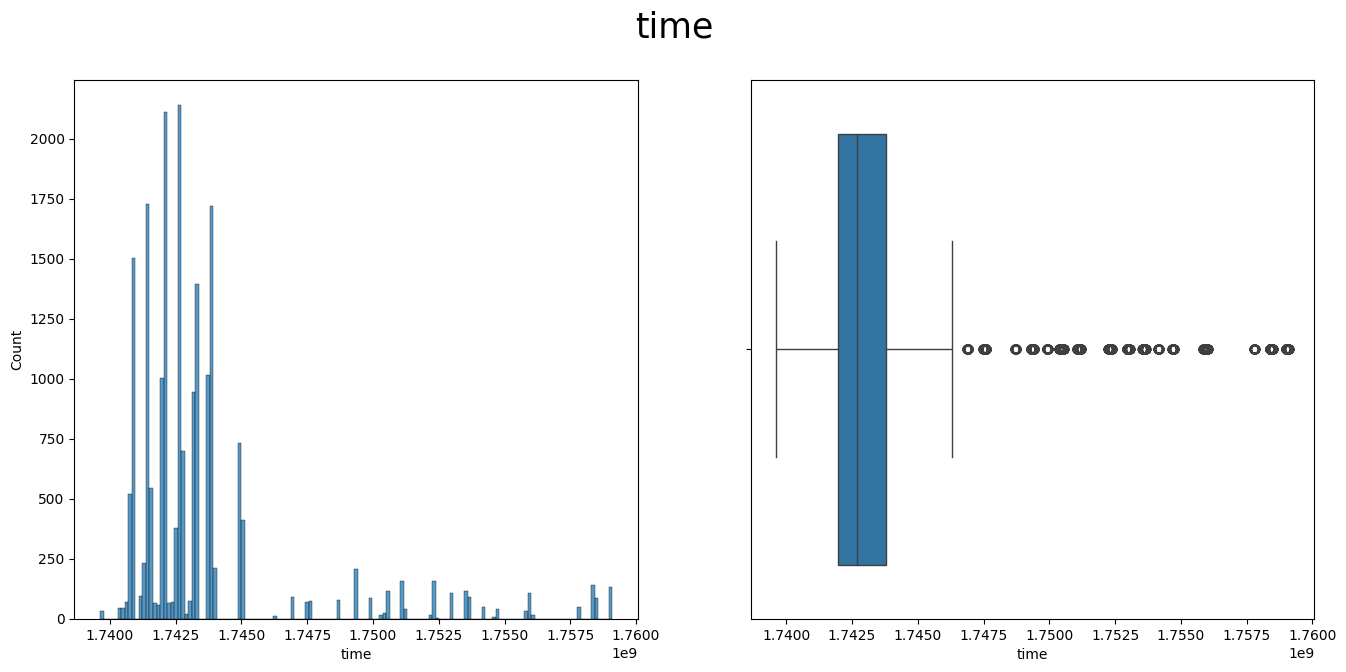

In [185]:
num_plot("time")

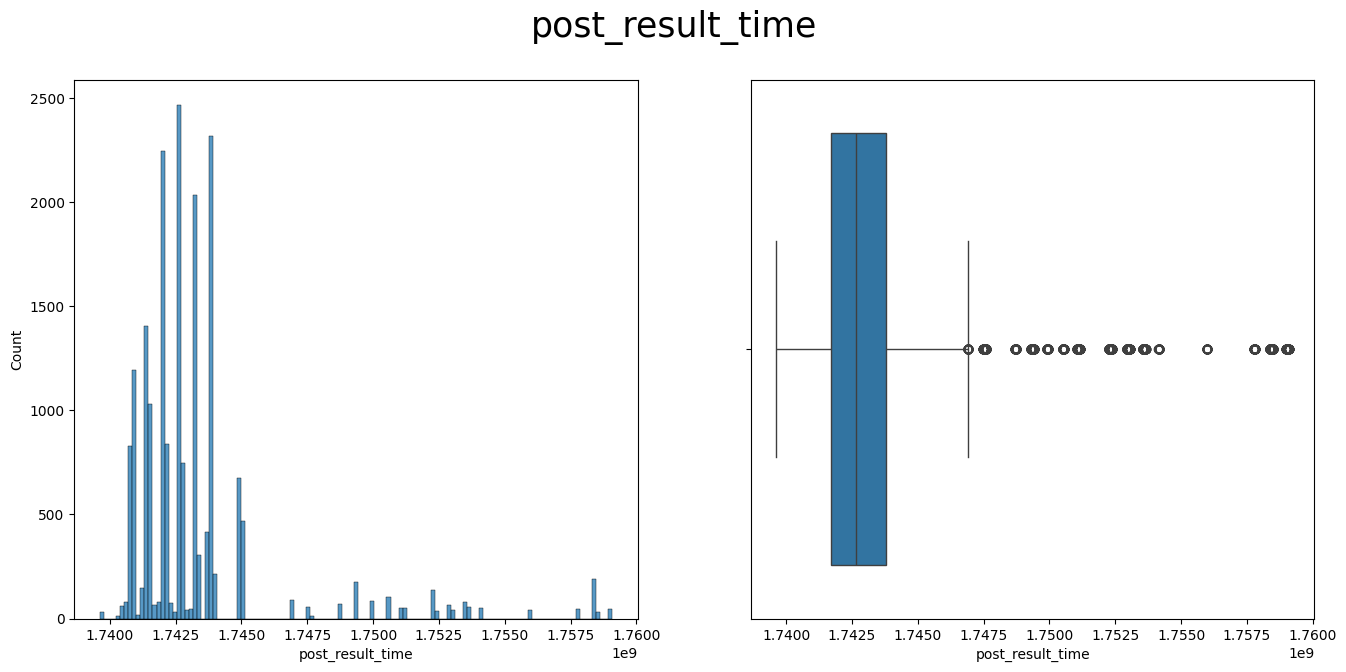

In [186]:
num_plot("post_result_time")

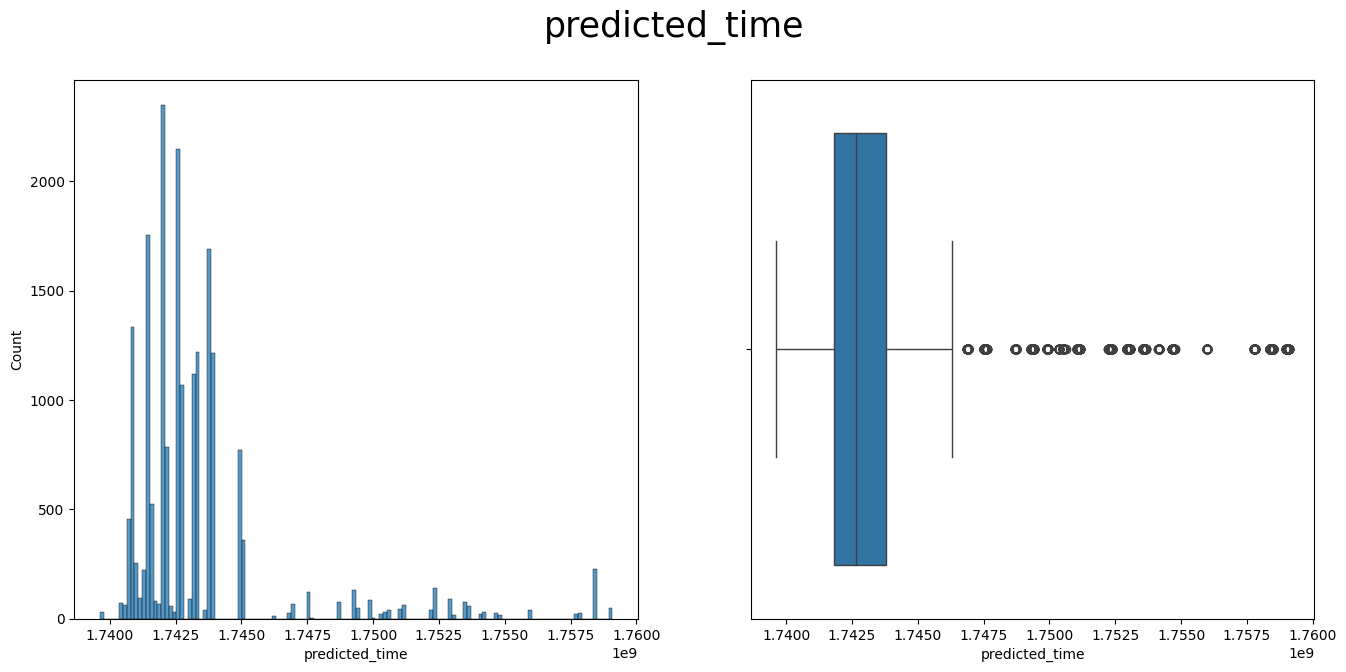

In [187]:
num_plot("predicted_time")

#### about games

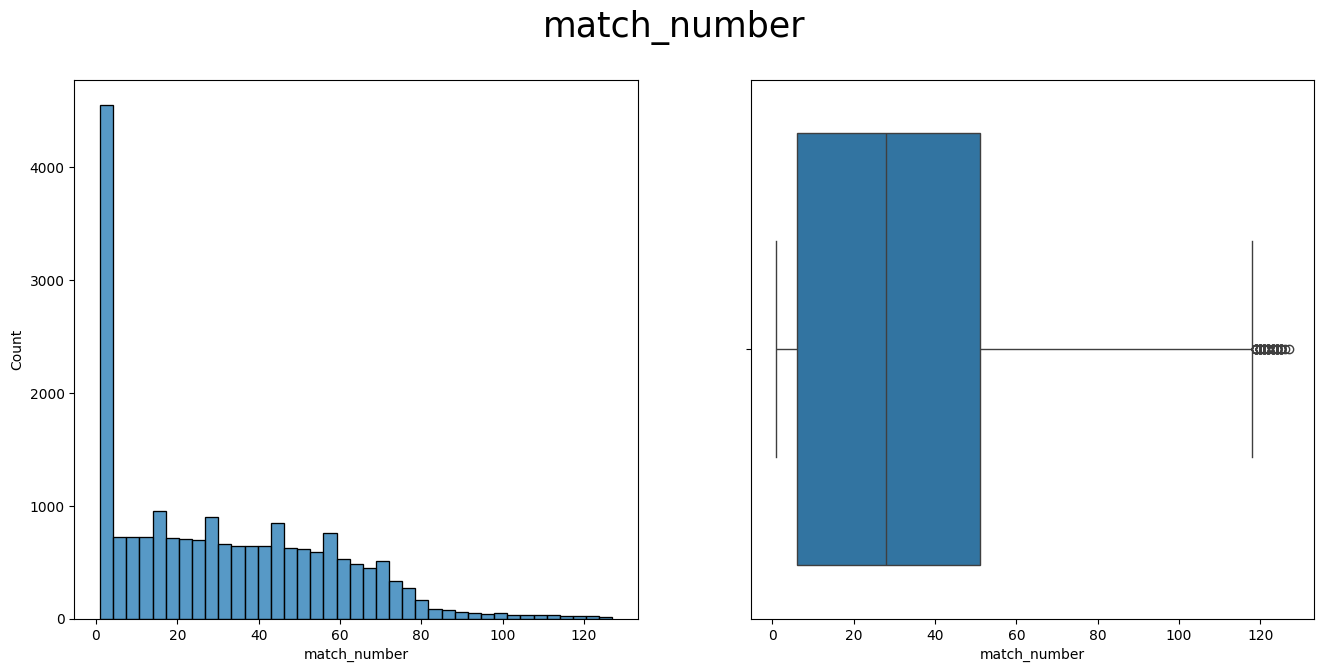

In [188]:
num_plot("match_number")

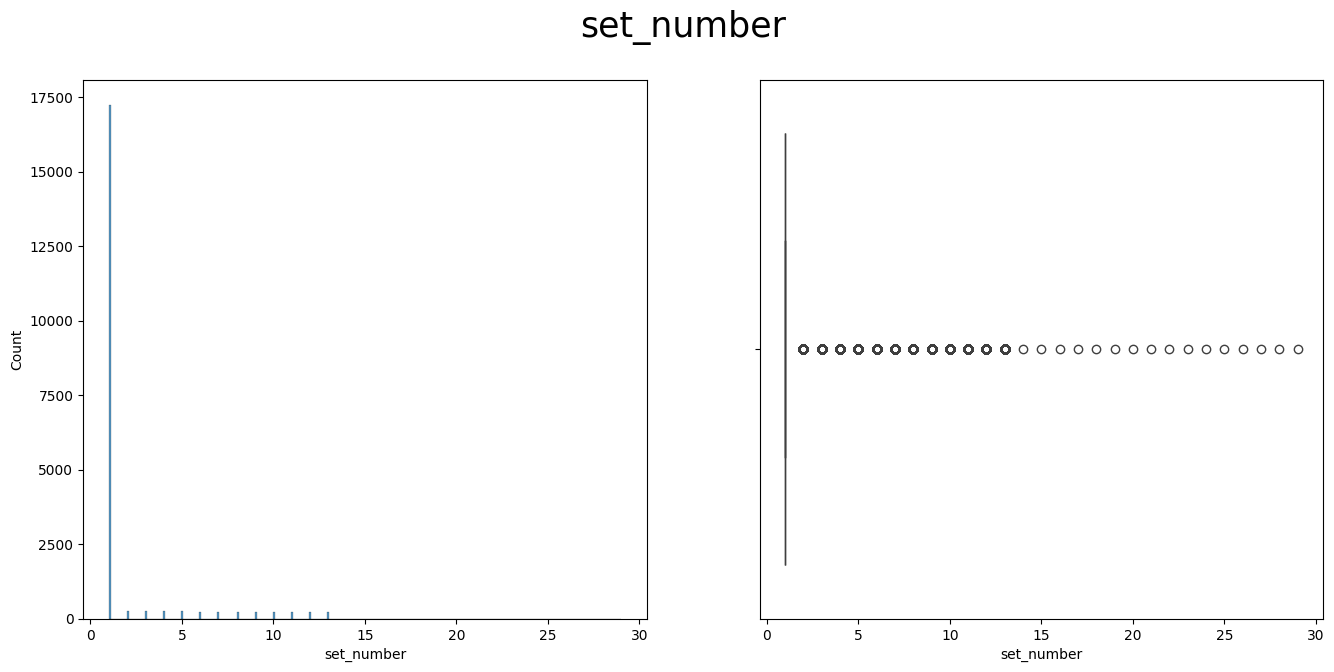

In [189]:
num_plot("set_number")

### Scores

#### blue scores

##### auto

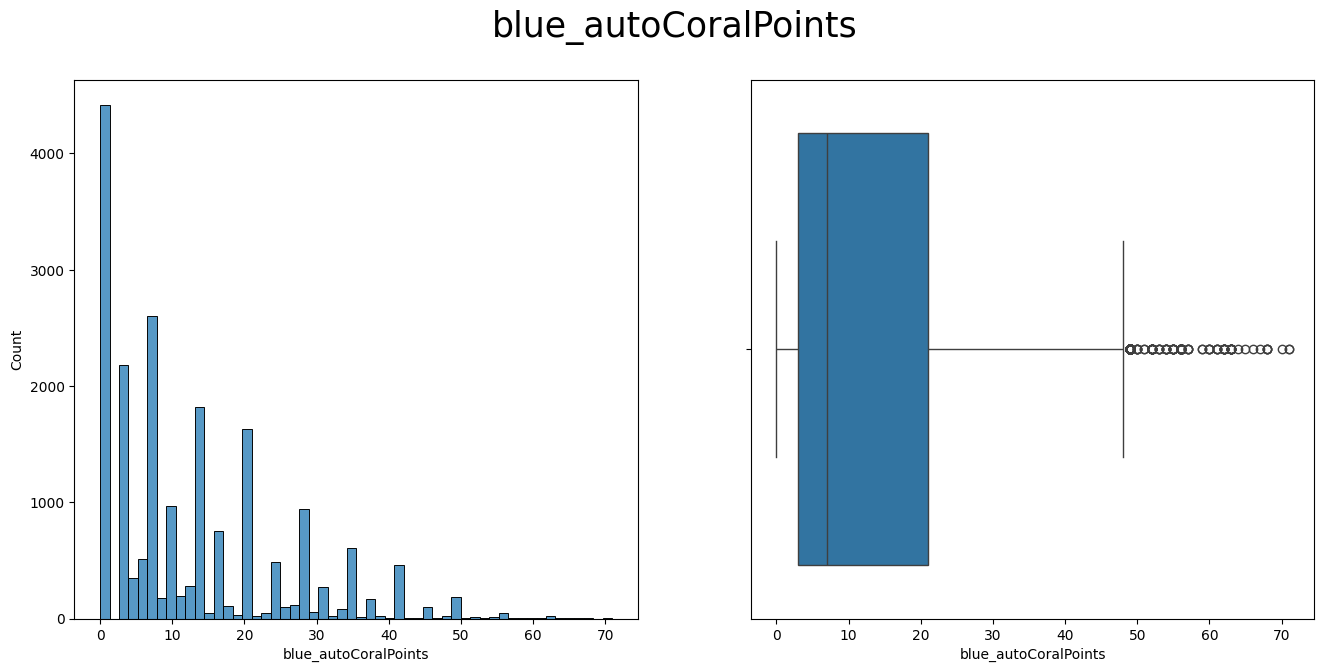

In [190]:
num_plot("blue_autoCoralPoints")

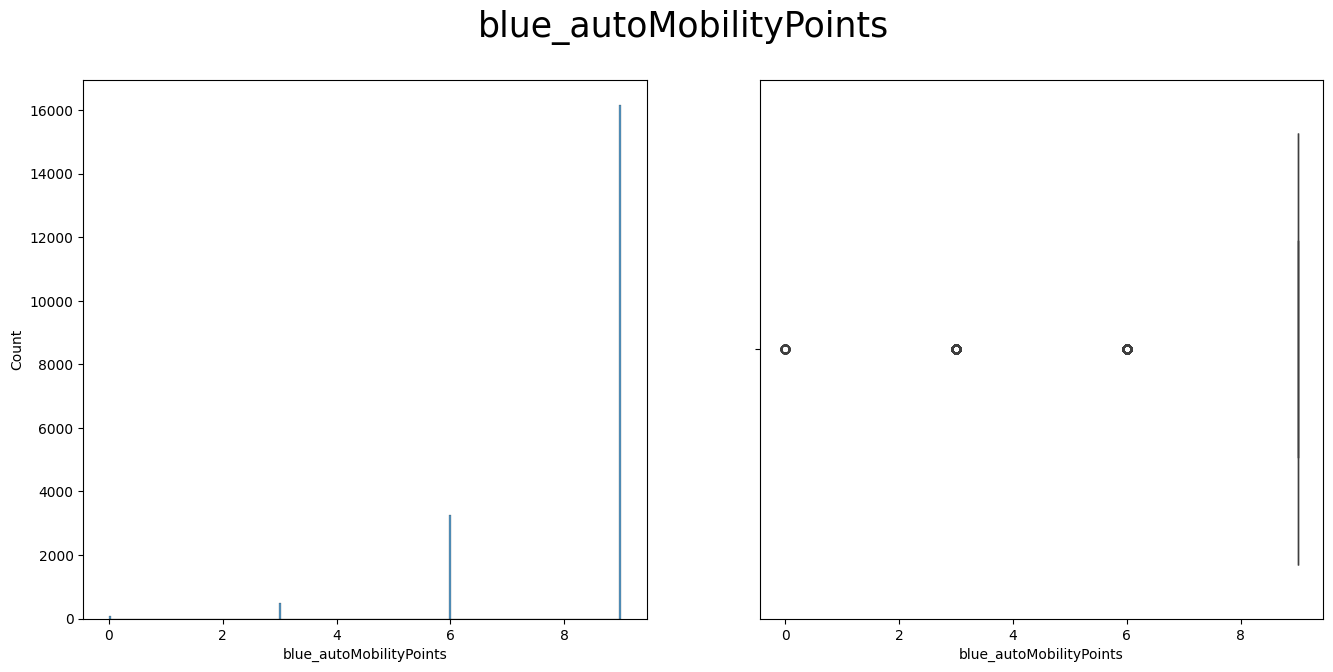

In [191]:
num_plot("blue_autoMobilityPoints")

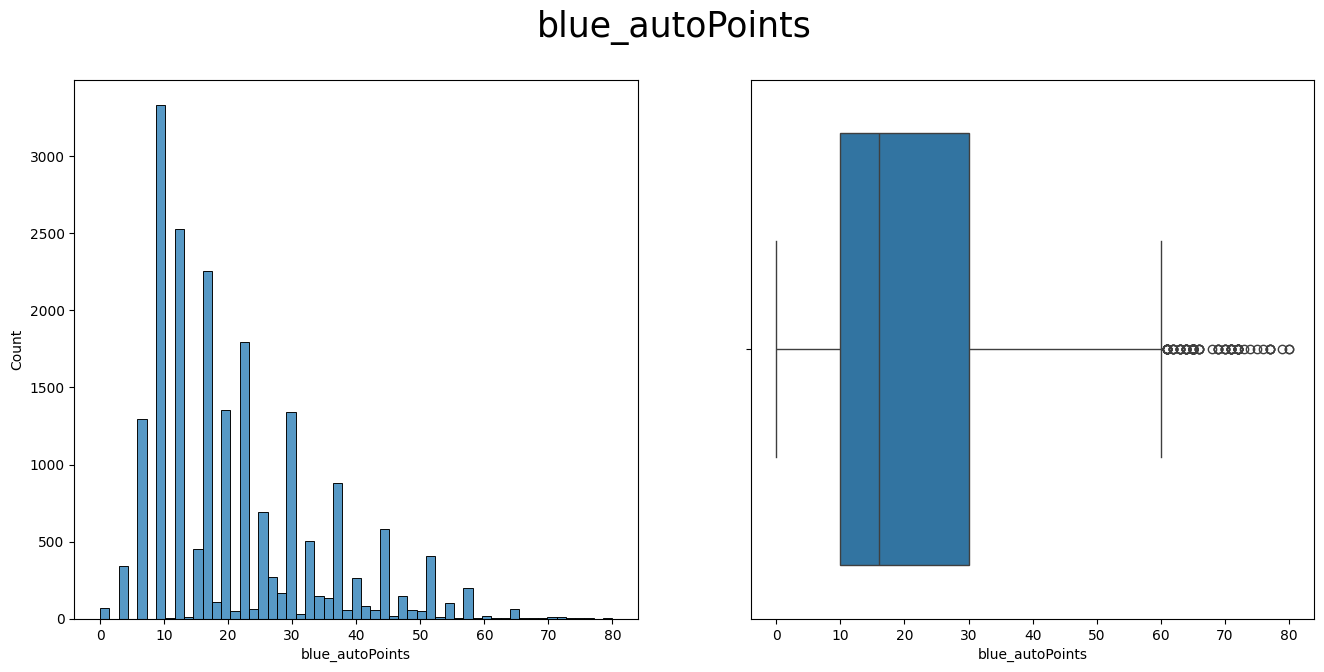

In [192]:
num_plot("blue_autoPoints")

##### teleop

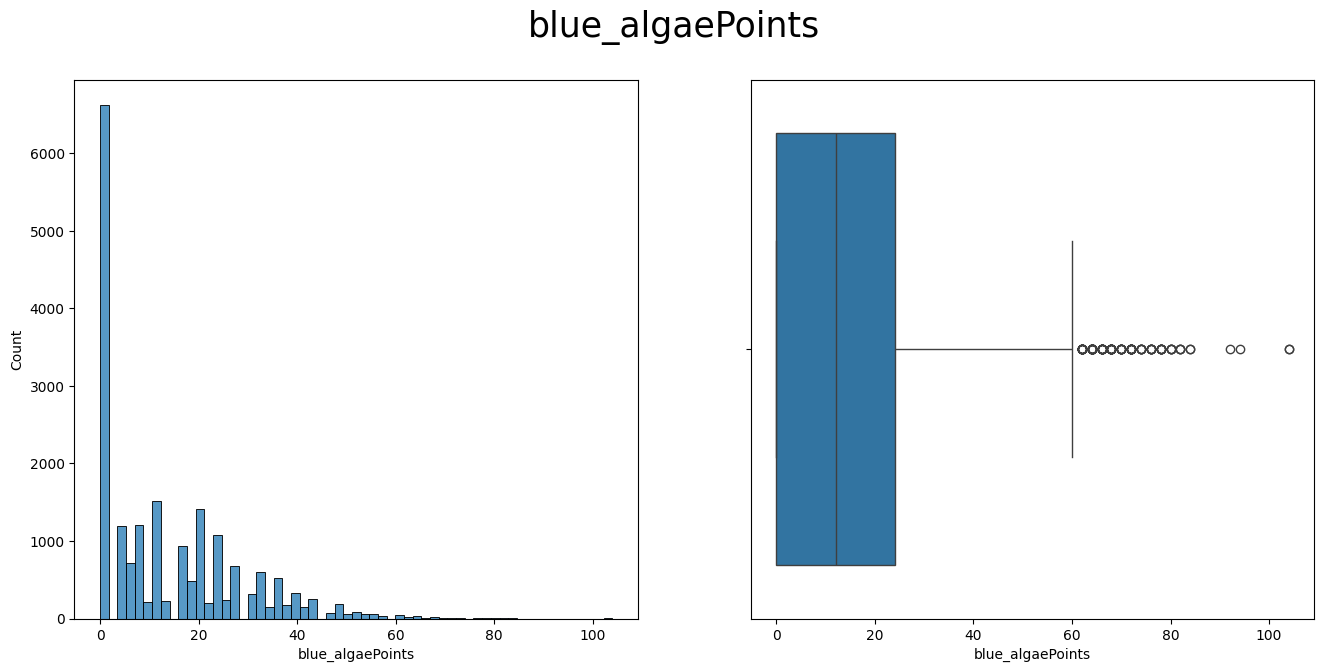

In [193]:
num_plot("blue_algaePoints")

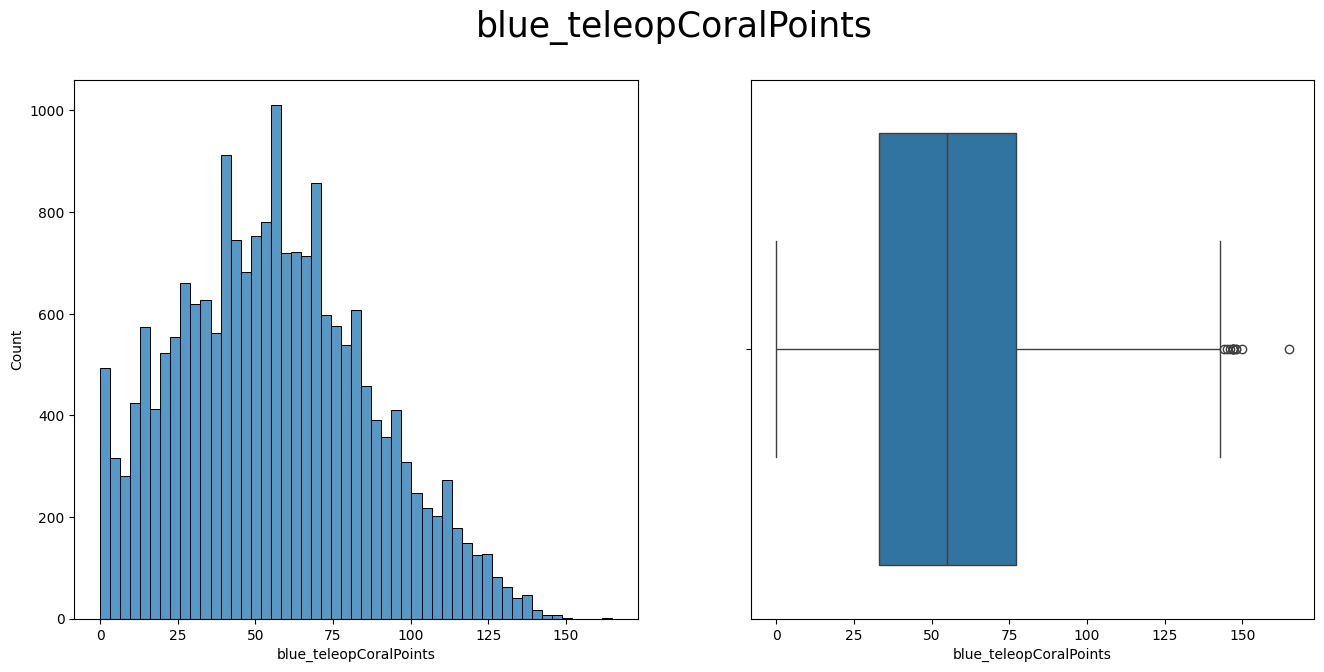

In [194]:
num_plot("blue_teleopCoralPoints")

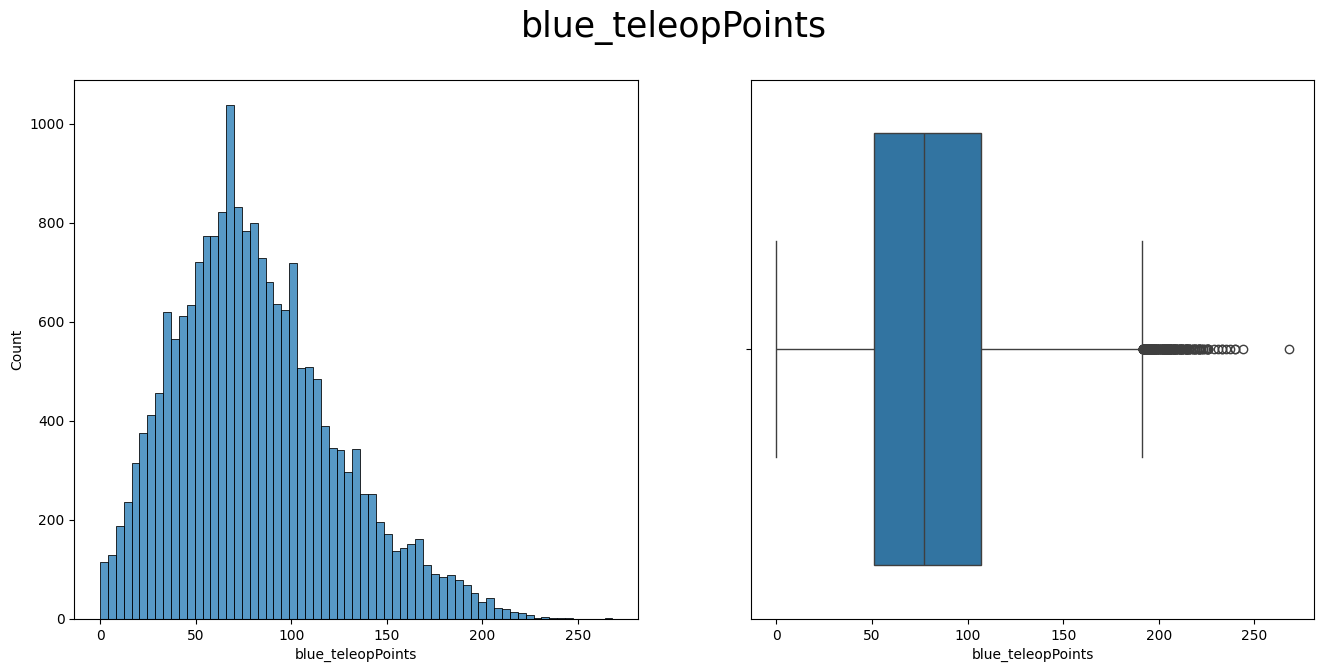

In [195]:
num_plot("blue_teleopPoints")

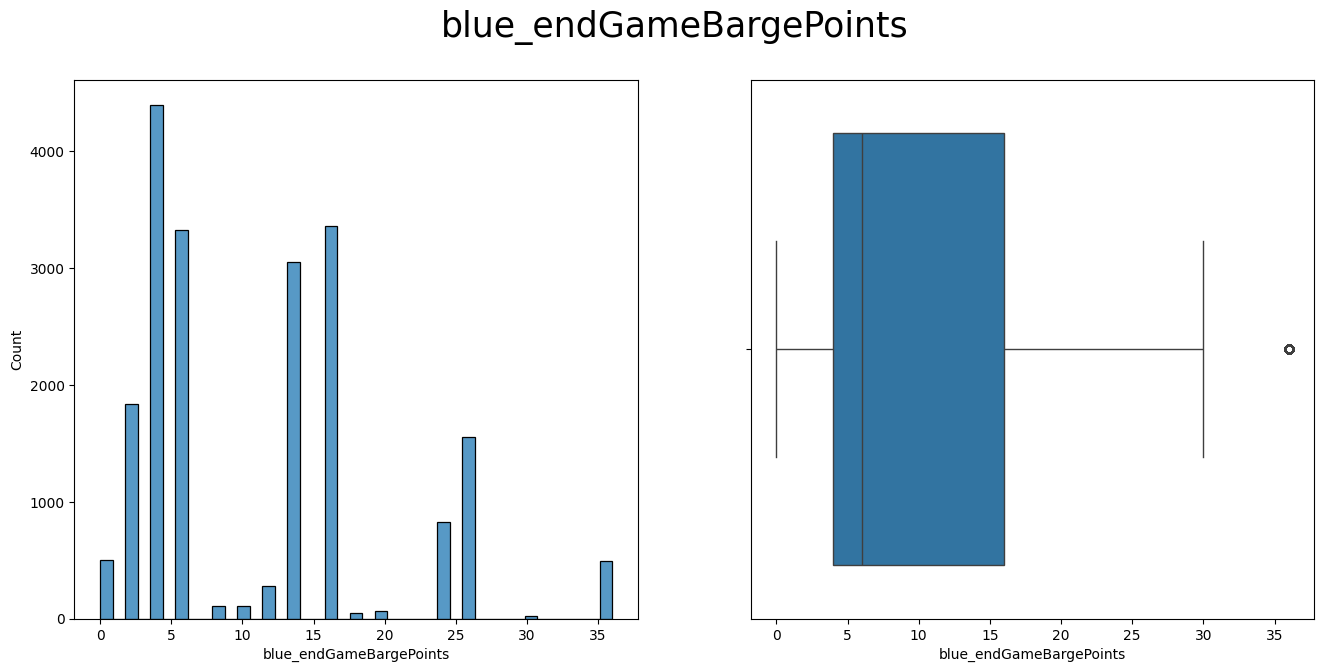

In [196]:
num_plot("blue_endGameBargePoints")

##### else

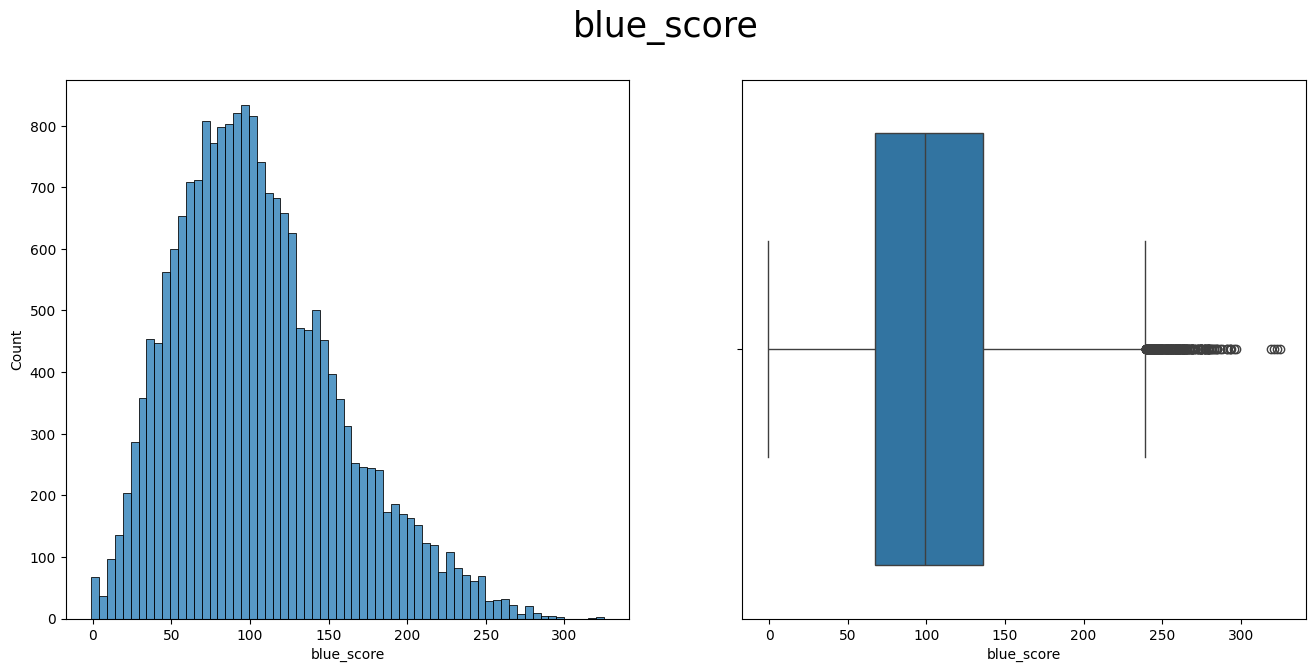

In [197]:
num_plot("blue_score")

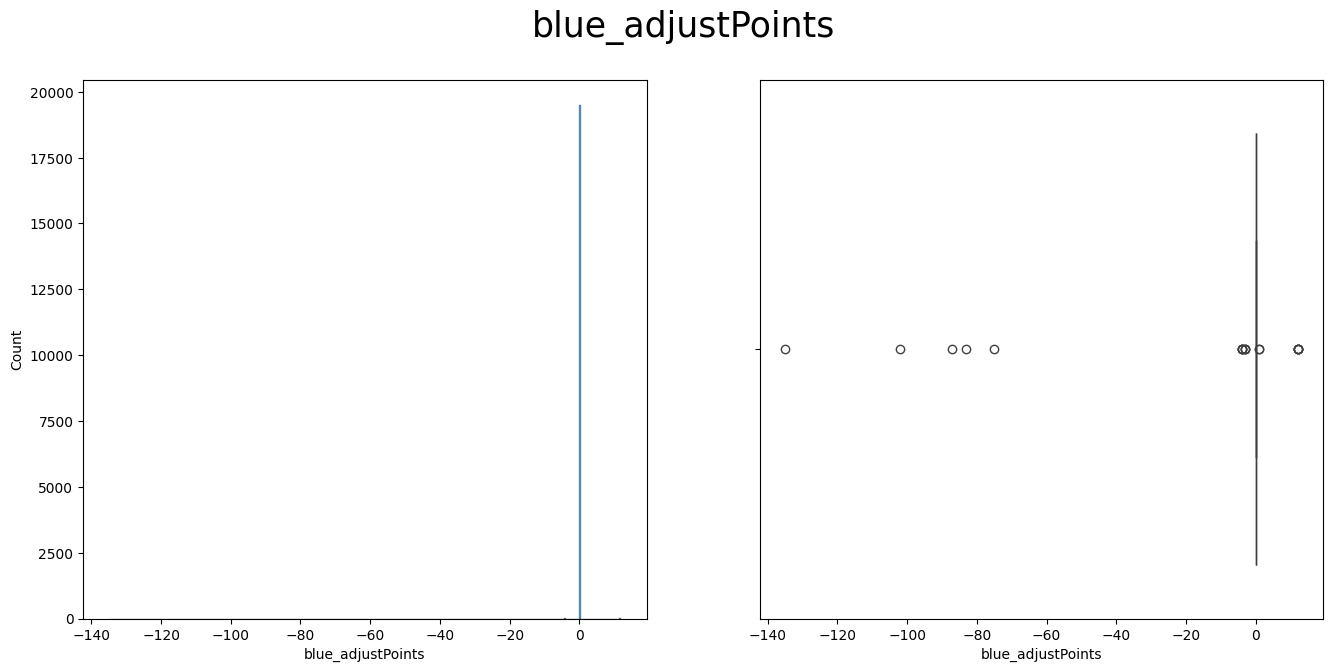

In [198]:
num_plot("blue_adjustPoints")

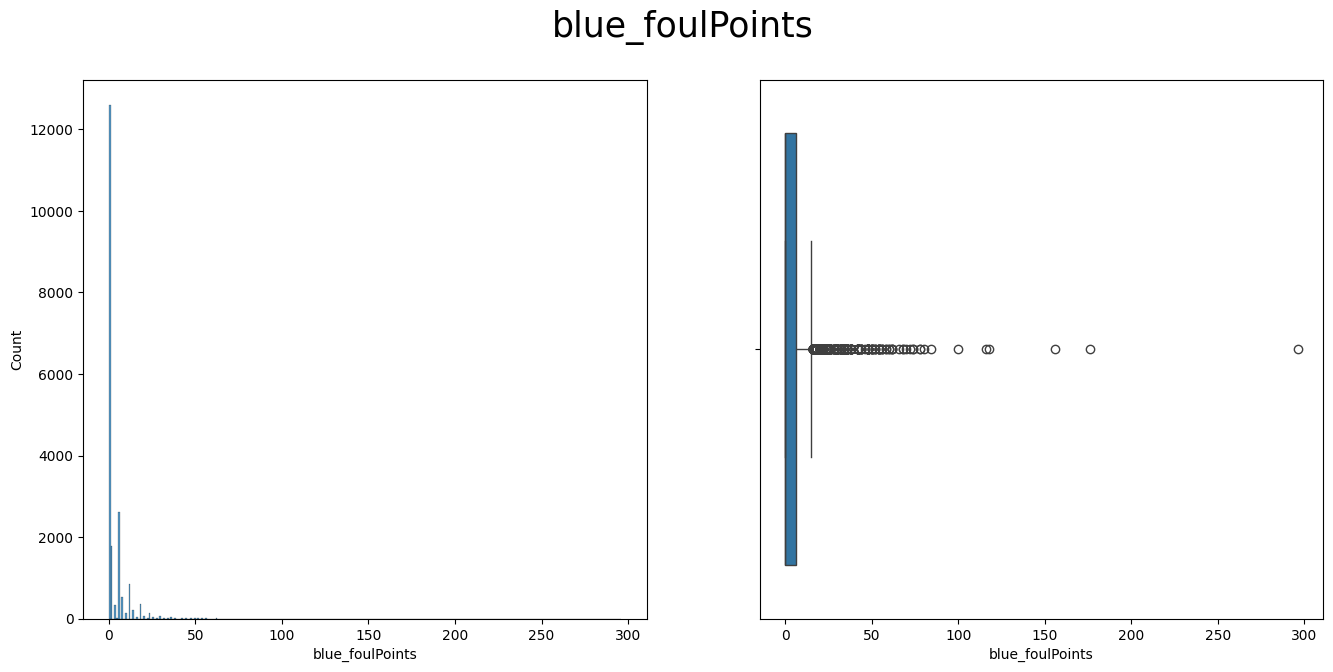

In [199]:
num_plot("blue_foulPoints")

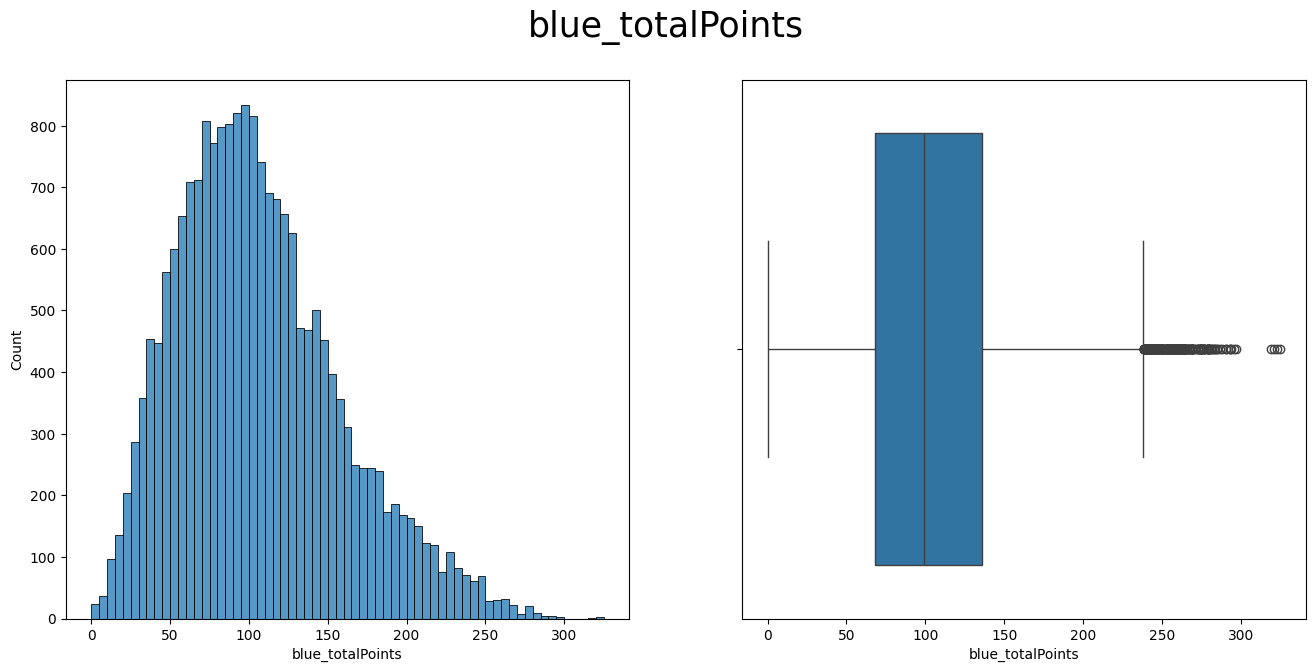

In [200]:
num_plot("blue_totalPoints")

#### red scores

##### auto

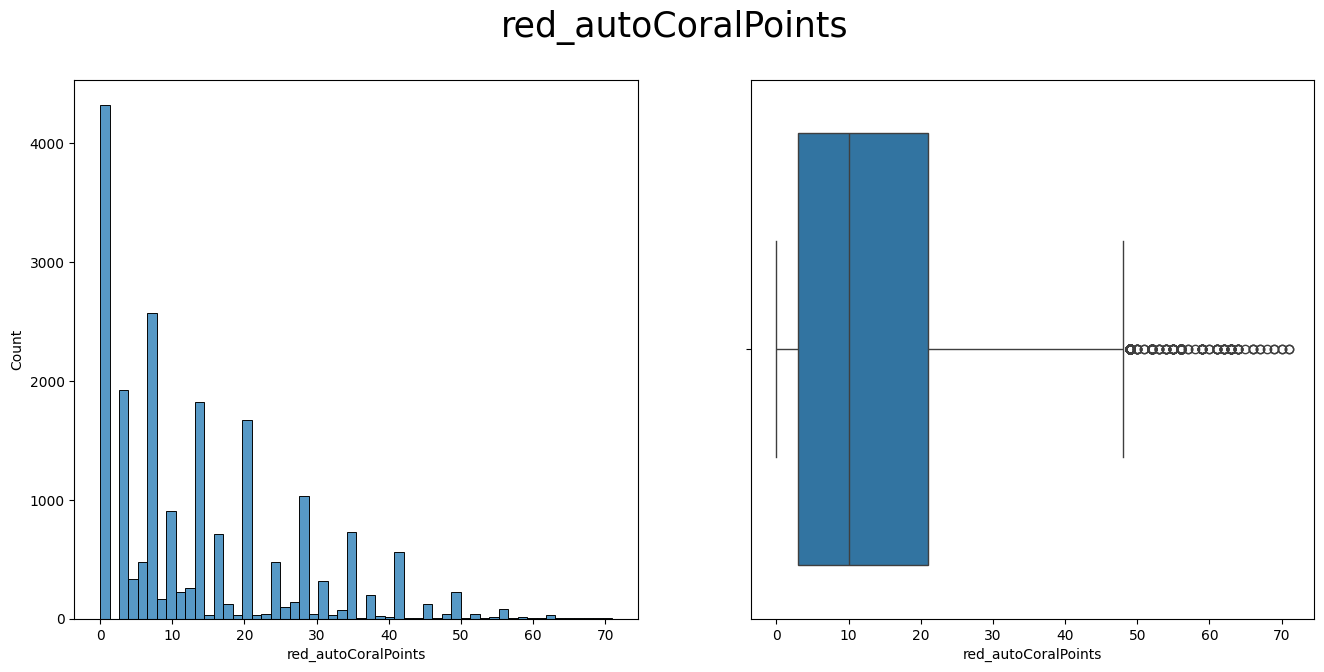

In [201]:
num_plot("red_autoCoralPoints")

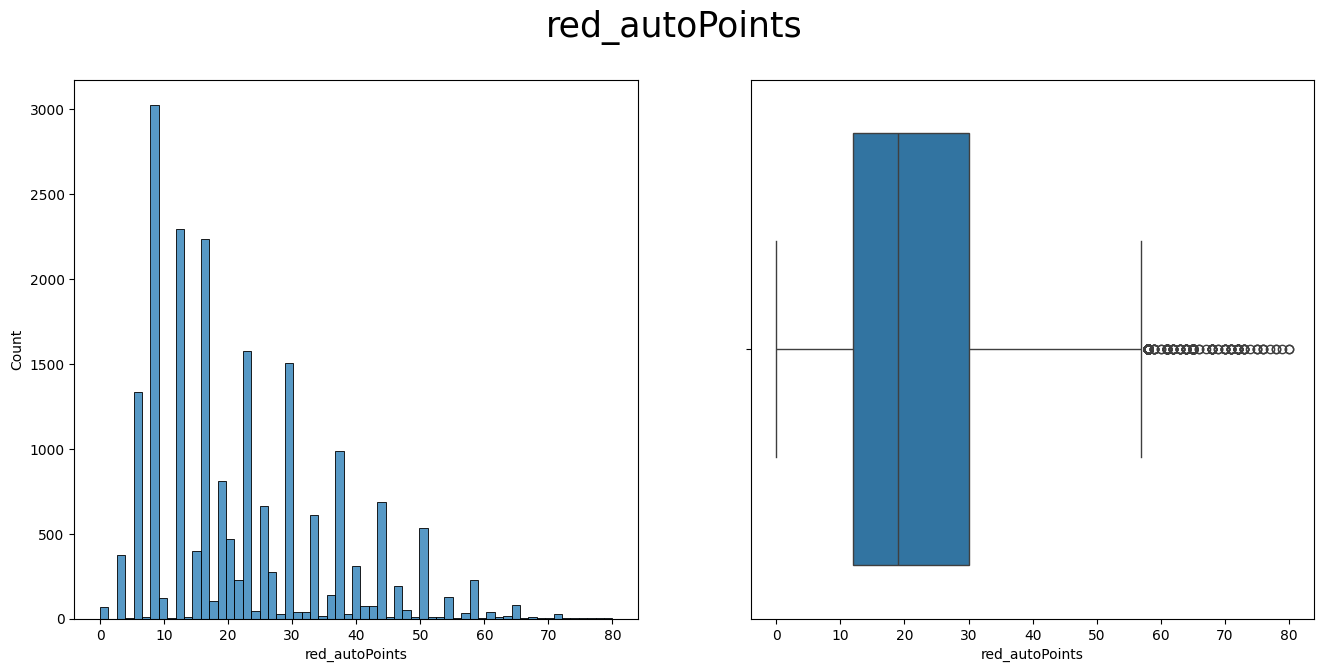

In [202]:
num_plot("red_autoPoints")

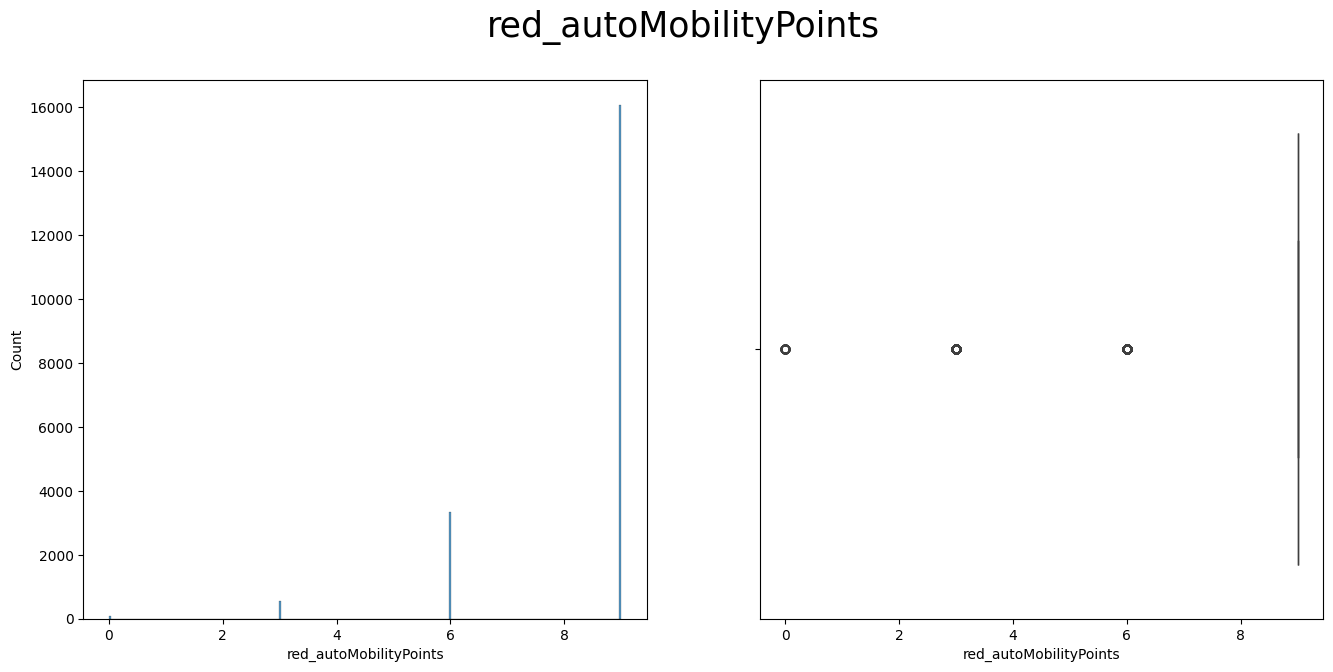

In [203]:
num_plot("red_autoMobilityPoints")

##### teleop

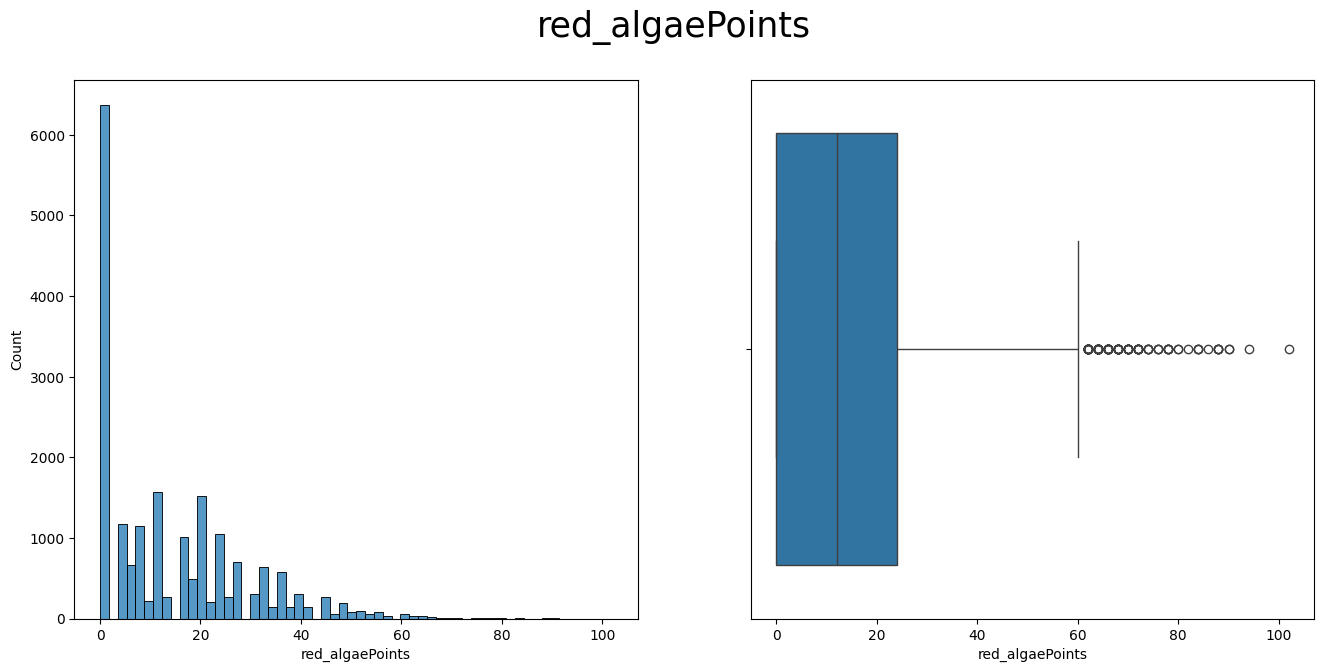

In [204]:
num_plot("red_algaePoints")

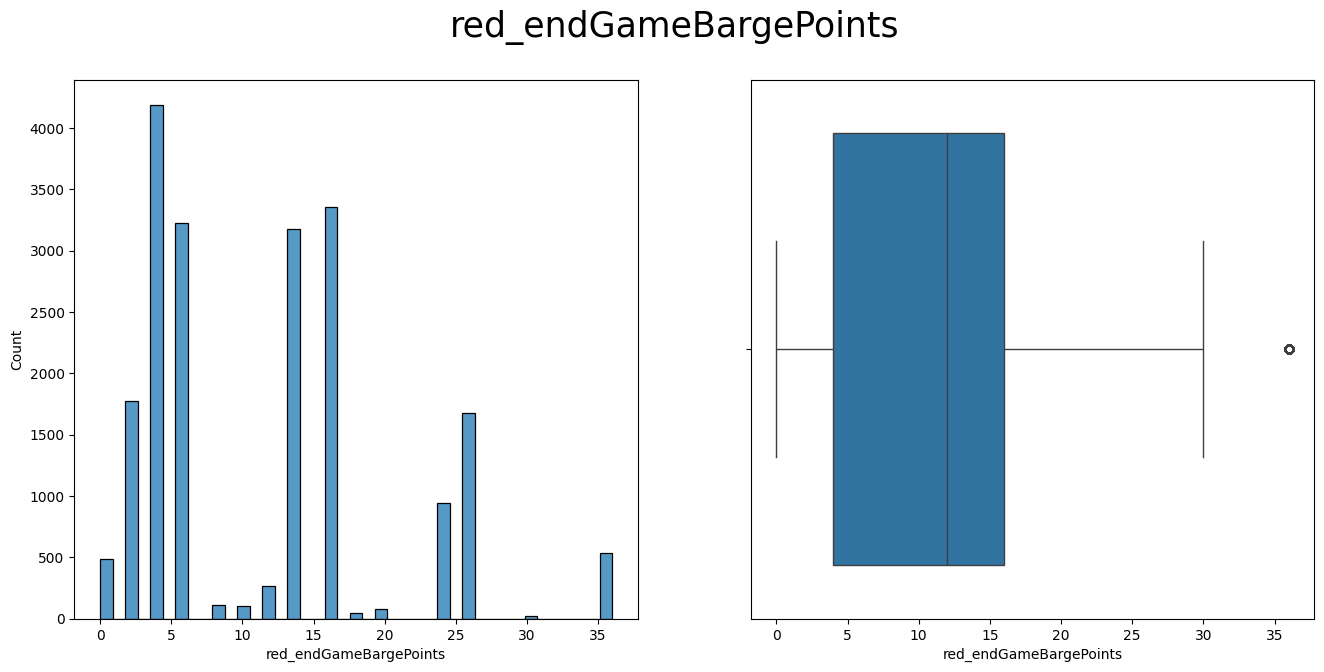

In [205]:
num_plot("red_endGameBargePoints")

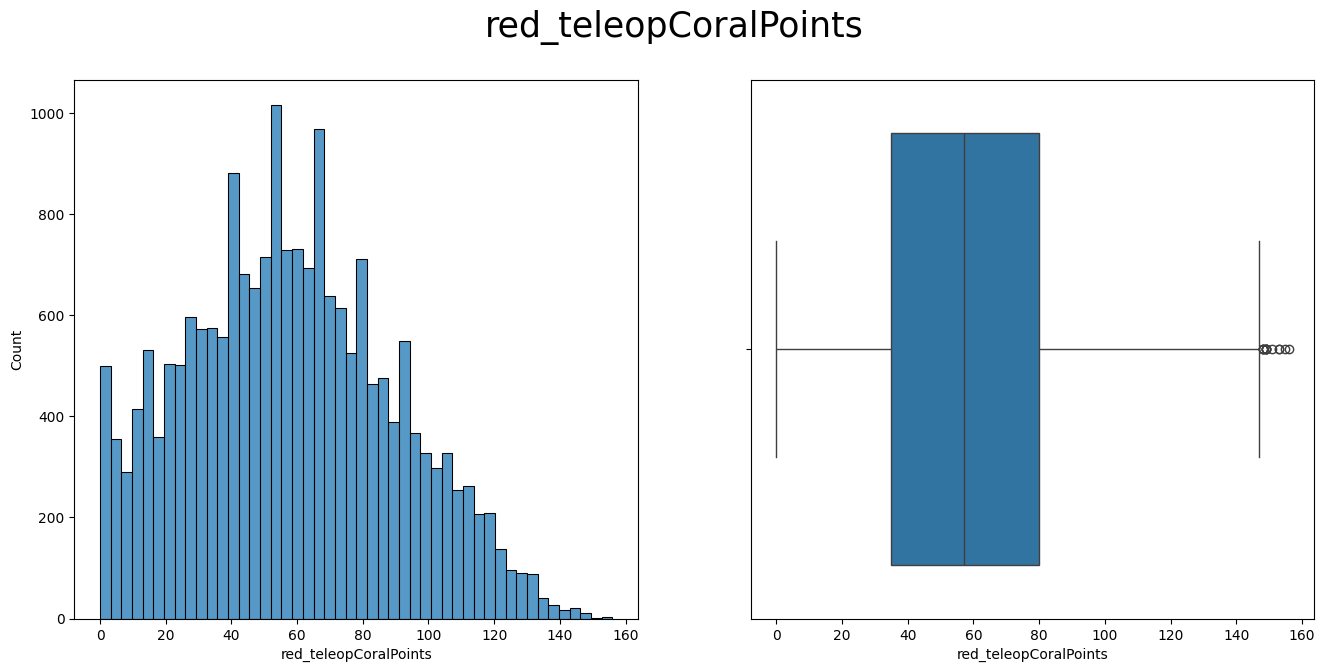

In [206]:
num_plot("red_teleopCoralPoints")

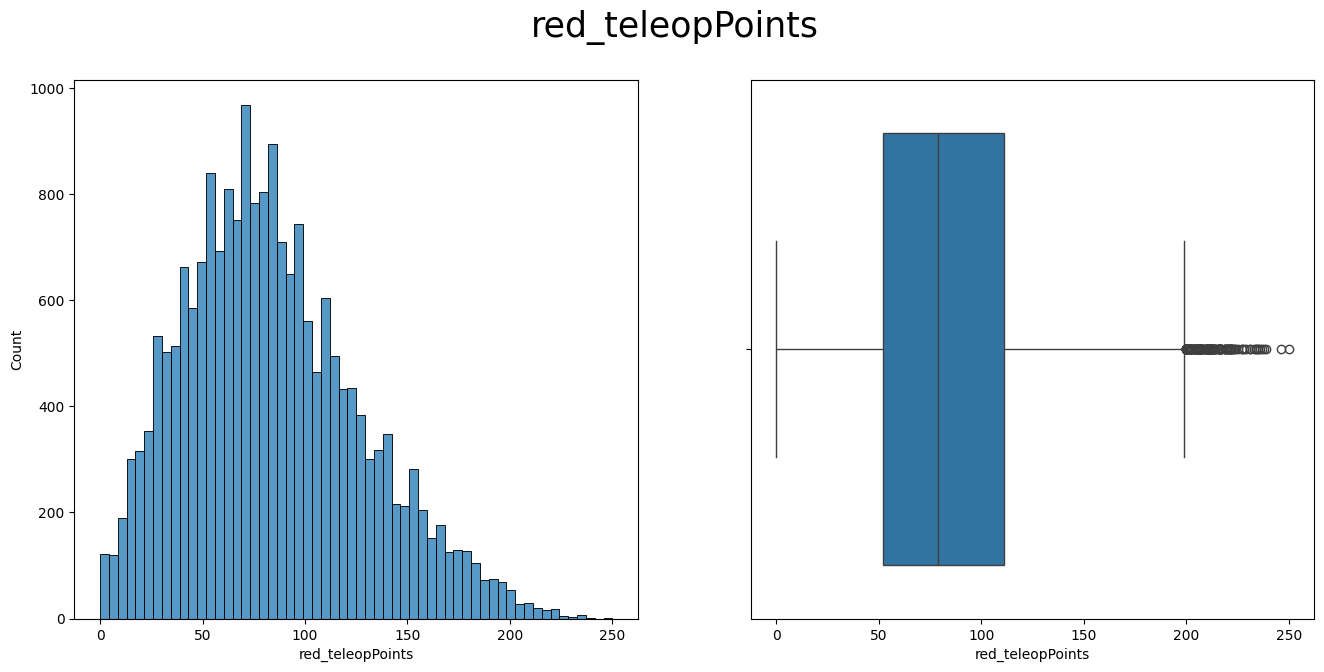

In [207]:
num_plot("red_teleopPoints")

##### else

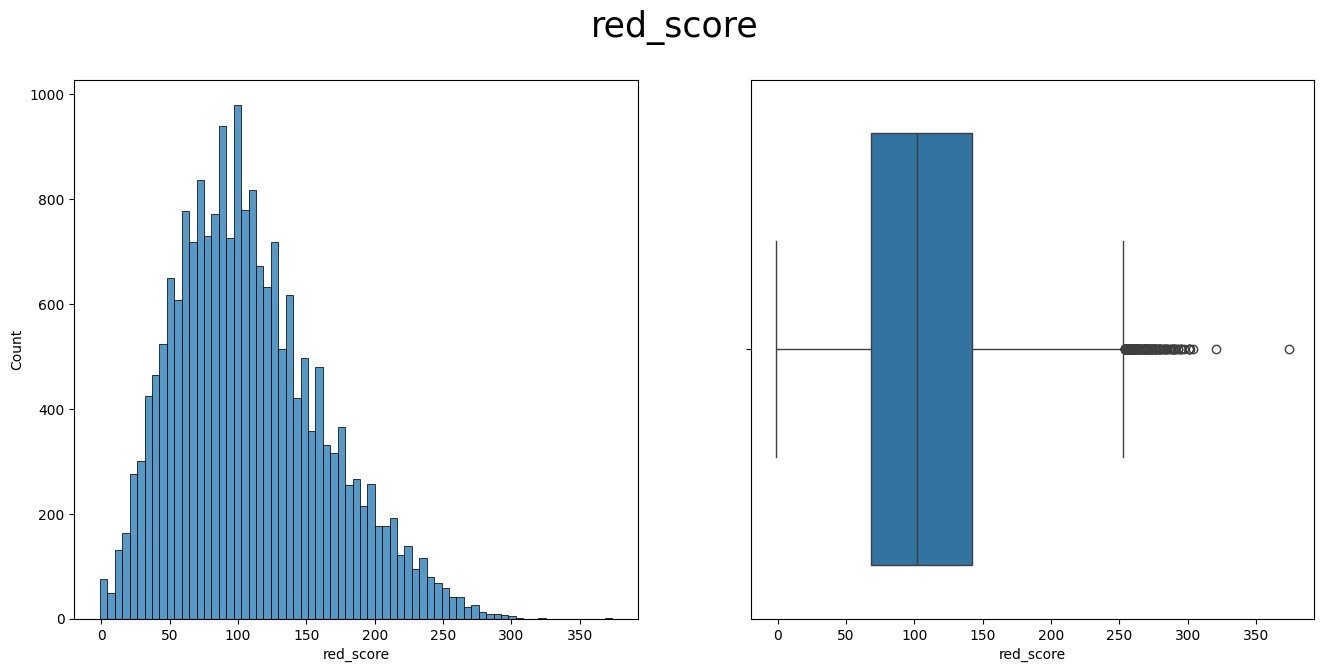

In [208]:
num_plot("red_score")

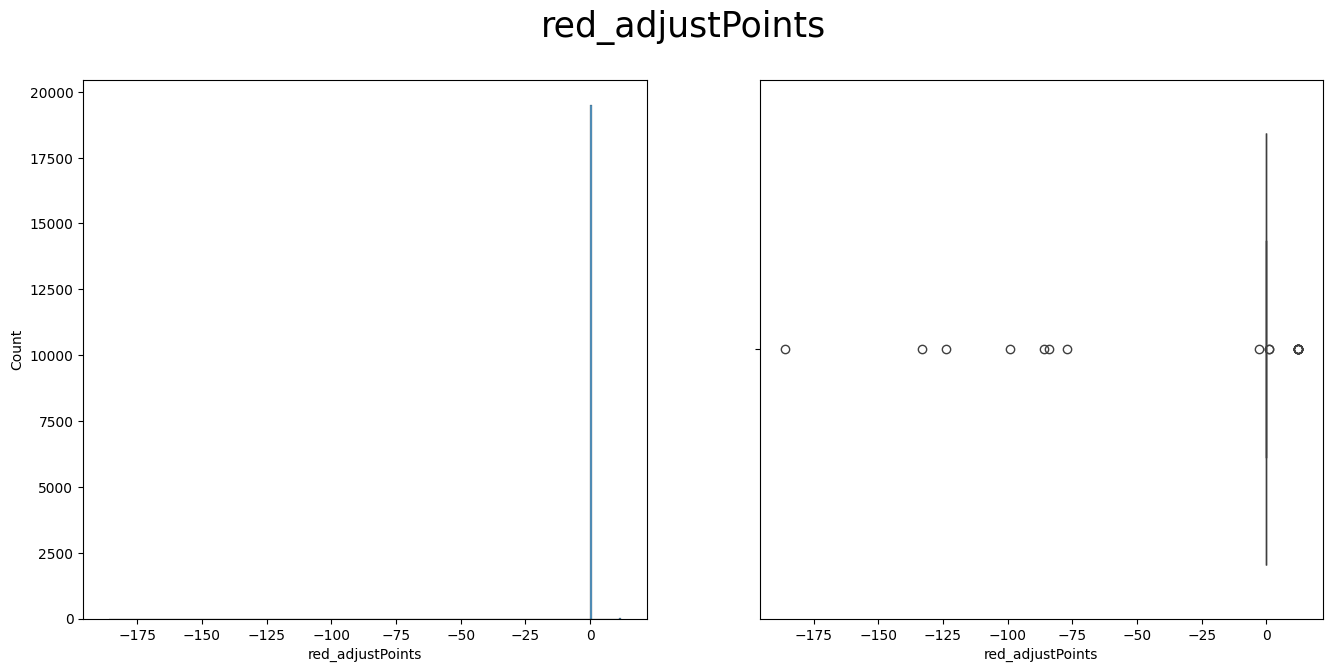

In [209]:
num_plot("red_adjustPoints")

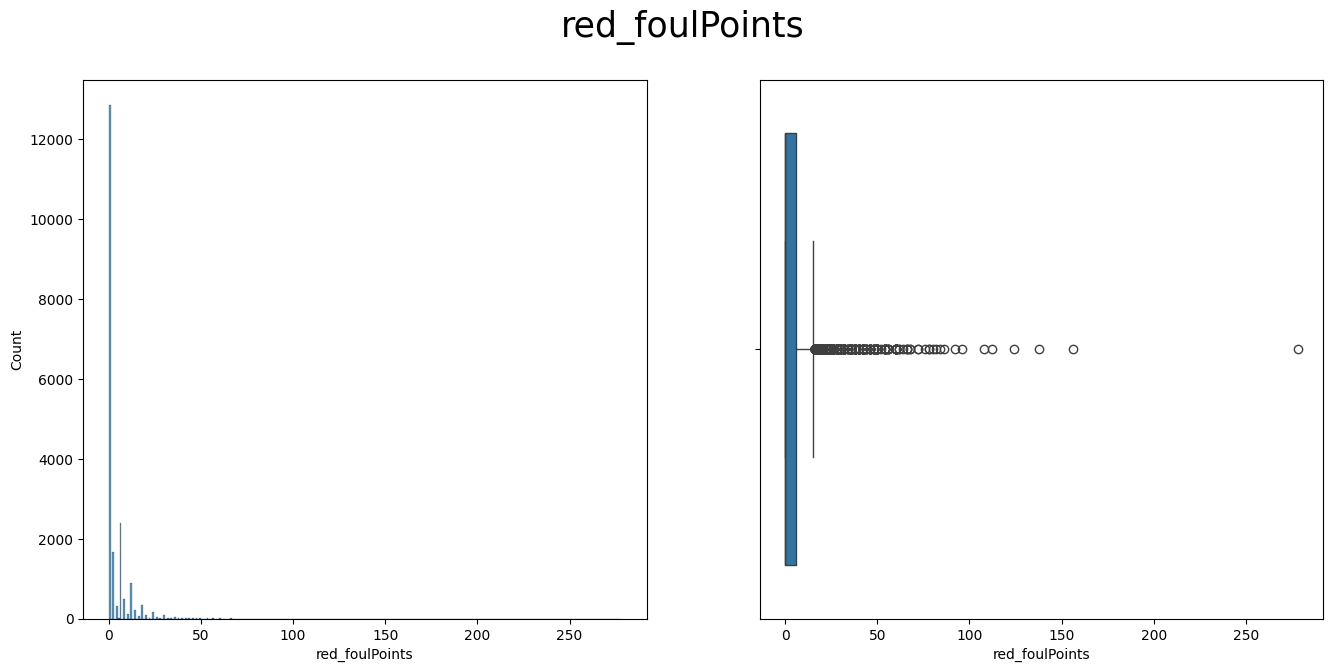

In [210]:
num_plot("red_foulPoints")

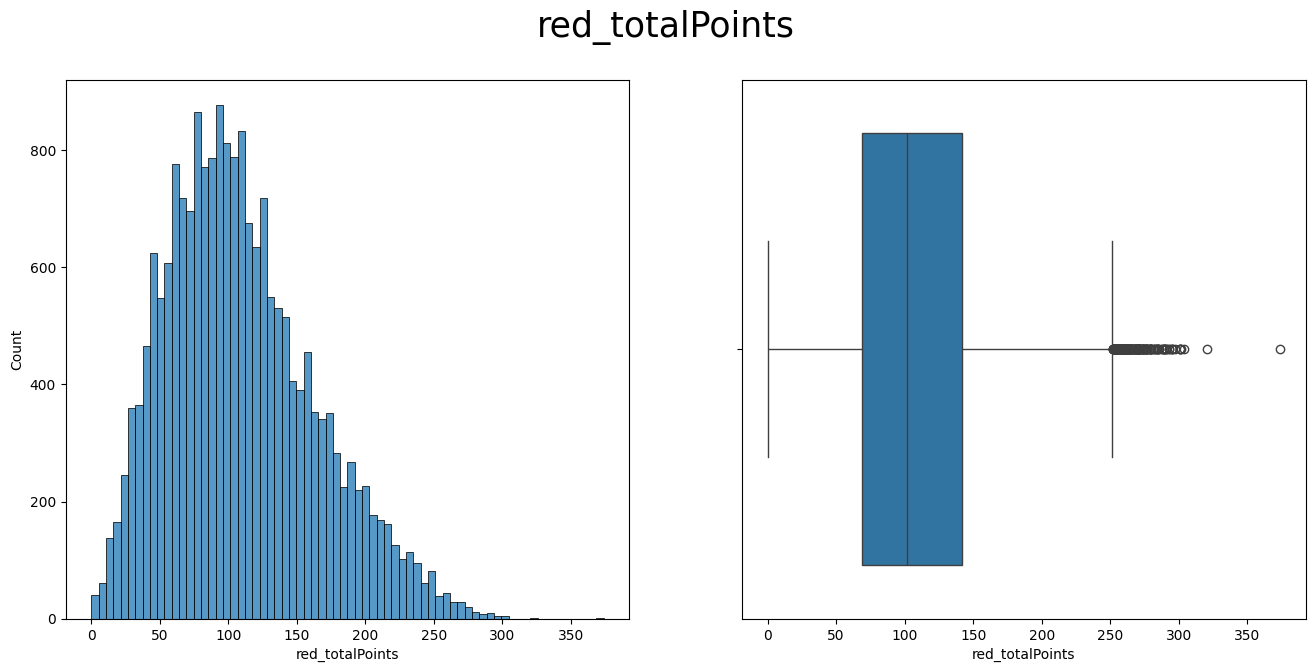

In [211]:
num_plot("red_totalPoints")

### counts

#### blue counts

##### corals

auto

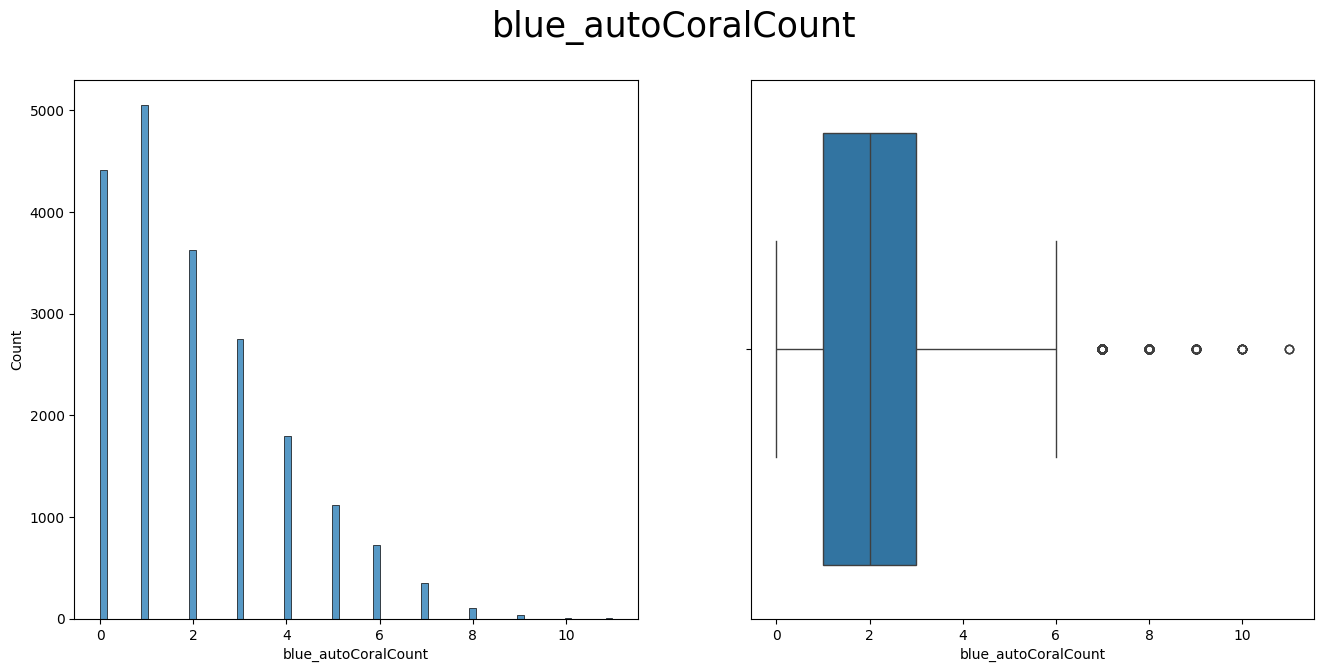

In [212]:
num_plot("blue_autoCoralCount")

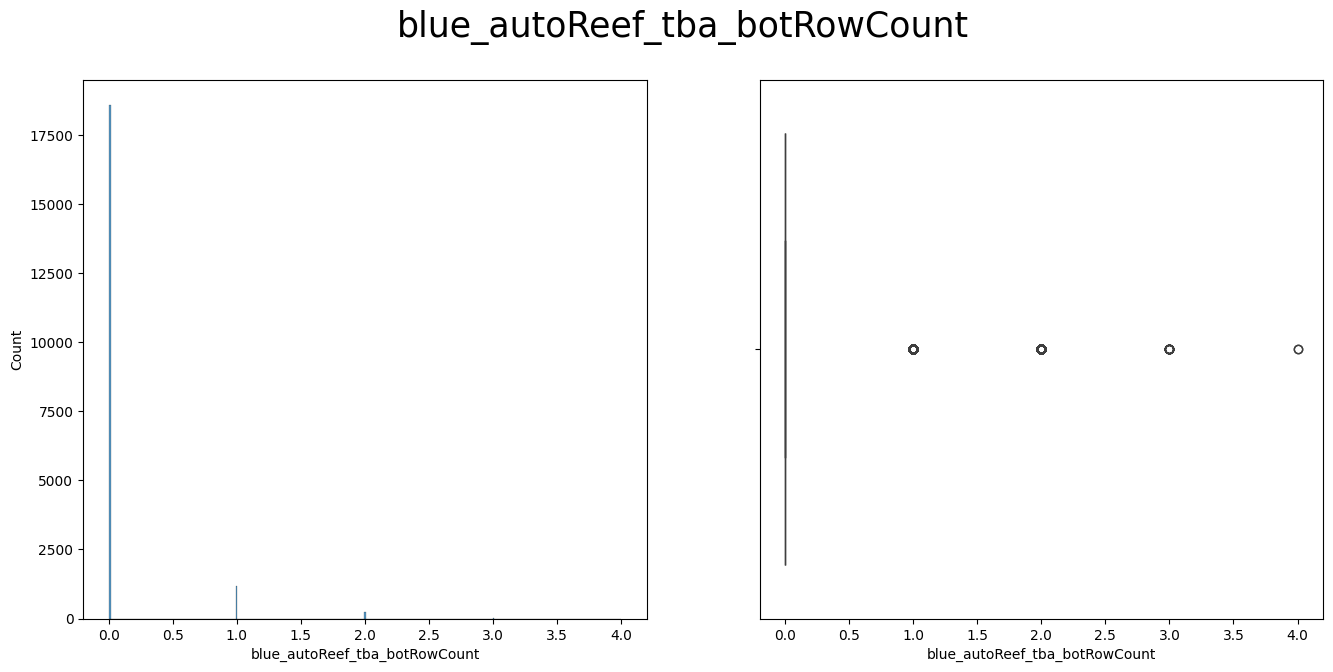

In [213]:
num_plot("blue_autoReef_tba_botRowCount")

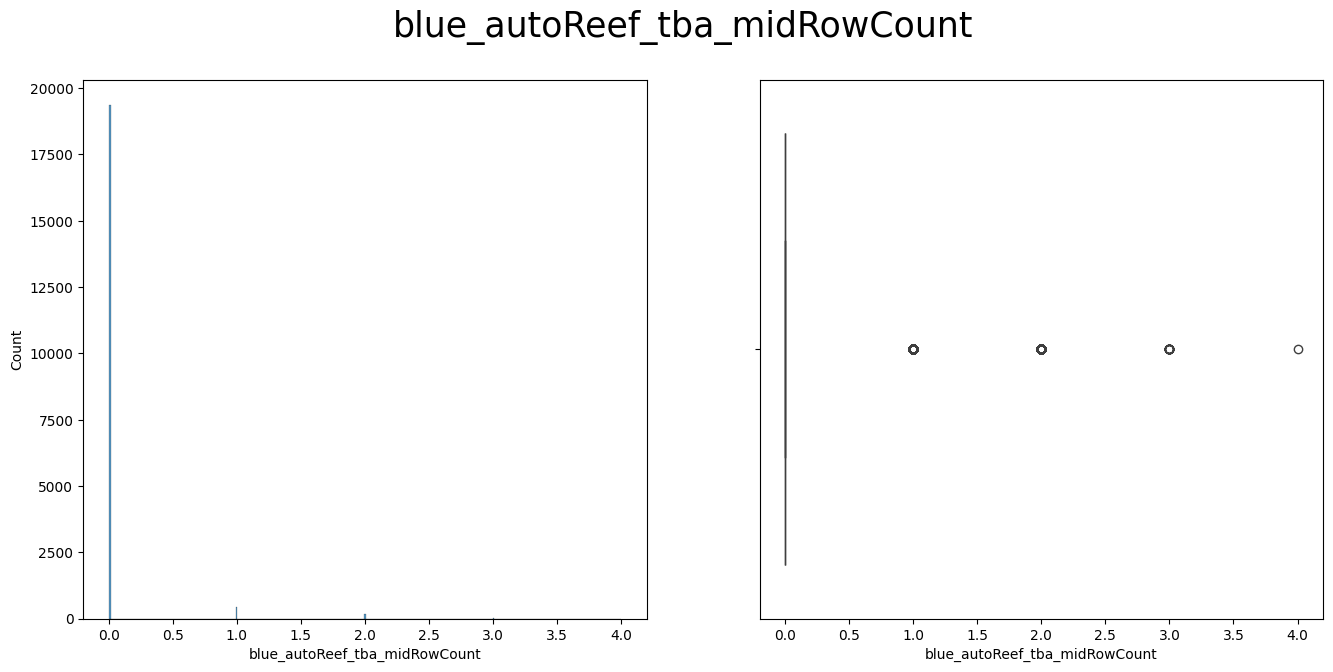

In [214]:
num_plot("blue_autoReef_tba_midRowCount")

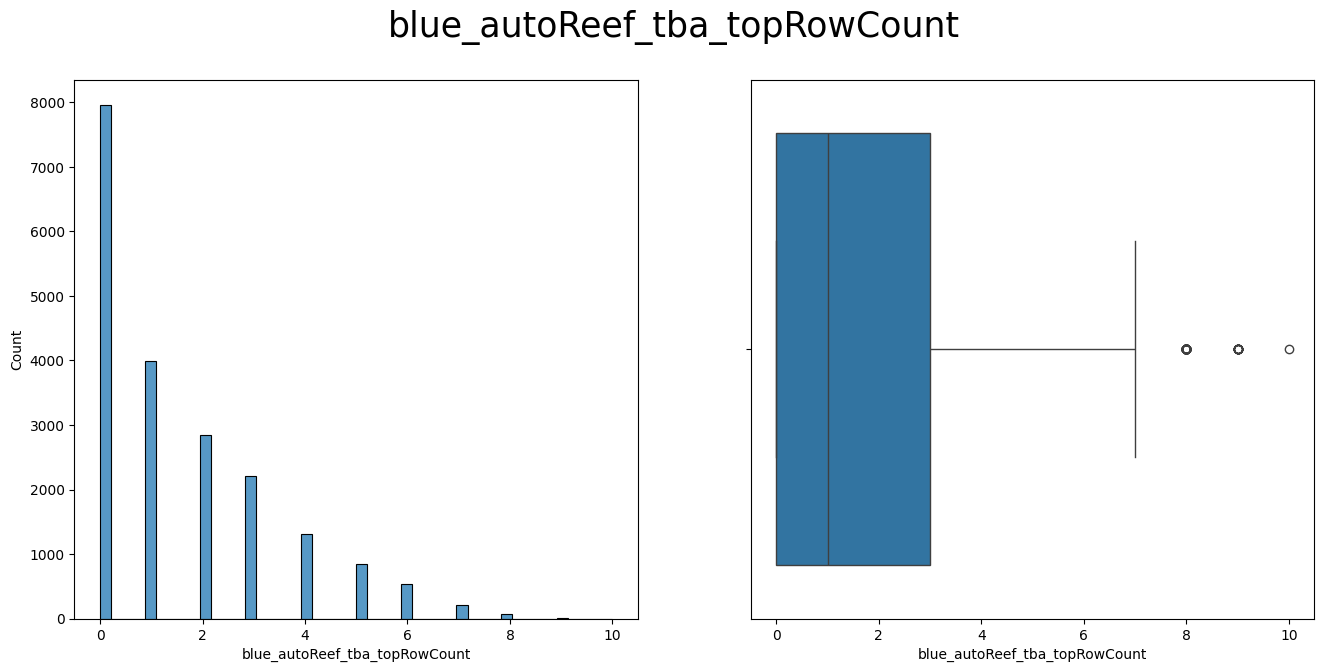

In [215]:
num_plot("blue_autoReef_tba_topRowCount")

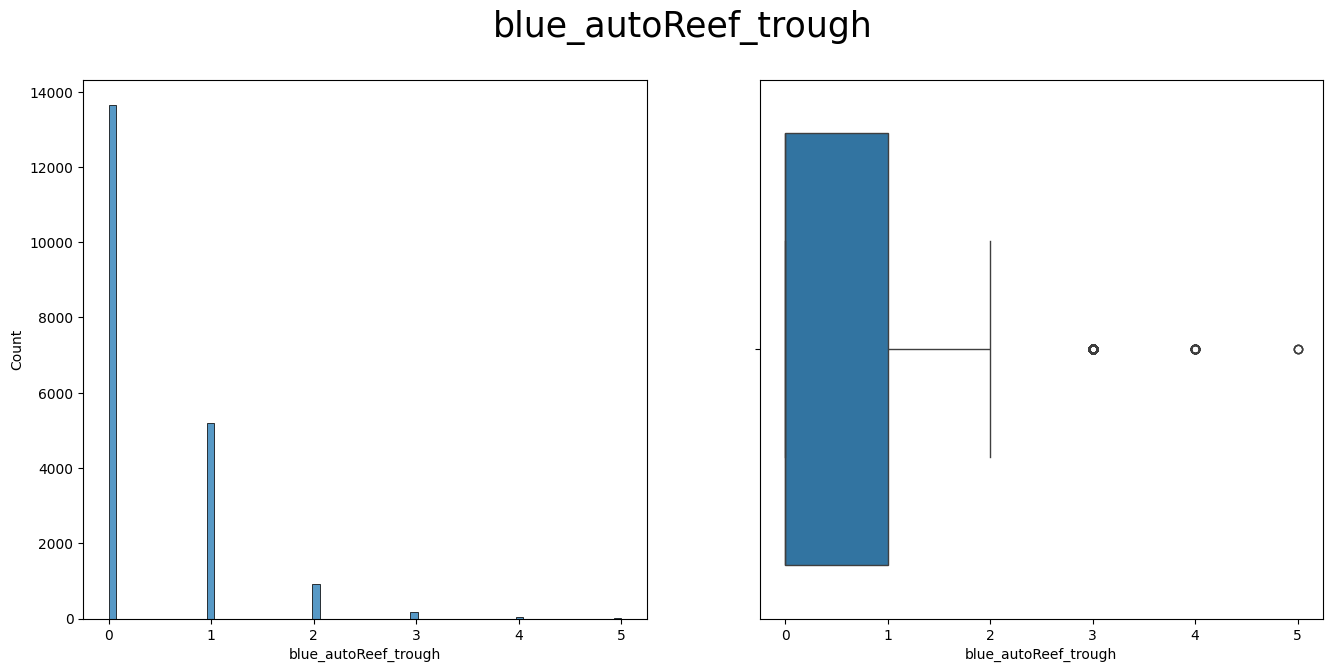

In [216]:
num_plot("blue_autoReef_trough")

teleop

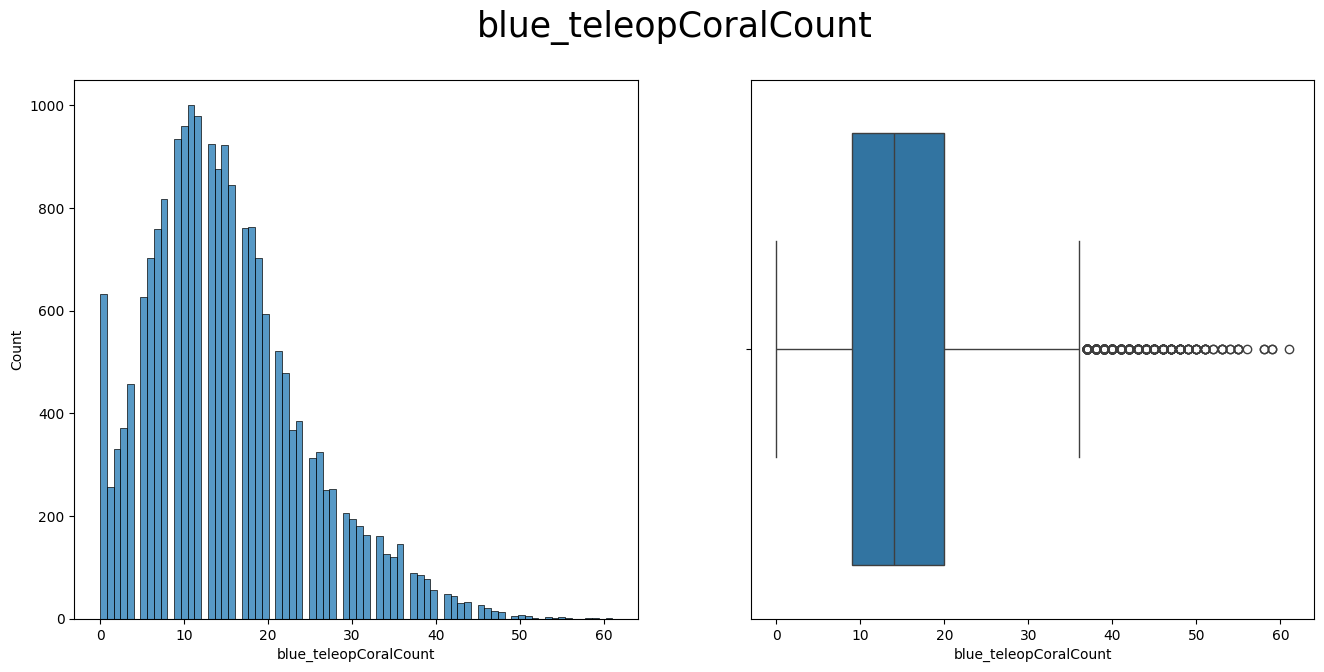

In [217]:
num_plot("blue_teleopCoralCount")

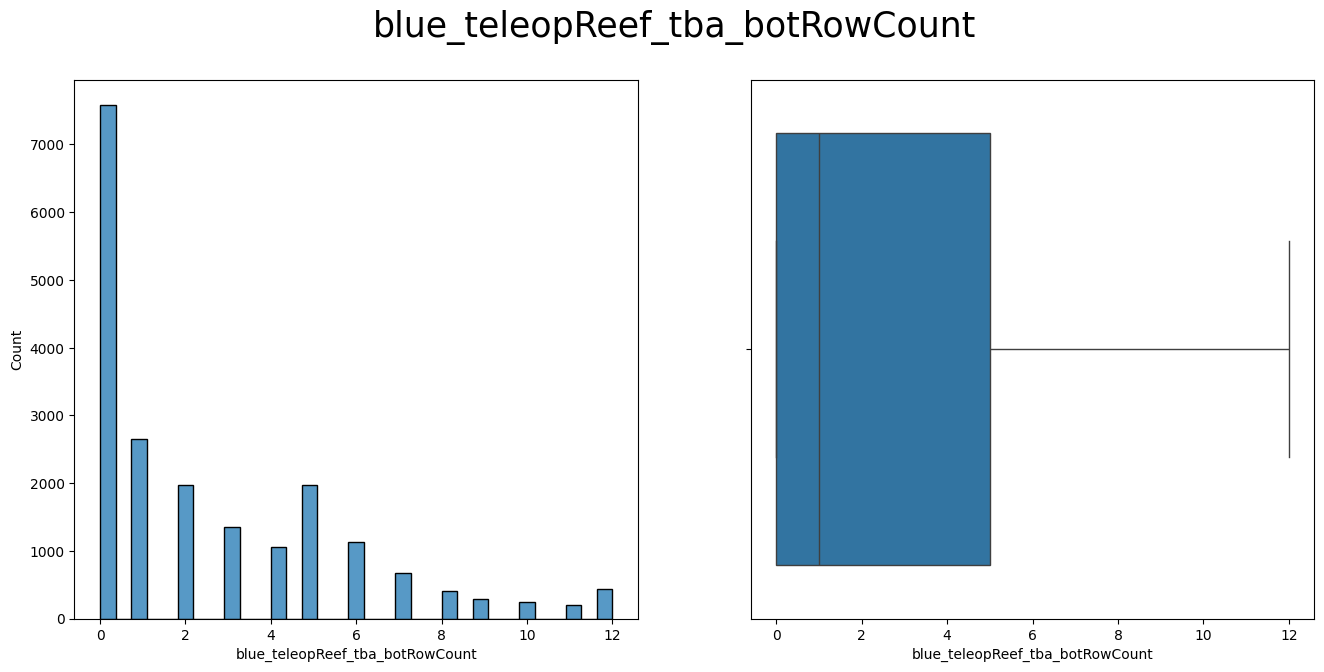

In [218]:
num_plot("blue_teleopReef_tba_botRowCount")

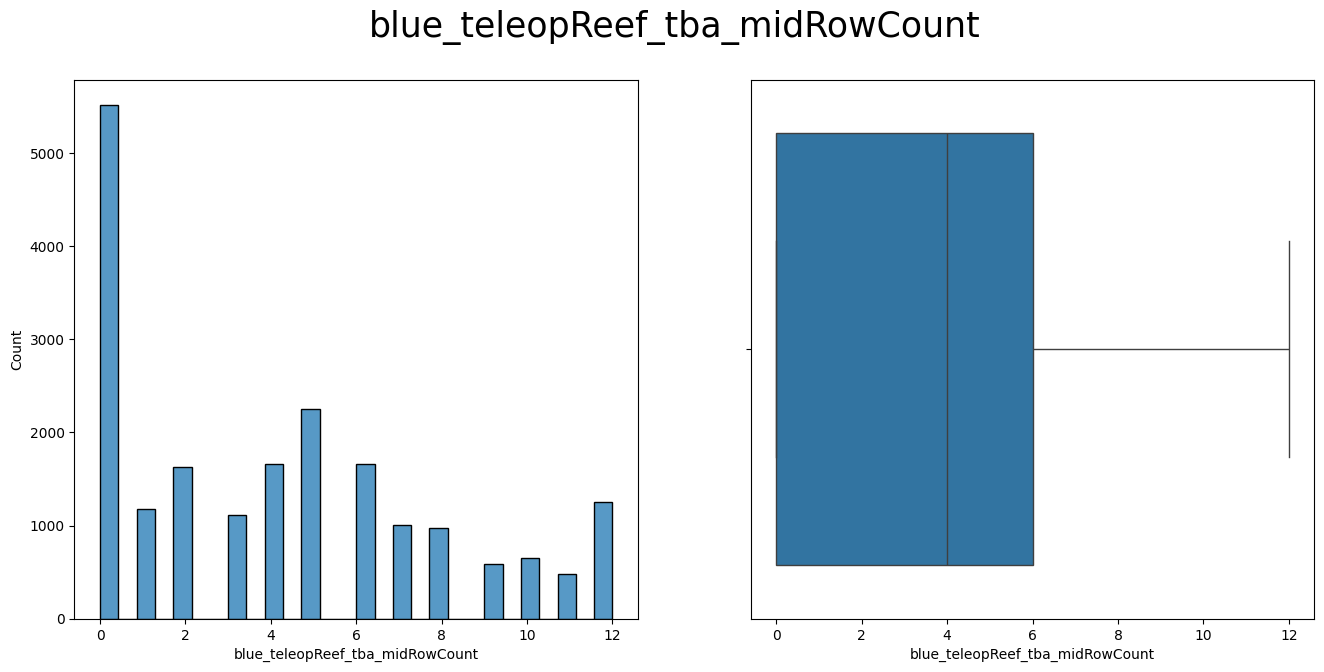

In [219]:
num_plot("blue_teleopReef_tba_midRowCount")

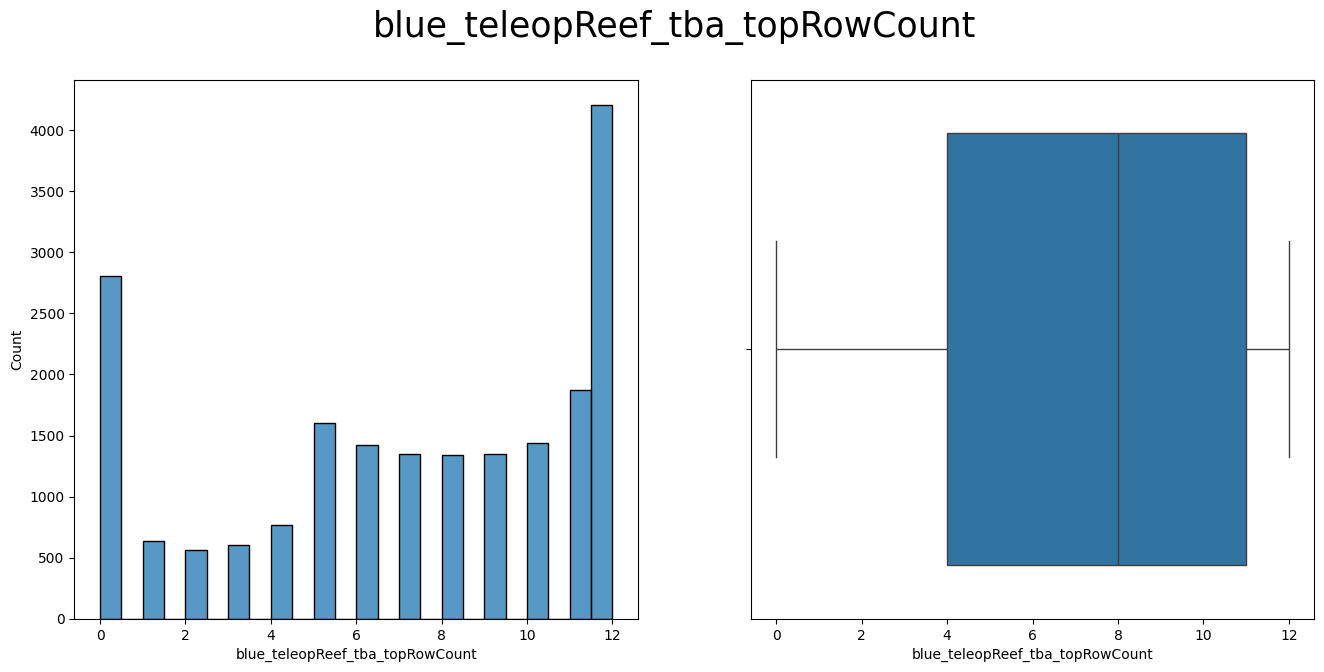

In [220]:
num_plot("blue_teleopReef_tba_topRowCount")

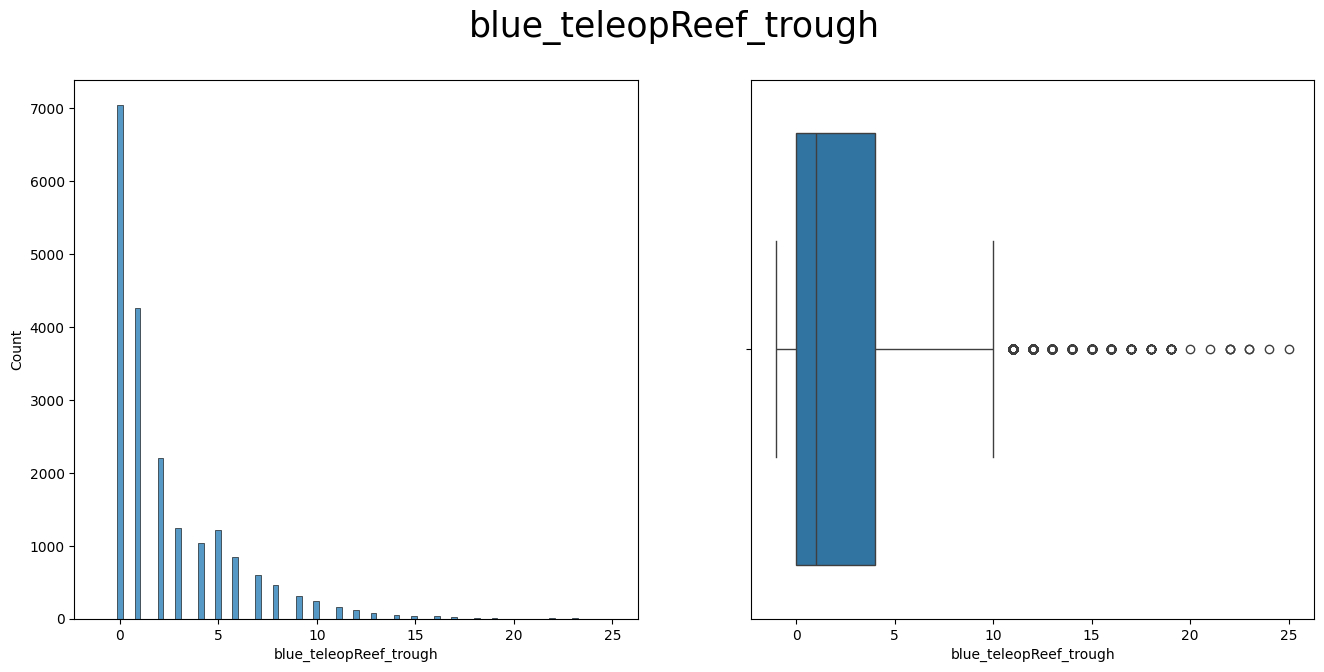

In [221]:
num_plot("blue_teleopReef_trough")

##### algaes

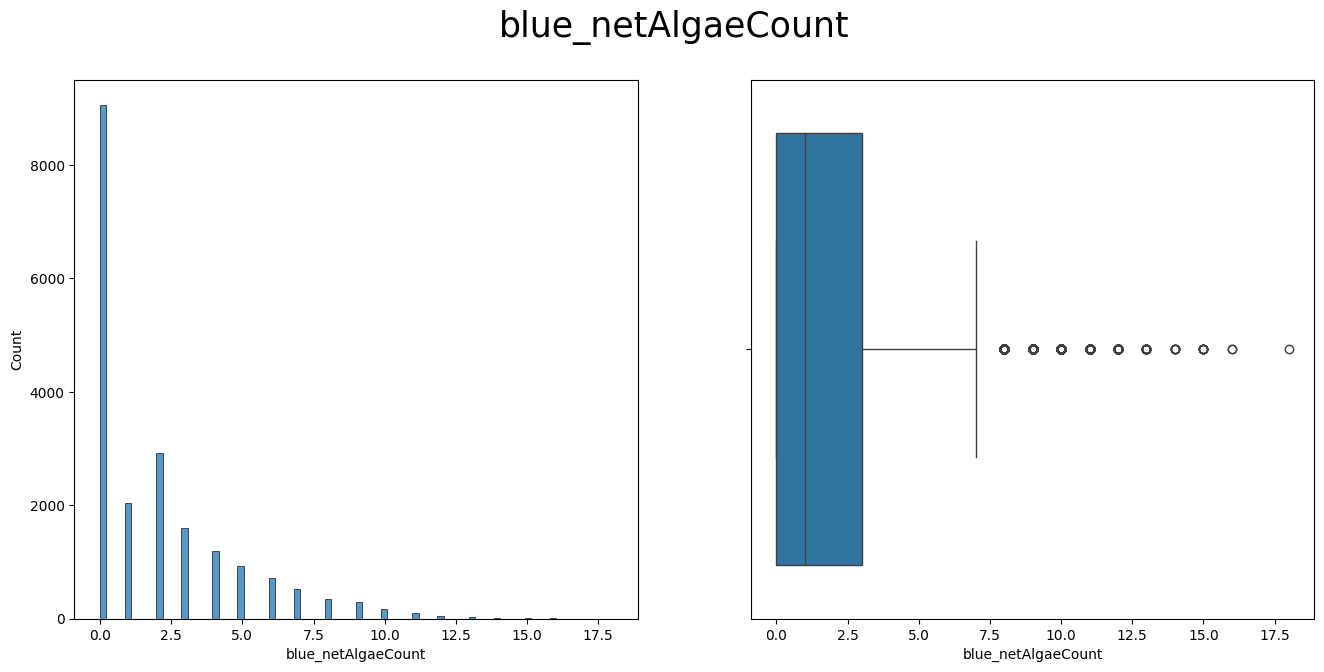

In [222]:
num_plot("blue_netAlgaeCount")

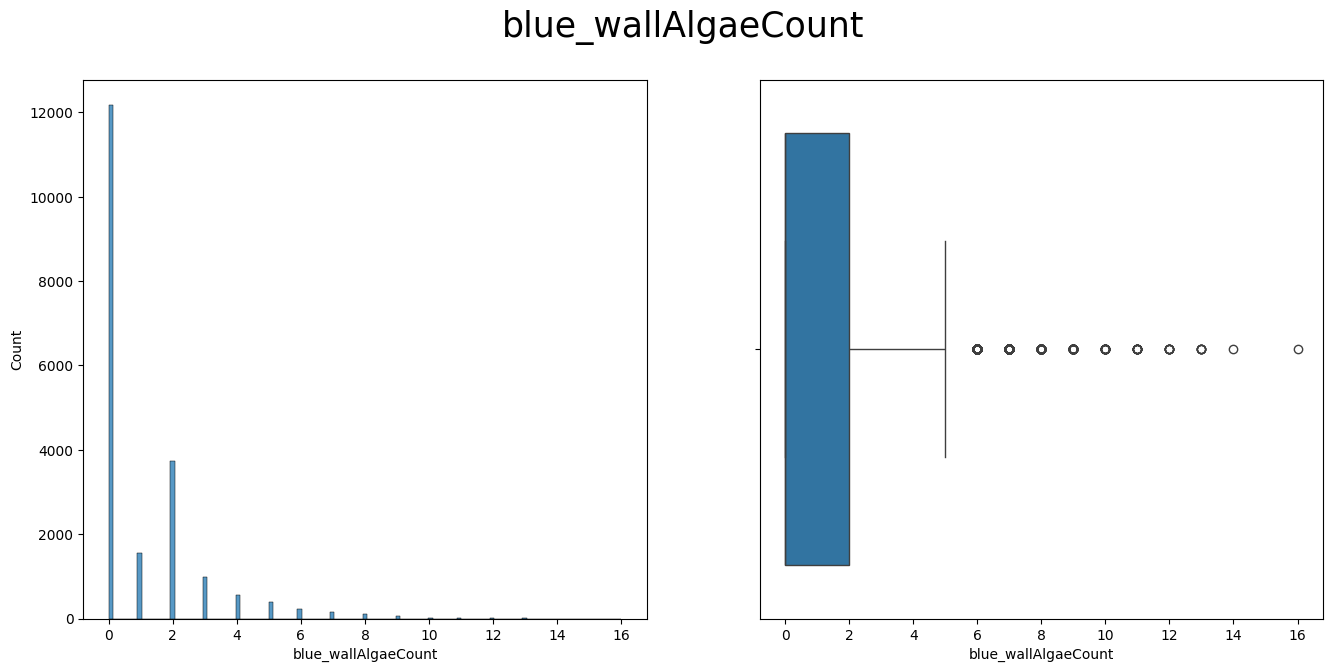

In [223]:
num_plot("blue_wallAlgaeCount")

##### penalties

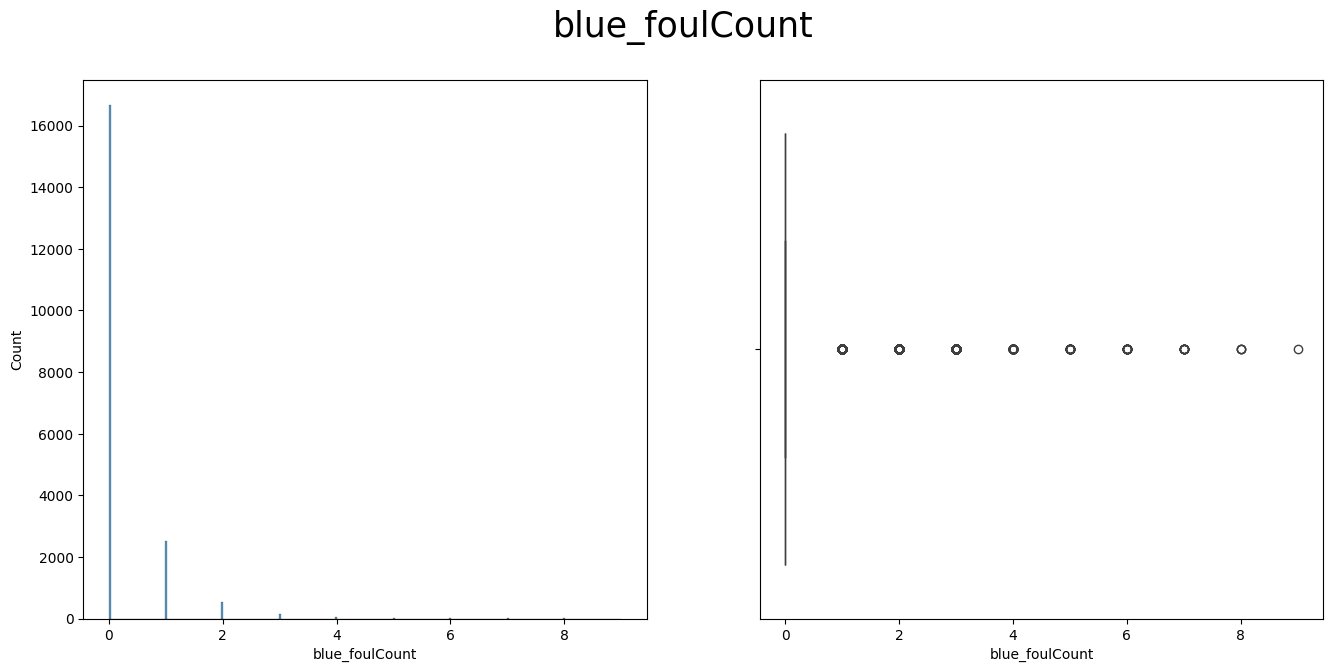

In [224]:
num_plot("blue_foulCount")

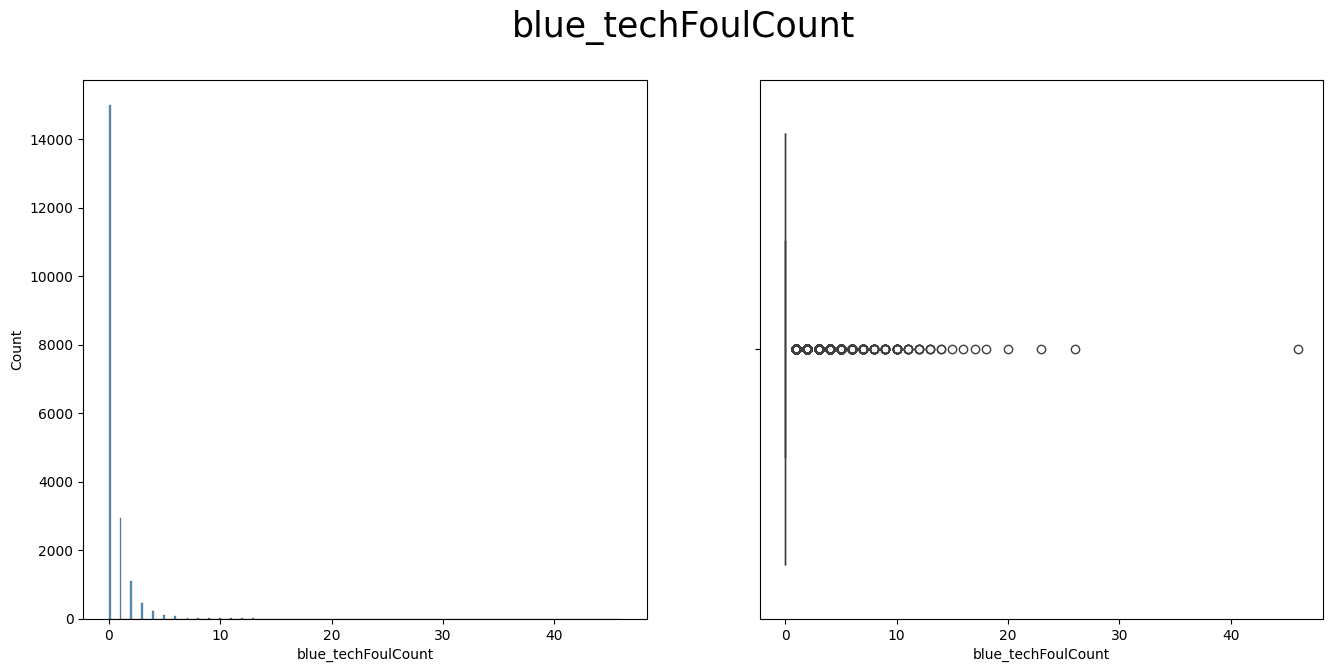

In [225]:
num_plot("blue_techFoulCount")

##### else

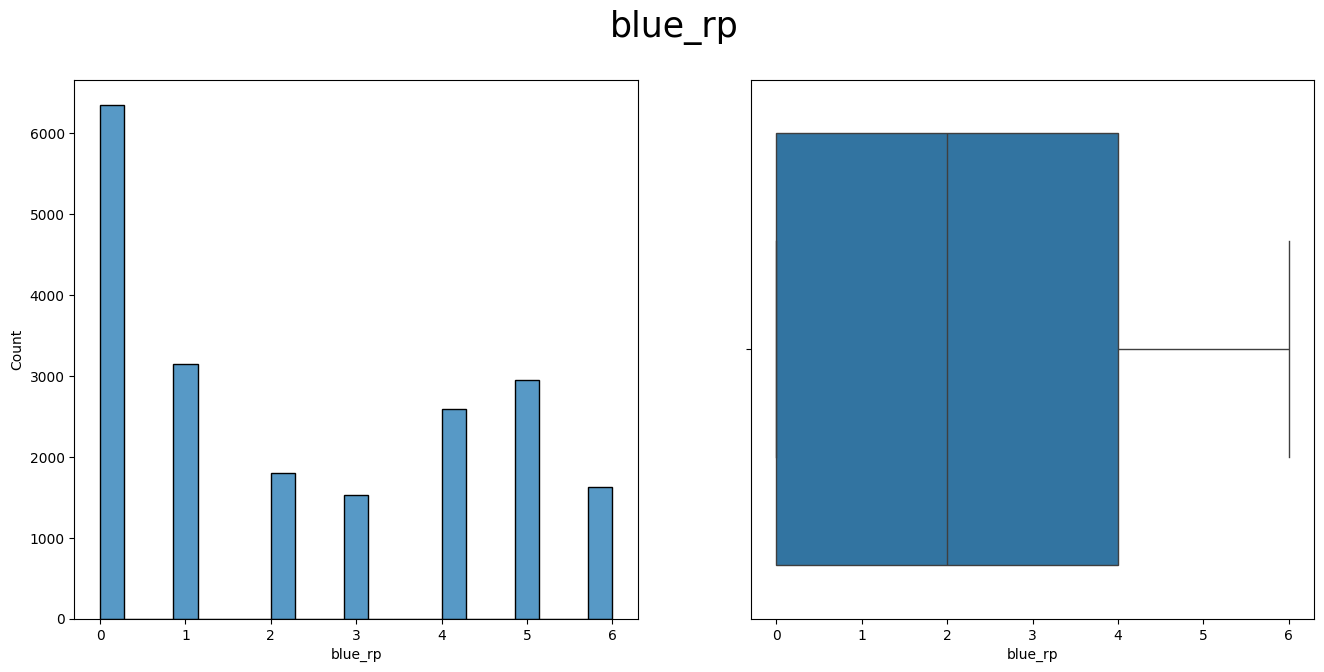

In [226]:
num_plot("blue_rp")

#### red counts

##### corals

auto

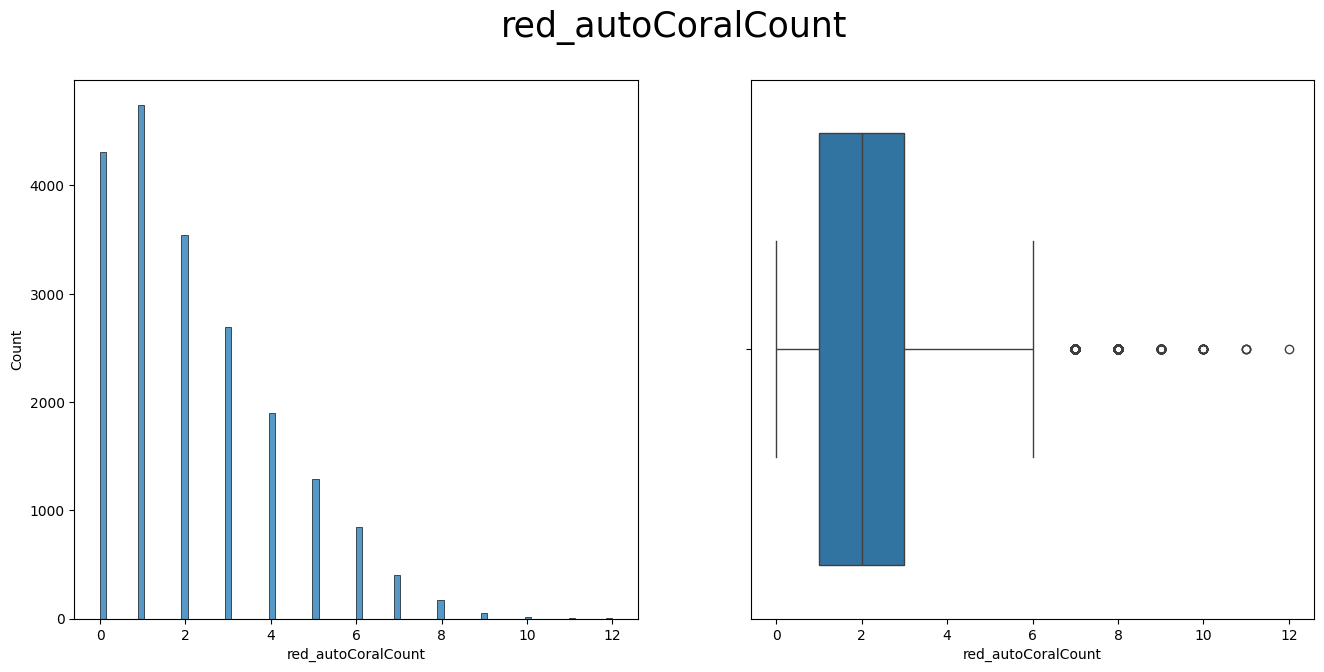

In [227]:
num_plot("red_autoCoralCount")

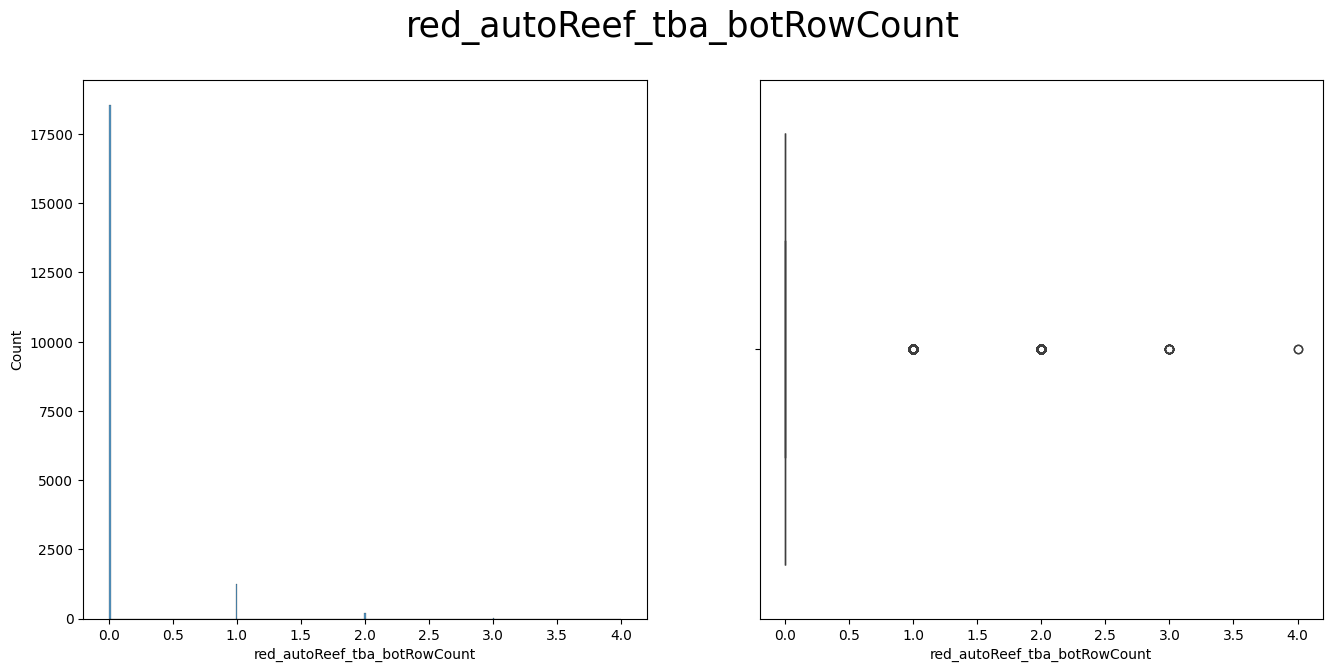

In [228]:
num_plot("red_autoReef_tba_botRowCount")

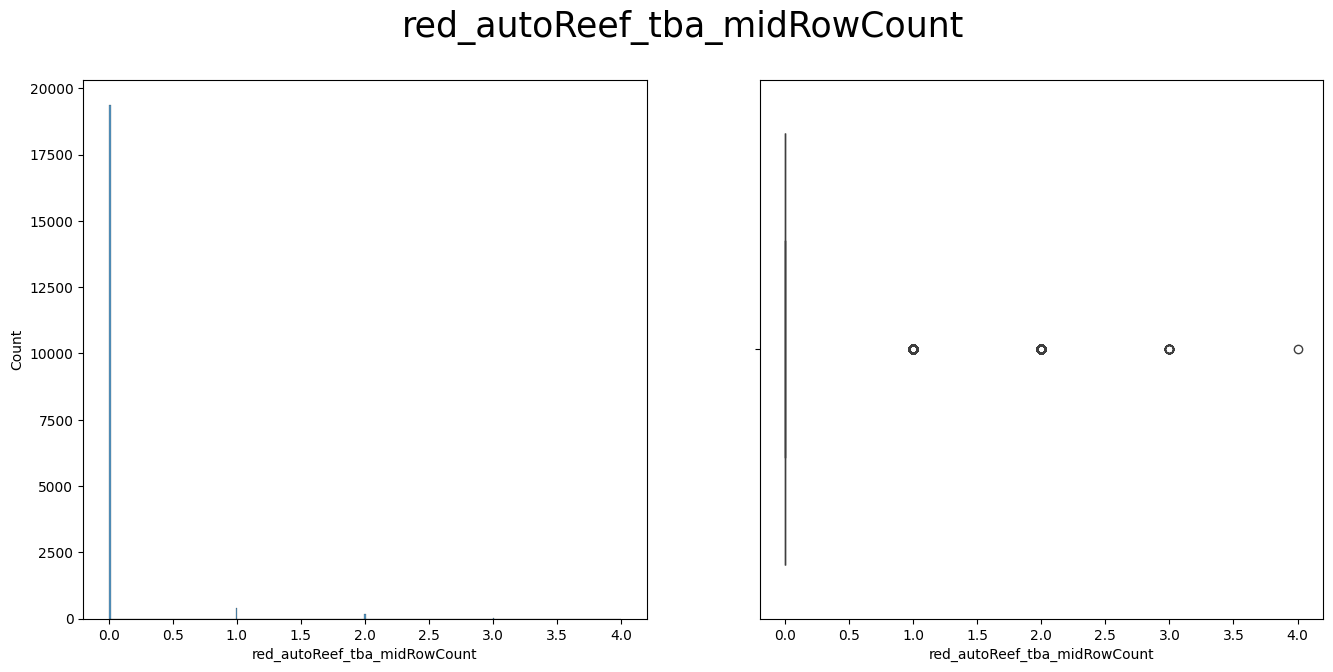

In [229]:
num_plot("red_autoReef_tba_midRowCount")

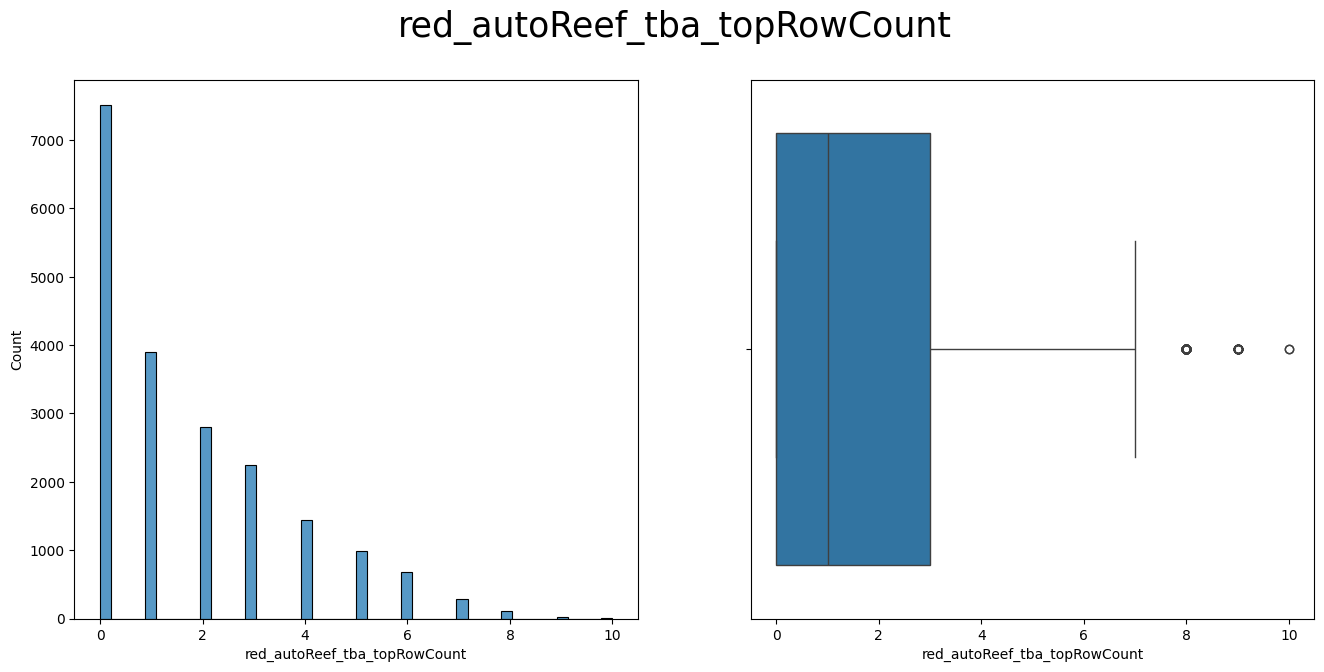

In [230]:
num_plot("red_autoReef_tba_topRowCount")

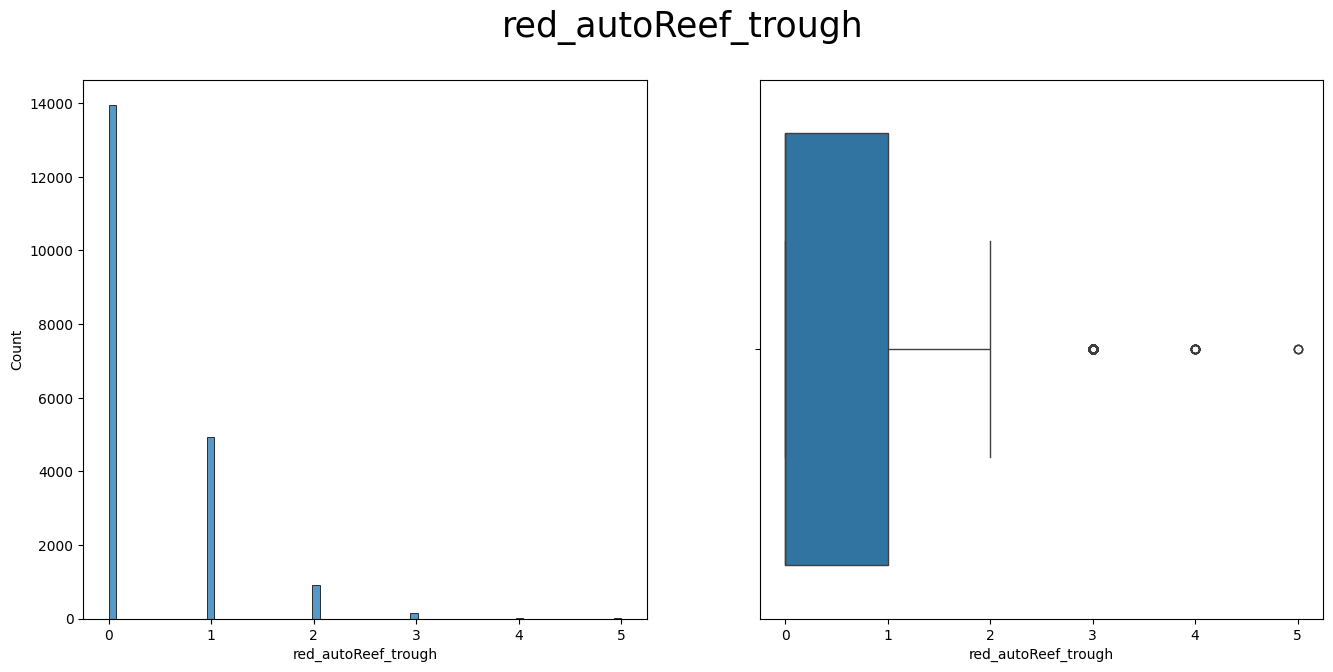

In [231]:
num_plot("red_autoReef_trough")

teleop

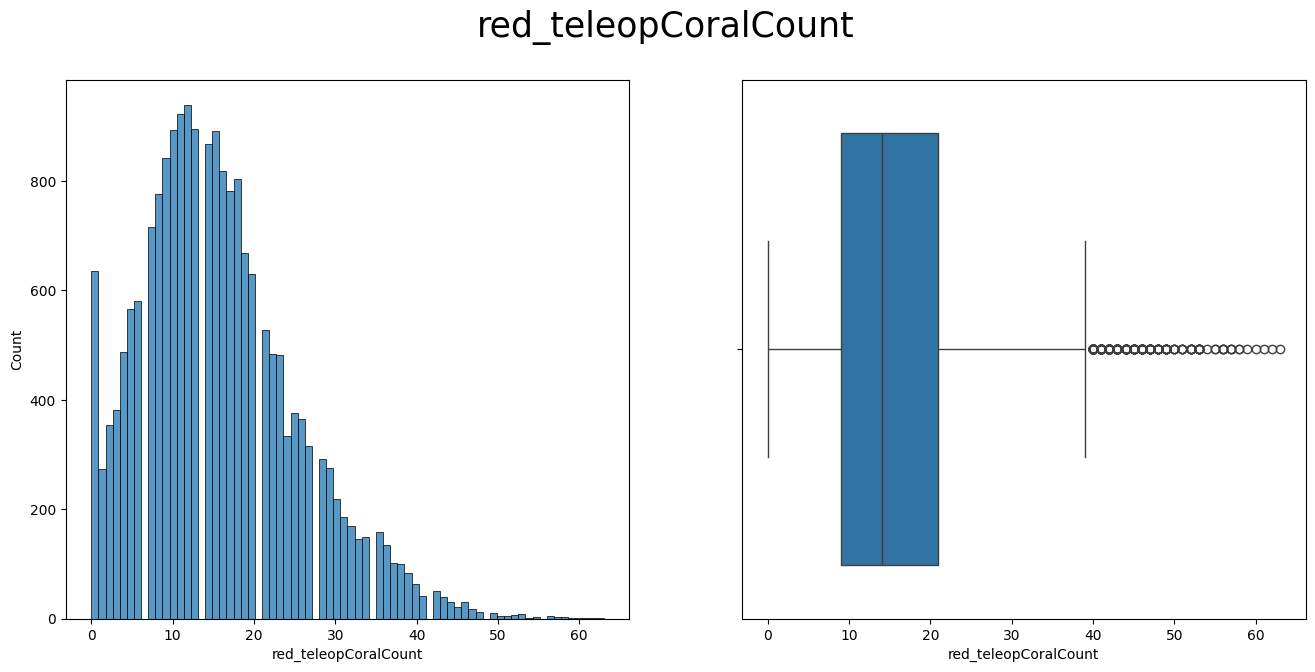

In [232]:
num_plot("red_teleopCoralCount")

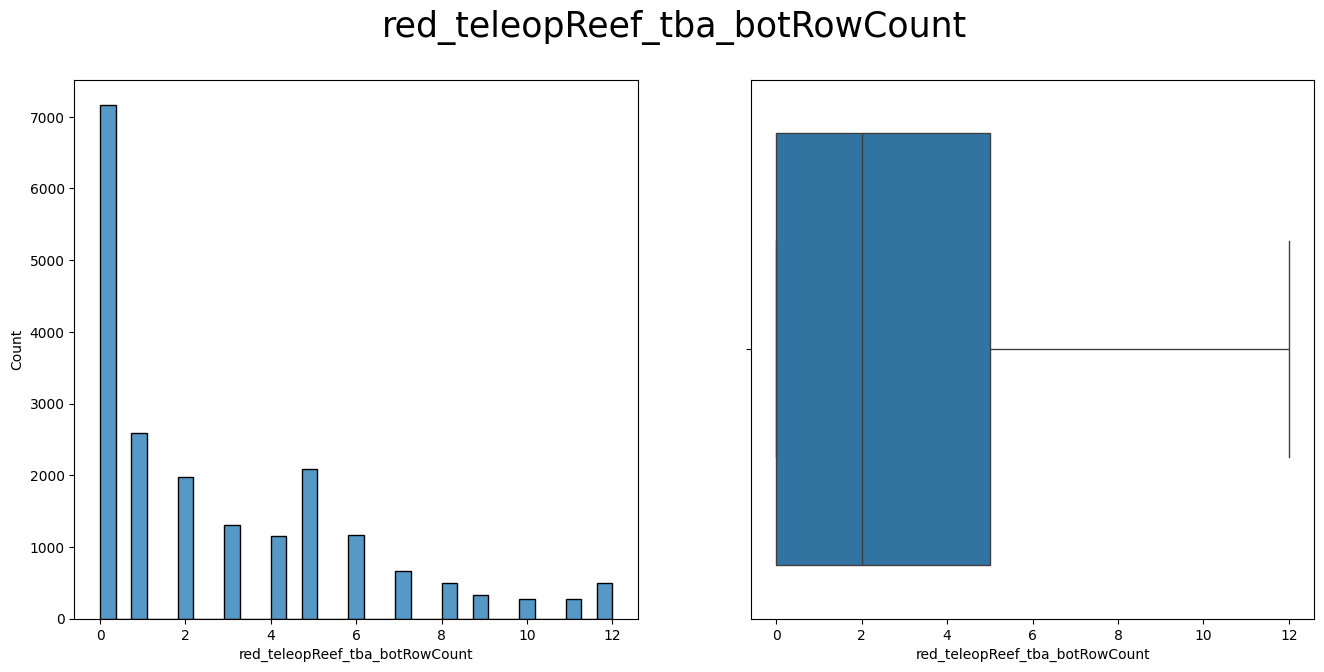

In [233]:
num_plot("red_teleopReef_tba_botRowCount")

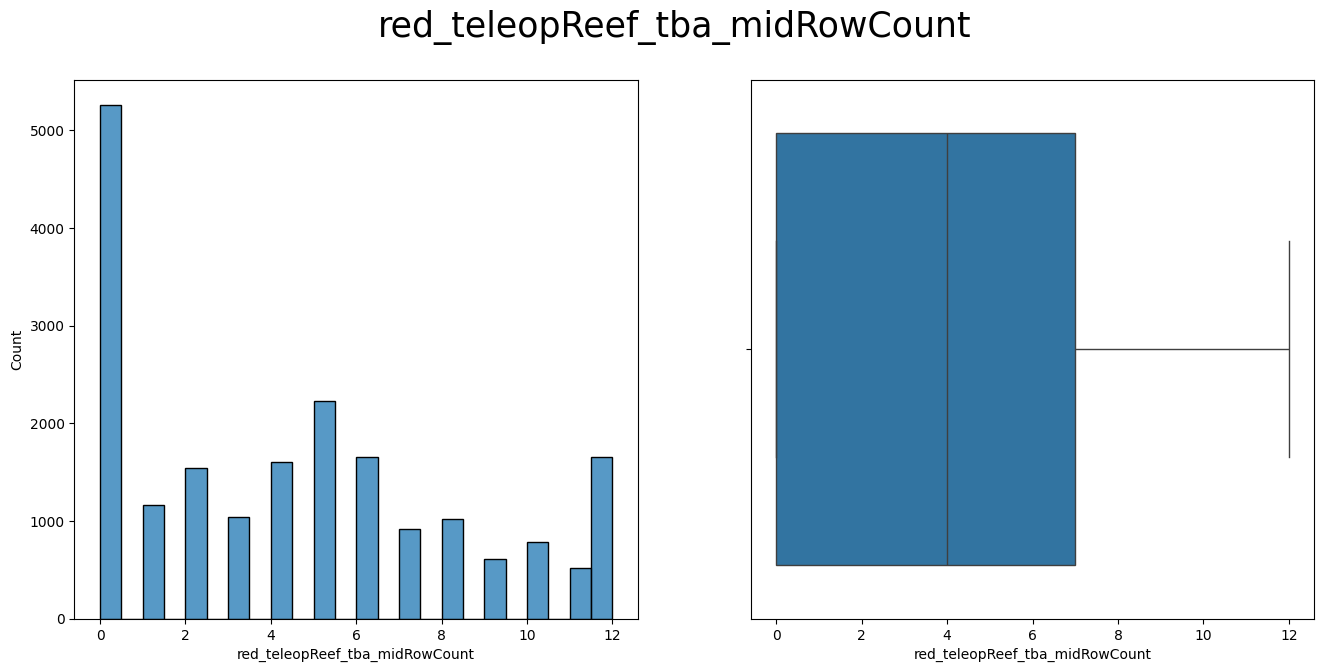

In [234]:
num_plot("red_teleopReef_tba_midRowCount")

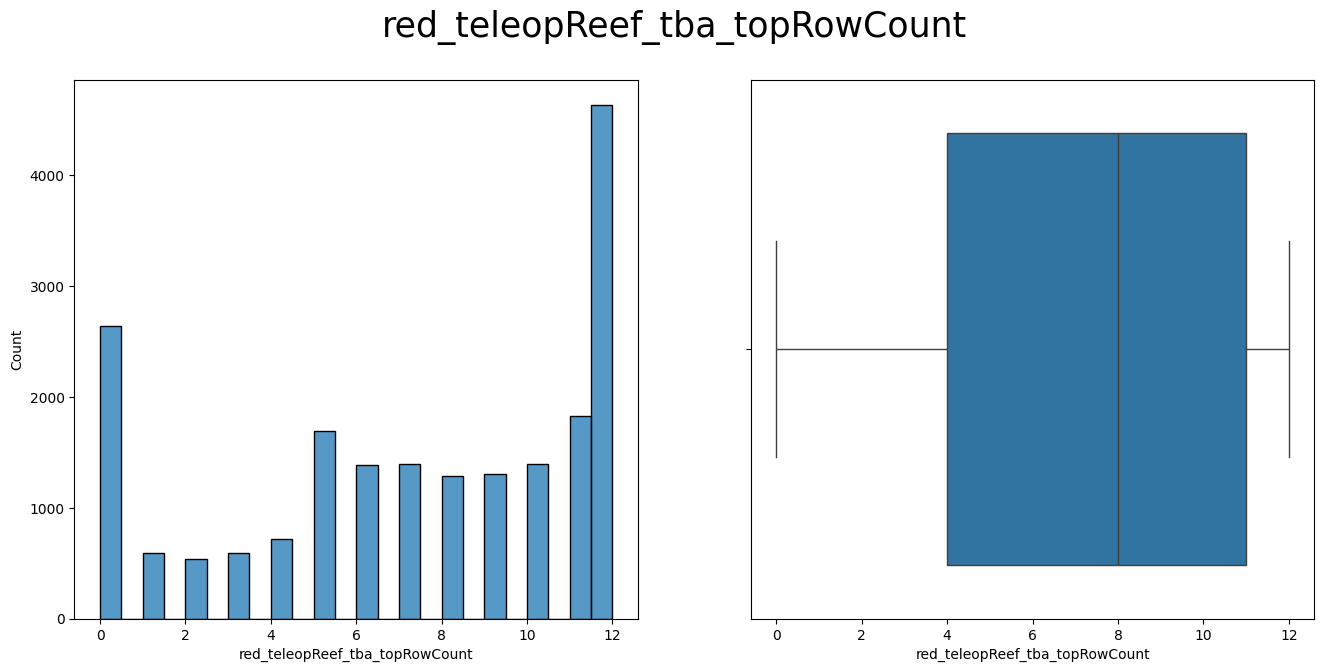

In [235]:
num_plot("red_teleopReef_tba_topRowCount")

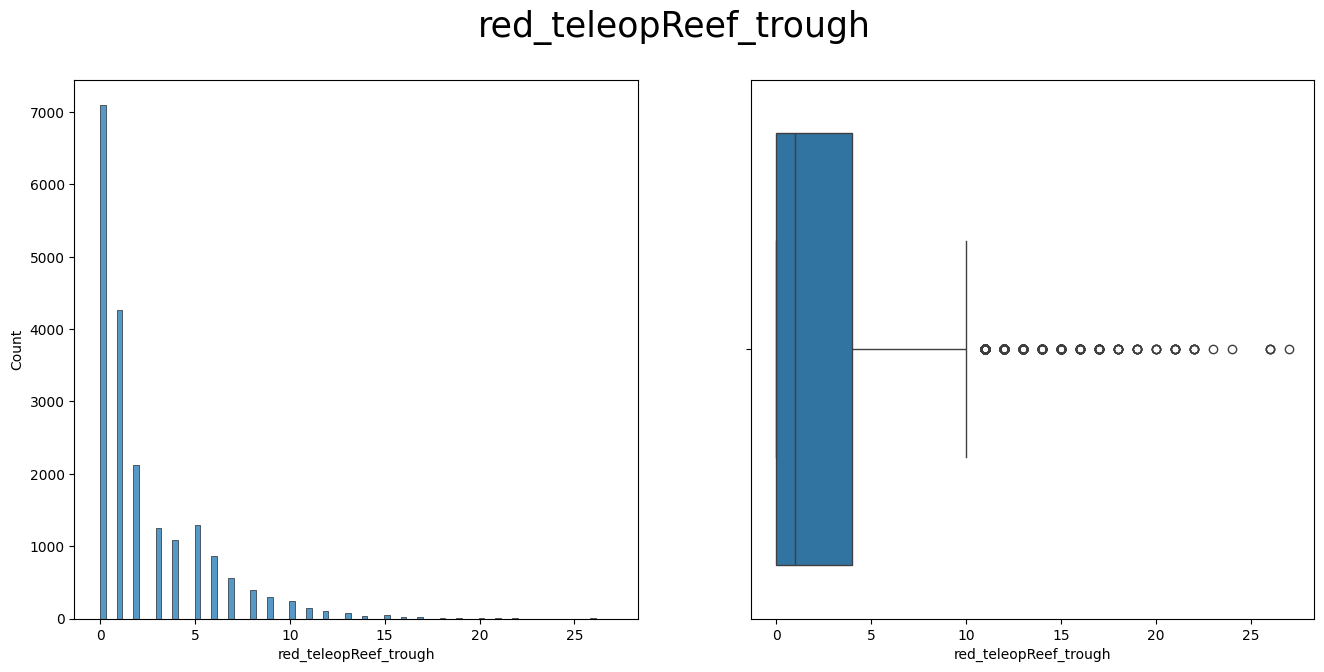

In [236]:
num_plot("red_teleopReef_trough")

##### algaes

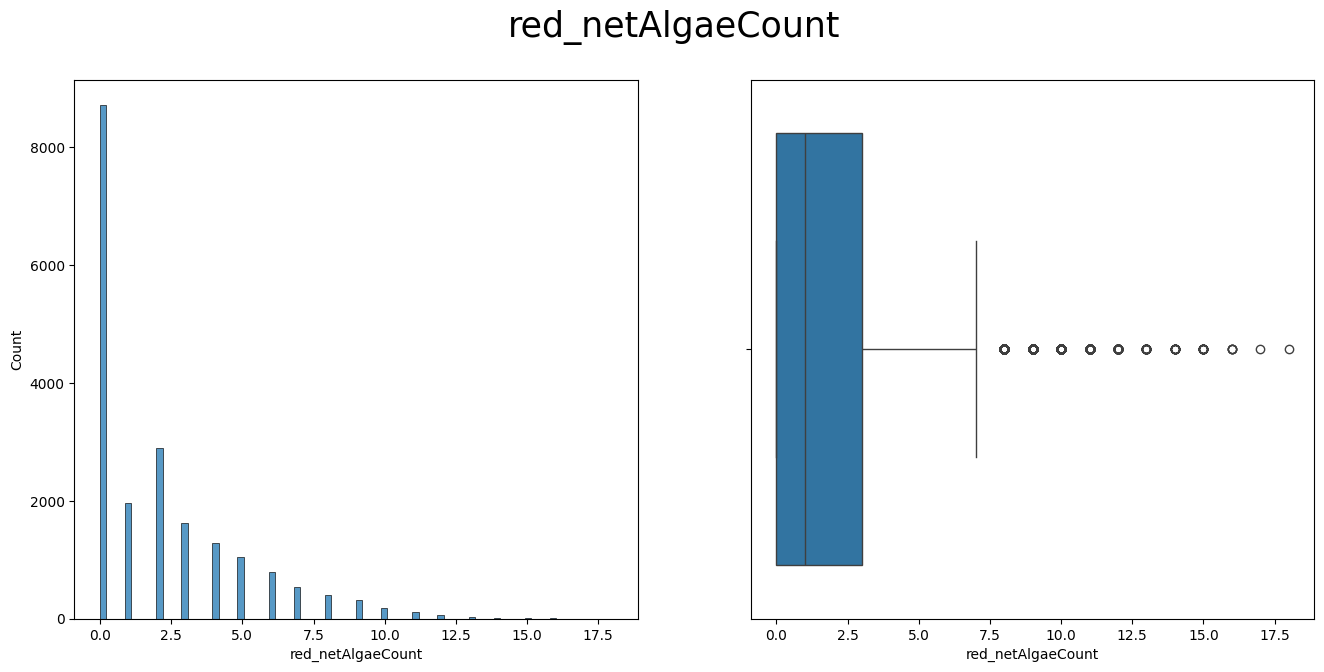

In [237]:
num_plot("red_netAlgaeCount")

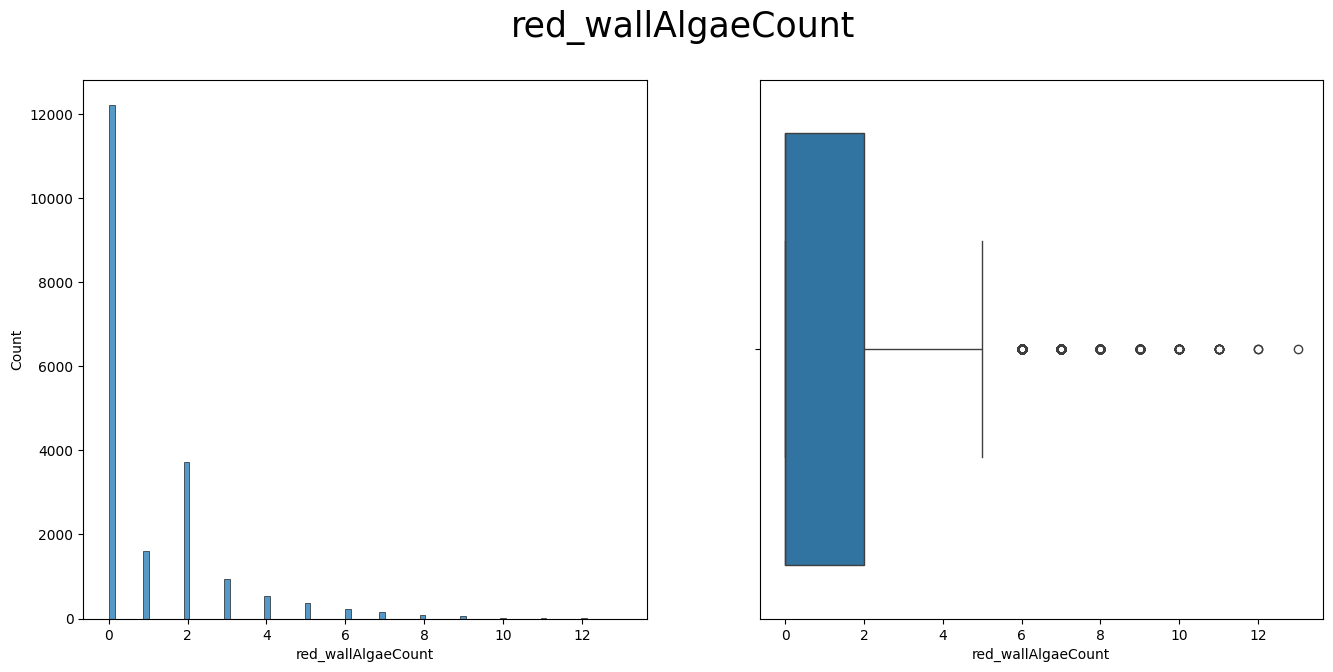

In [238]:
num_plot("red_wallAlgaeCount")

##### penalties

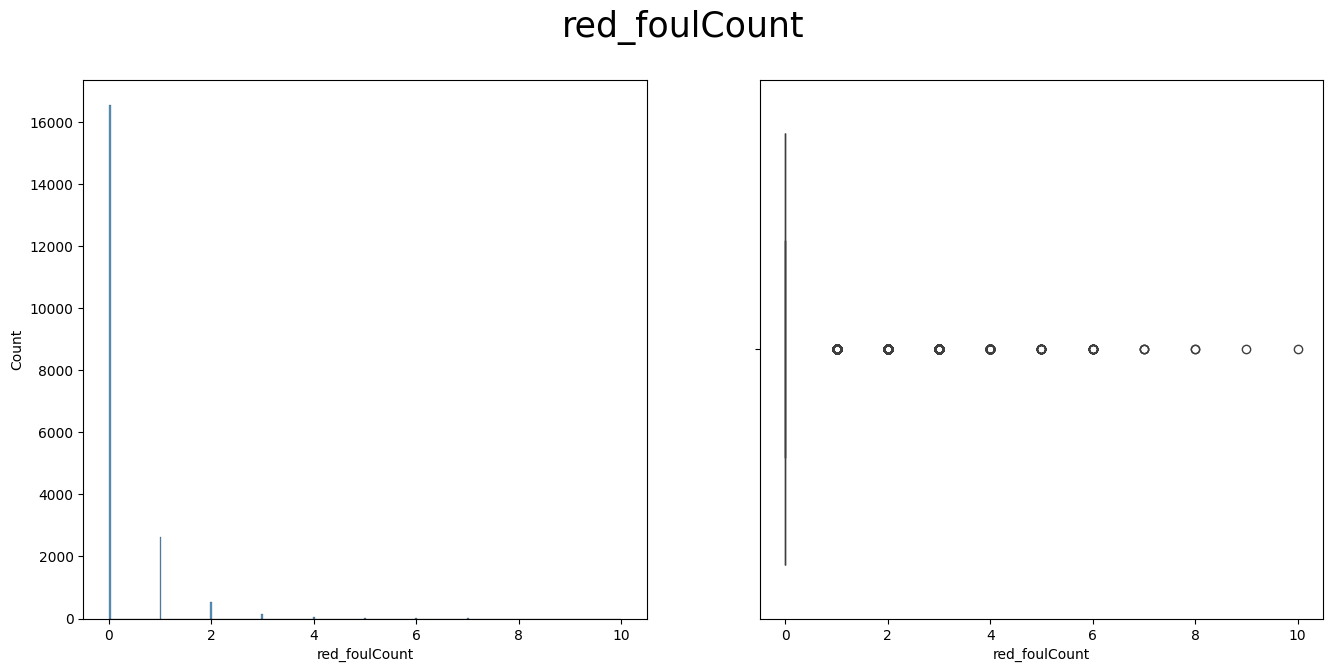

In [239]:
num_plot("red_foulCount")

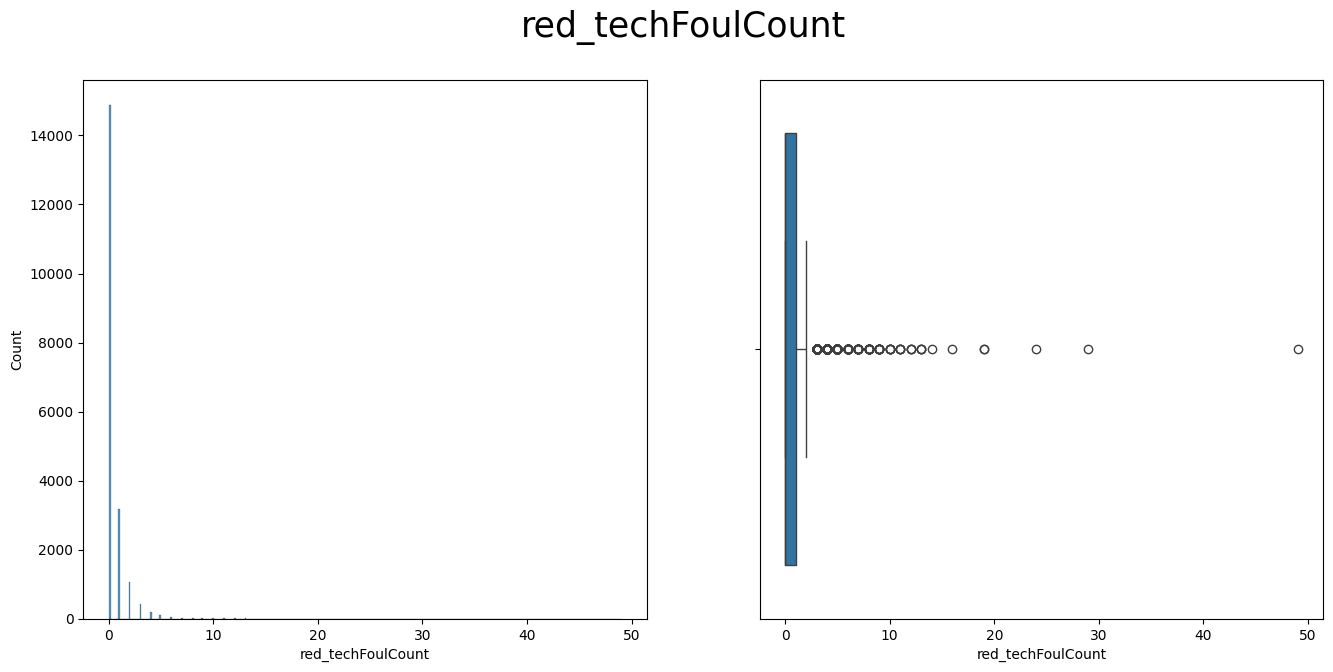

In [240]:
num_plot("red_techFoulCount")

##### else

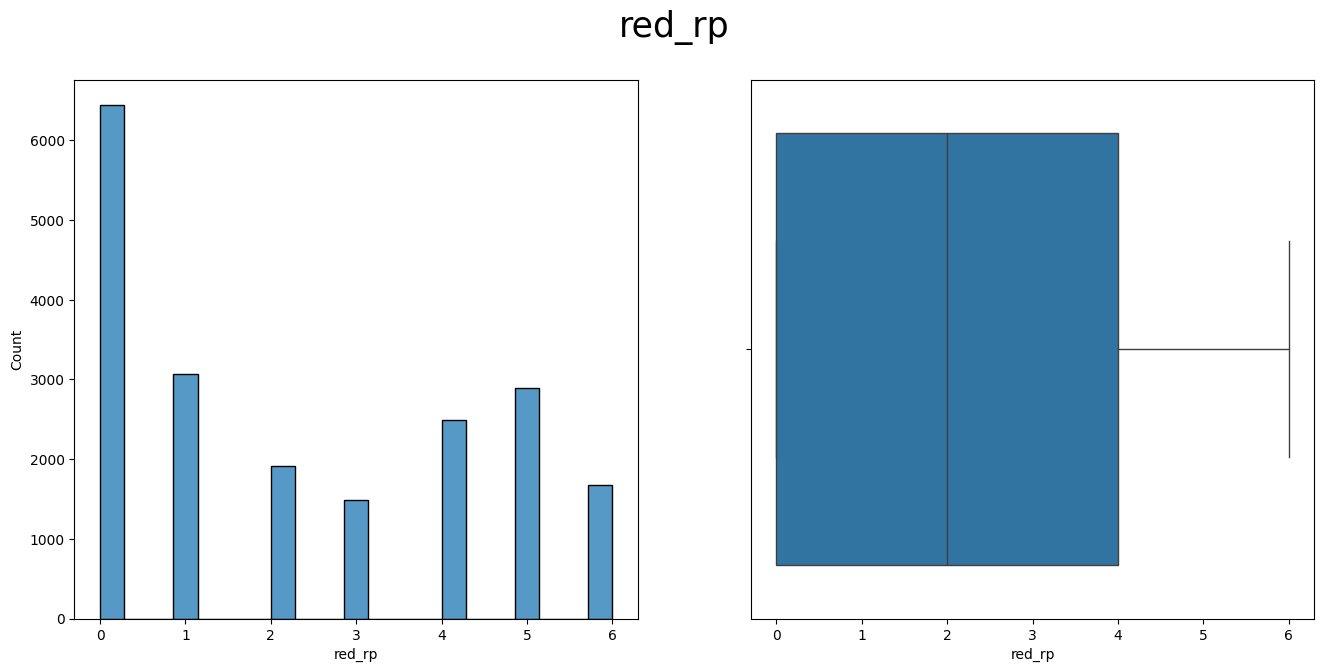

In [241]:
num_plot("red_rp")